<a href="https://colab.research.google.com/github/Misha-private/Demo-repo/blob/main/HEXA_ML_3DVAR_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Connect to /contend/drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Getting set of ICs on the global hexagon-pentagon icosahedral grid

Reading grid:
/content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_v0.npz
ncells = 2562
area sum = 5.100997e+14
sphere area = 5.100997e+14
[0000] smooth_random_graph_field  hpert min/max = -4.657e+01 / +3.999e+01 m mass = +3.750e-01
[0001] gaussian_bump              hpert min/max = -4.484e-01 / +1.663e+01 m mass = +0.000e+00
[0002] mixed_gaussians            hpert min/max = -9.234e+01 / +9.115e+01 m mass = +0.000e+00
[0003] mixed_gaussians            hpert min/max = -9.526e+01 / +2.403e+01 m mass = +0.000e+00
[0004] mixed_gaussians            hpert min/max = -6.224e+01 / +7.432e+01 m mass = +0.000e+00
[0005] smooth_random_graph_field  hpert min/max = -6.327e+01 / +7.429e+01 m mass = -2.500e-01
[0006] mixed_gaussians            hpert min/max = -5.702e+00 / +8.606e+01 m mass = +1.562e-01


KeyboardInterrupt: 

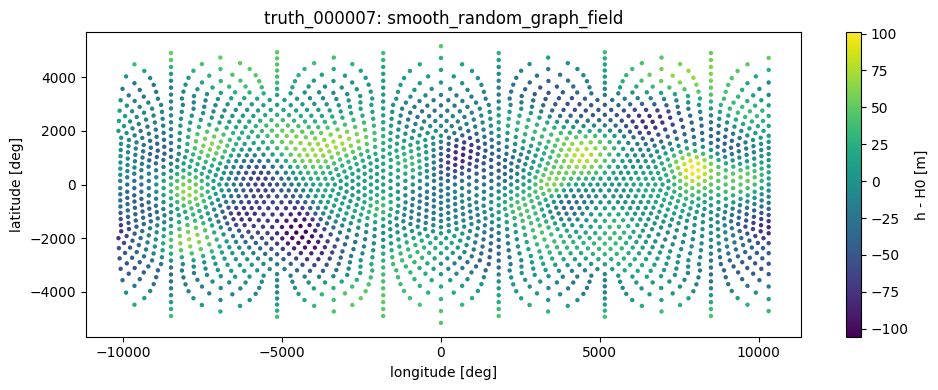

In [ ]:
# build_truth_ic_bank_ico_v0.py
#
# Build reusable truth initial-condition bank on the global
# hexagon-pentagon icosahedral grid.
#
# No observations.
# No background errors.
# No ML-3DVAR targets.
#
# Output:
#   truth_000000.npz, truth_000001.npz, ...

import os
import json
import numpy as np

# ============================================================
# User settings
# ============================================================

ROOT = "/content/drive/MyDrive/GLOBAL_SW_ML_DA"
GRID_FILE = "/content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_v0.npz"

OUT_DIR = os.path.join(ROOT, "ic_bank", "truth_states")
PLOT_DIR = os.path.join(ROOT, "ic_bank", "plots")

N_SAMPLES = 100
SEED = 12345

R_EARTH = 6.37122e6
OMEGA = 7.2921159e-5
G = 9.80616
H0 = 10000.0

MAKE_PLOTS = True
N_PLOTS = 12

# IC amplitudes
GAUSS_AMP_RANGE = (5.0, 100.0)       # meters
GAUSS_SIGMA_RANGE = (5.0e5, 2.5e6)  # meters

RANDOM_AMP_RANGE = (2.0, 40.0)      # meters
RANDOM_SMOOTH_ITERS = (10, 80)

MIXED_N_BUMPS_RANGE = (2, 6)

# ============================================================
# Utilities
# ============================================================

def ensure_dir(path):
    os.makedirs(path, exist_ok=True)


def normalize_xyz(x):
    return x / np.linalg.norm(x, axis=-1, keepdims=True)


def lonlat_from_xyz(xyz):
    x, y, z = xyz[:, 0], xyz[:, 1], xyz[:, 2]
    lon = np.arctan2(y, x)
    lat = np.arcsin(np.clip(z, -1.0, 1.0))
    return lon, lat


def random_point_on_sphere(rng):
    z = rng.uniform(-1.0, 1.0)
    lon = rng.uniform(0.0, 2.0 * np.pi)
    r = np.sqrt(max(0.0, 1.0 - z * z))
    return np.array([r * np.cos(lon), r * np.sin(lon), z])


def great_circle_distance(cell_xyz, center_xyz):
    dots = np.clip(cell_xyz @ center_xyz, -1.0, 1.0)
    return R_EARTH * np.arccos(dots)


def mass_zero(field, area):
    mean = np.sum(field * area) / np.sum(area)
    return field - mean

def build_neighbors_from_primal_faces(primal_faces, ncells):
    """
    Build cell-cell neighbors from triangular primal faces.
    Each face contains 3 cell indices. Cells sharing a face edge
    are graph neighbors.
    """
    neigh_sets = [set() for _ in range(ncells)]

    for tri in primal_faces:
        tri = np.array(tri, dtype=int)
        tri = tri[(tri >= 0) & (tri < ncells)]

        if len(tri) != 3:
            continue

        a, b, c = tri

        neigh_sets[a].add(b)
        neigh_sets[a].add(c)

        neigh_sets[b].add(a)
        neigh_sets[b].add(c)

        neigh_sets[c].add(a)
        neigh_sets[c].add(b)

    neighbors = [np.array(sorted(list(s)), dtype=int) for s in neigh_sets]
    return neighbors


def smooth_graph_field(q, neighbors, niter=20, alpha=0.35):
    """
    Simple explicit graph smoothing.
    q <- (1-alpha) q + alpha average_neighbors(q)
    """
    q = q.copy()
    for _ in range(niter):
        q_new = q.copy()
        for i, nb in enumerate(neighbors):
            if len(nb) > 0:
                q_new[i] = (1.0 - alpha) * q[i] + alpha * np.mean(q[nb])
        q = q_new
    return q


# ============================================================
# IC generators
# ============================================================

def make_gaussian_bump(cell_xyz, area, rng):
    center = random_point_on_sphere(rng)
    amp = rng.uniform(*GAUSS_AMP_RANGE)
    sigma = rng.uniform(*GAUSS_SIGMA_RANGE)

    r = great_circle_distance(cell_xyz, center)
    hp = amp * np.exp(-0.5 * (r / sigma) ** 2)
    hp = mass_zero(hp, area)

    meta = {
        "type": "gaussian_bump",
        "amp_m": float(amp),
        "sigma_m": float(sigma),
        "center_xyz": center.tolist(),
    }

    return hp, meta


def make_mixed_gaussians(cell_xyz, area, rng):
    n_bumps = rng.integers(MIXED_N_BUMPS_RANGE[0], MIXED_N_BUMPS_RANGE[1] + 1)

    hp = np.zeros(cell_xyz.shape[0])

    bumps = []
    for _ in range(n_bumps):
        center = random_point_on_sphere(rng)
        amp = rng.uniform(*GAUSS_AMP_RANGE) * rng.choice([-1.0, 1.0])
        sigma = rng.uniform(*GAUSS_SIGMA_RANGE)

        r = great_circle_distance(cell_xyz, center)
        hp += amp * np.exp(-0.5 * (r / sigma) ** 2)

        bumps.append({
            "amp_m": float(amp),
            "sigma_m": float(sigma),
            "center_xyz": center.tolist(),
        })

    hp = mass_zero(hp, area)

    meta = {
        "type": "mixed_gaussians",
        "n_bumps": int(n_bumps),
        "bumps": bumps,
    }

    return hp, meta


def make_smooth_random_field(cell_xyz, area, neighbors, rng):
    nc = cell_xyz.shape[0]

    q = rng.normal(size=nc)
    niter = int(rng.integers(RANDOM_SMOOTH_ITERS[0], RANDOM_SMOOTH_ITERS[1] + 1))

    q = smooth_graph_field(q, neighbors, niter=niter, alpha=0.35)
    q = mass_zero(q, area)

    std = np.sqrt(np.sum(area * q ** 2) / np.sum(area))
    if std > 0:
        q = q / std

    amp = rng.uniform(*RANDOM_AMP_RANGE)
    hp = amp * q

    meta = {
        "type": "smooth_random_graph_field",
        "amp_m": float(amp),
        "smooth_iters": int(niter),
    }

    return hp, meta


def make_truth_state(cell_xyz, area, neighbors, rng, sample_id):
    """
    First version:
      h_true = H0 + perturbation
      u_true = 0
      v_true = 0

    Later we will add balanced winds, RH waves, vortices, etc.
    """

    ic_kind = rng.choice([
        "gaussian",
        "mixed_gaussian",
        "smooth_random",
    ])

    if ic_kind == "gaussian":
        hp, meta = make_gaussian_bump(cell_xyz, area, rng)
    elif ic_kind == "mixed_gaussian":
        hp, meta = make_mixed_gaussians(cell_xyz, area, rng)
    elif ic_kind == "smooth_random":
        hp, meta = make_smooth_random_field(cell_xyz, area, neighbors, rng)
    else:
        raise ValueError(f"Unknown IC type: {ic_kind}")

    h_true = H0 + hp
    u_true = np.zeros_like(h_true)
    v_true = np.zeros_like(h_true)

    meta["sample_id"] = int(sample_id)
    meta["H0"] = float(H0)
    meta["mass_zeroed_height_perturbation"] = True
    meta["wind_initialization"] = "zero"

    return h_true, u_true, v_true, hp, meta


# ============================================================
# Plotting
# ============================================================

def try_plot_state(lon, lat, hpert, out_png, title):
    try:
        import matplotlib.pyplot as plt

        plt.figure(figsize=(10, 4))
        sc = plt.scatter(
            np.degrees(lon),
            np.degrees(lat),
            c=hpert,
            s=10,
            linewidths=0,
        )
        plt.colorbar(sc, label="h - H0 [m]")
        plt.xlabel("longitude [deg]")
        plt.ylabel("latitude [deg]")
        plt.title(title)
        plt.tight_layout()
        plt.savefig(out_png, dpi=160)
        plt.close()

    except Exception as e:
        print(f"Plot failed for {out_png}: {e}")


# ============================================================
# Main
# ============================================================

def main():
    ensure_dir(OUT_DIR)
    ensure_dir(PLOT_DIR)

    rng = np.random.default_rng(SEED)

    print("Reading grid:")
    print(GRID_FILE)

    grid = np.load(GRID_FILE, allow_pickle=True)

    # Flexible key handling
    if "cell_xyz" in grid:
        cell_xyz = grid["cell_xyz"]
    elif "cell_center_xyz" in grid:
        cell_xyz = grid["cell_center_xyz"]
    else:
        raise KeyError("Could not find cell_xyz or cell_center_xyz in grid file.")

    if "cell_area" in grid:
        area = grid["cell_area"]
    elif "area" in grid:
        area = grid["area"]
    else:
        raise KeyError("Could not find cell_area or area in grid file.")

    if "cell_lon" in grid and "cell_lat" in grid:
        lon = grid["cell_lon"]
        lat = grid["cell_lat"]
    elif "cell_center_lon" in grid and "cell_center_lat" in grid:
        lon = grid["cell_center_lon"]
        lat = grid["cell_center_lat"]
    else:
        lon, lat = lonlat_from_xyz(cell_xyz)

    ncells = cell_xyz.shape[0]
    if "primal_faces" in grid:
        neighbors = build_neighbors_from_primal_faces(grid["primal_faces"], ncells)
    else:
        raise KeyError(
        "Could not find primal_faces in grid file. "
        "We need cell-cell graph neighbors for smooth random ICs."
        )


    cell_xyz = normalize_xyz(cell_xyz)

    f = 2.0 * OMEGA * np.sin(lat)

    print(f"ncells = {ncells}")
    print(f"area sum = {np.sum(area):.6e}")
    print(f"sphere area = {4.0 * np.pi * R_EARTH**2:.6e}")

    global_meta = {
        "script": "build_truth_ic_bank_ico_v0.py",
        "grid_file": GRID_FILE,
        "n_samples": N_SAMPLES,
        "seed": SEED,
        "R_EARTH": R_EARTH,
        "OMEGA": OMEGA,
        "G": G,
        "H0": H0,
        "description": (
            "Reusable truth-state initial-condition bank on the "
            "global hexagon-pentagon icosahedral grid. "
            "No observations or background errors included."
        ),
    }

    with open(os.path.join(OUT_DIR, "metadata_global.json"), "w") as fmeta:
        json.dump(global_meta, fmeta, indent=2)

    for n in range(N_SAMPLES):
        h_true, u_true, v_true, hp, meta = make_truth_state(
            cell_xyz=cell_xyz,
            area=area,
            neighbors=neighbors,
            rng=rng,
            sample_id=n,
        )

        out_file = os.path.join(OUT_DIR, f"truth_{n:06d}.npz")

        np.savez_compressed(
            out_file,
            h_true=h_true.astype(np.float64),
            u_true=u_true.astype(np.float64),
            v_true=v_true.astype(np.float64),
            h_pert=hp.astype(np.float64),
            lon=lon.astype(np.float64),
            lat=lat.astype(np.float64),
            cell_xyz=cell_xyz.astype(np.float64),
            area=area.astype(np.float64),
            f=f.astype(np.float64),
            H0=np.float64(H0),
            G=np.float64(G),
            OMEGA=np.float64(OMEGA),
            R_EARTH=np.float64(R_EARTH),
            meta_json=json.dumps(meta),
        )

        if MAKE_PLOTS and n < N_PLOTS:
            png = os.path.join(PLOT_DIR, f"truth_{n:06d}.png")
            try_plot_state(
                lon,
                lat,
                hp,
                png,
                title=f"truth_{n:06d}: {meta['type']}",
            )

        print(
            f"[{n:04d}] {meta['type']:26s} "
            f"hpert min/max = {hp.min():+.3e} / {hp.max():+.3e} m "
            f"mass = {np.sum(hp * area):+.3e}"
        )

    print("")
    print("Done.")
    print(f"Truth IC bank written to: {OUT_DIR}")
    print(f"Plots written to:         {PLOT_DIR}")


if __name__ == "__main__":
    main()

# build_truth_ic_bank_ico_v1.py

1. native hex/pent icosahedral grid
2. robust graph-neighbor construction
3. IC family labels
4. Gaussian, mixed Gaussian, smooth random graph fields
5. optional simple balanced vortex-like states
6. clean metadata for later ML-3DVAR / ML-4DVAR reuse

In [ ]:
# build_truth_ic_bank_ico_v1.py

import os
import json
import numpy as np

# ============================================================
# User settings
# ============================================================

ROOT = "/content/drive/MyDrive/GLOBAL_SW_ML_DA"
GRID_FILE = "/content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_v0.npz"

OUT_DIR = os.path.join(ROOT, "ic_bank", "truth_states_v1")
PLOT_DIR = os.path.join(ROOT, "ic_bank", "plots_v1")

N_SAMPLES = 200
SEED = 12345

R_EARTH = 6.37122e6
OMEGA = 7.2921159e-5
G = 9.80616
H0 = 10000.0

MAKE_PLOTS = True
N_PLOTS = 20

# IC family probabilities
IC_FAMILIES = {
    "gaussian_bump": 0.30,
    "mixed_gaussians": 0.30,
    "smooth_random_graph": 0.25,
    "simple_vortex_like": 0.15,
}

GAUSS_AMP_RANGE = (5.0, 100.0)
GAUSS_SIGMA_RANGE = (5.0e5, 2.5e6)

RANDOM_AMP_RANGE = (2.0, 40.0)
RANDOM_SMOOTH_ITERS = (10, 80)

MIXED_N_BUMPS_RANGE = (2, 6)

VORTEX_AMP_RANGE = (10.0, 120.0)
VORTEX_SIGMA_RANGE = (7.5e5, 2.5e6)
VORTEX_WIND_SCALE = 0.15

# ============================================================
# Utilities
# ============================================================

def ensure_dir(path):
    os.makedirs(path, exist_ok=True)


def normalize_xyz(x):
    return x / np.linalg.norm(x, axis=-1, keepdims=True)


def lonlat_from_xyz(xyz):
    x, y, z = xyz[:, 0], xyz[:, 1], xyz[:, 2]
    lon = np.arctan2(y, x)
    lat = np.arcsin(np.clip(z, -1.0, 1.0))
    return lon, lat


def random_point_on_sphere(rng):
    z = rng.uniform(-1.0, 1.0)
    lon = rng.uniform(0.0, 2.0 * np.pi)
    r = np.sqrt(max(0.0, 1.0 - z * z))
    return np.array([r * np.cos(lon), r * np.sin(lon), z])


def great_circle_distance(cell_xyz, center_xyz):
    dots = np.clip(cell_xyz @ center_xyz, -1.0, 1.0)
    return R_EARTH * np.arccos(dots)


def mass_zero(field, area):
    mean = np.sum(field * area) / np.sum(area)
    return field - mean


def area_rms(field, area):
    return np.sqrt(np.sum(area * field**2) / np.sum(area))


def choose_family(rng):
    names = list(IC_FAMILIES.keys())
    probs = np.array([IC_FAMILIES[k] for k in names], dtype=float)
    probs = probs / probs.sum()
    return rng.choice(names, p=probs)


def build_neighbors_from_primal_faces(primal_faces, ncells):
    neigh_sets = [set() for _ in range(ncells)]

    for tri in primal_faces:
        tri = np.array(tri, dtype=int)
        tri = tri[(tri >= 0) & (tri < ncells)]

        if len(tri) != 3:
            continue

        a, b, c = tri
        neigh_sets[a].add(b)
        neigh_sets[a].add(c)
        neigh_sets[b].add(a)
        neigh_sets[b].add(c)
        neigh_sets[c].add(a)
        neigh_sets[c].add(b)

    return [np.array(sorted(list(s)), dtype=int) for s in neigh_sets]


def smooth_graph_field(q, neighbors, niter=20, alpha=0.35):
    q = q.copy()

    for _ in range(niter):
        q_new = q.copy()

        for i, nb in enumerate(neighbors):
            if len(nb) > 0:
                q_new[i] = (1.0 - alpha) * q[i] + alpha * np.mean(q[nb])

        q = q_new

    return q


def local_tangent_basis(center_xyz):
    """
    Construct two tangent vectors e1, e2 at a point on sphere.
    """
    zaxis = np.array([0.0, 0.0, 1.0])

    e1 = np.cross(zaxis, center_xyz)
    n = np.linalg.norm(e1)

    if n < 1.0e-12:
        xaxis = np.array([1.0, 0.0, 0.0])
        e1 = np.cross(xaxis, center_xyz)
        n = np.linalg.norm(e1)

    e1 = e1 / n
    e2 = np.cross(center_xyz, e1)
    e2 = e2 / np.linalg.norm(e2)

    return e1, e2


def local_xy(cell_xyz, center_xyz):
    """
    Approximate local tangent-plane coordinates around center.
    """
    e1, e2 = local_tangent_basis(center_xyz)

    dots = np.clip(cell_xyz @ center_xyz, -1.0, 1.0)
    theta = np.arccos(dots)

    proj = cell_xyz - dots[:, None] * center_xyz[None, :]
    proj_norm = np.linalg.norm(proj, axis=1)

    direction = np.zeros_like(proj)
    good = proj_norm > 1.0e-14
    direction[good] = proj[good] / proj_norm[good, None]

    r = R_EARTH * theta
    xloc = r * (direction @ e1)
    yloc = r * (direction @ e2)

    return xloc, yloc, r


# ============================================================
# IC generators
# ============================================================

def make_gaussian_bump(cell_xyz, area, rng):
    center = random_point_on_sphere(rng)
    amp = rng.uniform(*GAUSS_AMP_RANGE)
    sigma = rng.uniform(*GAUSS_SIGMA_RANGE)

    r = great_circle_distance(cell_xyz, center)
    hp = amp * np.exp(-0.5 * (r / sigma) ** 2)
    hp = mass_zero(hp, area)

    u = np.zeros_like(hp)
    v = np.zeros_like(hp)

    meta = {
        "type": "gaussian_bump",
        "amp_m": float(amp),
        "sigma_m": float(sigma),
        "center_xyz": center.tolist(),
        "wind_type": "zero",
    }

    return hp, u, v, meta


def make_mixed_gaussians(cell_xyz, area, rng):
    n_bumps = int(rng.integers(MIXED_N_BUMPS_RANGE[0], MIXED_N_BUMPS_RANGE[1] + 1))

    hp = np.zeros(cell_xyz.shape[0])
    bumps = []

    for _ in range(n_bumps):
        center = random_point_on_sphere(rng)
        amp = rng.uniform(*GAUSS_AMP_RANGE) * rng.choice([-1.0, 1.0])
        sigma = rng.uniform(*GAUSS_SIGMA_RANGE)

        r = great_circle_distance(cell_xyz, center)
        hp += amp * np.exp(-0.5 * (r / sigma) ** 2)

        bumps.append({
            "amp_m": float(amp),
            "sigma_m": float(sigma),
            "center_xyz": center.tolist(),
        })

    hp = mass_zero(hp, area)

    u = np.zeros_like(hp)
    v = np.zeros_like(hp)

    meta = {
        "type": "mixed_gaussians",
        "n_bumps": n_bumps,
        "bumps": bumps,
        "wind_type": "zero",
    }

    return hp, u, v, meta


def make_smooth_random_graph(cell_xyz, area, neighbors, rng):
    ncells = cell_xyz.shape[0]

    q = rng.normal(size=ncells)
    niter = int(rng.integers(RANDOM_SMOOTH_ITERS[0], RANDOM_SMOOTH_ITERS[1] + 1))

    q = smooth_graph_field(q, neighbors, niter=niter, alpha=0.35)
    q = mass_zero(q, area)

    rms = area_rms(q, area)
    if rms > 0.0:
        q = q / rms

    amp = rng.uniform(*RANDOM_AMP_RANGE)
    hp = amp * q

    u = np.zeros_like(hp)
    v = np.zeros_like(hp)

    meta = {
        "type": "smooth_random_graph",
        "amp_m": float(amp),
        "smooth_iters": niter,
        "wind_type": "zero",
    }

    return hp, u, v, meta


def make_simple_vortex_like(cell_xyz, area, rng):
    """
    Simple localized height anomaly plus approximate tangential wind.
    This is not yet a fully balanced vortex; it is only a useful
    physically structured IC family.
    """
    center = random_point_on_sphere(rng)
    amp = rng.uniform(*VORTEX_AMP_RANGE) * rng.choice([-1.0, 1.0])
    sigma = rng.uniform(*VORTEX_SIGMA_RANGE)

    xloc, yloc, r = local_xy(cell_xyz, center)

    hp = amp * np.exp(-0.5 * (r / sigma) ** 2)
    hp = mass_zero(hp, area)

    tangential = VORTEX_WIND_SCALE * amp * (r / sigma) * np.exp(-0.5 * (r / sigma) ** 2)

    angle = np.arctan2(yloc, xloc)
    u = -tangential * np.sin(angle)
    v =  tangential * np.cos(angle)

    u = np.nan_to_num(u)
    v = np.nan_to_num(v)

    meta = {
        "type": "simple_vortex_like",
        "amp_m": float(amp),
        "sigma_m": float(sigma),
        "center_xyz": center.tolist(),
        "wind_type": "approx_tangential_local",
        "note": "Not yet exact geostrophic balance.",
    }

    return hp, u, v, meta


def make_truth_state(cell_xyz, area, neighbors, rng, sample_id):
    family = choose_family(rng)

    if family == "gaussian_bump":
        hp, u, v, meta = make_gaussian_bump(cell_xyz, area, rng)

    elif family == "mixed_gaussians":
        hp, u, v, meta = make_mixed_gaussians(cell_xyz, area, rng)

    elif family == "smooth_random_graph":
        hp, u, v, meta = make_smooth_random_graph(cell_xyz, area, neighbors, rng)

    elif family == "simple_vortex_like":
        hp, u, v, meta = make_simple_vortex_like(cell_xyz, area, rng)

    else:
        raise ValueError(f"Unknown IC family: {family}")

    h = H0 + hp

    meta["sample_id"] = int(sample_id)
    meta["H0"] = float(H0)
    meta["mass_zeroed_height_perturbation"] = True

    return h, u, v, hp, meta


# ============================================================
# Plotting
# ============================================================

def try_plot_state(lon, lat, hpert, u, v, out_png, title):
    try:
        import matplotlib.pyplot as plt

        plt.figure(figsize=(10, 4))
        sc = plt.scatter(
            np.degrees(lon),
            np.degrees(lat),
            c=hpert,
            s=10,
            linewidths=0,
        )
        plt.colorbar(sc, label="h - H0 [m]")
        plt.xlabel("longitude [deg]")
        plt.ylabel("latitude [deg]")
        plt.title(title)
        plt.tight_layout()
        plt.savefig(out_png, dpi=160)
        plt.close()

    except Exception as e:
        print(f"Plot failed for {out_png}: {e}")


# ============================================================
# Main
# ============================================================

def main():
    ensure_dir(OUT_DIR)
    ensure_dir(PLOT_DIR)

    rng = np.random.default_rng(SEED)

    print("Reading grid:")
    print(GRID_FILE)

    grid = np.load(GRID_FILE, allow_pickle=True)

    if "cell_xyz" in grid:
        cell_xyz = grid["cell_xyz"]
    elif "cell_center_xyz" in grid:
        cell_xyz = grid["cell_center_xyz"]
    else:
        raise KeyError("Could not find cell_xyz or cell_center_xyz.")

    if "cell_area" in grid:
        area = grid["cell_area"]
    elif "area" in grid:
        area = grid["area"]
    else:
        raise KeyError("Could not find cell_area or area.")

    cell_xyz = normalize_xyz(cell_xyz)
    ncells = cell_xyz.shape[0]

    if "cell_lon" in grid and "cell_lat" in grid:
        lon = grid["cell_lon"]
        lat = grid["cell_lat"]
    elif "cell_center_lon" in grid and "cell_center_lat" in grid:
        lon = grid["cell_center_lon"]
        lat = grid["cell_center_lat"]
    else:
        lon, lat = lonlat_from_xyz(cell_xyz)

    if "primal_faces" in grid:
        neighbors = build_neighbors_from_primal_faces(grid["primal_faces"], ncells)
    else:
        raise KeyError("Could not find primal_faces for graph neighbors.")

    degree = np.array([len(nb) for nb in neighbors])

    fcor = 2.0 * OMEGA * np.sin(lat)

    print(f"ncells = {ncells}")
    print(f"degree min/max = {degree.min()} / {degree.max()}")
    print(f"area sum = {np.sum(area):.6e}")
    print(f"sphere area = {4.0 * np.pi * R_EARTH**2:.6e}")

    global_meta = {
        "script": "build_truth_ic_bank_ico_v1.py",
        "grid_file": GRID_FILE,
        "out_dir": OUT_DIR,
        "n_samples": int(N_SAMPLES),
        "seed": int(SEED),
        "R_EARTH": float(R_EARTH),
        "OMEGA": float(OMEGA),
        "G": float(G),
        "H0": float(H0),
        "ic_families": IC_FAMILIES,
        "description": (
            "Reusable truth-state IC bank on global hexagon-pentagon "
            "icosahedral grid. No observations, background errors, "
            "or ML-3DVAR targets included."
        ),
    }

    with open(os.path.join(OUT_DIR, "metadata_global.json"), "w") as fmeta:
        json.dump(global_meta, fmeta, indent=2)

    counts = {k: 0 for k in IC_FAMILIES.keys()}

    for n in range(N_SAMPLES):
        h, u, v, hp, meta = make_truth_state(
            cell_xyz=cell_xyz,
            area=area,
            neighbors=neighbors,
            rng=rng,
            sample_id=n,
        )

        counts[meta["type"]] += 1

        out_file = os.path.join(OUT_DIR, f"truth_{n:06d}.npz")

        np.savez_compressed(
            out_file,
            h_true=h.astype(np.float64),
            u_true=u.astype(np.float64),
            v_true=v.astype(np.float64),
            h_pert=hp.astype(np.float64),
            lon=lon.astype(np.float64),
            lat=lat.astype(np.float64),
            cell_xyz=cell_xyz.astype(np.float64),
            area=area.astype(np.float64),
            f=fcor.astype(np.float64),
            graph_degree=degree.astype(np.int32),
            H0=np.float64(H0),
            G=np.float64(G),
            OMEGA=np.float64(OMEGA),
            R_EARTH=np.float64(R_EARTH),
            meta_json=json.dumps(meta),
        )

        if MAKE_PLOTS and n < N_PLOTS:
            png = os.path.join(PLOT_DIR, f"truth_{n:06d}.png")
            try_plot_state(
                lon,
                lat,
                hp,
                u,
                v,
                png,
                title=f"truth_{n:06d}: {meta['type']}",
            )

        print(
            f"[{n:04d}] {meta['type']:22s} "
            f"hpert min/max={hp.min():+.3e}/{hp.max():+.3e} "
            f"h_rms={area_rms(hp, area):.3e} "
            f"u_rms={area_rms(u, area):.3e} "
            f"v_rms={area_rms(v, area):.3e} "
            f"mass={np.sum(hp * area):+.3e}"
        )

    with open(os.path.join(OUT_DIR, "metadata_counts.json"), "w") as fcnt:
        json.dump(counts, fcnt, indent=2)

    print("")
    print("Done.")
    print("IC family counts:")
    print(counts)
    print(f"Truth IC bank written to: {OUT_DIR}")
    print(f"Plots written to:         {PLOT_DIR}")


if __name__ == "__main__":
    main()

Reading grid:
/content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_v0.npz
ncells = 2562
degree min/max = 5 / 6
area sum = 5.100997e+14
sphere area = 5.100997e+14
[0000] gaussian_bump          hpert min/max=-1.384e+00/+6.654e+01 h_rms=6.810e+00 u_rms=0.000e+00 v_rms=0.000e+00 mass=+3.125e-02
[0001] mixed_gaussians        hpert min/max=-7.159e+01/+9.356e+01 h_rms=9.960e+00 u_rms=0.000e+00 v_rms=0.000e+00 mass=-1.250e-01
[0002] smooth_random_graph    hpert min/max=-1.019e+02/+9.347e+01 h_rms=3.537e+01 u_rms=0.000e+00 v_rms=0.000e+00 mass=-1.250e-01
[0003] mixed_gaussians        hpert min/max=-6.881e+01/+2.342e+01 h_rms=5.588e+00 u_rms=0.000e+00 v_rms=0.000e+00 mass=-9.375e-02
[0004] mixed_gaussians        hpert min/max=-8.763e+01/+2.534e+00 h_rms=6.999e+00 u_rms=0.000e+00 v_rms=0.000e+00 mass=-6.250e-02
[0005] mixed_gaussians        hpert min/max=-5.459e+01/+5.834e+01 h_rms=9.175e+00 u_rms=0.000e+00 v_rms=0.000e+00 mass=+6.250e-02
[0006] mixed_gaussians        hpert min/max=-3.952

# ML-3DVAR sample bank.

In [ ]:
# build_ml3dvar_samples_ico_v0.py
#
# Builds synthetic ML-3DVAR samples from the reusable truth-state bank.
#
# Input:
#   truth_states_v1/truth_*.npz
#
# Output:
#   sample_000000.npz, sample_000001.npz, ...
#
# First version:
#   - height-only observations
#   - correlated background errors from graph smoothing
#   - nearest-neighbor observation mapping
#   - optional RBF innovation mapping
#   - target: x_true - x_b

import os
import glob
import json
import numpy as np

# ============================================================
# User settings
# ============================================================

ROOT = "/content/drive/MyDrive/GLOBAL_SW_ML_DA"

TRUTH_DIR = os.path.join(ROOT, "ic_bank", "truth_states_v1")
OUT_DIR = os.path.join(ROOT, "ml3dvar_bank", "samples_v0")
PLOT_DIR = os.path.join(ROOT, "ml3dvar_bank", "plots_v0")

GRID_FILE = "/content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_v0.npz"

N_SAMPLES = 200
SEED = 24680

MAKE_PLOTS = True
N_PLOTS = 20

# Background-error amplitudes
H_BKG_ERR_RMS_RANGE = (10.0, 80.0)     # meters
U_BKG_ERR_RMS_RANGE = (0.0, 0.0)       # first prototype: no wind errors
V_BKG_ERR_RMS_RANGE = (0.0, 0.0)

BKG_SMOOTH_ITERS_RANGE = (20, 100)
BKG_SMOOTH_ALPHA = 0.35

# Observations
OBS_FRAC_RANGE = (0.03, 0.15)          # fraction of cells observed
OBS_ERROR_STD_H_RANGE = (2.0, 10.0)    # meters

OBS_MAPPING = "both"                  # "nearest", "rbf", or "both"

# RBF settings
R_EARTH = 6.37122e6
RBF_LENGTH_SCALE = 1.2e6              # meters
RBF_CUTOFF = 3.5                      # cutoff in units of length scale

# Constants, saved for convenience
H0 = 10000.0
G = 9.80616
OMEGA = 7.2921159e-5

# ============================================================
# Utilities
# ============================================================

def ensure_dir(path):
    os.makedirs(path, exist_ok=True)


def normalize_xyz(x):
    return x / np.linalg.norm(x, axis=-1, keepdims=True)


def area_mean(q, area):
    return np.sum(q * area) / np.sum(area)


def mass_zero(q, area):
    return q - area_mean(q, area)


def area_rms(q, area):
    return np.sqrt(np.sum(area * q**2) / np.sum(area))


def rescale_to_area_rms(q, area, target_rms):
    rms = area_rms(q, area)
    if rms > 0.0:
        return q * (target_rms / rms)
    return q


def build_neighbors_from_primal_faces(primal_faces, ncells):
    neigh_sets = [set() for _ in range(ncells)]

    for tri in primal_faces:
        tri = np.array(tri, dtype=int)
        tri = tri[(tri >= 0) & (tri < ncells)]

        if len(tri) != 3:
            continue

        a, b, c = tri
        neigh_sets[a].add(b)
        neigh_sets[a].add(c)
        neigh_sets[b].add(a)
        neigh_sets[b].add(c)
        neigh_sets[c].add(a)
        neigh_sets[c].add(b)

    return [np.array(sorted(list(s)), dtype=int) for s in neigh_sets]


def smooth_graph_field(q, neighbors, niter=40, alpha=0.35):
    q = q.copy()

    for _ in range(niter):
        q_new = q.copy()

        for i, nb in enumerate(neighbors):
            if len(nb) > 0:
                q_new[i] = (1.0 - alpha) * q[i] + alpha * np.mean(q[nb])

        q = q_new

    return q


def great_circle_distances_to_obs(cell_xyz, obs_xyz):
    """
    Returns distance matrix:
      dist.shape = (ncells, nobs)
    Use only for moderate nobs in this prototype.
    """
    dots = np.clip(cell_xyz @ obs_xyz.T, -1.0, 1.0)
    return R_EARTH * np.arccos(dots)


def make_correlated_error(ncells, area, neighbors, rng, target_rms):
    q = rng.normal(size=ncells)

    niter = int(rng.integers(
        BKG_SMOOTH_ITERS_RANGE[0],
        BKG_SMOOTH_ITERS_RANGE[1] + 1,
    ))

    q = smooth_graph_field(q, neighbors, niter=niter, alpha=BKG_SMOOTH_ALPHA)
    q = mass_zero(q, area)
    q = rescale_to_area_rms(q, area, target_rms)

    return q, niter


def choose_observations(ncells, rng):
    obs_frac = rng.uniform(*OBS_FRAC_RANGE)
    nobs = max(1, int(round(obs_frac * ncells)))

    obs_idx = rng.choice(ncells, size=nobs, replace=False)
    obs_idx = np.array(sorted(obs_idx), dtype=np.int64)

    return obs_idx, obs_frac


def build_nearest_obs_fields(ncells, obs_idx, obs_values, innovations, obs_error_std):
    obs_mask = np.zeros(ncells, dtype=np.float64)
    obs_value_grid = np.zeros(ncells, dtype=np.float64)
    innovation_grid = np.zeros(ncells, dtype=np.float64)
    obs_error_grid = np.zeros(ncells, dtype=np.float64)

    obs_mask[obs_idx] = 1.0
    obs_value_grid[obs_idx] = obs_values
    innovation_grid[obs_idx] = innovations
    obs_error_grid[obs_idx] = obs_error_std

    return obs_mask, obs_value_grid, innovation_grid, obs_error_grid


def build_rbf_innovation_grid(cell_xyz, obs_idx, innovations, obs_error_std):
    ncells = cell_xyz.shape[0]
    obs_xyz = cell_xyz[obs_idx]

    dist = great_circle_distances_to_obs(cell_xyz, obs_xyz)

    cutoff_dist = RBF_CUTOFF * RBF_LENGTH_SCALE
    weights = np.exp(-0.5 * (dist / RBF_LENGTH_SCALE) ** 2)
    weights[dist > cutoff_dist] = 0.0

    wsum = np.sum(weights, axis=1)

    innovation_rbf = np.zeros(ncells, dtype=np.float64)
    obs_density = np.zeros(ncells, dtype=np.float64)
    obs_error_rbf = np.zeros(ncells, dtype=np.float64)

    good = wsum > 0.0

    innovation_rbf[good] = (weights[good] @ innovations) / wsum[good]
    obs_density[good] = wsum[good]

    # approximate local observation error representation
    obs_error_rbf[good] = obs_error_std / np.sqrt(np.maximum(wsum[good], 1.0e-12))

    return innovation_rbf, obs_density, obs_error_rbf


# ============================================================
# Plotting
# ============================================================

def try_plot_sample(lon, lat, h_true, h_b, innovation_grid, dh_target, out_png, title):
    try:
        import matplotlib.pyplot as plt

        fig, axs = plt.subplots(2, 2, figsize=(12, 6))

        fields = [
            h_true - H0,
            h_b - H0,
            innovation_grid,
            dh_target,
        ]

        names = [
            "truth h - H0",
            "background h - H0",
            "innovation grid",
            "target dh = h_true - h_b",
        ]

        for ax, field, name in zip(axs.flat, fields, names):
            sc = ax.scatter(
                np.degrees(lon),
                np.degrees(lat),
                c=field,
                s=8,
                linewidths=0,
            )
            ax.set_title(name)
            ax.set_xlabel("lon")
            ax.set_ylabel("lat")
            plt.colorbar(sc, ax=ax, shrink=0.8)

        fig.suptitle(title)
        plt.tight_layout()
        plt.savefig(out_png, dpi=150)
        plt.close()

    except Exception as e:
        print(f"Plot failed for {out_png}: {e}")


# ============================================================
# Main
# ============================================================

def main():
    ensure_dir(OUT_DIR)
    ensure_dir(PLOT_DIR)

    rng = np.random.default_rng(SEED)

    truth_files = sorted(glob.glob(os.path.join(TRUTH_DIR, "truth_*.npz")))

    if len(truth_files) == 0:
        raise RuntimeError(f"No truth files found in {TRUTH_DIR}")

    if N_SAMPLES > len(truth_files):
        print(f"Requested N_SAMPLES={N_SAMPLES}, but only {len(truth_files)} truth files found.")
        print("Using all available truth files.")
        n_samples = len(truth_files)
    else:
        n_samples = N_SAMPLES

    print("Reading grid:")
    print(GRID_FILE)

    grid = np.load(GRID_FILE, allow_pickle=True)

    if "cell_xyz" in grid:
        cell_xyz = grid["cell_xyz"]
    elif "cell_center_xyz" in grid:
        cell_xyz = grid["cell_center_xyz"]
    else:
        raise KeyError("Could not find cell_xyz or cell_center_xyz.")

    cell_xyz = normalize_xyz(cell_xyz)
    ncells = cell_xyz.shape[0]

    if "primal_faces" not in grid:
        raise KeyError("Could not find primal_faces in grid file.")

    neighbors = build_neighbors_from_primal_faces(grid["primal_faces"], ncells)
    degree = np.array([len(nb) for nb in neighbors], dtype=np.int32)

    global_meta = {
        "script": "build_ml3dvar_samples_ico_v0.py",
        "truth_dir": TRUTH_DIR,
        "out_dir": OUT_DIR,
        "grid_file": GRID_FILE,
        "n_samples": int(n_samples),
        "seed": int(SEED),
        "description": (
            "Synthetic ML-3DVAR sample bank on the global hexagon-pentagon "
            "icosahedral grid. Truth ICs are fixed and read from truth-state bank. "
            "Background errors are correlated graph-smoothed perturbations. "
            "Observations are synthetic height observations."
        ),
        "obs_mapping": OBS_MAPPING,
        "obs_frac_range": OBS_FRAC_RANGE,
        "obs_error_std_h_range": OBS_ERROR_STD_H_RANGE,
        "h_bkg_err_rms_range": H_BKG_ERR_RMS_RANGE,
        "bkg_smooth_iters_range": BKG_SMOOTH_ITERS_RANGE,
        "rbf_length_scale_m": float(RBF_LENGTH_SCALE),
    }

    with open(os.path.join(OUT_DIR, "metadata_global.json"), "w") as f:
        json.dump(global_meta, f, indent=2)

    for n in range(n_samples):
        truth_file = truth_files[n]
        data = np.load(truth_file, allow_pickle=True)

        h_true = data["h_true"].astype(np.float64)
        u_true = data["u_true"].astype(np.float64)
        v_true = data["v_true"].astype(np.float64)

        lon = data["lon"].astype(np.float64)
        lat = data["lat"].astype(np.float64)
        area = data["area"].astype(np.float64)
        fcor = data["f"].astype(np.float64)

        if h_true.shape[0] != ncells:
            raise RuntimeError("Truth file ncells does not match grid ncells.")

        # ----------------------------------------------------
        # Background error
        # ----------------------------------------------------

        h_err_rms = rng.uniform(*H_BKG_ERR_RMS_RANGE)
        u_err_rms = rng.uniform(*U_BKG_ERR_RMS_RANGE)
        v_err_rms = rng.uniform(*V_BKG_ERR_RMS_RANGE)

        h_err, h_smooth_iters = make_correlated_error(
            ncells, area, neighbors, rng, target_rms=h_err_rms
        )

        if u_err_rms > 0.0:
            u_err, u_smooth_iters = make_correlated_error(
                ncells, area, neighbors, rng, target_rms=u_err_rms
            )
        else:
            u_err = np.zeros(ncells)
            u_smooth_iters = 0

        if v_err_rms > 0.0:
            v_err, v_smooth_iters = make_correlated_error(
                ncells, area, neighbors, rng, target_rms=v_err_rms
            )
        else:
            v_err = np.zeros(ncells)
            v_smooth_iters = 0

        h_b = h_true + h_err
        u_b = u_true + u_err
        v_b = v_true + v_err

        # ----------------------------------------------------
        # Observations: height only
        # ----------------------------------------------------

        obs_idx, obs_frac = choose_observations(ncells, rng)
        nobs = len(obs_idx)

        obs_error_std_h = rng.uniform(*OBS_ERROR_STD_H_RANGE)

        obs_noise = rng.normal(scale=obs_error_std_h, size=nobs)
        h_obs = h_true[obs_idx] + obs_noise

        h_innov_obs = h_obs - h_b[obs_idx]

        obs_mask, h_obs_grid, h_innov_grid_nearest, h_obs_error_grid_nearest = (
            build_nearest_obs_fields(
                ncells=ncells,
                obs_idx=obs_idx,
                obs_values=h_obs,
                innovations=h_innov_obs,
                obs_error_std=obs_error_std_h,
            )
        )

        h_innov_grid_rbf = np.zeros(ncells)
        obs_density_rbf = np.zeros(ncells)
        h_obs_error_grid_rbf = np.zeros(ncells)

        if OBS_MAPPING in ["rbf", "both"]:
            h_innov_grid_rbf, obs_density_rbf, h_obs_error_grid_rbf = (
                build_rbf_innovation_grid(
                    cell_xyz=cell_xyz,
                    obs_idx=obs_idx,
                    innovations=h_innov_obs,
                    obs_error_std=obs_error_std_h,
                )
            )

        # ----------------------------------------------------
        # Targets
        # ----------------------------------------------------

        dh_target = h_true - h_b
        du_target = u_true - u_b
        dv_target = v_true - v_b

        # ----------------------------------------------------
        # Metadata and save
        # ----------------------------------------------------

        meta = {
            "sample_id": int(n),
            "truth_file": os.path.basename(truth_file),
            "nobs": int(nobs),
            "obs_frac": float(obs_frac),
            "obs_error_std_h": float(obs_error_std_h),
            "h_bkg_err_rms_target": float(h_err_rms),
            "h_bkg_err_rms_actual": float(area_rms(h_err, area)),
            "u_bkg_err_rms_target": float(u_err_rms),
            "v_bkg_err_rms_target": float(v_err_rms),
            "h_bkg_smooth_iters": int(h_smooth_iters),
            "u_bkg_smooth_iters": int(u_smooth_iters),
            "v_bkg_smooth_iters": int(v_smooth_iters),
            "obs_mapping": OBS_MAPPING,
            "rbf_length_scale_m": float(RBF_LENGTH_SCALE),
        }

        out_file = os.path.join(OUT_DIR, f"sample_{n:06d}.npz")

        np.savez_compressed(
            out_file,

            # truth
            h_true=h_true.astype(np.float64),
            u_true=u_true.astype(np.float64),
            v_true=v_true.astype(np.float64),

            # background
            h_b=h_b.astype(np.float64),
            u_b=u_b.astype(np.float64),
            v_b=v_b.astype(np.float64),

            # background errors
            h_bkg_error=h_err.astype(np.float64),
            u_bkg_error=u_err.astype(np.float64),
            v_bkg_error=v_err.astype(np.float64),

            # observations in observation space
            obs_idx=obs_idx.astype(np.int64),
            h_obs=h_obs.astype(np.float64),
            h_innov_obs=h_innov_obs.astype(np.float64),

            # observation-to-grid fields
            obs_mask=obs_mask.astype(np.float64),
            h_obs_grid=h_obs_grid.astype(np.float64),
            h_innov_grid_nearest=h_innov_grid_nearest.astype(np.float64),
            h_obs_error_grid_nearest=h_obs_error_grid_nearest.astype(np.float64),

            h_innov_grid_rbf=h_innov_grid_rbf.astype(np.float64),
            obs_density_rbf=obs_density_rbf.astype(np.float64),
            h_obs_error_grid_rbf=h_obs_error_grid_rbf.astype(np.float64),

            # targets
            dh_target=dh_target.astype(np.float64),
            du_target=du_target.astype(np.float64),
            dv_target=dv_target.astype(np.float64),

            # static graph/grid information
            lon=lon.astype(np.float64),
            lat=lat.astype(np.float64),
            cell_xyz=cell_xyz.astype(np.float64),
            area=area.astype(np.float64),
            f=fcor.astype(np.float64),
            graph_degree=degree.astype(np.int32),

            # constants
            H0=np.float64(H0),
            G=np.float64(G),
            OMEGA=np.float64(OMEGA),
            R_EARTH=np.float64(R_EARTH),

            meta_json=json.dumps(meta),
        )

        if MAKE_PLOTS and n < N_PLOTS:
            if OBS_MAPPING == "rbf":
                plot_innov = h_innov_grid_rbf
            else:
                plot_innov = h_innov_grid_nearest

            png = os.path.join(PLOT_DIR, f"sample_{n:06d}.png")
            try_plot_sample(
                lon=lon,
                lat=lat,
                h_true=h_true,
                h_b=h_b,
                innovation_grid=plot_innov,
                dh_target=dh_target,
                out_png=png,
                title=f"sample_{n:06d}, nobs={nobs}, obs_std={obs_error_std_h:.2f} m",
            )

        print(
            f"[{n:04d}] "
            f"truth={os.path.basename(truth_file)} "
            f"nobs={nobs:4d} "
            f"obs_std={obs_error_std_h:5.2f} "
            f"hB_rms={area_rms(h_err, area):7.3f} "
            f"dh_target_rms={area_rms(dh_target, area):7.3f}"
        )

    print("")
    print("Done.")
    print(f"ML-3DVAR samples written to: {OUT_DIR}")
    print(f"Plots written to:            {PLOT_DIR}")


if __name__ == "__main__":
    main()

RuntimeError: No truth files found in /content/drive/MyDrive/GLOBAL_SW_ML_DA/ic_bank/truth_states_v1

# verify_ml3dvar_bank_v0.py

In [ ]:
# verify_ml3dvar_bank_v0.py

import os
import glob
import json
import numpy as np
import matplotlib.pyplot as plt

ROOT = "/content/drive/MyDrive/GLOBAL_SW_ML_DA"

SAMPLE_DIR = os.path.join(ROOT, "ml3dvar_bank", "samples_v0")
OUT_DIR = os.path.join(ROOT, "ml3dvar_bank", "verify_v0")

N_PLOT_SAMPLES = 12
SEED = 13579
H0 = 10000.0

def ensure_dir(path):
    os.makedirs(path, exist_ok=True)

def area_mean(q, area):
    return np.sum(q * area) / np.sum(area)

def area_rms(q, area):
    return np.sqrt(np.sum(area * q**2) / np.sum(area))

def graph_smoothness(q, edge_pairs):
    dq = q[edge_pairs[:, 0]] - q[edge_pairs[:, 1]]
    return np.sqrt(np.mean(dq**2))

def build_edges_from_obs_degree_placeholder(ncells):
    return None

def read_meta(data):
    if "meta_json" not in data:
        return {}
    mj = data["meta_json"]
    if isinstance(mj, np.ndarray):
        mj = mj.item()
    return json.loads(str(mj))

def build_edge_pairs_from_sample(data):
    """
    We did not save explicit edge_index in samples_v0.
    For now, approximate graph smoothness using nearest available
    graph_degree is not enough, so this returns None.

    Later we can save edge pairs in the sample bank or read them
    from the grid file.
    """
    return None

def plot_hist(values, xlabel, title, out_png, bins=30):
    plt.figure(figsize=(7, 4))
    plt.hist(values, bins=bins)
    plt.xlabel(xlabel)
    plt.ylabel("count")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_png, dpi=150)
    plt.close()

def plot_scatter(x, y, xlabel, ylabel, title, out_png):
    plt.figure(figsize=(5, 5))
    plt.scatter(x, y, s=20)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_png, dpi=150)
    plt.close()

def plot_sample_maps(data, out_png, title):
    lon = data["lon"]
    lat = data["lat"]

    h_true = data["h_true"]
    h_b = data["h_b"]
    h_err = data["h_bkg_error"]

    h_innov_near = data["h_innov_grid_nearest"]
    h_innov_rbf = data["h_innov_grid_rbf"]
    dh_target = data["dh_target"]
    obs_mask = data["obs_mask"]

    fields = [
        h_true - H0,
        h_b - H0,
        h_err,
        h_innov_near,
        h_innov_rbf,
        dh_target,
        obs_mask,
    ]

    names = [
        "truth h - H0",
        "background h - H0",
        "background error",
        "innovation nearest",
        "innovation RBF",
        "target dh",
        "obs mask",
    ]

    fig, axs = plt.subplots(4, 2, figsize=(13, 12))
    axs = axs.flat

    for ax, field, name in zip(axs, fields, names):
        sc = ax.scatter(
            np.degrees(lon),
            np.degrees(lat),
            c=field,
            s=8,
            linewidths=0,
        )
        ax.set_title(name)
        ax.set_xlabel("lon")
        ax.set_ylabel("lat")
        plt.colorbar(sc, ax=ax, shrink=0.75)

    axs[-1].axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.savefig(out_png, dpi=150)
    plt.close()

def main():
    ensure_dir(OUT_DIR)

    sample_files = sorted(glob.glob(os.path.join(SAMPLE_DIR, "sample_*.npz")))

    if len(sample_files) == 0:
        raise RuntimeError(f"No sample files found in {SAMPLE_DIR}")

    print(f"Found {len(sample_files)} ML-3DVAR samples.")
    print(f"Reading from: {SAMPLE_DIR}")
    print(f"Writing diagnostics to: {OUT_DIR}")

    rng = np.random.default_rng(SEED)

    records = []

    for k, fpath in enumerate(sample_files):
        data = np.load(fpath, allow_pickle=True)
        meta = read_meta(data)

        area = data["area"]

        h_true = data["h_true"]
        h_b = data["h_b"]
        h_err = data["h_bkg_error"]
        dh_target = data["dh_target"]

        obs_idx = data["obs_idx"]
        h_obs = data["h_obs"]
        h_innov_obs = data["h_innov_obs"]

        obs_mask = data["obs_mask"]
        h_innov_near = data["h_innov_grid_nearest"]
        h_innov_rbf = data["h_innov_grid_rbf"]
        obs_density_rbf = data["obs_density_rbf"]

        nobs = len(obs_idx)
        ncells = len(h_true)

        h_err_rms = area_rms(h_err, area)
        dh_target_rms = area_rms(dh_target, area)

        h_err_mean = area_mean(h_err, area)
        dh_target_mean = area_mean(dh_target, area)

        innov_obs_mean = np.mean(h_innov_obs)
        innov_obs_std = np.std(h_innov_obs)

        near_nonzero = np.count_nonzero(h_innov_near)
        rbf_nonzero = np.count_nonzero(np.abs(h_innov_rbf) > 0.0)

        obs_frac_actual = nobs / ncells

        # Consistency check:
        # dh_target should equal -h_bkg_error
        target_error = np.max(np.abs(dh_target + h_err))

        records.append({
            "sample": k,
            "file": os.path.basename(fpath),
            "nobs": nobs,
            "obs_frac": obs_frac_actual,
            "obs_std": float(meta.get("obs_error_std_h", np.nan)),
            "h_err_rms": h_err_rms,
            "dh_target_rms": dh_target_rms,
            "h_err_mean": h_err_mean,
            "dh_target_mean": dh_target_mean,
            "innov_obs_mean": innov_obs_mean,
            "innov_obs_std": innov_obs_std,
            "near_nonzero": near_nonzero,
            "rbf_nonzero": rbf_nonzero,
            "target_error": target_error,
            "h_bkg_smooth_iters": int(meta.get("h_bkg_smooth_iters", -1)),
        })

        if k % 25 == 0:
            print(
                f"[{k:04d}] "
                f"nobs={nobs:4d} "
                f"hB_rms={h_err_rms:7.3f} "
                f"innov_std={innov_obs_std:7.3f} "
                f"target_check={target_error:.3e}"
            )

    # Convert to arrays
    keys = records[0].keys()
    summary_path = os.path.join(OUT_DIR, "summary_table.csv")

    with open(summary_path, "w") as f:
        f.write(",".join(keys) + "\n")
        for r in records:
            f.write(",".join(str(r[k]) for k in keys) + "\n")

    nobs = np.array([r["nobs"] for r in records])
    obs_frac = np.array([r["obs_frac"] for r in records])
    obs_std = np.array([r["obs_std"] for r in records])
    h_err_rms = np.array([r["h_err_rms"] for r in records])
    dh_target_rms = np.array([r["dh_target_rms"] for r in records])
    h_err_mean = np.array([r["h_err_mean"] for r in records])
    innov_obs_mean = np.array([r["innov_obs_mean"] for r in records])
    innov_obs_std = np.array([r["innov_obs_std"] for r in records])
    near_nonzero = np.array([r["near_nonzero"] for r in records])
    rbf_nonzero = np.array([r["rbf_nonzero"] for r in records])
    target_error = np.array([r["target_error"] for r in records])
    smooth_iters = np.array([r["h_bkg_smooth_iters"] for r in records])

    # --------------------------------------------------------
    # Histograms
    # --------------------------------------------------------

    plot_hist(
        h_err_rms,
        "height background-error RMS [m]",
        "Background-error RMS distribution",
        os.path.join(OUT_DIR, "hist_h_bkg_error_rms.png"),
    )

    plot_hist(
        nobs,
        "number of height observations",
        "Observation-count distribution",
        os.path.join(OUT_DIR, "hist_nobs.png"),
    )

    plot_hist(
        obs_frac,
        "observed fraction of cells",
        "Observation-fraction distribution",
        os.path.join(OUT_DIR, "hist_obs_frac.png"),
    )

    plot_hist(
        obs_std,
        "height observation error std [m]",
        "Observation-error standard deviation distribution",
        os.path.join(OUT_DIR, "hist_obs_error_std.png"),
    )

    plot_hist(
        innov_obs_std,
        "observation-space innovation std [m]",
        "Innovation standard deviation distribution",
        os.path.join(OUT_DIR, "hist_innovation_std.png"),
    )

    plot_hist(
        h_err_mean,
        "area mean background error [m]",
        "Background-error mean distribution",
        os.path.join(OUT_DIR, "hist_h_bkg_error_mean.png"),
    )

    plot_hist(
        smooth_iters,
        "graph smoothing iterations",
        "Background-error smoothing iterations",
        os.path.join(OUT_DIR, "hist_smooth_iters.png"),
    )

    plot_scatter(
        h_err_rms,
        innov_obs_std,
        "background-error RMS [m]",
        "innovation std at obs [m]",
        "Innovation std versus background-error RMS",
        os.path.join(OUT_DIR, "scatter_innov_vs_bkg_rms.png"),
    )

    plot_scatter(
        obs_std,
        innov_obs_std,
        "observation-error std [m]",
        "innovation std at obs [m]",
        "Innovation std versus observation-error std",
        os.path.join(OUT_DIR, "scatter_innov_vs_obs_std.png"),
    )

    plot_scatter(
        near_nonzero,
        rbf_nonzero,
        "nearest nonzero cells",
        "RBF nonzero cells",
        "Nearest versus RBF spatial support",
        os.path.join(OUT_DIR, "scatter_nearest_vs_rbf_support.png"),
    )

    # --------------------------------------------------------
    # Representative sample maps
    # --------------------------------------------------------

    plot_indices = rng.choice(
        len(sample_files),
        size=min(N_PLOT_SAMPLES, len(sample_files)),
        replace=False,
    )

    for j, idx in enumerate(plot_indices):
        data = np.load(sample_files[idx], allow_pickle=True)
        out_png = os.path.join(OUT_DIR, f"sample_map_{idx:06d}.png")
        plot_sample_maps(
            data,
            out_png,
            title=f"ML-3DVAR sample {idx:06d}",
        )

    # --------------------------------------------------------
    # Numeric summary
    # --------------------------------------------------------

    summary = {
        "n_samples": int(len(sample_files)),

        "nobs_min": int(nobs.min()),
        "nobs_max": int(nobs.max()),
        "nobs_mean": float(nobs.mean()),

        "obs_frac_min": float(obs_frac.min()),
        "obs_frac_max": float(obs_frac.max()),
        "obs_frac_mean": float(obs_frac.mean()),

        "obs_std_min": float(np.nanmin(obs_std)),
        "obs_std_max": float(np.nanmax(obs_std)),
        "obs_std_mean": float(np.nanmean(obs_std)),

        "h_bkg_error_rms_min": float(h_err_rms.min()),
        "h_bkg_error_rms_max": float(h_err_rms.max()),
        "h_bkg_error_rms_mean": float(h_err_rms.mean()),

        "dh_target_rms_min": float(dh_target_rms.min()),
        "dh_target_rms_max": float(dh_target_rms.max()),
        "dh_target_rms_mean": float(dh_target_rms.mean()),

        "background_error_area_mean_abs_max": float(np.max(np.abs(h_err_mean))),
        "innovation_obs_mean_abs_max": float(np.max(np.abs(innov_obs_mean))),
        "target_consistency_error_max": float(target_error.max()),

        "nearest_nonzero_mean": float(near_nonzero.mean()),
        "rbf_nonzero_mean": float(rbf_nonzero.mean()),
    }

    with open(os.path.join(OUT_DIR, "summary_stats.json"), "w") as f:
        json.dump(summary, f, indent=2)

    print("")
    print("Verification summary")
    print("--------------------")
    for k, v in summary.items():
        print(f"{k:36s}: {v}")

    print("")
    print("Diagnostics written to:")
    print(OUT_DIR)
    print("")
    print("Main files:")
    print(f"  {summary_path}")
    print("  summary_stats.json")
    print("  hist_*.png")
    print("  scatter_*.png")
    print("  sample_map_*.png")


if __name__ == "__main__":
    main()

Found 200 ML-3DVAR samples.
Reading from: /content/drive/MyDrive/GLOBAL_SW_ML_DA/ml3dvar_bank/samples_v0
Writing diagnostics to: /content/drive/MyDrive/GLOBAL_SW_ML_DA/ml3dvar_bank/verify_v0
[0000] nobs= 209 hB_rms= 63.090 innov_std= 62.129 target_check=9.095e-13
[0025] nobs= 293 hB_rms= 11.105 innov_std= 11.867 target_check=9.095e-13
[0050] nobs= 324 hB_rms= 33.823 innov_std= 34.489 target_check=9.095e-13
[0075] nobs= 270 hB_rms= 57.105 innov_std= 58.880 target_check=9.095e-13
[0100] nobs= 329 hB_rms= 67.640 innov_std= 67.513 target_check=9.095e-13
[0125] nobs= 277 hB_rms= 45.773 innov_std= 44.172 target_check=9.095e-13
[0150] nobs= 371 hB_rms= 75.863 innov_std= 80.230 target_check=9.095e-13
[0175] nobs= 214 hB_rms= 51.789 innov_std= 53.453 target_check=9.095e-13

Verification summary
--------------------
n_samples                           : 200
nobs_min                            : 78
nobs_max                            : 384
nobs_mean                           : 227.755
obs_frac_mi

In [ ]:
# train_gnn_ml3dvar_honly_v0.py

Deliberetly simple first GNN:

Input:
  h_b

  h_innov_grid_rbf

  h_innov_grid_nearest

  obs_mask

  lat

  lon

  
  f
  area

Output:
  dh_pred

Target:
  dh_target

In [ ]:
# train_gnn_ml3dvar_honly_v0.py
#
# First height-only Graph ML-3DVAR prototype.
#
# Input:
#   h_b
#   h_innov_grid_rbf
#   h_innov_grid_nearest
#   obs_mask
#   lat, lon, f, area
#
# Output:
#   dh_pred
#
# Target:
#   dh_target = h_true - h_b
#
# Success criterion:
#   RMSE(h_a, h_true) < RMSE(h_b, h_true)

!pip install torch-geometric

import os
import glob
import json
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

try:
    from torch_geometric.nn import GCNConv
except Exception as e:
    raise ImportError(
        "This script requires torch_geometric. "
        "In Colab install with something like:\n"
        "!pip install torch-geometric\n"
    ) from e


# ============================================================
# User settings
# ============================================================

ROOT = "/content/drive/MyDrive/GLOBAL_SW_ML_DA"

SAMPLE_DIR = os.path.join(ROOT, "ml3dvar_bank", "samples_v0")
OUT_DIR = os.path.join(ROOT, "ml3dvar_bank", "gnn_honly_v0")

GRID_FILE = "/content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_v0.npz"

SEED = 777

N_EPOCHS = 400
LR = 2.0e-3
WEIGHT_DECAY = 1.0e-6

HIDDEN = 64
N_LAYERS = 5
DROPOUT = 0.05

TRAIN_FRAC = 0.80
VAL_FRAC = 0.10

PRINT_EVERY = 10
SAVE_EVERY = 50

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


# ============================================================
# Utilities
# ============================================================

def ensure_dir(path):
    os.makedirs(path, exist_ok=True)


def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def normalize_xyz(x):
    return x / np.linalg.norm(x, axis=-1, keepdims=True)


def build_edge_index_from_primal_faces(primal_faces, ncells):
    edges = set()

    for tri in primal_faces:
        tri = np.array(tri, dtype=int)
        tri = tri[(tri >= 0) & (tri < ncells)]

        if len(tri) != 3:
            continue

        a, b, c = tri
        pairs = [(a, b), (b, c), (c, a)]

        for i, j in pairs:
            edges.add((i, j))
            edges.add((j, i))

    edge_index = np.array(sorted(edges), dtype=np.int64).T
    return torch.tensor(edge_index, dtype=torch.long)


def area_rmse_torch(q, area):
    return torch.sqrt(torch.sum(area * q**2) / torch.sum(area))


def load_sample(path):
    d = np.load(path, allow_pickle=True)
    return {
        "h_true": d["h_true"].astype(np.float32),
        "h_b": d["h_b"].astype(np.float32),
        "dh_target": d["dh_target"].astype(np.float32),
        "h_innov_grid_rbf": d["h_innov_grid_rbf"].astype(np.float32),
        "h_innov_grid_nearest": d["h_innov_grid_nearest"].astype(np.float32),
        "obs_mask": d["obs_mask"].astype(np.float32),
        "lat": d["lat"].astype(np.float32),
        "lon": d["lon"].astype(np.float32),
        "f": d["f"].astype(np.float32),
        "area": d["area"].astype(np.float32),
    }


def standardize(x, mean, std):
    return (x - mean) / (std + 1.0e-12)


def compute_feature_stats(sample_files):
    """
    Compute simple global normalization constants.
    """
    vals = {
        "h_b_pert": [],
        "innov_rbf": [],
        "innov_near": [],
        "f": [],
        "area": [],
        "target": [],
    }

    for fp in sample_files:
        s = load_sample(fp)
        vals["h_b_pert"].append(s["h_b"] - 10000.0)
        vals["innov_rbf"].append(s["h_innov_grid_rbf"])
        vals["innov_near"].append(s["h_innov_grid_nearest"])
        vals["f"].append(s["f"])
        vals["area"].append(s["area"])
        vals["target"].append(s["dh_target"])

    stats = {}

    for k, arrs in vals.items():
        a = np.concatenate(arrs)
        stats[k + "_mean"] = float(a.mean())
        stats[k + "_std"] = float(a.std() + 1.0e-12)

    return stats


def make_input_tensor(sample, stats):
    h_b_pert = sample["h_b"] - 10000.0

    lat = sample["lat"]
    lon = sample["lon"]

    x = np.stack([
        standardize(h_b_pert, stats["h_b_pert_mean"], stats["h_b_pert_std"]),
        standardize(sample["h_innov_grid_rbf"], stats["innov_rbf_mean"], stats["innov_rbf_std"]),
        standardize(sample["h_innov_grid_nearest"], stats["innov_near_mean"], stats["innov_near_std"]),
        sample["obs_mask"],
        np.sin(lat),
        np.cos(lat),
        np.sin(lon),
        np.cos(lon),
        standardize(sample["f"], stats["f_mean"], stats["f_std"]),
        standardize(sample["area"], stats["area_mean"], stats["area_std"]),
    ], axis=1)

    return torch.tensor(x, dtype=torch.float32)


# ============================================================
# Model
# ============================================================

class GNN3DVARHeightOnly(nn.Module):
    def __init__(self, in_ch, hidden=64, n_layers=5, dropout=0.05):
        super().__init__()

        self.in_proj = nn.Linear(in_ch, hidden)

        self.convs = nn.ModuleList([
            GCNConv(hidden, hidden)
            for _ in range(n_layers)
        ])

        self.norms = nn.ModuleList([
            nn.LayerNorm(hidden)
            for _ in range(n_layers)
        ])

        self.dropout = dropout

        self.out = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x, edge_index):
        h = self.in_proj(x)
        h = F.silu(h)

        for conv, norm in zip(self.convs, self.norms):
            h_res = h
            h = conv(h, edge_index)
            h = norm(h)
            h = F.silu(h)
            h = F.dropout(h, p=self.dropout, training=self.training)
            h = h + h_res

        return self.out(h).squeeze(-1)


# ============================================================
# Train / eval
# ============================================================

def run_epoch(model, files, edge_index, stats, optimizer=None):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_bkg_rmse = 0.0
    total_ana_rmse = 0.0

    for fp in files:
        s = load_sample(fp)

        x = make_input_tensor(s, stats).to(DEVICE)
        target = torch.tensor(
            standardize(s["dh_target"], stats["target_mean"], stats["target_std"]),
            dtype=torch.float32,
            device=DEVICE,
        )

        dh_true = torch.tensor(s["dh_target"], dtype=torch.float32, device=DEVICE)
        area = torch.tensor(s["area"], dtype=torch.float32, device=DEVICE)

        if is_train:
            optimizer.zero_grad()

        pred_norm = model(x, edge_index)

        loss = F.mse_loss(pred_norm, target)

        if is_train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        dh_pred = pred_norm * stats["target_std"] + stats["target_mean"]

        bkg_rmse = area_rmse_torch(-dh_true, area)
        ana_rmse = area_rmse_torch(dh_pred - dh_true, area)

        total_loss += float(loss.detach().cpu())
        total_bkg_rmse += float(bkg_rmse.detach().cpu())
        total_ana_rmse += float(ana_rmse.detach().cpu())

    n = len(files)

    return {
        "loss": total_loss / n,
        "bkg_rmse": total_bkg_rmse / n,
        "ana_rmse": total_ana_rmse / n,
        "improvement": 1.0 - (total_ana_rmse / total_bkg_rmse),
    }


def main():
    ensure_dir(OUT_DIR)
    set_seed(SEED)

    print("Device:", DEVICE)

    sample_files = sorted(glob.glob(os.path.join(SAMPLE_DIR, "sample_*.npz")))

    if len(sample_files) == 0:
        raise RuntimeError(f"No samples found in {SAMPLE_DIR}")

    rng = np.random.default_rng(SEED)
    rng.shuffle(sample_files)

    n_total = len(sample_files)
    n_train = int(TRAIN_FRAC * n_total)
    n_val = int(VAL_FRAC * n_total)

    train_files = sample_files[:n_train]
    val_files = sample_files[n_train:n_train + n_val]
    test_files = sample_files[n_train + n_val:]

    print(f"Total samples: {n_total}")
    print(f"Train: {len(train_files)}")
    print(f"Val:   {len(val_files)}")
    print(f"Test:  {len(test_files)}")

    print("Computing normalization statistics...")
    stats = compute_feature_stats(train_files)

    with open(os.path.join(OUT_DIR, "normalization_stats.json"), "w") as f:
        json.dump(stats, f, indent=2)

    print("Reading graph...")
    grid = np.load(GRID_FILE, allow_pickle=True)

    if "cell_xyz" in grid:
        cell_xyz = grid["cell_xyz"]
    elif "cell_center_xyz" in grid:
        cell_xyz = grid["cell_center_xyz"]
    else:
        raise KeyError("Could not find cell_xyz or cell_center_xyz.")

    cell_xyz = normalize_xyz(cell_xyz)
    ncells = cell_xyz.shape[0]

    edge_index = build_edge_index_from_primal_faces(grid["primal_faces"], ncells)
    edge_index = edge_index.to(DEVICE)

    print(f"ncells = {ncells}")
    print(f"nedges directed = {edge_index.shape[1]}")

    model = GNN3DVARHeightOnly(
        in_ch=10,
        hidden=HIDDEN,
        n_layers=N_LAYERS,
        dropout=DROPOUT,
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY,
    )

    history = []

    best_val = 1.0e30
    best_path = os.path.join(OUT_DIR, "best_model.pt")

    for epoch in range(1, N_EPOCHS + 1):
        train_metrics = run_epoch(
            model, train_files, edge_index, stats, optimizer=optimizer
        )

        val_metrics = run_epoch(
            model, val_files, edge_index, stats, optimizer=None
        )

        row = {
            "epoch": epoch,
            "train_loss": train_metrics["loss"],
            "train_bkg_rmse": train_metrics["bkg_rmse"],
            "train_ana_rmse": train_metrics["ana_rmse"],
            "train_improvement": train_metrics["improvement"],
            "val_loss": val_metrics["loss"],
            "val_bkg_rmse": val_metrics["bkg_rmse"],
            "val_ana_rmse": val_metrics["ana_rmse"],
            "val_improvement": val_metrics["improvement"],
        }

        history.append(row)

        if val_metrics["ana_rmse"] < best_val:
            best_val = val_metrics["ana_rmse"]
            torch.save(
                {
                    "model_state": model.state_dict(),
                    "stats": stats,
                    "epoch": epoch,
                    "val_metrics": val_metrics,
                },
                best_path,
            )

        if epoch % PRINT_EVERY == 0 or epoch == 1:
            print(
                f"epoch {epoch:04d} | "
                f"train loss={train_metrics['loss']:.4e} "
                f"bkg={train_metrics['bkg_rmse']:.3f} "
                f"ana={train_metrics['ana_rmse']:.3f} "
                f"imp={100*train_metrics['improvement']:.1f}% | "
                f"val loss={val_metrics['loss']:.4e} "
                f"bkg={val_metrics['bkg_rmse']:.3f} "
                f"ana={val_metrics['ana_rmse']:.3f} "
                f"imp={100*val_metrics['improvement']:.1f}%"
            )

        if epoch % SAVE_EVERY == 0:
            torch.save(
                {
                    "model_state": model.state_dict(),
                    "stats": stats,
                    "epoch": epoch,
                },
                os.path.join(OUT_DIR, f"checkpoint_epoch_{epoch:04d}.pt"),
            )

    # Save history
    hist_path = os.path.join(OUT_DIR, "training_history.csv")
    with open(hist_path, "w") as f:
        keys = list(history[0].keys())
        f.write(",".join(keys) + "\n")
        for r in history:
            f.write(",".join(str(r[k]) for k in keys) + "\n")

    # Final test with best model
    ckpt = torch.load(best_path, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state"])

    test_metrics = run_epoch(
        model, test_files, edge_index, stats, optimizer=None
    )

    with open(os.path.join(OUT_DIR, "test_metrics.json"), "w") as f:
        json.dump(test_metrics, f, indent=2)

    print("")
    print("Final test metrics")
    print("------------------")
    for k, v in test_metrics.items():
        print(f"{k:16s}: {v}")

    print("")
    print("Saved to:")
    print(OUT_DIR)
    print("Best model:")
    print(best_path)


if __name__ == "__main__":
    main()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.8 MB/s eta 0:00:00
Device: cpu
Total samples: 200
Train: 160
Val:   20
Test:  20
Computing normalization statistics...
Reading graph...
ncells = 2562
nedges directed = 15360
epoch 0001 | train loss=9.7577e-02 bkg=45.054 ana=14.191 imp=68.5% | val loss=7.2348e-02 bkg=40.840 ana=11.873 imp=70.9%
epoch 0010 | train loss=5.8813e-02 bkg=45.054 ana=10.923 imp=75.8% | val loss=5.2378e-02 bkg=40.840 ana=9.829 imp=75.9%
epoch 0020 | train loss=4.2158e-02 bkg=45.054 ana=9.212 imp=79.6% | val loss=3.7826e-02 bkg=40.840 ana=8.362 imp=79.5%
epoch 0030 | train loss=3.3474e-02 bkg=45.054 ana=8.118 imp=82.0% | val loss=3.1051e-02 bkg=40.840 ana=7.522 imp=81.6%
epoch 0040 | train loss=2.9394e-02 bkg=45.054 ana=7.576 imp=83.2% | val loss=2.5399e-02 bkg=40.840 ana=6.693 imp=83.6%
epoch 0050 | train loss=2.7080e-02 bkg=45.054 ana=7.231 imp=83.9% | val loss=2.2797e-02 bk

# evaluate_gnn_ml3dvar_honly_v0.py

In [ ]:
# evaluate_gnn_ml3dvar_honly_v0.py
#
# Evaluate trained height-only Graph ML-3DVAR model.
#
# Produces maps of:
#   truth
#   background
#   analysis
#   true increment
#   predicted increment
#   increment error
#   background error
#   analysis error

!pip install torch-geometric

import os
import glob
import json
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import GCNConv

# ============================================================
# User settings
# ============================================================

ROOT = "/content/drive/MyDrive/GLOBAL_SW_ML_DA"

SAMPLE_DIR = os.path.join(ROOT, "ml3dvar_bank", "samples_v0")
MODEL_DIR = os.path.join(ROOT, "ml3dvar_bank", "gnn_honly_v0")
OUT_DIR = os.path.join(ROOT, "ml3dvar_bank", "eval_gnn_honly_v0")

GRID_FILE = "/content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_v0.npz"

BEST_MODEL = os.path.join(MODEL_DIR, "best_model.pt")

SEED = 777
TRAIN_FRAC = 0.80
VAL_FRAC = 0.10

N_EVAL_PLOTS = 12

HIDDEN = 64
N_LAYERS = 5
DROPOUT = 0.0

H0 = 10000.0

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ============================================================
# Utilities
# ============================================================

def ensure_dir(path):
    os.makedirs(path, exist_ok=True)


def normalize_xyz(x):
    return x / np.linalg.norm(x, axis=-1, keepdims=True)


def build_edge_index_from_primal_faces(primal_faces, ncells):
    edges = set()

    for tri in primal_faces:
        tri = np.array(tri, dtype=int)
        tri = tri[(tri >= 0) & (tri < ncells)]

        if len(tri) != 3:
            continue

        a, b, c = tri
        for i, j in [(a, b), (b, c), (c, a)]:
            edges.add((i, j))
            edges.add((j, i))

    edge_index = np.array(sorted(edges), dtype=np.int64).T
    return torch.tensor(edge_index, dtype=torch.long)


def area_rms_np(q, area):
    return np.sqrt(np.sum(area * q**2) / np.sum(area))


def standardize(x, mean, std):
    return (x - mean) / (std + 1.0e-12)


def load_sample(path):
    d = np.load(path, allow_pickle=True)
    return {
        "h_true": d["h_true"].astype(np.float32),
        "h_b": d["h_b"].astype(np.float32),
        "dh_target": d["dh_target"].astype(np.float32),
        "h_innov_grid_rbf": d["h_innov_grid_rbf"].astype(np.float32),
        "h_innov_grid_nearest": d["h_innov_grid_nearest"].astype(np.float32),
        "obs_mask": d["obs_mask"].astype(np.float32),
        "lat": d["lat"].astype(np.float32),
        "lon": d["lon"].astype(np.float32),
        "f": d["f"].astype(np.float32),
        "area": d["area"].astype(np.float32),
        "obs_idx": d["obs_idx"].astype(np.int64),
        "h_obs": d["h_obs"].astype(np.float32),
    }


def make_input_tensor(sample, stats):
    h_b_pert = sample["h_b"] - H0

    lat = sample["lat"]
    lon = sample["lon"]

    x = np.stack([
        standardize(h_b_pert, stats["h_b_pert_mean"], stats["h_b_pert_std"]),
        standardize(sample["h_innov_grid_rbf"], stats["innov_rbf_mean"], stats["innov_rbf_std"]),
        standardize(sample["h_innov_grid_nearest"], stats["innov_near_mean"], stats["innov_near_std"]),
        sample["obs_mask"],
        np.sin(lat),
        np.cos(lat),
        np.sin(lon),
        np.cos(lon),
        standardize(sample["f"], stats["f_mean"], stats["f_std"]),
        standardize(sample["area"], stats["area_mean"], stats["area_std"]),
    ], axis=1)

    return torch.tensor(x, dtype=torch.float32)


# ============================================================
# Model definition: must match training script
# ============================================================

class GNN3DVARHeightOnly(nn.Module):
    def __init__(self, in_ch, hidden=64, n_layers=5, dropout=0.05):
        super().__init__()

        self.in_proj = nn.Linear(in_ch, hidden)

        self.convs = nn.ModuleList([
            GCNConv(hidden, hidden)
            for _ in range(n_layers)
        ])

        self.norms = nn.ModuleList([
            nn.LayerNorm(hidden)
            for _ in range(n_layers)
        ])

        self.dropout = dropout

        self.out = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x, edge_index):
        h = self.in_proj(x)
        h = F.silu(h)

        for conv, norm in zip(self.convs, self.norms):
            h_res = h
            h = conv(h, edge_index)
            h = norm(h)
            h = F.silu(h)
            h = F.dropout(h, p=self.dropout, training=self.training)
            h = h + h_res

        return self.out(h).squeeze(-1)


# ============================================================
# Evaluation helpers
# ============================================================

def predict_sample(model, sample, edge_index, stats):
    x = make_input_tensor(sample, stats).to(DEVICE)

    with torch.no_grad():
        pred_norm = model(x, edge_index)

    dh_pred = (
        pred_norm.cpu().numpy() * stats["target_std"]
        + stats["target_mean"]
    )

    h_a = sample["h_b"] + dh_pred

    return dh_pred, h_a


def plot_eval_maps(sample, dh_pred, h_a, out_png, title):
    lon = sample["lon"]
    lat = sample["lat"]
    area = sample["area"]

    h_true = sample["h_true"]
    h_b = sample["h_b"]
    dh_true = sample["dh_target"]

    bkg_err = h_b - h_true
    ana_err = h_a - h_true
    inc_err = dh_pred - dh_true

    bkg_rmse = area_rms_np(bkg_err, area)
    ana_rmse = area_rms_np(ana_err, area)
    inc_rmse = area_rms_np(inc_err, area)
    imp = 100.0 * (1.0 - ana_rmse / bkg_rmse)

    fields = [
        h_true - H0,
        h_b - H0,
        h_a - H0,
        bkg_err,
        ana_err,
        dh_true,
        dh_pred,
        inc_err,
    ]

    names = [
        "Truth h - H0",
        "Background h - H0",
        "Analysis h - H0",
        f"Background error RMSE={bkg_rmse:.2f} m",
        f"Analysis error RMSE={ana_rmse:.2f} m",
        "True increment",
        "Predicted increment",
        f"Increment error RMSE={inc_rmse:.2f} m",
    ]

    fig, axs = plt.subplots(4, 2, figsize=(13, 12))
    axs = axs.flat

    for ax, field, name in zip(axs, fields, names):
        sc = ax.scatter(
            np.degrees(lon),
            np.degrees(lat),
            c=field,
            s=8,
            linewidths=0,
        )
        ax.set_title(name)
        ax.set_xlabel("lon")
        ax.set_ylabel("lat")
        plt.colorbar(sc, ax=ax, shrink=0.75)

    fig.suptitle(f"{title} | improvement={imp:.1f}%")
    plt.tight_layout()
    plt.savefig(out_png, dpi=150)
    plt.close()


def plot_training_history_old(history_csv, out_png):
    if not os.path.exists(history_csv):
        return

    arr = np.genfromtxt(history_csv, delimiter=",", names=True)

    plt.figure(figsize=(8, 5))
    plt.plot(arr["epoch"], arr["train_ana_rmse"], label="train analysis RMSE")
    plt.plot(arr["epoch"], arr["val_ana_rmse"], label="val analysis RMSE")
    plt.plot(arr["epoch"], arr["train_bkg_rmse"], "--", label="train background RMSE")
    plt.plot(arr["epoch"], arr["val_bkg_rmse"], "--", label="val background RMSE")
    plt.xlabel("epoch")
    plt.ylabel("RMSE [m]")
    plt.title("ML-3DVAR height-only training history")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_png, dpi=150)
    plt.close()


def plot_training_history(history_csv, out_png):
    if not os.path.exists(history_csv):
        print(f"WARNING: history file not found: {history_csv}")
        return

    arr = np.genfromtxt(history_csv, delimiter=",", names=True)

    epoch = arr["epoch"]

    fig, ax = plt.subplots(figsize=(8.0, 5.2))

    ax.plot(epoch, arr["train_ana_rmse"],
            linewidth=2.4, label="Training analysis RMSE")

    ax.plot(epoch, arr["val_ana_rmse"],
            linewidth=2.4, label="Validation analysis RMSE")

    ax.plot(epoch, arr["train_bkg_rmse"],
            linestyle="--", linewidth=1.8, label="Training background RMSE")

    ax.plot(epoch, arr["val_bkg_rmse"],
            linestyle="--", linewidth=1.8, label="Validation background RMSE")

    ax.set_xlabel("Epoch", fontsize=12)
    ax.set_ylabel("RMSE [m]", fontsize=12)
    ax.set_title("Baseline Graph ML-3DVAR Training History", fontsize=13)

    ax.grid(True, alpha=0.25)
    ax.legend(frameon=False, fontsize=10)

    ax.tick_params(axis="both", labelsize=10)

    fig.tight_layout()

    fig.savefig(out_png,
            dpi=300,
            bbox_inches="tight")

    out_pdf = out_png.replace(".png", ".pdf")
    fig.savefig(out_pdf,
            bbox_inches="tight")

    plt.close(fig)


def plot_improvement_hist(improvements, out_png):
    plt.figure(figsize=(7, 4))
    plt.hist(improvements, bins=20)
    plt.xlabel("analysis improvement [%]")
    plt.ylabel("count")
    plt.title("Test-sample analysis improvement distribution")
    plt.tight_layout()
    plt.savefig(out_png, dpi=150)
    plt.close()


# ============================================================
# Main
# ============================================================

def main():
    ensure_dir(OUT_DIR)

    print("Device:", DEVICE)

    sample_files = sorted(glob.glob(os.path.join(SAMPLE_DIR, "sample_*.npz")))
    if len(sample_files) == 0:
        raise RuntimeError(f"No sample files found in {SAMPLE_DIR}")

    rng = np.random.default_rng(SEED)
    rng.shuffle(sample_files)

    n_total = len(sample_files)
    n_train = int(TRAIN_FRAC * n_total)
    n_val = int(VAL_FRAC * n_total)

    test_files = sample_files[n_train + n_val:]

    print(f"Total samples: {n_total}")
    print(f"Test samples:  {len(test_files)}")

    print("Reading model:")
    print(BEST_MODEL)

    ckpt = torch.load(BEST_MODEL, map_location=DEVICE)
    stats = ckpt["stats"]

    print("Reading graph...")
    grid = np.load(GRID_FILE, allow_pickle=True)

    if "cell_xyz" in grid:
        cell_xyz = grid["cell_xyz"]
    elif "cell_center_xyz" in grid:
        cell_xyz = grid["cell_center_xyz"]
    else:
        raise KeyError("Could not find cell_xyz or cell_center_xyz.")

    cell_xyz = normalize_xyz(cell_xyz)
    ncells = cell_xyz.shape[0]

    edge_index = build_edge_index_from_primal_faces(grid["primal_faces"], ncells)
    edge_index = edge_index.to(DEVICE)

    model = GNN3DVARHeightOnly(
        in_ch=10,
        hidden=HIDDEN,
        n_layers=N_LAYERS,
        dropout=DROPOUT,
    ).to(DEVICE)

    model.load_state_dict(ckpt["model_state"])
    model.eval()

    rows = []

    for k, fp in enumerate(test_files):
        sample = load_sample(fp)

        dh_pred, h_a = predict_sample(model, sample, edge_index, stats)

        h_true = sample["h_true"]
        h_b = sample["h_b"]
        area = sample["area"]

        bkg_rmse = area_rms_np(h_b - h_true, area)
        ana_rmse = area_rms_np(h_a - h_true, area)
        inc_rmse = area_rms_np(dh_pred - sample["dh_target"], area)
        improvement = 100.0 * (1.0 - ana_rmse / bkg_rmse)

        rows.append({
            "file": os.path.basename(fp),
            "bkg_rmse": bkg_rmse,
            "ana_rmse": ana_rmse,
            "inc_rmse": inc_rmse,
            "improvement_percent": improvement,
        })

        print(
            f"[{k:03d}] {os.path.basename(fp)} "
            f"bkg={bkg_rmse:7.3f} "
            f"ana={ana_rmse:7.3f} "
            f"imp={improvement:6.2f}%"
        )

    # Save metrics
    csv_path = os.path.join(OUT_DIR, "eval_test_metrics.csv")
    with open(csv_path, "w") as f:
        keys = list(rows[0].keys())
        f.write(",".join(keys) + "\n")
        for r in rows:
            f.write(",".join(str(r[k]) for k in keys) + "\n")

    improvements = np.array([r["improvement_percent"] for r in rows])
    bkg_rmse = np.array([r["bkg_rmse"] for r in rows])
    ana_rmse = np.array([r["ana_rmse"] for r in rows])
    inc_rmse = np.array([r["inc_rmse"] for r in rows])

    summary = {
        "n_test": int(len(rows)),
        "bkg_rmse_mean": float(bkg_rmse.mean()),
        "ana_rmse_mean": float(ana_rmse.mean()),
        "inc_rmse_mean": float(inc_rmse.mean()),
        "improvement_percent_mean": float(improvements.mean()),
        "improvement_percent_min": float(improvements.min()),
        "improvement_percent_max": float(improvements.max()),
    }

    with open(os.path.join(OUT_DIR, "eval_summary.json"), "w") as f:
        json.dump(summary, f, indent=2)

    # Plots
    plot_training_history(
        os.path.join(MODEL_DIR, "training_history.csv"),
        os.path.join(OUT_DIR, "training_history_rmse.png"),
    )

    plot_improvement_hist(
        improvements,
        os.path.join(OUT_DIR, "hist_test_improvement.png"),
    )

    # Representative test cases
    plot_files = test_files[:min(N_EVAL_PLOTS, len(test_files))]

    for j, fp in enumerate(plot_files):
        sample = load_sample(fp)
        dh_pred, h_a = predict_sample(model, sample, edge_index, stats)

        out_png = os.path.join(OUT_DIR, f"eval_map_{j:03d}_{os.path.basename(fp)[:-4]}.png")
        plot_eval_maps(
            sample,
            dh_pred,
            h_a,
            out_png,
            title=os.path.basename(fp),
        )

    print("")
    print("Evaluation summary")
    print("------------------")
    for k, v in summary.items():
        print(f"{k:28s}: {v}")

    print("")
    print("Outputs written to:")
    print(OUT_DIR)
    print("")
    print("Important files:")
    print("  eval_summary.json")
    print("  eval_test_metrics.csv")
    print("  training_history_rmse.png")
    print("  hist_test_improvement.png")
    print("  eval_map_*.png")


if __name__ == "__main__":
    main()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 58.3 MB/s eta 0:00:00
Device: cpu
Total samples: 200
Test samples:  20
Reading model:
/content/drive/MyDrive/GLOBAL_SW_ML_DA/ml3dvar_bank/gnn_honly_v0/best_model.pt
Reading graph...
[000] sample_000166.npz bkg= 77.373 ana=  3.699 imp= 95.22%
[001] sample_000124.npz bkg= 75.115 ana=  4.253 imp= 94.34%
[002] sample_000169.npz bkg= 63.091 ana=  4.625 imp= 92.67%
[003] sample_000065.npz bkg= 25.241 ana=  9.306 imp= 63.13%
[004] sample_000103.npz bkg= 61.420 ana=  4.525 imp= 92.63%
[005] sample_000021.npz bkg= 10.124 ana=  6.032 imp= 40.41%
[006] sample_000045.npz bkg= 37.389 ana=  1.923 imp= 94.86%
[007] sample_000110.npz bkg= 26.441 ana=  5.503 imp= 79.19%
[008] sample_000069.npz bkg= 56.796 ana=  4.257 imp= 92.50%
[009] sample_000076.npz bkg= 45.128 ana= 17.046 imp= 62.23%
[010] sample_000144.npz bkg= 14.049 ana= 12.520 imp= 10.88%
[011] sample_000188.npz

# evaluate_gnn_ml3dvar_honly_v1.py

In [ ]:
# evaluate_gnn_ml3dvar_honly_v1.py
#
# Evaluate trained height-only Graph ML-3DVAR model.
#
# Produces maps of:
#   truth
#   background
#   analysis
#   true increment
#   predicted increment
#   increment error
#   background error
#   analysis error

!pip install torch-geometric

import os
import glob
import json
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import GCNConv

# ============================================================
# User settings
# ============================================================

ROOT = "/content/drive/MyDrive/GLOBAL_SW_ML_DA"

SAMPLE_DIR = os.path.join(ROOT, "ml3dvar_bank", "samples_v0")
MODEL_DIR = os.path.join(ROOT, "ml3dvar_bank", "gnn_honly_v0")
OUT_DIR = os.path.join(ROOT, "ml3dvar_bank", "eval_gnn_honly_v1")

GRID_FILE = "/content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_v0.npz"

BEST_MODEL = os.path.join(MODEL_DIR, "best_model.pt")

SEED = 777
TRAIN_FRAC = 0.80
VAL_FRAC = 0.10

N_EVAL_PLOTS = 12

HIDDEN = 64
N_LAYERS = 5
DROPOUT = 0.0

H0 = 10000.0

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ============================================================
# Utilities
# ============================================================

def ensure_dir(path):
    os.makedirs(path, exist_ok=True)


def normalize_xyz(x):
    return x / np.linalg.norm(x, axis=-1, keepdims=True)


def build_edge_index_from_primal_faces(primal_faces, ncells):
    edges = set()

    for tri in primal_faces:
        tri = np.array(tri, dtype=int)
        tri = tri[(tri >= 0) & (tri < ncells)]

        if len(tri) != 3:
            continue

        a, b, c = tri
        for i, j in [(a, b), (b, c), (c, a)]:
            edges.add((i, j))
            edges.add((j, i))

    edge_index = np.array(sorted(edges), dtype=np.int64).T
    return torch.tensor(edge_index, dtype=torch.long)


def area_rms_np(q, area):
    return np.sqrt(np.sum(area * q**2) / np.sum(area))


def standardize(x, mean, std):
    return (x - mean) / (std + 1.0e-12)


def load_sample(path):
    d = np.load(path, allow_pickle=True)
    return {
        "h_true": d["h_true"].astype(np.float32),
        "h_b": d["h_b"].astype(np.float32),
        "dh_target": d["dh_target"].astype(np.float32),
        "h_innov_grid_rbf": d["h_innov_grid_rbf"].astype(np.float32),
        "h_innov_grid_nearest": d["h_innov_grid_nearest"].astype(np.float32),
        "obs_mask": d["obs_mask"].astype(np.float32),
        "lat": d["lat"].astype(np.float32),
        "lon": d["lon"].astype(np.float32),
        "f": d["f"].astype(np.float32),
        "area": d["area"].astype(np.float32),
        "obs_idx": d["obs_idx"].astype(np.int64),
        "h_obs": d["h_obs"].astype(np.float32),
    }


def make_input_tensor(sample, stats):
    h_b_pert = sample["h_b"] - H0

    lat = sample["lat"]
    lon = sample["lon"]

    x = np.stack([
        standardize(h_b_pert, stats["h_b_pert_mean"], stats["h_b_pert_std"]),
        standardize(sample["h_innov_grid_rbf"], stats["innov_rbf_mean"], stats["innov_rbf_std"]),
        standardize(sample["h_innov_grid_nearest"], stats["innov_near_mean"], stats["innov_near_std"]),
        sample["obs_mask"],
        np.sin(lat),
        np.cos(lat),
        np.sin(lon),
        np.cos(lon),
        standardize(sample["f"], stats["f_mean"], stats["f_std"]),
        standardize(sample["area"], stats["area_mean"], stats["area_std"]),
    ], axis=1)

    return torch.tensor(x, dtype=torch.float32)


# ============================================================
# Model definition: must match training script
# ============================================================

class GNN3DVARHeightOnly(nn.Module):
    def __init__(self, in_ch, hidden=64, n_layers=5, dropout=0.05):
        super().__init__()

        self.in_proj = nn.Linear(in_ch, hidden)

        self.convs = nn.ModuleList([
            GCNConv(hidden, hidden)
            for _ in range(n_layers)
        ])

        self.norms = nn.ModuleList([
            nn.LayerNorm(hidden)
            for _ in range(n_layers)
        ])

        self.dropout = dropout

        self.out = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x, edge_index):
        h = self.in_proj(x)
        h = F.silu(h)

        for conv, norm in zip(self.convs, self.norms):
            h_res = h
            h = conv(h, edge_index)
            h = norm(h)
            h = F.silu(h)
            h = F.dropout(h, p=self.dropout, training=self.training)
            h = h + h_res

        return self.out(h).squeeze(-1)


# ============================================================
# Evaluation helpers
# ============================================================

def predict_sample(model, sample, edge_index, stats):
    x = make_input_tensor(sample, stats).to(DEVICE)

    with torch.no_grad():
        pred_norm = model(x, edge_index)

    dh_pred = (
        pred_norm.cpu().numpy() * stats["target_std"]
        + stats["target_mean"]
    )

    h_a = sample["h_b"] + dh_pred

    return dh_pred, h_a


def plot_eval_maps(sample, dh_pred, h_a, out_png, title):
    lon = sample["lon"]
    lat = sample["lat"]
    area = sample["area"]

    h_true = sample["h_true"]
    h_b = sample["h_b"]
    dh_true = sample["dh_target"]

    bkg_err = h_b - h_true
    ana_err = h_a - h_true
    inc_err = dh_pred - dh_true

    bkg_rmse = area_rms_np(bkg_err, area)
    ana_rmse = area_rms_np(ana_err, area)
    inc_rmse = area_rms_np(inc_err, area)
    imp = 100.0 * (1.0 - ana_rmse / bkg_rmse)

    fields = [
        h_true - H0,
        h_b - H0,
        h_a - H0,
        bkg_err,
        ana_err,
        dh_true,
        dh_pred,
        inc_err,
    ]

    names = [
        "Truth h - H0",
        "Background h - H0",
        "Analysis h - H0",
        f"Background error RMSE={bkg_rmse:.2f} m",
        f"Analysis error RMSE={ana_rmse:.2f} m",
        "True increment",
        "Predicted increment",
        f"Increment error RMSE={inc_rmse:.2f} m",
    ]

    fig, axs = plt.subplots(4, 2, figsize=(13, 12))
    axs = axs.flat

    for ax, field, name in zip(axs, fields, names):
        sc = ax.scatter(
            np.degrees(lon),
            np.degrees(lat),
            c=field,
            s=8,
            linewidths=0,
        )
        ax.set_title(name)
        ax.set_xlabel("lon")
        ax.set_ylabel("lat")
        plt.colorbar(sc, ax=ax, shrink=0.75)

    fig.suptitle(f"{title} | improvement={imp:.1f}%")
    plt.tight_layout()
    plt.savefig(out_png, dpi=150)
    plt.close()


def plot_training_history_old(history_csv, out_png):
    """Original simple training-history plot kept for reference."""
    if not os.path.exists(history_csv):
        return

    arr = np.genfromtxt(history_csv, delimiter=",", names=True)

    plt.figure(figsize=(8, 5))
    plt.plot(arr["epoch"], arr["train_ana_rmse"], label="train analysis RMSE")
    plt.plot(arr["epoch"], arr["val_ana_rmse"], label="val analysis RMSE")
    plt.plot(arr["epoch"], arr["train_bkg_rmse"], "--", label="train background RMSE")
    plt.plot(arr["epoch"], arr["val_bkg_rmse"], "--", label="val background RMSE")
    plt.xlabel("epoch")
    plt.ylabel("RMSE [m]")
    plt.title("ML-3DVAR height-only training history")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_png, dpi=150)
    plt.close()


def _save_png_and_pdf(fig, out_png):
    """Save a matplotlib figure as PNG and PDF with identical base name."""
    fig.savefig(out_png, dpi=300, bbox_inches="tight")
    out_pdf = out_png.replace(".png", ".pdf")
    fig.savefig(out_pdf, bbox_inches="tight")


def plot_training_history(history_csv, out_png):
    """
    Publication-quality absolute RMSE training-history plot.

    Produces:
        training_history_rmse.png
        training_history_rmse.pdf
    """
    if not os.path.exists(history_csv):
        print(f"WARNING: history file not found: {history_csv}")
        return

    arr = np.genfromtxt(history_csv, delimiter=",", names=True)
    epoch = arr["epoch"]

    train_ana = arr["train_ana_rmse"]
    val_ana = arr["val_ana_rmse"]
    train_bkg = arr["train_bkg_rmse"]
    val_bkg = arr["val_bkg_rmse"]

    final_val_reduction = 100.0 * (1.0 - val_ana[-1] / val_bkg[-1])

    fig, ax = plt.subplots(figsize=(8.6, 5.2))

    # Analysis RMSE curves are the main result.
    ax.plot(epoch, train_ana,
            linewidth=2.6,
            label="Training analysis RMSE")
    ax.plot(epoch, val_ana,
            linewidth=2.6,
            label="Validation analysis RMSE")

    # Background RMSE curves are reference levels, so they are plotted more lightly.
    ax.plot(epoch, train_bkg,
            linestyle="--",
            linewidth=1.5,
            alpha=0.65,
            label="Training background RMSE")
    ax.plot(epoch, val_bkg,
            linestyle="--",
            linewidth=1.5,
            alpha=0.65,
            label="Validation background RMSE")

    # Mark final training epoch.
    ax.scatter(epoch[-1], train_ana[-1], s=45, zorder=5)
    ax.scatter(epoch[-1], val_ana[-1], s=45, zorder=5)

    # Compact annotation with the final validation performance.
    annotation = (
        f"Final validation RMSE: {val_ana[-1]:.2f} m\n"
        f"Validation background RMSE: {val_bkg[-1]:.2f} m\n"
        f"Error reduction: {final_val_reduction:.1f}%"
    )
    ax.text(0.03, 0.70, annotation,
            transform=ax.transAxes,
            fontsize=10.5,
            va="top",
            bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.85, edgecolor="0.75"))

    ax.set_xlabel("Epoch", fontsize=12)
    ax.set_ylabel("RMSE [m]", fontsize=12)
    ax.set_title("Training History of the Baseline Graph ML-3DVAR Network", fontsize=13.5)

    ax.grid(True, alpha=0.25)
    ax.tick_params(axis="both", labelsize=10.5)

    # Put legend outside so that it does not obscure the curves.
    ax.legend(frameon=False,
              fontsize=10,
              loc="center left",
              bbox_to_anchor=(1.02, 0.5),
              borderaxespad=0.0)

    fig.tight_layout()
    _save_png_and_pdf(fig, out_png)
    plt.close(fig)


def plot_training_history_normalized(history_csv, out_png):
    """
    Normalized training-history plot: analysis RMSE / background RMSE.

    Produces:
        training_history_normalized_rmse.png
        training_history_normalized_rmse.pdf
    """
    if not os.path.exists(history_csv):
        print(f"WARNING: history file not found: {history_csv}")
        return

    arr = np.genfromtxt(history_csv, delimiter=",", names=True)
    epoch = arr["epoch"]

    train_ratio = arr["train_ana_rmse"] / arr["train_bkg_rmse"]
    val_ratio = arr["val_ana_rmse"] / arr["val_bkg_rmse"]

    final_val_reduction = 100.0 * (1.0 - val_ratio[-1])

    fig, ax = plt.subplots(figsize=(8.0, 5.0))

    ax.plot(epoch, train_ratio,
            linewidth=2.6,
            label="Training analysis/background RMSE")
    ax.plot(epoch, val_ratio,
            linewidth=2.6,
            label="Validation analysis/background RMSE")

    ax.axhline(1.0, linestyle="--", linewidth=1.4, alpha=0.6,
               label="No improvement")

    ax.scatter(epoch[-1], train_ratio[-1], s=45, zorder=5)
    ax.scatter(epoch[-1], val_ratio[-1], s=45, zorder=5)

    annotation = (
        f"Final validation ratio: {val_ratio[-1]:.3f}\n"
        f"Error reduction: {final_val_reduction:.1f}%"
    )
    ax.text(0.55, 0.82, annotation,
            transform=ax.transAxes,
            fontsize=10.5,
            va="top",
            bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.85, edgecolor="0.75"))

    ax.set_xlabel("Epoch", fontsize=12)
    ax.set_ylabel("Analysis RMSE / background RMSE", fontsize=12)
    ax.set_title("Normalized Training History of the Baseline Graph ML-3DVAR Network", fontsize=13.5)

    ax.set_ylim(bottom=0.0)
    ax.grid(True, alpha=0.25)
    ax.tick_params(axis="both", labelsize=10.5)
    ax.legend(frameon=False, fontsize=10, loc="upper right")

    fig.tight_layout()
    _save_png_and_pdf(fig, out_png)
    plt.close(fig)


def plot_improvement_hist(improvements, out_png):

    improvements = np.asarray(improvements)

    mean_imp = np.mean(improvements)
    median_imp = np.median(improvements)

    fig, ax = plt.subplots(figsize=(7.5, 4.8))

    ax.hist(improvements,
            bins=12,
            edgecolor="black",
            alpha=0.80)

    # Mean improvement
    ax.axvline(mean_imp,
               color="red",
               linestyle="--",
               linewidth=2,
               label=f"Mean = {mean_imp:.1f}%")

    ax.set_xlabel("Analysis improvement [%]", fontsize=12)
    ax.set_ylabel("Number of test cases", fontsize=12)
    ax.set_title("Distribution of Analysis Improvement",
                 fontsize=13)

    ax.grid(True, alpha=0.25)

    ax.legend(frameon=False)

    ax.text(
        0.98,
        0.95,
        f"N = {len(improvements)}\n"
        f"Median = {median_imp:.1f}%",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.85)
    )

    fig.tight_layout()

    fig.savefig(out_png,
                dpi=300,
                bbox_inches="tight")

    fig.savefig(out_png.replace(".png", ".pdf"),
                bbox_inches="tight")

    plt.close(fig)

# ============================================================
# Main
# ============================================================

def main():
    ensure_dir(OUT_DIR)

    print("Device:", DEVICE)

    sample_files = sorted(glob.glob(os.path.join(SAMPLE_DIR, "sample_*.npz")))
    if len(sample_files) == 0:
        raise RuntimeError(f"No sample files found in {SAMPLE_DIR}")

    rng = np.random.default_rng(SEED)
    rng.shuffle(sample_files)

    n_total = len(sample_files)
    n_train = int(TRAIN_FRAC * n_total)
    n_val = int(VAL_FRAC * n_total)

    test_files = sample_files[n_train + n_val:]

    print(f"Total samples: {n_total}")
    print(f"Test samples:  {len(test_files)}")

    print("Reading model:")
    print(BEST_MODEL)

    ckpt = torch.load(BEST_MODEL, map_location=DEVICE)
    stats = ckpt["stats"]

    print("Reading graph...")
    grid = np.load(GRID_FILE, allow_pickle=True)

    if "cell_xyz" in grid:
        cell_xyz = grid["cell_xyz"]
    elif "cell_center_xyz" in grid:
        cell_xyz = grid["cell_center_xyz"]
    else:
        raise KeyError("Could not find cell_xyz or cell_center_xyz.")

    cell_xyz = normalize_xyz(cell_xyz)
    ncells = cell_xyz.shape[0]

    edge_index = build_edge_index_from_primal_faces(grid["primal_faces"], ncells)
    edge_index = edge_index.to(DEVICE)

    model = GNN3DVARHeightOnly(
        in_ch=10,
        hidden=HIDDEN,
        n_layers=N_LAYERS,
        dropout=DROPOUT,
    ).to(DEVICE)

    model.load_state_dict(ckpt["model_state"])
    model.eval()

    rows = []

    for k, fp in enumerate(test_files):
        sample = load_sample(fp)

        dh_pred, h_a = predict_sample(model, sample, edge_index, stats)

        h_true = sample["h_true"]
        h_b = sample["h_b"]
        area = sample["area"]

        bkg_rmse = area_rms_np(h_b - h_true, area)
        ana_rmse = area_rms_np(h_a - h_true, area)
        inc_rmse = area_rms_np(dh_pred - sample["dh_target"], area)
        improvement = 100.0 * (1.0 - ana_rmse / bkg_rmse)

        rows.append({
            "file": os.path.basename(fp),
            "bkg_rmse": bkg_rmse,
            "ana_rmse": ana_rmse,
            "inc_rmse": inc_rmse,
            "improvement_percent": improvement,
        })

        print(
            f"[{k:03d}] {os.path.basename(fp)} "
            f"bkg={bkg_rmse:7.3f} "
            f"ana={ana_rmse:7.3f} "
            f"imp={improvement:6.2f}%"
        )

    # Save metrics
    csv_path = os.path.join(OUT_DIR, "eval_test_metrics.csv")
    with open(csv_path, "w") as f:
        keys = list(rows[0].keys())
        f.write(",".join(keys) + "\n")
        for r in rows:
            f.write(",".join(str(r[k]) for k in keys) + "\n")

    improvements = np.array([r["improvement_percent"] for r in rows])
    bkg_rmse = np.array([r["bkg_rmse"] for r in rows])
    ana_rmse = np.array([r["ana_rmse"] for r in rows])
    inc_rmse = np.array([r["inc_rmse"] for r in rows])

    summary = {
        "n_test": int(len(rows)),
        "bkg_rmse_mean": float(bkg_rmse.mean()),
        "ana_rmse_mean": float(ana_rmse.mean()),
        "inc_rmse_mean": float(inc_rmse.mean()),
        "improvement_percent_mean": float(improvements.mean()),
        "improvement_percent_min": float(improvements.min()),
        "improvement_percent_max": float(improvements.max()),
    }

    with open(os.path.join(OUT_DIR, "eval_summary.json"), "w") as f:
        json.dump(summary, f, indent=2)

    # Plots
    history_csv = os.path.join(MODEL_DIR, "training_history.csv")

    plot_training_history(
        history_csv,
        os.path.join(OUT_DIR, "training_history_rmse.png"),
    )

    plot_training_history_normalized(
        history_csv,
        os.path.join(OUT_DIR, "training_history_normalized_rmse.png"),
    )

    plot_improvement_hist(
        improvements,
        os.path.join(OUT_DIR, "hist_test_improvement.png"),
    )

    # Representative test cases
    plot_files = test_files[:min(N_EVAL_PLOTS, len(test_files))]

    for j, fp in enumerate(plot_files):
        sample = load_sample(fp)
        dh_pred, h_a = predict_sample(model, sample, edge_index, stats)

        out_png = os.path.join(OUT_DIR, f"eval_map_{j:03d}_{os.path.basename(fp)[:-4]}.png")
        plot_eval_maps(
            sample,
            dh_pred,
            h_a,
            out_png,
            title=os.path.basename(fp),
        )

    print("")
    print("Evaluation summary")
    print("------------------")
    for k, v in summary.items():
        print(f"{k:28s}: {v}")

    print("")
    print("Outputs written to:")
    print(OUT_DIR)
    print("")
    print("Important files:")
    print("  eval_summary.json")
    print("  eval_test_metrics.csv")
    print("  training_history_rmse.png / .pdf")
    print("  training_history_normalized_rmse.png / .pdf")
    print("  hist_test_improvement.png")
    print("  eval_map_*.png")


if __name__ == "__main__":
    main()

Device: cpu
Total samples: 200
Test samples:  20
Reading model:
/content/drive/MyDrive/GLOBAL_SW_ML_DA/ml3dvar_bank/gnn_honly_v0/best_model.pt
Reading graph...
[000] sample_000166.npz bkg= 77.373 ana=  3.699 imp= 95.22%
[001] sample_000124.npz bkg= 75.115 ana=  4.253 imp= 94.34%
[002] sample_000169.npz bkg= 63.091 ana=  4.625 imp= 92.67%
[003] sample_000065.npz bkg= 25.241 ana=  9.306 imp= 63.13%
[004] sample_000103.npz bkg= 61.420 ana=  4.525 imp= 92.63%
[005] sample_000021.npz bkg= 10.124 ana=  6.032 imp= 40.41%
[006] sample_000045.npz bkg= 37.389 ana=  1.923 imp= 94.86%
[007] sample_000110.npz bkg= 26.441 ana=  5.503 imp= 79.19%
[008] sample_000069.npz bkg= 56.796 ana=  4.257 imp= 92.50%
[009] sample_000076.npz bkg= 45.128 ana= 17.046 imp= 62.23%
[010] sample_000144.npz bkg= 14.049 ana= 12.520 imp= 10.88%
[011] sample_000188.npz bkg= 26.112 ana=  4.054 imp= 84.48%
[012] sample_000019.npz bkg= 44.518 ana=  4.656 imp= 89.54%
[013] sample_000174.npz bkg= 68.952 ana= 10.660 imp= 84.54%


# build_ml3dvar_samples_ico_multivar_v1.py

In [ ]:
# build_ml3dvar_samples_ico_multivar_v1.py
#
# Builds synthetic multivariate Graph ML-3DVAR samples from the reusable
# truth-state bank on the global hexagonal-pentagonal icosahedral grid.
#
# Input:
#   truth_states_v1/truth_*.npz
#
# Output:
#   sample_000000.npz, sample_000001.npz, ...
#
# Version 1:
#   - multivariate observations of h, u, and v
#   - correlated background errors for h, u, and v
#   - common collocated observation locations for all three variables
#   - nearest-neighbor and/or RBF innovation mapping
#   - targets: x_true - x_b for h, u, and v
#
# Colab use:
#   Run this file in one notebook cell after mounting Google Drive.
#
# Optional installation is not required for this script.

!pip install torch-geometric

import os
import glob
import json
import shutil
import numpy as np

# ============================================================
# User settings
# ============================================================

ROOT = "/content/drive/MyDrive/GLOBAL_SW_ML_DA"

TRUTH_DIR = os.path.join(ROOT, "ic_bank", "truth_states_v1")
OUT_DIR = os.path.join(ROOT, "ml3dvar_bank", "samples_multivar_v1")
PLOT_DIR = os.path.join(ROOT, "ml3dvar_bank", "plots_multivar_v1")

GRID_FILE = "/content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_v0.npz"

N_SAMPLES = 200
SEED = 24680

MAKE_PLOTS = True
N_PLOTS = 20

# Safety option. Keep False unless you intentionally want to replace
# an existing multivariate sample bank.
OVERWRITE_EXISTING = False

# ------------------------------------------------------------
# Background-error amplitudes
# ------------------------------------------------------------
#
# These are initial testing ranges. They can be revised after examining
# RMS amplitudes in the truth-state bank.

H_BKG_ERR_RMS_RANGE = (10.0, 80.0)    # m
U_BKG_ERR_RMS_RANGE = (0.5, 5.0)      # m s^-1
V_BKG_ERR_RMS_RANGE = (0.5, 5.0)      # m s^-1

BKG_SMOOTH_ITERS_RANGE = (20, 100)
BKG_SMOOTH_ALPHA = 0.35

# If True, h, u, and v use the same random number of smoothing iterations.
# This gives comparable length scales while retaining independent fields.
USE_COMMON_SMOOTH_ITERS = True

# ------------------------------------------------------------
# Observations
# ------------------------------------------------------------

# The first multivariate experiment uses the same observation locations
# for h, u, and v.
OBS_FRAC_RANGE = (0.03, 0.15)

OBS_ERROR_STD_H_RANGE = (2.0, 10.0)   # m
OBS_ERROR_STD_U_RANGE = (0.2, 2.0)    # m s^-1
OBS_ERROR_STD_V_RANGE = (0.2, 2.0)    # m s^-1

# Options:
#   "nearest" : save/use nearest-neighbor fields
#   "rbf"     : save/use RBF fields
#   "both"    : save both representations
#
# For a controlled paper experiment, train separate models using
# nearest-only and RBF-only inputs, even if this builder saves both.
OBS_MAPPING = "both"

# RBF settings
R_EARTH = 6.37122e6
RBF_LENGTH_SCALE = 1.2e6
RBF_CUTOFF = 3.5

# Constants saved for convenience
H0 = 10000.0
G = 9.80616
OMEGA = 7.2921159e-5

# Numerical tolerance used by validation checks
CHECK_TOL = 1.0e-10

# ============================================================
# Utilities
# ============================================================

def ensure_clean_output_dir(path, overwrite=False):
    if os.path.exists(path):
        existing = glob.glob(os.path.join(path, "sample_*.npz"))
        if existing and not overwrite:
            raise RuntimeError(
                f"Output directory already contains {len(existing)} sample files:\n"
                f"{path}\n"
                "Set OVERWRITE_EXISTING=True only if replacement is intended."
            )
        if overwrite:
            shutil.rmtree(path)

    os.makedirs(path, exist_ok=True)


def ensure_dir(path):
    os.makedirs(path, exist_ok=True)


def normalize_xyz(x):
    norm = np.linalg.norm(x, axis=-1, keepdims=True)
    if np.any(norm <= 0.0):
        raise ValueError("Encountered a zero-length Cartesian coordinate.")
    return x / norm


def area_mean(q, area):
    return np.sum(q * area) / np.sum(area)


def mass_zero(q, area):
    return q - area_mean(q, area)


def area_rms(q, area):
    return np.sqrt(np.sum(area * q**2) / np.sum(area))


def rescale_to_area_rms(q, area, target_rms):
    rms = area_rms(q, area)

    if target_rms <= 0.0:
        return np.zeros_like(q)

    if rms <= 0.0:
        raise RuntimeError("Cannot rescale a zero-RMS field to nonzero target RMS.")

    return q * (target_rms / rms)


def build_neighbors_from_primal_faces(primal_faces, ncells):
    neigh_sets = [set() for _ in range(ncells)]

    for tri in primal_faces:
        tri = np.asarray(tri, dtype=int)
        tri = tri[(tri >= 0) & (tri < ncells)]

        if len(tri) != 3:
            continue

        a, b, c = tri

        neigh_sets[a].add(b)
        neigh_sets[a].add(c)

        neigh_sets[b].add(a)
        neigh_sets[b].add(c)

        neigh_sets[c].add(a)
        neigh_sets[c].add(b)

    neighbors = [
        np.asarray(sorted(s), dtype=np.int64)
        for s in neigh_sets
    ]

    degree = np.asarray([len(nb) for nb in neighbors], dtype=np.int32)

    if np.any(degree == 0):
        bad = np.where(degree == 0)[0]
        raise RuntimeError(f"Found cells with no graph neighbors: {bad[:10]}")

    return neighbors, degree


def smooth_graph_field(q, neighbors, niter=40, alpha=0.35):
    if not (0.0 <= alpha <= 1.0):
        raise ValueError("BKG_SMOOTH_ALPHA must lie in [0, 1].")

    q = np.asarray(q, dtype=np.float64).copy()

    for _ in range(int(niter)):
        q_new = q.copy()

        for i, nb in enumerate(neighbors):
            q_new[i] = (
                (1.0 - alpha) * q[i]
                + alpha * np.mean(q[nb])
            )

        q = q_new

    return q


def great_circle_distances_to_obs(cell_xyz, obs_xyz):
    """
    Return great-circle distances with shape (ncells, nobs).
    This dense matrix is acceptable for the current 2562-cell prototype.
    """
    dots = np.clip(cell_xyz @ obs_xyz.T, -1.0, 1.0)
    return R_EARTH * np.arccos(dots)


def make_correlated_error(
    ncells,
    area,
    neighbors,
    rng,
    target_rms,
    niter=None,
):
    q = rng.normal(size=ncells)

    if niter is None:
        niter = int(
            rng.integers(
                BKG_SMOOTH_ITERS_RANGE[0],
                BKG_SMOOTH_ITERS_RANGE[1] + 1,
            )
        )

    q = smooth_graph_field(
        q,
        neighbors,
        niter=niter,
        alpha=BKG_SMOOTH_ALPHA,
    )

    # We remove the global area-weighted mean for all three perturbation
    # components. For h this enforces zero global mass perturbation.
    q = mass_zero(q, area)
    q = rescale_to_area_rms(q, area, target_rms)

    return q, int(niter)


def choose_observations(ncells, rng):
    obs_frac_requested = rng.uniform(*OBS_FRAC_RANGE)
    nobs = max(1, int(round(obs_frac_requested * ncells)))

    obs_idx = rng.choice(ncells, size=nobs, replace=False)
    obs_idx = np.asarray(sorted(obs_idx), dtype=np.int64)

    obs_frac_actual = nobs / ncells
    return obs_idx, float(obs_frac_requested), float(obs_frac_actual)


def build_nearest_obs_fields(
    ncells,
    obs_idx,
    obs_values,
    innovations,
    obs_error_std,
):
    obs_mask = np.zeros(ncells, dtype=np.float64)
    obs_value_grid = np.zeros(ncells, dtype=np.float64)
    innovation_grid = np.zeros(ncells, dtype=np.float64)
    obs_error_grid = np.zeros(ncells, dtype=np.float64)

    obs_mask[obs_idx] = 1.0
    obs_value_grid[obs_idx] = obs_values
    innovation_grid[obs_idx] = innovations
    obs_error_grid[obs_idx] = obs_error_std

    return (
        obs_mask,
        obs_value_grid,
        innovation_grid,
        obs_error_grid,
    )


def build_rbf_fields(
    cell_xyz,
    obs_idx,
    obs_values,
    innovations,
    obs_error_std,
):
    obs_xyz = cell_xyz[obs_idx]
    dist = great_circle_distances_to_obs(cell_xyz, obs_xyz)

    cutoff_dist = RBF_CUTOFF * RBF_LENGTH_SCALE

    weights = np.exp(
        -0.5 * (dist / RBF_LENGTH_SCALE) ** 2
    )
    weights[dist > cutoff_dist] = 0.0

    wsum = np.sum(weights, axis=1)
    good = wsum > 0.0

    obs_value_rbf = np.zeros(cell_xyz.shape[0], dtype=np.float64)
    innovation_rbf = np.zeros(cell_xyz.shape[0], dtype=np.float64)
    obs_density_rbf = np.zeros(cell_xyz.shape[0], dtype=np.float64)
    obs_error_rbf = np.zeros(cell_xyz.shape[0], dtype=np.float64)

    obs_value_rbf[good] = (
        weights[good] @ obs_values
    ) / wsum[good]

    innovation_rbf[good] = (
        weights[good] @ innovations
    ) / wsum[good]

    obs_density_rbf[good] = wsum[good]

    # Approximate local effective observation error.
    obs_error_rbf[good] = (
        obs_error_std
        / np.sqrt(np.maximum(wsum[good], 1.0e-12))
    )

    return (
        obs_value_rbf,
        innovation_rbf,
        obs_density_rbf,
        obs_error_rbf,
    )


def validate_finite(name, q):
    if not np.all(np.isfinite(q)):
        nbad = int(np.size(q) - np.count_nonzero(np.isfinite(q)))
        raise RuntimeError(f"{name} contains {nbad} non-finite values.")


def validate_target(name, target, truth, background):
    err = np.max(np.abs(target - (truth - background)))
    if err > CHECK_TOL:
        raise RuntimeError(
            f"Target consistency failure for {name}: max error={err:.3e}"
        )


# ============================================================
# Plotting
# ============================================================

def symmetric_limit(*fields):
    vmax = max(float(np.nanmax(np.abs(f))) for f in fields)
    return max(vmax, 1.0e-12)


def try_plot_sample(
    lon,
    lat,
    h_true,
    u_true,
    v_true,
    h_b,
    u_b,
    v_b,
    h_innov,
    u_innov,
    v_innov,
    dh_target,
    du_target,
    dv_target,
    obs_idx,
    out_png,
    title,
):
    try:
        import matplotlib.pyplot as plt

        fields = [
            h_true - H0,
            u_true,
            v_true,
            h_b - H0,
            u_b,
            v_b,
            h_innov,
            u_innov,
            v_innov,
            dh_target,
            du_target,
            dv_target,
        ]

        names = [
            "Truth h - H0 [m]",
            "Truth u [m s$^{-1}$]",
            "Truth v [m s$^{-1}$]",
            "Background h - H0 [m]",
            "Background u [m s$^{-1}$]",
            "Background v [m s$^{-1}$]",
            "h innovation",
            "u innovation",
            "v innovation",
            "Target dh",
            "Target du",
            "Target dv",
        ]

        fig, axs = plt.subplots(4, 3, figsize=(15, 12))

        for ax, field, name in zip(axs.flat, fields, names):
            vmax = symmetric_limit(field)

            sc = ax.scatter(
                np.degrees(lon),
                np.degrees(lat),
                c=field,
                s=8,
                linewidths=0,
                cmap="coolwarm",
                vmin=-vmax,
                vmax=vmax,
            )

            ax.scatter(
                np.degrees(lon[obs_idx]),
                np.degrees(lat[obs_idx]),
                s=4,
                facecolors="none",
                edgecolors="black",
                linewidths=0.25,
                alpha=0.55,
            )

            ax.set_title(name)
            ax.set_xlabel("Longitude [deg]")
            ax.set_ylabel("Latitude [deg]")
            plt.colorbar(sc, ax=ax, shrink=0.78)

        fig.suptitle(title, fontsize=13)
        fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.97))
        fig.savefig(out_png, dpi=160, bbox_inches="tight")
        plt.close(fig)

    except Exception as exc:
        print(f"Plot failed for {out_png}: {exc}")


# ============================================================
# Main
# ============================================================

def main():
    if OBS_MAPPING not in {"nearest", "rbf", "both"}:
        raise ValueError(
            'OBS_MAPPING must be "nearest", "rbf", or "both".'
        )

    ensure_clean_output_dir(
        OUT_DIR,
        overwrite=OVERWRITE_EXISTING,
    )
    ensure_dir(PLOT_DIR)

    rng = np.random.default_rng(SEED)

    truth_files = sorted(
        glob.glob(os.path.join(TRUTH_DIR, "truth_*.npz"))
    )

    if not truth_files:
        raise RuntimeError(
            f"No truth files found in:\n{TRUTH_DIR}"
        )

    n_samples = min(N_SAMPLES, len(truth_files))

    if N_SAMPLES > len(truth_files):
        print(
            f"Requested N_SAMPLES={N_SAMPLES}, but only "
            f"{len(truth_files)} truth files were found."
        )
        print("Using all available truth files.")

    print("Reading grid:")
    print(GRID_FILE)

    grid = np.load(GRID_FILE, allow_pickle=True)

    if "cell_xyz" in grid:
        cell_xyz = grid["cell_xyz"].astype(np.float64)
    elif "cell_center_xyz" in grid:
        cell_xyz = grid["cell_center_xyz"].astype(np.float64)
    else:
        raise KeyError(
            "Could not find cell_xyz or cell_center_xyz."
        )

    cell_xyz = normalize_xyz(cell_xyz)
    ncells = cell_xyz.shape[0]

    if "primal_faces" not in grid:
        raise KeyError(
            "Could not find primal_faces in grid file."
        )

    neighbors, degree = build_neighbors_from_primal_faces(
        grid["primal_faces"],
        ncells,
    )

    print(f"Number of cells: {ncells}")
    print(
        f"Graph degree: min={degree.min()}, "
        f"max={degree.max()}, mean={degree.mean():.3f}"
    )

    global_meta = {
        "script": "build_ml3dvar_samples_ico_multivar_v1.py",
        "description": (
            "Synthetic multivariate Graph ML-3DVAR sample bank on the "
            "global hexagonal-pentagonal icosahedral grid. Truth states "
            "are fixed. Background errors are independent correlated "
            "graph-smoothed perturbations for h, u, and v. Synthetic "
            "collocated observations of h, u, and v are generated at a "
            "common set of grid-cell locations."
        ),
        "truth_dir": TRUTH_DIR,
        "out_dir": OUT_DIR,
        "plot_dir": PLOT_DIR,
        "grid_file": GRID_FILE,
        "n_samples": int(n_samples),
        "seed": int(SEED),
        "obs_mapping": OBS_MAPPING,
        "obs_frac_range": list(OBS_FRAC_RANGE),
        "obs_error_std_h_range": list(OBS_ERROR_STD_H_RANGE),
        "obs_error_std_u_range": list(OBS_ERROR_STD_U_RANGE),
        "obs_error_std_v_range": list(OBS_ERROR_STD_V_RANGE),
        "h_bkg_err_rms_range": list(H_BKG_ERR_RMS_RANGE),
        "u_bkg_err_rms_range": list(U_BKG_ERR_RMS_RANGE),
        "v_bkg_err_rms_range": list(V_BKG_ERR_RMS_RANGE),
        "bkg_smooth_iters_range": list(BKG_SMOOTH_ITERS_RANGE),
        "bkg_smooth_alpha": float(BKG_SMOOTH_ALPHA),
        "use_common_smooth_iters": bool(USE_COMMON_SMOOTH_ITERS),
        "rbf_length_scale_m": float(RBF_LENGTH_SCALE),
        "rbf_cutoff_scale_units": float(RBF_CUTOFF),
        "common_obs_locations_for_huv": True,
    }

    with open(
        os.path.join(OUT_DIR, "metadata_global.json"),
        "w",
    ) as f:
        json.dump(global_meta, f, indent=2)

    summary_rows = []

    for n in range(n_samples):
        truth_file = truth_files[n]
        data = np.load(truth_file, allow_pickle=True)

        required_truth_keys = [
            "h_true", "u_true", "v_true",
            "lon", "lat", "area", "f",
        ]

        missing = [k for k in required_truth_keys if k not in data]
        if missing:
            raise KeyError(
                f"{os.path.basename(truth_file)} is missing keys: {missing}"
            )

        h_true = data["h_true"].astype(np.float64)
        u_true = data["u_true"].astype(np.float64)
        v_true = data["v_true"].astype(np.float64)

        lon = data["lon"].astype(np.float64)
        lat = data["lat"].astype(np.float64)
        area = data["area"].astype(np.float64)
        fcor = data["f"].astype(np.float64)

        for name, q in [
            ("h_true", h_true),
            ("u_true", u_true),
            ("v_true", v_true),
            ("lon", lon),
            ("lat", lat),
            ("area", area),
            ("f", fcor),
        ]:
            if q.shape != (ncells,):
                raise RuntimeError(
                    f"{name} has shape {q.shape}; expected {(ncells,)}."
                )
            validate_finite(name, q)

        if np.any(area <= 0.0):
            raise RuntimeError("Cell areas must all be positive.")

        # ----------------------------------------------------
        # Background errors
        # ----------------------------------------------------

        h_err_rms_target = rng.uniform(*H_BKG_ERR_RMS_RANGE)
        u_err_rms_target = rng.uniform(*U_BKG_ERR_RMS_RANGE)
        v_err_rms_target = rng.uniform(*V_BKG_ERR_RMS_RANGE)

        common_niter = None
        if USE_COMMON_SMOOTH_ITERS:
            common_niter = int(
                rng.integers(
                    BKG_SMOOTH_ITERS_RANGE[0],
                    BKG_SMOOTH_ITERS_RANGE[1] + 1,
                )
            )

        h_err, h_smooth_iters = make_correlated_error(
            ncells,
            area,
            neighbors,
            rng,
            target_rms=h_err_rms_target,
            niter=common_niter,
        )

        u_err, u_smooth_iters = make_correlated_error(
            ncells,
            area,
            neighbors,
            rng,
            target_rms=u_err_rms_target,
            niter=common_niter,
        )

        v_err, v_smooth_iters = make_correlated_error(
            ncells,
            area,
            neighbors,
            rng,
            target_rms=v_err_rms_target,
            niter=common_niter,
        )

        h_b = h_true + h_err
        u_b = u_true + u_err
        v_b = v_true + v_err

        # ----------------------------------------------------
        # Collocated multivariate observations
        # ----------------------------------------------------

        (
            obs_idx,
            obs_frac_requested,
            obs_frac_actual,
        ) = choose_observations(ncells, rng)

        nobs = len(obs_idx)

        obs_error_std_h = rng.uniform(*OBS_ERROR_STD_H_RANGE)
        obs_error_std_u = rng.uniform(*OBS_ERROR_STD_U_RANGE)
        obs_error_std_v = rng.uniform(*OBS_ERROR_STD_V_RANGE)

        h_obs_noise = rng.normal(
            scale=obs_error_std_h,
            size=nobs,
        )
        u_obs_noise = rng.normal(
            scale=obs_error_std_u,
            size=nobs,
        )
        v_obs_noise = rng.normal(
            scale=obs_error_std_v,
            size=nobs,
        )

        h_obs = h_true[obs_idx] + h_obs_noise
        u_obs = u_true[obs_idx] + u_obs_noise
        v_obs = v_true[obs_idx] + v_obs_noise

        h_innov_obs = h_obs - h_b[obs_idx]
        u_innov_obs = u_obs - u_b[obs_idx]
        v_innov_obs = v_obs - v_b[obs_idx]

        # ----------------------------------------------------
        # Nearest-neighbor observation-to-grid fields
        # ----------------------------------------------------

        (
            obs_mask,
            h_obs_grid_nearest,
            h_innov_grid_nearest,
            h_obs_error_grid_nearest,
        ) = build_nearest_obs_fields(
            ncells,
            obs_idx,
            h_obs,
            h_innov_obs,
            obs_error_std_h,
        )

        (
            obs_mask_u,
            u_obs_grid_nearest,
            u_innov_grid_nearest,
            u_obs_error_grid_nearest,
        ) = build_nearest_obs_fields(
            ncells,
            obs_idx,
            u_obs,
            u_innov_obs,
            obs_error_std_u,
        )

        (
            obs_mask_v,
            v_obs_grid_nearest,
            v_innov_grid_nearest,
            v_obs_error_grid_nearest,
        ) = build_nearest_obs_fields(
            ncells,
            obs_idx,
            v_obs,
            v_innov_obs,
            obs_error_std_v,
        )

        if not (
            np.array_equal(obs_mask, obs_mask_u)
            and np.array_equal(obs_mask, obs_mask_v)
        ):
            raise RuntimeError("Collocated observation masks are inconsistent.")

        # ----------------------------------------------------
        # RBF observation-to-grid fields
        # ----------------------------------------------------

        h_obs_grid_rbf = np.zeros(ncells, dtype=np.float64)
        u_obs_grid_rbf = np.zeros(ncells, dtype=np.float64)
        v_obs_grid_rbf = np.zeros(ncells, dtype=np.float64)

        h_innov_grid_rbf = np.zeros(ncells, dtype=np.float64)
        u_innov_grid_rbf = np.zeros(ncells, dtype=np.float64)
        v_innov_grid_rbf = np.zeros(ncells, dtype=np.float64)

        obs_density_rbf = np.zeros(ncells, dtype=np.float64)

        h_obs_error_grid_rbf = np.zeros(ncells, dtype=np.float64)
        u_obs_error_grid_rbf = np.zeros(ncells, dtype=np.float64)
        v_obs_error_grid_rbf = np.zeros(ncells, dtype=np.float64)

        if OBS_MAPPING in {"rbf", "both"}:
            (
                h_obs_grid_rbf,
                h_innov_grid_rbf,
                obs_density_rbf_h,
                h_obs_error_grid_rbf,
            ) = build_rbf_fields(
                cell_xyz,
                obs_idx,
                h_obs,
                h_innov_obs,
                obs_error_std_h,
            )

            (
                u_obs_grid_rbf,
                u_innov_grid_rbf,
                obs_density_rbf_u,
                u_obs_error_grid_rbf,
            ) = build_rbf_fields(
                cell_xyz,
                obs_idx,
                u_obs,
                u_innov_obs,
                obs_error_std_u,
            )

            (
                v_obs_grid_rbf,
                v_innov_grid_rbf,
                obs_density_rbf_v,
                v_obs_error_grid_rbf,
            ) = build_rbf_fields(
                cell_xyz,
                obs_idx,
                v_obs,
                v_innov_obs,
                obs_error_std_v,
            )

            if not (
                np.allclose(obs_density_rbf_h, obs_density_rbf_u)
                and np.allclose(obs_density_rbf_h, obs_density_rbf_v)
            ):
                raise RuntimeError(
                    "RBF density fields are inconsistent for collocated observations."
                )

            obs_density_rbf = obs_density_rbf_h

        # ----------------------------------------------------
        # Analysis-increment targets
        # ----------------------------------------------------

        dh_target = h_true - h_b
        du_target = u_true - u_b
        dv_target = v_true - v_b

        validate_target("dh_target", dh_target, h_true, h_b)
        validate_target("du_target", du_target, u_true, u_b)
        validate_target("dv_target", dv_target, v_true, v_b)

        for name, q in [
            ("h_b", h_b),
            ("u_b", u_b),
            ("v_b", v_b),
            ("h_obs", h_obs),
            ("u_obs", u_obs),
            ("v_obs", v_obs),
            ("h_innov_obs", h_innov_obs),
            ("u_innov_obs", u_innov_obs),
            ("v_innov_obs", v_innov_obs),
            ("dh_target", dh_target),
            ("du_target", du_target),
            ("dv_target", dv_target),
        ]:
            validate_finite(name, q)

        # ----------------------------------------------------
        # Metadata
        # ----------------------------------------------------

        h_err_rms_actual = area_rms(h_err, area)
        u_err_rms_actual = area_rms(u_err, area)
        v_err_rms_actual = area_rms(v_err, area)

        meta = {
            "sample_id": int(n),
            "truth_file": os.path.basename(truth_file),
            "nobs": int(nobs),
            "obs_frac_requested": float(obs_frac_requested),
            "obs_frac_actual": float(obs_frac_actual),
            "obs_error_std_h": float(obs_error_std_h),
            "obs_error_std_u": float(obs_error_std_u),
            "obs_error_std_v": float(obs_error_std_v),
            "h_bkg_err_rms_target": float(h_err_rms_target),
            "u_bkg_err_rms_target": float(u_err_rms_target),
            "v_bkg_err_rms_target": float(v_err_rms_target),
            "h_bkg_err_rms_actual": float(h_err_rms_actual),
            "u_bkg_err_rms_actual": float(u_err_rms_actual),
            "v_bkg_err_rms_actual": float(v_err_rms_actual),
            "h_bkg_smooth_iters": int(h_smooth_iters),
            "u_bkg_smooth_iters": int(u_smooth_iters),
            "v_bkg_smooth_iters": int(v_smooth_iters),
            "obs_mapping": OBS_MAPPING,
            "rbf_length_scale_m": float(RBF_LENGTH_SCALE),
            "common_observation_locations": True,
        }

        # ----------------------------------------------------
        # Save sample
        # ----------------------------------------------------

        out_file = os.path.join(
            OUT_DIR,
            f"sample_{n:06d}.npz",
        )

        np.savez_compressed(
            out_file,

            # Truth
            h_true=h_true,
            u_true=u_true,
            v_true=v_true,

            # Background
            h_b=h_b,
            u_b=u_b,
            v_b=v_b,

            # Background errors
            h_bkg_error=h_err,
            u_bkg_error=u_err,
            v_bkg_error=v_err,

            # Observation-space locations and values
            obs_idx=obs_idx,
            obs_mask=obs_mask,

            h_obs=h_obs,
            u_obs=u_obs,
            v_obs=v_obs,

            h_obs_noise=h_obs_noise,
            u_obs_noise=u_obs_noise,
            v_obs_noise=v_obs_noise,

            h_innov_obs=h_innov_obs,
            u_innov_obs=u_innov_obs,
            v_innov_obs=v_innov_obs,

            # Nearest-neighbor fields
            h_obs_grid_nearest=h_obs_grid_nearest,
            u_obs_grid_nearest=u_obs_grid_nearest,
            v_obs_grid_nearest=v_obs_grid_nearest,

            h_innov_grid_nearest=h_innov_grid_nearest,
            u_innov_grid_nearest=u_innov_grid_nearest,
            v_innov_grid_nearest=v_innov_grid_nearest,

            h_obs_error_grid_nearest=h_obs_error_grid_nearest,
            u_obs_error_grid_nearest=u_obs_error_grid_nearest,
            v_obs_error_grid_nearest=v_obs_error_grid_nearest,

            # RBF fields
            h_obs_grid_rbf=h_obs_grid_rbf,
            u_obs_grid_rbf=u_obs_grid_rbf,
            v_obs_grid_rbf=v_obs_grid_rbf,

            h_innov_grid_rbf=h_innov_grid_rbf,
            u_innov_grid_rbf=u_innov_grid_rbf,
            v_innov_grid_rbf=v_innov_grid_rbf,

            obs_density_rbf=obs_density_rbf,

            h_obs_error_grid_rbf=h_obs_error_grid_rbf,
            u_obs_error_grid_rbf=u_obs_error_grid_rbf,
            v_obs_error_grid_rbf=v_obs_error_grid_rbf,

            # Targets
            dh_target=dh_target,
            du_target=du_target,
            dv_target=dv_target,

            # Static grid information
            lon=lon,
            lat=lat,
            cell_xyz=cell_xyz,
            area=area,
            f=fcor,
            graph_degree=degree,

            # Constants
            H0=np.float64(H0),
            G=np.float64(G),
            OMEGA=np.float64(OMEGA),
            R_EARTH=np.float64(R_EARTH),

            # Metadata
            meta_json=json.dumps(meta),
        )

        summary_rows.append({
            "sample_id": n,
            "truth_file": os.path.basename(truth_file),
            "nobs": nobs,
            "obs_frac_actual": obs_frac_actual,
            "obs_error_std_h": obs_error_std_h,
            "obs_error_std_u": obs_error_std_u,
            "obs_error_std_v": obs_error_std_v,
            "h_bkg_rms": h_err_rms_actual,
            "u_bkg_rms": u_err_rms_actual,
            "v_bkg_rms": v_err_rms_actual,
        })

        # ----------------------------------------------------
        # Optional diagnostic plots
        # ----------------------------------------------------

        if MAKE_PLOTS and n < N_PLOTS:
            if OBS_MAPPING == "rbf":
                plot_h_innov = h_innov_grid_rbf
                plot_u_innov = u_innov_grid_rbf
                plot_v_innov = v_innov_grid_rbf
            else:
                # For OBS_MAPPING="both", display nearest fields here.
                plot_h_innov = h_innov_grid_nearest
                plot_u_innov = u_innov_grid_nearest
                plot_v_innov = v_innov_grid_nearest

            png = os.path.join(
                PLOT_DIR,
                f"sample_{n:06d}.png",
            )

            try_plot_sample(
                lon=lon,
                lat=lat,
                h_true=h_true,
                u_true=u_true,
                v_true=v_true,
                h_b=h_b,
                u_b=u_b,
                v_b=v_b,
                h_innov=plot_h_innov,
                u_innov=plot_u_innov,
                v_innov=plot_v_innov,
                dh_target=dh_target,
                du_target=du_target,
                dv_target=dv_target,
                obs_idx=obs_idx,
                out_png=png,
                title=(
                    f"sample_{n:06d} | nobs={nobs} | "
                    f"sigma_h={obs_error_std_h:.2f} m | "
                    f"sigma_u={obs_error_std_u:.2f} m/s | "
                    f"sigma_v={obs_error_std_v:.2f} m/s"
                ),
            )

        print(
            f"[{n:04d}] "
            f"truth={os.path.basename(truth_file)} "
            f"nobs={nobs:4d} "
            f"hB={h_err_rms_actual:7.3f} m "
            f"uB={u_err_rms_actual:6.3f} m/s "
            f"vB={v_err_rms_actual:6.3f} m/s"
        )

    # --------------------------------------------------------
    # Save compact sample-bank summary
    # --------------------------------------------------------

    summary_csv = os.path.join(
        OUT_DIR,
        "sample_bank_summary.csv",
    )

    keys = list(summary_rows[0].keys())

    with open(summary_csv, "w") as f:
        f.write(",".join(keys) + "\n")
        for row in summary_rows:
            f.write(
                ",".join(str(row[key]) for key in keys)
                + "\n"
            )

    print("")
    print("Done.")
    print(f"Multivariate samples written to: {OUT_DIR}")
    print(f"Diagnostic plots written to:     {PLOT_DIR}")
    print(f"Global metadata:                 {os.path.join(OUT_DIR, 'metadata_global.json')}")
    print(f"Sample-bank summary:             {summary_csv}")


if __name__ == "__main__":
    main()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 28.2 MB/s eta 0:00:00


RuntimeError: Output directory already contains 200 sample files:
/content/drive/MyDrive/GLOBAL_SW_ML_DA/ml3dvar_bank/samples_multivar_v1
Set OVERWRITE_EXISTING=True only if replacement is intended.

# train_gnn_ml3dvar_ml3dvar_multivar_v3.py

In [ ]:
# train_gnn_ml3dvar_ml3dvar_multivar_v3.py
#
# Colab-ready multivariate Graph ML-3DVAR trainer.
# Predicts (dh, du, dv) from background, observations, and grid geometry.
# Uses pure PyTorch; torch-geometric is not required.

import os, glob, json, csv, time, random
from dataclasses import dataclass, asdict

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ============================================================
# Colab / path / checkpoint helpers
# ============================================================

def mount_drive_if_needed():
    """Mount Google Drive automatically when running in Colab."""
    if os.path.isdir("/content/drive/MyDrive"):
        return
    try:
        from google.colab import drive
        print("Google Drive is not mounted. Mounting it now...")
        drive.mount("/content/drive")
    except Exception as exc:
        print("Automatic Google Drive mounting was unavailable:", exc)


def first_existing_file(candidates):
    for path in candidates:
        if path and os.path.isfile(path):
            return os.path.abspath(path)
    return None


def resolve_sample_directory(preferred):
    """Find the directory containing the multivariate sample_*.npz bank."""
    candidates = [preferred]
    candidates.extend(glob.glob("/content/drive/MyDrive/**/samples_multivar_v1", recursive=True))
    candidates.extend(glob.glob("/content/drive/MyDrive/**/samples_multivar_v2", recursive=True))

    checked = set()
    for directory in candidates:
        directory = os.path.abspath(directory)
        if directory in checked:
            continue
        checked.add(directory)
        files = sorted(glob.glob(os.path.join(directory, "sample_*.npz")))
        if files:
            print(f"Resolved sample directory: {directory}")
            print(f"Found {len(files)} multivariate samples.")
            return directory

    # Last-resort search for a sample file, then verify its parent bank.
    files = sorted(glob.glob("/content/drive/MyDrive/**/sample_*.npz", recursive=True))
    by_parent = {}
    for path in files:
        parent = os.path.dirname(path)
        by_parent.setdefault(parent, 0)
        by_parent[parent] += 1
    plausible = sorted(by_parent.items(), key=lambda item: item[1], reverse=True)
    for parent, count in plausible:
        try:
            with np.load(glob.glob(os.path.join(parent, "sample_*.npz"))[0], allow_pickle=True) as d:
                required = {"h_b", "u_b", "v_b", "dh_target", "du_target", "dv_target"}
                if required.issubset(set(d.files)):
                    print(f"Resolved sample directory: {parent}")
                    print(f"Found {count} multivariate samples.")
                    return parent
        except Exception:
            pass

    raise RuntimeError(
        "Could not locate the multivariate sample bank on Google Drive. "
        "Expected files named sample_*.npz containing h_b, u_b, v_b, "
        "dh_target, du_target, and dv_target."
    )


def resolve_grid_file(preferred):
    candidates = [preferred]
    candidates.extend(glob.glob("/content/drive/MyDrive/**/global_hex_ico_grid_v0.npz", recursive=True))
    path = first_existing_file(candidates)
    if path is None:
        raise RuntimeError("Could not locate global_hex_ico_grid_v0.npz on Google Drive.")
    print(f"Resolved grid file: {path}")
    return path


def trusted_torch_load(path, map_location):
    """Load our own checkpoint under PyTorch 2.6+ and older releases."""
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)

# ============================================================
# User settings
# ============================================================

ROOT = "/content/drive/MyDrive/GLOBAL_SW_ML_DA"
SAMPLE_DIR = os.path.join(ROOT, "ml3dvar_bank", "samples_multivar_v1")
RUN_DIR = os.path.join(ROOT, "ml3dvar_runs", "gnn_multivar_v3_nearest")
GRID_FILE = "/content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_v0.npz"

OBS_INPUT = "nearest"                 # "nearest" or "rbf"
SEED = 777
TRAIN_FRAC = 0.80
VAL_FRAC = 0.10

BATCH_SIZE = 4
NUM_WORKERS = 0
HIDDEN = 64
N_LAYERS = 5
DROPOUT = 0.05

LEARNING_RATE = 1.0e-3
WEIGHT_DECAY = 1.0e-6
GRAD_CLIP = 1.0
N_EPOCHS = 150
PATIENCE = 25
MIN_DELTA = 1.0e-6
SAVE_EVERY = 10
AUTO_RESUME = True

LOSS_WEIGHT_H = 1.0
LOSS_WEIGHT_U = 1.0
LOSS_WEIGHT_V = 1.0
EPS = 1.0e-8


@dataclass
class ModelConfig:
    obs_input: str
    input_dim: int
    output_dim: int
    hidden: int
    n_layers: int
    dropout: float
    loss_weight_h: float
    loss_weight_u: float
    loss_weight_v: float


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def ensure_dir(path):
    os.makedirs(path, exist_ok=True)


def write_file_list(path, files):
    with open(path, "w") as f:
        for p in files:
            f.write(os.path.basename(p) + "\n")


def read_file_list(path):
    with open(path) as f:
        names = [s.strip() for s in f if s.strip()]
    files = [os.path.join(SAMPLE_DIR, n) for n in names]
    missing = [p for p in files if not os.path.exists(p)]
    if missing:
        raise RuntimeError(f"Missing {len(missing)} files listed in {path}")
    return files


def get_or_create_splits(files):
    paths = {
        "train": os.path.join(RUN_DIR, "train_files.txt"),
        "val": os.path.join(RUN_DIR, "val_files.txt"),
        "test": os.path.join(RUN_DIR, "test_files.txt"),
    }
    if all(os.path.exists(p) for p in paths.values()):
        print("Reading existing train/validation/test split.")
        return read_file_list(paths["train"]), read_file_list(paths["val"]), read_file_list(paths["test"])

    n = len(files)
    if n < 10:
        raise RuntimeError("At least 10 samples are required.")
    rng = np.random.default_rng(SEED)
    shuffled = [files[i] for i in rng.permutation(n)]
    ntrain = max(1, min(int(round(TRAIN_FRAC*n)), n-2))
    nval = max(1, min(int(round(VAL_FRAC*n)), n-ntrain-1))
    train = shuffled[:ntrain]
    val = shuffled[ntrain:ntrain+nval]
    test = shuffled[ntrain+nval:]
    write_file_list(paths["train"], train)
    write_file_list(paths["val"], val)
    write_file_list(paths["test"], test)
    return train, val, test


def build_graph(primal_faces, ncells):
    edges = set()
    for tri in primal_faces:
        tri = np.asarray(tri, dtype=np.int64)
        tri = tri[(tri >= 0) & (tri < ncells)]
        if len(tri) != 3:
            continue
        a, b, c = map(int, tri)
        for i, j in ((a,b), (b,c), (c,a)):
            if i != j:
                edges.add((min(i,j), max(i,j)))

    src, dst = [], []
    for i, j in sorted(edges):
        src += [i, j]
        dst += [j, i]
    for i in range(ncells):
        src.append(i); dst.append(i)

    edge_index = np.asarray([src, dst], dtype=np.int64)
    degree = np.bincount(edge_index[1], minlength=ncells).astype(np.float64)
    if np.any(degree <= 0):
        raise RuntimeError("Graph contains a zero-degree node.")
    edge_norm = 1.0 / degree[edge_index[1]]
    return torch.from_numpy(edge_index).long(), torch.from_numpy(edge_norm).float()


def build_raw_features(data):
    h_b = data["h_b"].astype(np.float64)
    u_b = data["u_b"].astype(np.float64)
    v_b = data["v_b"].astype(np.float64)
    lon = data["lon"].astype(np.float64)
    lat = data["lat"].astype(np.float64)
    area = data["area"].astype(np.float64)
    fcor = data["f"].astype(np.float64)
    H0 = float(np.asarray(data["H0"]))

    if OBS_INPUT == "nearest":
        hi = data["h_innov_grid_nearest"].astype(np.float64)
        ui = data["u_innov_grid_nearest"].astype(np.float64)
        vi = data["v_innov_grid_nearest"].astype(np.float64)
        support = data["obs_mask"].astype(np.float64)
        he = data["h_obs_error_grid_nearest"].astype(np.float64)
        ue = data["u_obs_error_grid_nearest"].astype(np.float64)
        ve = data["v_obs_error_grid_nearest"].astype(np.float64)
    elif OBS_INPUT == "rbf":
        hi = data["h_innov_grid_rbf"].astype(np.float64)
        ui = data["u_innov_grid_rbf"].astype(np.float64)
        vi = data["v_innov_grid_rbf"].astype(np.float64)
        support = data["obs_density_rbf"].astype(np.float64)
        he = data["h_obs_error_grid_rbf"].astype(np.float64)
        ue = data["u_obs_error_grid_rbf"].astype(np.float64)
        ve = data["v_obs_error_grid_rbf"].astype(np.float64)
    else:
        raise ValueError('OBS_INPUT must be "nearest" or "rbf".')

    x = np.stack([
        h_b-H0, u_b, v_b,
        hi, ui, vi,
        support, he, ue, ve,
        np.sin(lat), np.cos(lat), np.sin(lon), np.cos(lon),
        fcor, np.log(np.maximum(area, EPS)),
    ], axis=-1)

    y = np.stack([
        data["dh_target"].astype(np.float64),
        data["du_target"].astype(np.float64),
        data["dv_target"].astype(np.float64),
    ], axis=-1)

    if not np.all(np.isfinite(x)) or not np.all(np.isfinite(y)):
        raise RuntimeError("Non-finite feature or target encountered.")
    return x, y, area


def compute_normalization(train_files):
    print("Computing normalization from training files only...")
    sx = sx2 = sy = sy2 = None
    count = 0
    for path in train_files:
        with np.load(path, allow_pickle=True) as d:
            x, y, _ = build_raw_features(d)
        if sx is None:
            sx = np.zeros(x.shape[1]); sx2 = np.zeros(x.shape[1])
            sy = np.zeros(y.shape[1]); sy2 = np.zeros(y.shape[1])
        sx += x.sum(0); sx2 += (x*x).sum(0)
        sy += y.sum(0); sy2 += (y*y).sum(0)
        count += x.shape[0]

    xm = sx/count; ym = sy/count
    xs = np.sqrt(np.maximum(sx2/count - xm*xm, 0.0))
    ys = np.sqrt(np.maximum(sy2/count - ym*ym, 0.0))
    xs[xs < EPS] = 1.0
    ys[ys < EPS] = 1.0

    return {
        "x_mean": xm.tolist(), "x_std": xs.tolist(),
        "y_mean": ym.tolist(), "y_std": ys.tolist(),
        "feature_names": [
            "h_b_minus_H0", "u_b", "v_b",
            "h_innovation", "u_innovation", "v_innovation",
            "obs_support", "h_obs_error", "u_obs_error", "v_obs_error",
            "sin_lat", "cos_lat", "sin_lon", "cos_lon", "f", "log_area"
        ],
        "target_names": ["dh_target", "du_target", "dv_target"],
        "obs_input": OBS_INPUT,
        "n_training_nodes": int(count),
    }


def get_normalization(train_files):
    path = os.path.join(RUN_DIR, "normalization.json")
    if os.path.exists(path):
        print("Reading existing normalization.")
        with open(path) as f:
            return json.load(f)
    norm = compute_normalization(train_files)
    with open(path, "w") as f:
        json.dump(norm, f, indent=2)
    return norm


class ML3DVarDataset(Dataset):
    def __init__(self, files, norm):
        self.files = list(files)
        self.xm = np.asarray(norm["x_mean"], np.float32)
        self.xs = np.asarray(norm["x_std"], np.float32)
        self.ym = np.asarray(norm["y_mean"], np.float32)
        self.ys = np.asarray(norm["y_std"], np.float32)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, i):
        with np.load(self.files[i], allow_pickle=True) as d:
            x, y, area = build_raw_features(d)
        x = ((x-self.xm)/self.xs).astype(np.float32)
        y = ((y-self.ym)/self.ys).astype(np.float32)
        aw = (area/area.sum()).astype(np.float32)
        return torch.from_numpy(x), torch.from_numpy(y), torch.from_numpy(aw)


class MeanAggregation(nn.Module):
    def __init__(self, edge_index, edge_norm):
        super().__init__()
        self.register_buffer("src", edge_index[0])
        self.register_buffer("dst", edge_index[1])
        self.register_buffer("edge_norm", edge_norm)

    def forward(self, x):
        # x: [B,N,C]
        msg = x[:, self.src, :] * self.edge_norm.view(1,-1,1)
        out = torch.zeros_like(x)
        out.index_add_(1, self.dst, msg)
        return out


class GraphBlock(nn.Module):
    def __init__(self, hidden, dropout, agg):
        super().__init__()
        self.agg = agg
        self.self_lin = nn.Linear(hidden, hidden)
        self.neigh_lin = nn.Linear(hidden, hidden)
        self.norm = nn.LayerNorm(hidden)
        self.act = nn.GELU()
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        z = self.self_lin(x) + self.neigh_lin(self.agg(x))
        z = self.drop(self.act(z))
        return self.norm(x + z)


class GraphML3DVar(nn.Module):
    def __init__(self, input_dim, hidden, output_dim, n_layers, dropout, edge_index, edge_norm):
        super().__init__()
        self.inp = nn.Sequential(nn.Linear(input_dim, hidden), nn.GELU(), nn.LayerNorm(hidden))
        agg = MeanAggregation(edge_index, edge_norm)
        self.blocks = nn.ModuleList([GraphBlock(hidden, dropout, agg) for _ in range(n_layers)])
        self.out = nn.Sequential(nn.Linear(hidden, hidden), nn.GELU(), nn.Linear(hidden, output_dim))

    def forward(self, x):
        x = self.inp(x)
        for block in self.blocks:
            x = block(x)
        return self.out(x)


def component_mse(pred, target, area_weight):
    return (((pred-target)**2) * area_weight.unsqueeze(-1)).sum(1).mean(0)


def total_loss(comp):
    w = torch.tensor([LOSS_WEIGHT_H, LOSS_WEIGHT_U, LOSS_WEIGHT_V], device=comp.device, dtype=comp.dtype)
    return (w*comp).sum()


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    loss_sum = 0.0
    comp_sum = np.zeros(3)
    n = 0
    for x, y, aw in loader:
        x, y, aw = x.to(device), y.to(device), aw.to(device)
        comp = component_mse(model(x), y, aw)
        loss = total_loss(comp)
        b = x.shape[0]
        loss_sum += float(loss.item())*b
        comp_sum += comp.cpu().numpy()*b
        n += b
    return {"loss": loss_sum/n, "mse_h": comp_sum[0]/n, "mse_u": comp_sum[1]/n, "mse_v": comp_sum[2]/n}


@torch.no_grad()
def evaluate_physical(model, loader, device, norm):
    model.eval()
    ym = torch.tensor(norm["y_mean"], dtype=torch.float32, device=device).view(1,1,3)
    ys = torch.tensor(norm["y_std"], dtype=torch.float32, device=device).view(1,1,3)
    sums_b = np.zeros(3); sums_a = np.zeros(3); rows=[]; ns=0
    for x, y, aw in loader:
        x, y, aw = x.to(device), y.to(device), aw.to(device)
        predn = model(x)
        target = y*ys + ym
        pred = predn*ys + ym
        for k in range(x.shape[0]):
            w=aw[k][:,None]
            bkg_mse=torch.sum(w*target[k]**2,dim=0)
            ana_mse=torch.sum(w*(pred[k]-target[k])**2,dim=0)
            b=np.sqrt(np.maximum(bkg_mse.cpu().numpy(),0.0))
            a=np.sqrt(np.maximum(ana_mse.cpu().numpy(),0.0))
            imp=100.0*(1.0-a/np.maximum(b,EPS))
            rows.append((b,a,imp))
            sums_b += bkg_mse.cpu().numpy(); sums_a += ana_mse.cpu().numpy(); ns += 1
    b=np.sqrt(sums_b/max(ns,1)); a=np.sqrt(sums_a/max(ns,1)); imp=100.0*(1.0-a/np.maximum(b,EPS))
    return b,a,imp,rows


def save_checkpoint(path, model, optimizer, scheduler, epoch, best_val, bad_epochs, cfg, norm, history):
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "best_val": best_val,
        "bad_epochs": bad_epochs,
        "model_config": asdict(cfg),
        "normalization": norm,
        "history": history,
        "sample_dir": SAMPLE_DIR,
        "grid_file": GRID_FILE,
        "run_dir": RUN_DIR,
        "seed": SEED,
    }, path)


def save_history(history):
    if not history:
        return
    csv_path = os.path.join(RUN_DIR, "training_history.csv")
    with open(csv_path, "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=list(history[0].keys()))
        w.writeheader(); w.writerows(history)
    try:
        import matplotlib.pyplot as plt
        fig, ax = plt.subplots(figsize=(8,5))
        ax.plot([r["epoch"] for r in history], [r["train_loss"] for r in history], label="Training")
        ax.plot([r["epoch"] for r in history], [r["val_loss"] for r in history], label="Validation")
        ax.set_xlabel("Epoch"); ax.set_ylabel("Normalized area-weighted loss")
        ax.set_title("Multivariate Graph ML-3DVAR training")
        ax.grid(True, alpha=0.3); ax.legend(); fig.tight_layout()
        fig.savefig(os.path.join(RUN_DIR, "training_history.png"), dpi=180)
        fig.savefig(os.path.join(RUN_DIR, "training_history.pdf"))
        plt.close(fig)
    except Exception as exc:
        print("History plot failed:", exc)


def main():
    global SAMPLE_DIR, GRID_FILE

    mount_drive_if_needed()
    SAMPLE_DIR = resolve_sample_directory(SAMPLE_DIR)
    GRID_FILE = resolve_grid_file(GRID_FILE)

    if OBS_INPUT not in {"nearest", "rbf"}:
        raise ValueError('OBS_INPUT must be "nearest" or "rbf".')
    if TRAIN_FRAC <= 0 or VAL_FRAC <= 0 or TRAIN_FRAC + VAL_FRAC >= 1:
        raise ValueError("Invalid train/validation fractions.")

    ensure_dir(RUN_DIR)
    set_seed(SEED)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    print("="*72)
    print("Multivariate Graph ML-3DVAR v3: training + final physical evaluation")
    print("="*72)
    print("Device:      ", device)
    print("Sample bank: ", SAMPLE_DIR)
    print("Run output:  ", RUN_DIR)
    print("Obs input:   ", OBS_INPUT)

    sample_files = sorted(glob.glob(os.path.join(SAMPLE_DIR, "sample_*.npz")))
    if not sample_files:
        raise RuntimeError(f"No sample files found in {SAMPLE_DIR}")

    train_files, val_files, test_files = get_or_create_splits(sample_files)
    print(f"Samples: train={len(train_files)}, val={len(val_files)}, test={len(test_files)}")
    norm = get_normalization(train_files)

    with np.load(train_files[0], allow_pickle=True) as d:
        ncells = d["h_b"].shape[0]
    grid = np.load(GRID_FILE, allow_pickle=True)
    if "primal_faces" not in grid:
        raise KeyError("primal_faces not found in grid file")
    edge_index, edge_norm = build_graph(grid["primal_faces"], ncells)
    print(f"Graph: {ncells} nodes, {edge_index.shape[1]} directed edges including self-loops")

    train_ds = ML3DVarDataset(train_files, norm)
    val_ds = ML3DVarDataset(val_files, norm)
    test_ds = ML3DVarDataset(test_files, norm)
    gen = torch.Generator().manual_seed(SEED)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS,
                              pin_memory=torch.cuda.is_available(), generator=gen)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
                            pin_memory=torch.cuda.is_available())
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
                             pin_memory=torch.cuda.is_available())

    cfg = ModelConfig(OBS_INPUT, len(norm["x_mean"]), len(norm["y_mean"]), HIDDEN, N_LAYERS, DROPOUT,
                      LOSS_WEIGHT_H, LOSS_WEIGHT_U, LOSS_WEIGHT_V)
    with open(os.path.join(RUN_DIR, "model_config.json"), "w") as f:
        json.dump(asdict(cfg), f, indent=2)

    model = GraphML3DVar(cfg.input_dim, HIDDEN, cfg.output_dim, N_LAYERS, DROPOUT, edge_index, edge_norm).to(device)
    print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=7, min_lr=1.0e-6
    )

    last_path = os.path.join(RUN_DIR, "last_model.pt")
    best_path = os.path.join(RUN_DIR, "best_model.pt")
    start_epoch, best_val, bad_epochs, history = 1, float("inf"), 0, []

    if AUTO_RESUME and os.path.exists(last_path):
        ck = trusted_torch_load(last_path, map_location=device)
        model.load_state_dict(ck["model_state_dict"])
        optimizer.load_state_dict(ck["optimizer_state_dict"])
        scheduler.load_state_dict(ck["scheduler_state_dict"])
        start_epoch = int(ck["epoch"]) + 1
        best_val = float(ck["best_val"])
        bad_epochs = int(ck.get("bad_epochs", 0))
        history = ck.get("history", [])
        print(f"Resuming at epoch {start_epoch}; best validation loss={best_val:.6e}")

    if start_epoch > N_EPOCHS:
        print(f"Checkpoint already reached epoch {start_epoch-1}; skipping training and running final evaluation.")

    for epoch in range(start_epoch, N_EPOCHS+1):
        t0 = time.time()
        model.train()
        loss_sum = 0.0; comp_sum = np.zeros(3); nseen = 0

        for x, y, aw in train_loader:
            x, y, aw = x.to(device), y.to(device), aw.to(device)
            optimizer.zero_grad(set_to_none=True)
            comp = component_mse(model(x), y, aw)
            loss = total_loss(comp)
            if not torch.isfinite(loss):
                raise RuntimeError(f"Non-finite loss at epoch {epoch}")
            loss.backward()
            if GRAD_CLIP and GRAD_CLIP > 0:
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
            b = x.shape[0]
            loss_sum += float(loss.item())*b
            comp_sum += comp.detach().cpu().numpy()*b
            nseen += b

        train = {"loss": loss_sum/nseen, "mse_h": comp_sum[0]/nseen,
                 "mse_u": comp_sum[1]/nseen, "mse_v": comp_sum[2]/nseen}
        val = evaluate(model, val_loader, device)
        scheduler.step(val["loss"])
        lr = optimizer.param_groups[0]["lr"]

        row = {
            "epoch": epoch,
            "train_loss": train["loss"], "val_loss": val["loss"],
            "train_mse_h": train["mse_h"], "train_mse_u": train["mse_u"], "train_mse_v": train["mse_v"],
            "val_mse_h": val["mse_h"], "val_mse_u": val["mse_u"], "val_mse_v": val["mse_v"],
            "learning_rate": lr, "elapsed_seconds": time.time()-t0,
        }
        history.append(row)

        improved = val["loss"] < best_val - MIN_DELTA
        if improved:
            best_val = val["loss"]; bad_epochs = 0; marker = " *best*"
            save_checkpoint(best_path, model, optimizer, scheduler, epoch, best_val, bad_epochs, cfg, norm, history)
        else:
            bad_epochs += 1; marker = ""

        save_checkpoint(last_path, model, optimizer, scheduler, epoch, best_val, bad_epochs, cfg, norm, history)
        if epoch % SAVE_EVERY == 0:
            save_checkpoint(os.path.join(RUN_DIR, f"checkpoint_epoch_{epoch:04d}.pt"), model, optimizer,
                            scheduler, epoch, best_val, bad_epochs, cfg, norm, history)
        save_history(history)

        print(f"Epoch {epoch:03d} | train={train['loss']:.6e} | val={val['loss']:.6e} | "
              f"val(h,u,v)=({val['mse_h']:.3e},{val['mse_u']:.3e},{val['mse_v']:.3e}) | "
              f"lr={lr:.2e} | {row['elapsed_seconds']:.1f}s{marker}")

        if bad_epochs >= PATIENCE:
            print(f"Early stopping after {PATIENCE} epochs without improvement.")
            break

    if not os.path.exists(best_path):
        raise RuntimeError("best_model.pt was not produced")

    ck = trusted_torch_load(best_path, map_location=device)
    model.load_state_dict(ck["model_state_dict"])
    test = evaluate(model, test_loader, device)
    bkg, ana, imp, rows = evaluate_physical(model, test_loader, device, norm)
    summary = {
        "best_epoch": int(ck["epoch"]),
        "best_validation_loss_normalized": float(ck["best_val"]),
        "test_loss_normalized": float(test["loss"]),
        "bkg_rmse_h_m": float(bkg[0]), "ana_rmse_h_m": float(ana[0]), "improvement_h_percent": float(imp[0]),
        "bkg_rmse_u_mps": float(bkg[1]), "ana_rmse_u_mps": float(ana[1]), "improvement_u_percent": float(imp[1]),
        "bkg_rmse_v_mps": float(bkg[2]), "ana_rmse_v_mps": float(ana[2]), "improvement_v_percent": float(imp[2]),
        "n_train": len(train_files), "n_validation": len(val_files), "n_test": len(test_files),
    }
    with open(os.path.join(RUN_DIR, "test_physical_summary.json"), "w") as f:
        json.dump(summary, f, indent=2)
    with open(os.path.join(RUN_DIR, "test_physical_metrics.csv"), "w", newline="") as f:
        w=csv.writer(f); w.writerow(["sample_number","bkg_rmse_h","ana_rmse_h","improvement_h_percent","bkg_rmse_u","ana_rmse_u","improvement_u_percent","bkg_rmse_v","ana_rmse_v","improvement_v_percent"])
        for i,(bb,aa,ii) in enumerate(rows):
            w.writerow([i,bb[0],aa[0],ii[0],bb[1],aa[1],ii[1],bb[2],aa[2],ii[2]])

    print("\nTraining and final physical evaluation complete")
    print("Best epoch:", summary["best_epoch"])
    print(f"h: bkg={bkg[0]:.4f} m   ana={ana[0]:.4f} m   improvement={imp[0]:.2f}%")
    print(f"u: bkg={bkg[1]:.4f} m/s ana={ana[1]:.4f} m/s improvement={imp[1]:.2f}%")
    print(f"v: bkg={bkg[2]:.4f} m/s ana={ana[2]:.4f} m/s improvement={imp[2]:.2f}%")
    print("Best checkpoint:", best_path)
    print("Summary:", os.path.join(RUN_DIR, "test_physical_summary.json"))


if __name__ == "__main__":
    main()

Resolved sample directory: /content/drive/MyDrive/GLOBAL_SW_ML_DA/ml3dvar_bank/samples_multivar_v1
Found 200 multivariate samples.
Resolved grid file: /content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_v0.npz
Multivariate Graph ML-3DVAR v3: training + final physical evaluation
Device:       cuda
Sample bank:  /content/drive/MyDrive/GLOBAL_SW_ML_DA/ml3dvar_bank/samples_multivar_v1
Run output:   /content/drive/MyDrive/GLOBAL_SW_ML_DA/ml3dvar_runs/gnn_multivar_v3_nearest
Obs input:    nearest
Samples: train=160, val=20, test=20
Computing normalization from training files only...
Graph: 2562 nodes, 17922 directed edges including self-loops
Trainable parameters: 47,811
Epoch 001 | train=8.529601e-01 | val=2.534775e-01 | val(h,u,v)=(1.103e-01,8.486e-02,5.834e-02) | lr=1.00e-03 | 24.2s *best*
Epoch 002 | train=2.377909e-01 | val=1.383155e-01 | val(h,u,v)=(8.416e-02,2.761e-02,2.654e-02) | lr=1.00e-03 | 2.9s *best*
Epoch 003 | train=1.904789e-01 | val=1.167779e-01 | val(h,u,v)=(6.334e

# evaluate_gnn_ml3dvar_multivar_v3.py

In [ ]:
# evaluate_gnn_ml3dvar_multivar_v3.py
#
# Colab-ready independent evaluator for multivariate Graph ML-3DVAR v3.
# Predicts (dh, du, dv) from background, observations, and grid geometry.
# Uses pure PyTorch; torch-geometric is not required.

import os, glob, json, csv, time, random
from dataclasses import dataclass, asdict

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ============================================================
# Colab / path / checkpoint helpers
# ============================================================

def mount_drive_if_needed():
    if os.path.isdir("/content/drive/MyDrive"):
        return
    try:
        from google.colab import drive
        print("Google Drive is not mounted. Mounting it now...")
        drive.mount("/content/drive")
    except Exception as exc:
        print("Automatic Google Drive mounting was unavailable:", exc)


def trusted_torch_load(path, map_location):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)


def resolve_sample_directory(preferred):
    candidates = [preferred]
    candidates.extend(glob.glob("/content/drive/MyDrive/**/samples_multivar_v1", recursive=True))
    candidates.extend(glob.glob("/content/drive/MyDrive/**/samples_multivar_v2", recursive=True))
    checked = set()
    for directory in candidates:
        directory = os.path.abspath(directory)
        if directory in checked:
            continue
        checked.add(directory)
        files = sorted(glob.glob(os.path.join(directory, "sample_*.npz")))
        if files:
            try:
                with np.load(files[0], allow_pickle=True) as d:
                    required = {"h_b", "u_b", "v_b", "dh_target", "du_target", "dv_target"}
                    if required.issubset(set(d.files)):
                        print(f"Resolved sample directory: {directory}")
                        print(f"Found {len(files)} multivariate samples.")
                        return directory
            except Exception:
                pass
    raise RuntimeError("Could not locate the multivariate sample bank on Google Drive.")


def resolve_grid_file(preferred):
    candidates = [preferred]
    candidates.extend(glob.glob("/content/drive/MyDrive/**/global_hex_ico_grid_v0.npz", recursive=True))
    for path in candidates:
        if os.path.isfile(path):
            path = os.path.abspath(path)
            print(f"Resolved grid file: {path}")
            return path
    raise RuntimeError("Could not locate global_hex_ico_grid_v0.npz on Google Drive.")

# ============================================================
# User settings
# ============================================================

ROOT = "/content/drive/MyDrive/GLOBAL_SW_ML_DA"
SAMPLE_DIR = os.path.join(ROOT, "ml3dvar_bank", "samples_multivar_v1")
MODEL_DIR = os.path.join(ROOT, "ml3dvar_runs", "gnn_multivar_v3_nearest")
OUT_DIR = os.path.join(ROOT, "ml3dvar_runs", "eval_gnn_multivar_v3_nearest")
RUN_DIR = MODEL_DIR
GRID_FILE = "/content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_v0.npz"

OBS_INPUT = "nearest"                 # "nearest" or "rbf"
SEED = 777
TRAIN_FRAC = 0.80
VAL_FRAC = 0.10

BATCH_SIZE = 4
NUM_WORKERS = 0
HIDDEN = 64
N_LAYERS = 5
DROPOUT = 0.05

LEARNING_RATE = 1.0e-3
WEIGHT_DECAY = 1.0e-6
GRAD_CLIP = 1.0
N_EPOCHS = 150
PATIENCE = 25
MIN_DELTA = 1.0e-6
SAVE_EVERY = 10
AUTO_RESUME = True

LOSS_WEIGHT_H = 1.0
LOSS_WEIGHT_U = 1.0
LOSS_WEIGHT_V = 1.0
EPS = 1.0e-8


@dataclass
class ModelConfig:
    obs_input: str
    input_dim: int
    output_dim: int
    hidden: int
    n_layers: int
    dropout: float
    loss_weight_h: float
    loss_weight_u: float
    loss_weight_v: float


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def ensure_dir(path):
    os.makedirs(path, exist_ok=True)


def write_file_list(path, files):
    with open(path, "w") as f:
        for p in files:
            f.write(os.path.basename(p) + "\n")


def read_file_list(path):
    with open(path) as f:
        names = [s.strip() for s in f if s.strip()]
    files = [os.path.join(SAMPLE_DIR, n) for n in names]
    missing = [p for p in files if not os.path.exists(p)]
    if missing:
        raise RuntimeError(f"Missing {len(missing)} files listed in {path}")
    return files


def get_or_create_splits(files):
    paths = {
        "train": os.path.join(RUN_DIR, "train_files.txt"),
        "val": os.path.join(RUN_DIR, "val_files.txt"),
        "test": os.path.join(RUN_DIR, "test_files.txt"),
    }
    if all(os.path.exists(p) for p in paths.values()):
        print("Reading existing train/validation/test split.")
        return read_file_list(paths["train"]), read_file_list(paths["val"]), read_file_list(paths["test"])

    n = len(files)
    if n < 10:
        raise RuntimeError("At least 10 samples are required.")
    rng = np.random.default_rng(SEED)
    shuffled = [files[i] for i in rng.permutation(n)]
    ntrain = max(1, min(int(round(TRAIN_FRAC*n)), n-2))
    nval = max(1, min(int(round(VAL_FRAC*n)), n-ntrain-1))
    train = shuffled[:ntrain]
    val = shuffled[ntrain:ntrain+nval]
    test = shuffled[ntrain+nval:]
    write_file_list(paths["train"], train)
    write_file_list(paths["val"], val)
    write_file_list(paths["test"], test)
    return train, val, test


def build_graph(primal_faces, ncells):
    edges = set()
    for tri in primal_faces:
        tri = np.asarray(tri, dtype=np.int64)
        tri = tri[(tri >= 0) & (tri < ncells)]
        if len(tri) != 3:
            continue
        a, b, c = map(int, tri)
        for i, j in ((a,b), (b,c), (c,a)):
            if i != j:
                edges.add((min(i,j), max(i,j)))

    src, dst = [], []
    for i, j in sorted(edges):
        src += [i, j]
        dst += [j, i]
    for i in range(ncells):
        src.append(i); dst.append(i)

    edge_index = np.asarray([src, dst], dtype=np.int64)
    degree = np.bincount(edge_index[1], minlength=ncells).astype(np.float64)
    if np.any(degree <= 0):
        raise RuntimeError("Graph contains a zero-degree node.")
    edge_norm = 1.0 / degree[edge_index[1]]
    return torch.from_numpy(edge_index).long(), torch.from_numpy(edge_norm).float()


def build_raw_features(data):
    h_b = data["h_b"].astype(np.float64)
    u_b = data["u_b"].astype(np.float64)
    v_b = data["v_b"].astype(np.float64)
    lon = data["lon"].astype(np.float64)
    lat = data["lat"].astype(np.float64)
    area = data["area"].astype(np.float64)
    fcor = data["f"].astype(np.float64)
    H0 = float(np.asarray(data["H0"]))

    if OBS_INPUT == "nearest":
        hi = data["h_innov_grid_nearest"].astype(np.float64)
        ui = data["u_innov_grid_nearest"].astype(np.float64)
        vi = data["v_innov_grid_nearest"].astype(np.float64)
        support = data["obs_mask"].astype(np.float64)
        he = data["h_obs_error_grid_nearest"].astype(np.float64)
        ue = data["u_obs_error_grid_nearest"].astype(np.float64)
        ve = data["v_obs_error_grid_nearest"].astype(np.float64)
    elif OBS_INPUT == "rbf":
        hi = data["h_innov_grid_rbf"].astype(np.float64)
        ui = data["u_innov_grid_rbf"].astype(np.float64)
        vi = data["v_innov_grid_rbf"].astype(np.float64)
        support = data["obs_density_rbf"].astype(np.float64)
        he = data["h_obs_error_grid_rbf"].astype(np.float64)
        ue = data["u_obs_error_grid_rbf"].astype(np.float64)
        ve = data["v_obs_error_grid_rbf"].astype(np.float64)
    else:
        raise ValueError('OBS_INPUT must be "nearest" or "rbf".')

    x = np.stack([
        h_b-H0, u_b, v_b,
        hi, ui, vi,
        support, he, ue, ve,
        np.sin(lat), np.cos(lat), np.sin(lon), np.cos(lon),
        fcor, np.log(np.maximum(area, EPS)),
    ], axis=-1)

    y = np.stack([
        data["dh_target"].astype(np.float64),
        data["du_target"].astype(np.float64),
        data["dv_target"].astype(np.float64),
    ], axis=-1)

    if not np.all(np.isfinite(x)) or not np.all(np.isfinite(y)):
        raise RuntimeError("Non-finite feature or target encountered.")
    return x, y, area


def compute_normalization(train_files):
    print("Computing normalization from training files only...")
    sx = sx2 = sy = sy2 = None
    count = 0
    for path in train_files:
        with np.load(path, allow_pickle=True) as d:
            x, y, _ = build_raw_features(d)
        if sx is None:
            sx = np.zeros(x.shape[1]); sx2 = np.zeros(x.shape[1])
            sy = np.zeros(y.shape[1]); sy2 = np.zeros(y.shape[1])
        sx += x.sum(0); sx2 += (x*x).sum(0)
        sy += y.sum(0); sy2 += (y*y).sum(0)
        count += x.shape[0]

    xm = sx/count; ym = sy/count
    xs = np.sqrt(np.maximum(sx2/count - xm*xm, 0.0))
    ys = np.sqrt(np.maximum(sy2/count - ym*ym, 0.0))
    xs[xs < EPS] = 1.0
    ys[ys < EPS] = 1.0

    return {
        "x_mean": xm.tolist(), "x_std": xs.tolist(),
        "y_mean": ym.tolist(), "y_std": ys.tolist(),
        "feature_names": [
            "h_b_minus_H0", "u_b", "v_b",
            "h_innovation", "u_innovation", "v_innovation",
            "obs_support", "h_obs_error", "u_obs_error", "v_obs_error",
            "sin_lat", "cos_lat", "sin_lon", "cos_lon", "f", "log_area"
        ],
        "target_names": ["dh_target", "du_target", "dv_target"],
        "obs_input": OBS_INPUT,
        "n_training_nodes": int(count),
    }


def get_normalization(train_files):
    path = os.path.join(RUN_DIR, "normalization.json")
    if os.path.exists(path):
        print("Reading existing normalization.")
        with open(path) as f:
            return json.load(f)
    norm = compute_normalization(train_files)
    with open(path, "w") as f:
        json.dump(norm, f, indent=2)
    return norm


class ML3DVarDataset(Dataset):
    def __init__(self, files, norm):
        self.files = list(files)
        self.xm = np.asarray(norm["x_mean"], np.float32)
        self.xs = np.asarray(norm["x_std"], np.float32)
        self.ym = np.asarray(norm["y_mean"], np.float32)
        self.ys = np.asarray(norm["y_std"], np.float32)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, i):
        with np.load(self.files[i], allow_pickle=True) as d:
            x, y, area = build_raw_features(d)
        x = ((x-self.xm)/self.xs).astype(np.float32)
        y = ((y-self.ym)/self.ys).astype(np.float32)
        aw = (area/area.sum()).astype(np.float32)
        return torch.from_numpy(x), torch.from_numpy(y), torch.from_numpy(aw)


class MeanAggregation(nn.Module):
    def __init__(self, edge_index, edge_norm):
        super().__init__()
        self.register_buffer("src", edge_index[0])
        self.register_buffer("dst", edge_index[1])
        self.register_buffer("edge_norm", edge_norm)

    def forward(self, x):
        # x: [B,N,C]
        msg = x[:, self.src, :] * self.edge_norm.view(1,-1,1)
        out = torch.zeros_like(x)
        out.index_add_(1, self.dst, msg)
        return out


class GraphBlock(nn.Module):
    def __init__(self, hidden, dropout, agg):
        super().__init__()
        self.agg = agg
        self.self_lin = nn.Linear(hidden, hidden)
        self.neigh_lin = nn.Linear(hidden, hidden)
        self.norm = nn.LayerNorm(hidden)
        self.act = nn.GELU()
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        z = self.self_lin(x) + self.neigh_lin(self.agg(x))
        z = self.drop(self.act(z))
        return self.norm(x + z)


class GraphML3DVar(nn.Module):
    def __init__(self, input_dim, hidden, output_dim, n_layers, dropout, edge_index, edge_norm):
        super().__init__()
        self.inp = nn.Sequential(nn.Linear(input_dim, hidden), nn.GELU(), nn.LayerNorm(hidden))
        agg = MeanAggregation(edge_index, edge_norm)
        self.blocks = nn.ModuleList([GraphBlock(hidden, dropout, agg) for _ in range(n_layers)])
        self.out = nn.Sequential(nn.Linear(hidden, hidden), nn.GELU(), nn.Linear(hidden, output_dim))

    def forward(self, x):
        x = self.inp(x)
        for block in self.blocks:
            x = block(x)
        return self.out(x)



def area_rmse(error, area):
    return float(np.sqrt(np.sum(area * error**2) / np.sum(area)))


def save_map(path, lon, lat, fields, titles, obs_idx):
    try:
        import matplotlib.pyplot as plt
        fig, axes = plt.subplots(4, 3, figsize=(15, 13))
        for ax, field, title in zip(axes.flat, fields, titles):
            vmax = max(float(np.max(np.abs(field))), 1.0e-12)
            sc = ax.scatter(np.degrees(lon), np.degrees(lat), c=field,
                            s=8, linewidths=0, cmap="coolwarm",
                            vmin=-vmax, vmax=vmax)
            ax.scatter(np.degrees(lon[obs_idx]), np.degrees(lat[obs_idx]),
                       s=4, facecolors="none", edgecolors="black",
                       linewidths=0.25, alpha=0.5)
            ax.set_title(title)
            ax.set_xlabel("Longitude [deg]")
            ax.set_ylabel("Latitude [deg]")
            plt.colorbar(sc, ax=ax, shrink=0.78)
        fig.tight_layout()
        fig.savefig(path, dpi=170, bbox_inches="tight")
        plt.close(fig)
    except Exception as exc:
        print(f"Plot failed: {exc}")


def main():
    global SAMPLE_DIR, GRID_FILE

    mount_drive_if_needed()
    SAMPLE_DIR = resolve_sample_directory(SAMPLE_DIR)
    GRID_FILE = resolve_grid_file(GRID_FILE)

    ensure_dir(OUT_DIR)
    set_seed(SEED)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model_path = os.path.join(MODEL_DIR, "best_model.pt")
    test_list_path = os.path.join(MODEL_DIR, "test_files.txt")

    if not os.path.exists(model_path):
        raise RuntimeError(f"Missing trained model: {model_path}")
    if not os.path.exists(test_list_path):
        raise RuntimeError(f"Missing test split: {test_list_path}")

    print("="*72)
    print("Multivariate Graph ML-3DVAR v3 independent evaluation")
    print("="*72)
    print("Device:", device)
    print("Reading model:", model_path)

    ck = trusted_torch_load(model_path, map_location=device)
    norm = ck["normalization"]
    cfg = ck["model_config"]

    if cfg["obs_input"] != OBS_INPUT:
        raise RuntimeError(
            f"Checkpoint expects OBS_INPUT={cfg['obs_input']}, but script has {OBS_INPUT}."
        )

    with open(test_list_path) as f:
        test_names = [line.strip() for line in f if line.strip()]
    test_files = [os.path.join(SAMPLE_DIR, n) for n in test_names]
    missing = [p for p in test_files if not os.path.exists(p)]
    if missing:
        raise RuntimeError(f"Missing {len(missing)} test sample files.")

    with np.load(test_files[0], allow_pickle=True) as d0:
        ncells = d0["h_b"].shape[0]

    grid = np.load(GRID_FILE, allow_pickle=True)
    edge_index, edge_norm = build_graph(grid["primal_faces"], ncells)

    model = GraphML3DVar(
        input_dim=int(cfg["input_dim"]),
        hidden=int(cfg["hidden"]),
        output_dim=int(cfg["output_dim"]),
        n_layers=int(cfg["n_layers"]),
        dropout=float(cfg["dropout"]),
        edge_index=edge_index,
        edge_norm=edge_norm,
    ).to(device)
    model.load_state_dict(ck["model_state_dict"])
    model.eval()

    xm = np.asarray(norm["x_mean"], dtype=np.float32)
    xs = np.asarray(norm["x_std"], dtype=np.float32)
    ym = np.asarray(norm["y_mean"], dtype=np.float32)
    ys = np.asarray(norm["y_std"], dtype=np.float32)

    rows = []
    pooled_bkg_mse = np.zeros(3)
    pooled_ana_mse = np.zeros(3)

    for i, path in enumerate(test_files):
        with np.load(path, allow_pickle=True) as d:
            xraw, target, area = build_raw_features(d)
            h_b = d["h_b"].astype(np.float64)
            u_b = d["u_b"].astype(np.float64)
            v_b = d["v_b"].astype(np.float64)
            h_true = d["h_true"].astype(np.float64)
            u_true = d["u_true"].astype(np.float64)
            v_true = d["v_true"].astype(np.float64)
            lon = d["lon"].astype(np.float64)
            lat = d["lat"].astype(np.float64)
            obs_idx = d["obs_idx"].astype(np.int64)

        x = torch.from_numpy(((xraw-xm)/xs).astype(np.float32))[None].to(device)
        with torch.no_grad():
            pred_norm = model(x)[0].cpu().numpy()
        pred = pred_norm*ys + ym

        h_a = h_b + pred[:,0]
        u_a = u_b + pred[:,1]
        v_a = v_b + pred[:,2]

        bkg_err = np.stack([h_b-h_true, u_b-u_true, v_b-v_true], axis=-1)
        ana_err = np.stack([h_a-h_true, u_a-u_true, v_a-v_true], axis=-1)
        inc_err = pred-target

        bkg = np.array([area_rmse(bkg_err[:,j], area) for j in range(3)])
        ana = np.array([area_rmse(ana_err[:,j], area) for j in range(3)])
        inc = np.array([area_rmse(inc_err[:,j], area) for j in range(3)])
        imp = 100.0*(1.0-ana/np.maximum(bkg, EPS))

        pooled_bkg_mse += bkg*bkg
        pooled_ana_mse += ana*ana

        row = {
            "sample": os.path.basename(path),
            "bkg_rmse_h_m": bkg[0], "ana_rmse_h_m": ana[0], "inc_rmse_h_m": inc[0], "improvement_h_percent": imp[0],
            "bkg_rmse_u_mps": bkg[1], "ana_rmse_u_mps": ana[1], "inc_rmse_u_mps": inc[1], "improvement_u_percent": imp[1],
            "bkg_rmse_v_mps": bkg[2], "ana_rmse_v_mps": ana[2], "inc_rmse_v_mps": inc[2], "improvement_v_percent": imp[2],
        }
        rows.append(row)

        print(f"[{i:03d}] {os.path.basename(path)} | "
              f"h {bkg[0]:7.3f}->{ana[0]:7.3f} ({imp[0]:6.2f}%) | "
              f"u {bkg[1]:6.3f}->{ana[1]:6.3f} ({imp[1]:6.2f}%) | "
              f"v {bkg[2]:6.3f}->{ana[2]:6.3f} ({imp[2]:6.2f}%)")

        if i < 20:
            fields = [
                h_true-10000.0, h_b-10000.0, h_a-10000.0,
                u_true, u_b, u_a,
                v_true, v_b, v_a,
                target[:,0], pred[:,0], inc_err[:,0],
            ]
            titles = [
                "Truth h-H0", "Background h-H0", "Analysis h-H0",
                "Truth u", "Background u", "Analysis u",
                "Truth v", "Background v", "Analysis v",
                "True dh", "Predicted dh", "dh error",
            ]
            save_map(os.path.join(OUT_DIR, f"eval_map_{i:03d}.png"),
                     lon, lat, fields, titles, obs_idx)

    n = len(rows)
    pooled_bkg = np.sqrt(pooled_bkg_mse/n)
    pooled_ana = np.sqrt(pooled_ana_mse/n)
    pooled_imp = 100.0*(1.0-pooled_ana/np.maximum(pooled_bkg, EPS))

    with open(os.path.join(OUT_DIR, "eval_test_metrics.csv"), "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
        writer.writeheader(); writer.writerows(rows)

    summary = {
        "model_path": model_path,
        "best_epoch": int(ck["epoch"]),
        "n_test": n,
        "bkg_rmse_h_m": float(pooled_bkg[0]), "ana_rmse_h_m": float(pooled_ana[0]), "improvement_h_percent": float(pooled_imp[0]),
        "bkg_rmse_u_mps": float(pooled_bkg[1]), "ana_rmse_u_mps": float(pooled_ana[1]), "improvement_u_percent": float(pooled_imp[1]),
        "bkg_rmse_v_mps": float(pooled_bkg[2]), "ana_rmse_v_mps": float(pooled_ana[2]), "improvement_v_percent": float(pooled_imp[2]),
        "minimum_sample_improvement_h_percent": float(min(r["improvement_h_percent"] for r in rows)),
        "minimum_sample_improvement_u_percent": float(min(r["improvement_u_percent"] for r in rows)),
        "minimum_sample_improvement_v_percent": float(min(r["improvement_v_percent"] for r in rows)),
    }
    with open(os.path.join(OUT_DIR, "eval_summary.json"), "w") as f:
        json.dump(summary, f, indent=2)

    print("\nEvaluation summary")
    print("------------------")
    print(f"h: background={pooled_bkg[0]:.4f} m   analysis={pooled_ana[0]:.4f} m   improvement={pooled_imp[0]:.2f}%")
    print(f"u: background={pooled_bkg[1]:.4f} m/s analysis={pooled_ana[1]:.4f} m/s improvement={pooled_imp[1]:.2f}%")
    print(f"v: background={pooled_bkg[2]:.4f} m/s analysis={pooled_ana[2]:.4f} m/s improvement={pooled_imp[2]:.2f}%")
    print("Outputs written to:", OUT_DIR)


if __name__ == "__main__":
    main()


Resolved sample directory: /content/drive/MyDrive/GLOBAL_SW_ML_DA/ml3dvar_bank/samples_multivar_v1
Found 200 multivariate samples.
Resolved grid file: /content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_v0.npz
Multivariate Graph ML-3DVAR v3 independent evaluation
Device: cuda
Reading model: /content/drive/MyDrive/GLOBAL_SW_ML_DA/ml3dvar_runs/gnn_multivar_v3_nearest/best_model.pt
[000] sample_000166.npz | h  60.677->  7.420 ( 87.77%) | u  1.467-> 0.056 ( 96.17%) | v  1.747-> 0.084 ( 95.20%)
[001] sample_000124.npz | h  58.423->  6.924 ( 88.15%) | u  3.861-> 0.127 ( 96.72%) | v  2.818-> 0.135 ( 95.22%)
[002] sample_000169.npz | h  18.398->  5.012 ( 72.76%) | u  4.489-> 0.173 ( 96.15%) | v  1.814-> 0.105 ( 94.23%)
[003] sample_000065.npz | h  65.934-> 10.709 ( 83.76%) | u  2.017-> 0.134 ( 93.37%) | v  3.015-> 0.164 ( 94.57%)
[004] sample_000103.npz | h  69.401-> 11.142 ( 83.95%) | u  4.091-> 0.136 ( 96.67%) | v  2.759-> 0.111 ( 95.98%)
[005] sample_000021.npz | h  56.220->  5.817

# Repeated multivariate builder to inlcude cases with more significant values of winds


In [ ]:
# build_ml3dvar_samples_ico_multivar_v3.py
#
# Builds a mixed synthetic multivariate Graph ML-3DVAR sample bank on the
# global hexagonal-pentagonal icosahedral grid.
#
# Version 3 mixes four truth families:
#   1. reusable legacy truth states
#   2. Rossby-Haurwitz waves with varied wavenumber, phase, and amplitude
#   3. approximately geostrophically balanced Gaussian vortices
#   4. Gaussian vortex dipoles (modon-like, not exact analytical modons)
#
# Input:
#   truth_states_v1/truth_*.npz
#
# Output:
#   sample_000000.npz, sample_000001.npz, ...
#
# Version 1:
#   - multivariate observations of h, u, and v
#   - correlated background errors for h, u, and v
#   - common collocated observation locations for all three variables
#   - nearest-neighbor and/or RBF innovation mapping
#   - targets: x_true - x_b for h, u, and v
#
# Colab use:
#   Run this file in one notebook cell after mounting Google Drive.
#
# Optional installation is not required for this script.

import os
import glob
import json
import shutil
import numpy as np

# ============================================================
# User settings
# ============================================================

ROOT = "/content/drive/MyDrive/GLOBAL_SW_ML_DA"

TRUTH_DIR = os.path.join(ROOT, "ic_bank", "truth_states_v1")
OUT_DIR = os.path.join(ROOT, "ml3dvar_bank", "samples_multivar_v3")
PLOT_DIR = os.path.join(ROOT, "ml3dvar_bank", "plots_multivar_v3")

GRID_FILE = "/content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_v0.npz"

N_SAMPLES = 240
SEED = 24680

# Composition of the mixed truth bank. The fractions are converted to integer
# counts and adjusted so that the total equals N_SAMPLES.
TRUTH_FRACTIONS = {
    "legacy": 0.20,
    "rossby_haurwitz": 0.45,
    "gaussian_vortex": 0.20,
    "gaussian_dipole": 0.15,
}

# Shuffle the truth-family order before sample creation so that a sequential
# train/validation/test split cannot accidentally isolate one family.
SHUFFLE_CASE_ORDER = True

# Rossby-Haurwitz controls. Wavenumber 4 is the classical Williamson case;
# nearby wavenumbers are included to prevent the bank from being too narrow.
RH_WAVENUMBERS = (2, 3, 4, 5, 6)
RH_K_STANDARD = 7.848e-6       # s^-1
RH_OMEGA_STANDARD = 7.848e-6   # s^-1
RH_K_SCALE_RANGE = (0.30, 0.90)
RH_OMEGA_SCALE_RANGE = (0.35, 0.85)
RH_MEAN_DEPTH_RANGE = (8000.0, 10000.0)  # m

# Gaussian-vortex controls. Vortices are placed away from the equator so that
# an approximate geostrophic relation is well conditioned.
VORTEX_LAT_ABS_RANGE_DEG = (20.0, 60.0)
VORTEX_RADIUS_RANGE_DEG = (8.0, 22.0)
VORTEX_PEAK_WIND_RANGE = (10.0, 35.0)    # m s^-1

# Dipoles contain two opposite-signed vortices. They are useful modon-like
# structures, but are not exact analytical modon solutions.
DIPOLE_SEPARATION_RANGE_DEG = (15.0, 35.0)
DIPOLE_RADIUS_RANGE_DEG = (7.0, 18.0)
DIPOLE_PEAK_WIND_RANGE = (10.0, 30.0)    # m s^-1

MAKE_PLOTS = True
N_PLOTS = 20

# Safety option. Keep False unless you intentionally want to replace
# an existing multivariate sample bank.
OVERWRITE_EXISTING = False

# ------------------------------------------------------------
# Background-error amplitudes
# ------------------------------------------------------------
#
# These are initial testing ranges. They can be revised after examining
# RMS amplitudes in the truth-state bank.

H_BKG_ERR_RMS_RANGE = (10.0, 80.0)    # m
U_BKG_ERR_RMS_RANGE = (0.5, 5.0)      # m s^-1
V_BKG_ERR_RMS_RANGE = (0.5, 5.0)      # m s^-1

BKG_SMOOTH_ITERS_RANGE = (20, 100)
BKG_SMOOTH_ALPHA = 0.35

# If True, h, u, and v use the same random number of smoothing iterations.
# This gives comparable length scales while retaining independent fields.
USE_COMMON_SMOOTH_ITERS = True

# ------------------------------------------------------------
# Observations
# ------------------------------------------------------------

# The first multivariate experiment uses the same observation locations
# for h, u, and v.
OBS_FRAC_RANGE = (0.03, 0.15)

OBS_ERROR_STD_H_RANGE = (2.0, 10.0)   # m
OBS_ERROR_STD_U_RANGE = (0.2, 2.0)    # m s^-1
OBS_ERROR_STD_V_RANGE = (0.2, 2.0)    # m s^-1

# Options:
#   "nearest" : save/use nearest-neighbor fields
#   "rbf"     : save/use RBF fields
#   "both"    : save both representations
#
# For a controlled paper experiment, train separate models using
# nearest-only and RBF-only inputs, even if this builder saves both.
OBS_MAPPING = "both"

# RBF settings
R_EARTH = 6.37122e6
RBF_LENGTH_SCALE = 1.2e6
RBF_CUTOFF = 3.5

# Constants saved for convenience
H0 = 10000.0
G = 9.80616
OMEGA = 7.2921159e-5

# Numerical tolerance used by validation checks
CHECK_TOL = 1.0e-10

# ============================================================
# Utilities
# ============================================================

def ensure_clean_output_dir(path, overwrite=False):
    if os.path.exists(path):
        existing = glob.glob(os.path.join(path, "sample_*.npz"))
        if existing and not overwrite:
            raise RuntimeError(
                f"Output directory already contains {len(existing)} sample files:\n"
                f"{path}\n"
                "Set OVERWRITE_EXISTING=True only if replacement is intended."
            )
        if overwrite:
            shutil.rmtree(path)

    os.makedirs(path, exist_ok=True)


def ensure_dir(path):
    os.makedirs(path, exist_ok=True)


def normalize_xyz(x):
    norm = np.linalg.norm(x, axis=-1, keepdims=True)
    if np.any(norm <= 0.0):
        raise ValueError("Encountered a zero-length Cartesian coordinate.")
    return x / norm


def area_mean(q, area):
    return np.sum(q * area) / np.sum(area)


def mass_zero(q, area):
    return q - area_mean(q, area)


def area_rms(q, area):
    return np.sqrt(np.sum(area * q**2) / np.sum(area))


def rescale_to_area_rms(q, area, target_rms):
    rms = area_rms(q, area)

    if target_rms <= 0.0:
        return np.zeros_like(q)

    if rms <= 0.0:
        raise RuntimeError("Cannot rescale a zero-RMS field to nonzero target RMS.")

    return q * (target_rms / rms)


def build_neighbors_from_primal_faces(primal_faces, ncells):
    neigh_sets = [set() for _ in range(ncells)]

    for tri in primal_faces:
        tri = np.asarray(tri, dtype=int)
        tri = tri[(tri >= 0) & (tri < ncells)]

        if len(tri) != 3:
            continue

        a, b, c = tri

        neigh_sets[a].add(b)
        neigh_sets[a].add(c)

        neigh_sets[b].add(a)
        neigh_sets[b].add(c)

        neigh_sets[c].add(a)
        neigh_sets[c].add(b)

    neighbors = [
        np.asarray(sorted(s), dtype=np.int64)
        for s in neigh_sets
    ]

    degree = np.asarray([len(nb) for nb in neighbors], dtype=np.int32)

    if np.any(degree == 0):
        bad = np.where(degree == 0)[0]
        raise RuntimeError(f"Found cells with no graph neighbors: {bad[:10]}")

    return neighbors, degree


def smooth_graph_field(q, neighbors, niter=40, alpha=0.35):
    if not (0.0 <= alpha <= 1.0):
        raise ValueError("BKG_SMOOTH_ALPHA must lie in [0, 1].")

    q = np.asarray(q, dtype=np.float64).copy()

    for _ in range(int(niter)):
        q_new = q.copy()

        for i, nb in enumerate(neighbors):
            q_new[i] = (
                (1.0 - alpha) * q[i]
                + alpha * np.mean(q[nb])
            )

        q = q_new

    return q


def great_circle_distances_to_obs(cell_xyz, obs_xyz):
    """
    Return great-circle distances with shape (ncells, nobs).
    This dense matrix is acceptable for the current 2562-cell prototype.
    """
    dots = np.clip(cell_xyz @ obs_xyz.T, -1.0, 1.0)
    return R_EARTH * np.arccos(dots)


def make_correlated_error(
    ncells,
    area,
    neighbors,
    rng,
    target_rms,
    niter=None,
):
    q = rng.normal(size=ncells)

    if niter is None:
        niter = int(
            rng.integers(
                BKG_SMOOTH_ITERS_RANGE[0],
                BKG_SMOOTH_ITERS_RANGE[1] + 1,
            )
        )

    q = smooth_graph_field(
        q,
        neighbors,
        niter=niter,
        alpha=BKG_SMOOTH_ALPHA,
    )

    # We remove the global area-weighted mean for all three perturbation
    # components. For h this enforces zero global mass perturbation.
    q = mass_zero(q, area)
    q = rescale_to_area_rms(q, area, target_rms)

    return q, int(niter)


def choose_observations(ncells, rng):
    obs_frac_requested = rng.uniform(*OBS_FRAC_RANGE)
    nobs = max(1, int(round(obs_frac_requested * ncells)))

    obs_idx = rng.choice(ncells, size=nobs, replace=False)
    obs_idx = np.asarray(sorted(obs_idx), dtype=np.int64)

    obs_frac_actual = nobs / ncells
    return obs_idx, float(obs_frac_requested), float(obs_frac_actual)


def build_nearest_obs_fields(
    ncells,
    obs_idx,
    obs_values,
    innovations,
    obs_error_std,
):
    obs_mask = np.zeros(ncells, dtype=np.float64)
    obs_value_grid = np.zeros(ncells, dtype=np.float64)
    innovation_grid = np.zeros(ncells, dtype=np.float64)
    obs_error_grid = np.zeros(ncells, dtype=np.float64)

    obs_mask[obs_idx] = 1.0
    obs_value_grid[obs_idx] = obs_values
    innovation_grid[obs_idx] = innovations
    obs_error_grid[obs_idx] = obs_error_std

    return (
        obs_mask,
        obs_value_grid,
        innovation_grid,
        obs_error_grid,
    )


def build_rbf_fields(
    cell_xyz,
    obs_idx,
    obs_values,
    innovations,
    obs_error_std,
):
    obs_xyz = cell_xyz[obs_idx]
    dist = great_circle_distances_to_obs(cell_xyz, obs_xyz)

    cutoff_dist = RBF_CUTOFF * RBF_LENGTH_SCALE

    weights = np.exp(
        -0.5 * (dist / RBF_LENGTH_SCALE) ** 2
    )
    weights[dist > cutoff_dist] = 0.0

    wsum = np.sum(weights, axis=1)
    good = wsum > 0.0

    obs_value_rbf = np.zeros(cell_xyz.shape[0], dtype=np.float64)
    innovation_rbf = np.zeros(cell_xyz.shape[0], dtype=np.float64)
    obs_density_rbf = np.zeros(cell_xyz.shape[0], dtype=np.float64)
    obs_error_rbf = np.zeros(cell_xyz.shape[0], dtype=np.float64)

    obs_value_rbf[good] = (
        weights[good] @ obs_values
    ) / wsum[good]

    innovation_rbf[good] = (
        weights[good] @ innovations
    ) / wsum[good]

    obs_density_rbf[good] = wsum[good]

    # Approximate local effective observation error.
    obs_error_rbf[good] = (
        obs_error_std
        / np.sqrt(np.maximum(wsum[good], 1.0e-12))
    )

    return (
        obs_value_rbf,
        innovation_rbf,
        obs_density_rbf,
        obs_error_rbf,
    )


def validate_finite(name, q):
    if not np.all(np.isfinite(q)):
        nbad = int(np.size(q) - np.count_nonzero(np.isfinite(q)))
        raise RuntimeError(f"{name} contains {nbad} non-finite values.")


def validate_target(name, target, truth, background):
    err = np.max(np.abs(target - (truth - background)))
    if err > CHECK_TOL:
        raise RuntimeError(
            f"Target consistency failure for {name}: max error={err:.3e}"
        )


# ============================================================
# Plotting
# ============================================================

def symmetric_limit(*fields):
    vmax = max(float(np.nanmax(np.abs(f))) for f in fields)
    return max(vmax, 1.0e-12)


def try_plot_sample(
    lon,
    lat,
    h_true,
    u_true,
    v_true,
    h_b,
    u_b,
    v_b,
    h_innov,
    u_innov,
    v_innov,
    dh_target,
    du_target,
    dv_target,
    obs_idx,
    out_png,
    title,
):
    try:
        import matplotlib.pyplot as plt

        fields = [
            h_true - H0,
            u_true,
            v_true,
            h_b - H0,
            u_b,
            v_b,
            h_innov,
            u_innov,
            v_innov,
            dh_target,
            du_target,
            dv_target,
        ]

        names = [
            "Truth h - H0 [m]",
            "Truth u [m s$^{-1}$]",
            "Truth v [m s$^{-1}$]",
            "Background h - H0 [m]",
            "Background u [m s$^{-1}$]",
            "Background v [m s$^{-1}$]",
            "h innovation",
            "u innovation",
            "v innovation",
            "Target dh",
            "Target du",
            "Target dv",
        ]

        fig, axs = plt.subplots(4, 3, figsize=(15, 12))

        for ax, field, name in zip(axs.flat, fields, names):
            vmax = symmetric_limit(field)

            sc = ax.scatter(
                np.degrees(lon),
                np.degrees(lat),
                c=field,
                s=8,
                linewidths=0,
                cmap="coolwarm",
                vmin=-vmax,
                vmax=vmax,
            )

            ax.scatter(
                np.degrees(lon[obs_idx]),
                np.degrees(lat[obs_idx]),
                s=4,
                facecolors="none",
                edgecolors="black",
                linewidths=0.25,
                alpha=0.55,
            )

            ax.set_title(name)
            ax.set_xlabel("Longitude [deg]")
            ax.set_ylabel("Latitude [deg]")
            plt.colorbar(sc, ax=ax, shrink=0.78)

        fig.suptitle(title, fontsize=13)
        fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.97))
        fig.savefig(out_png, dpi=160, bbox_inches="tight")
        plt.close(fig)

    except Exception as exc:
        print(f"Plot failed for {out_png}: {exc}")




# ============================================================
# Structured truth-state generators
# ============================================================

def east_north_basis(lon, lat):
    east = np.stack(
        [-np.sin(lon), np.cos(lon), np.zeros_like(lon)],
        axis=-1,
    )
    north = np.stack(
        [
            -np.sin(lat) * np.cos(lon),
            -np.sin(lat) * np.sin(lon),
            np.cos(lat),
        ],
        axis=-1,
    )
    return east, north


def spherical_point(lon0, lat0):
    return np.asarray(
        [
            np.cos(lat0) * np.cos(lon0),
            np.cos(lat0) * np.sin(lon0),
            np.sin(lat0),
        ],
        dtype=np.float64,
    )


def angular_distance(cell_xyz, center_xyz):
    dots = np.clip(cell_xyz @ center_xyz, -1.0, 1.0)
    return np.arccos(dots)


def random_signed_latitude(rng, abs_range_deg):
    abs_lat = np.radians(rng.uniform(*abs_range_deg))
    sign = -1.0 if rng.random() < 0.5 else 1.0
    return sign * abs_lat


def make_truth_family_counts(n_samples):
    names = list(TRUTH_FRACTIONS)
    raw = np.asarray(
        [TRUTH_FRACTIONS[name] for name in names],
        dtype=np.float64,
    )

    if np.any(raw < 0.0) or np.sum(raw) <= 0.0:
        raise ValueError("TRUTH_FRACTIONS must be nonnegative with positive sum.")

    raw /= np.sum(raw)
    counts = np.floor(raw * n_samples).astype(int)

    remainder = n_samples - int(np.sum(counts))
    fractional = raw * n_samples - counts

    for idx in np.argsort(-fractional)[:remainder]:
        counts[idx] += 1

    return dict(zip(names, map(int, counts)))


def build_case_schedule(n_samples, rng):
    counts = make_truth_family_counts(n_samples)

    schedule = []
    for family, count in counts.items():
        schedule.extend([family] * count)

    if len(schedule) != n_samples:
        raise RuntimeError("Truth-family schedule has the wrong length.")

    if SHUFFLE_CASE_ORDER:
        rng.shuffle(schedule)

    return schedule, counts


def rossby_haurwitz_truth(lon, lat, rng):
    """
    Williamson-style Rossby-Haurwitz initial state.

    The classical benchmark uses zonal wavenumber R=4. Version 3 samples
    several wavenumbers and amplitudes to create a broader ML training bank.
    """
    radius = R_EARTH
    R = int(rng.choice(RH_WAVENUMBERS))
    phase = rng.uniform(0.0, 2.0 * np.pi)

    K_scale = rng.uniform(*RH_K_SCALE_RANGE)
    omega_scale = rng.uniform(*RH_OMEGA_SCALE_RANGE)

    K = RH_K_STANDARD * K_scale
    omega = RH_OMEGA_STANDARD * omega_scale

    lam = lon - phase
    cosphi = np.cos(lat)
    sinphi = np.sin(lat)

    # Guard powers close to the poles against tiny round-off values.
    c = np.maximum(cosphi, 1.0e-12)

    u_true = (
        radius * omega * cosphi
        + radius
        * K
        * c ** (R - 1)
        * (R * sinphi**2 - cosphi**2)
        * np.cos(R * lam)
    )

    v_true = (
        -radius
        * K
        * R
        * c ** (R - 1)
        * sinphi
        * np.sin(R * lam)
    )

    A = (
        0.5 * omega * (2.0 * OMEGA + omega) * cosphi**2
        + 0.25
        * K**2
        * c ** (2 * R)
        * (
            (R + 1.0) * cosphi**2
            + (2.0 * R**2 - R - 2.0)
            - 2.0 * R**2 / (c**2)
        )
    )

    B = (
        2.0
        * (OMEGA + omega)
        * K
        / ((R + 1.0) * (R + 2.0))
        * c**R
        * (
            (R**2 + 2.0 * R + 2.0)
            - (R + 1.0) ** 2 * cosphi**2
        )
    )

    C = (
        0.25
        * K**2
        * c ** (2 * R)
        * ((R + 1.0) * cosphi**2 - (R + 2.0))
    )

    mean_depth = rng.uniform(*RH_MEAN_DEPTH_RANGE)

    geopotential = (
        G * mean_depth
        + radius**2
        * (
            A
            + B * np.cos(R * lam)
            + C * np.cos(2 * R * lam)
        )
    )

    h_true = geopotential / G

    # Preserve the requested global mean depth exactly on the discrete grid.
    h_true += mean_depth - np.mean(h_true)

    meta = {
        "truth_family": "rossby_haurwitz",
        "rh_wavenumber": R,
        "rh_phase_rad": float(phase),
        "rh_K_s-1": float(K),
        "rh_omega_s-1": float(omega),
        "rh_K_scale": float(K_scale),
        "rh_omega_scale": float(omega_scale),
        "mean_depth_m": float(mean_depth),
    }

    return h_true, u_true, v_true, meta


def gaussian_vortex_component(
    cell_xyz,
    lon,
    lat,
    center_lon,
    center_lat,
    sigma,
    peak_wind,
    height_sign,
):
    """
    Construct one smooth localized vortex.

    The height amplitude is selected so that the geostrophic tangential wind
    based on the center Coriolis parameter reaches approximately peak_wind.
    """
    center = spherical_point(center_lon, center_lat)
    gamma = angular_distance(cell_xyz, center)

    f0 = 2.0 * OMEGA * np.sin(center_lat)
    if abs(f0) < 1.0e-6:
        raise RuntimeError("Gaussian vortex center is too close to the equator.")

    # A exp[-gamma^2/(2 sigma^2)] has maximum radial slope at gamma=sigma.
    amplitude_h = (
        peak_wind
        * abs(f0)
        * R_EARTH
        * sigma
        * np.exp(0.5)
        / G
    )
    amplitude_h *= float(height_sign)

    gaussian = np.exp(-0.5 * (gamma / sigma) ** 2)
    h_anomaly = amplitude_h * gaussian

    # Great-circle direction tangent to circles around the vortex center.
    azimuth_vec = np.cross(center[None, :], cell_xyz)
    azimuth_norm = np.linalg.norm(azimuth_vec, axis=1)

    good = azimuth_norm > 1.0e-12
    azimuth_vec[good] /= azimuth_norm[good, None]
    azimuth_vec[~good] = 0.0

    # Approximate geostrophic tangential speed from the radial height slope.
    dh_ds = (
        -amplitude_h
        * gamma
        / (R_EARTH * sigma**2)
        * gaussian
    )

    speed = (G / f0) * dh_ds

    east, north = east_north_basis(lon, lat)
    u = speed * np.sum(azimuth_vec * east, axis=1)
    v = speed * np.sum(azimuth_vec * north, axis=1)

    return h_anomaly, u, v, float(amplitude_h)


def gaussian_vortex_truth(cell_xyz, lon, lat, area, rng):
    center_lon = rng.uniform(-np.pi, np.pi)
    center_lat = random_signed_latitude(
        rng,
        VORTEX_LAT_ABS_RANGE_DEG,
    )
    sigma = np.radians(rng.uniform(*VORTEX_RADIUS_RANGE_DEG))
    peak_wind = rng.uniform(*VORTEX_PEAK_WIND_RANGE)
    height_sign = -1.0 if rng.random() < 0.5 else 1.0

    h_anom, u_true, v_true, amplitude_h = gaussian_vortex_component(
        cell_xyz=cell_xyz,
        lon=lon,
        lat=lat,
        center_lon=center_lon,
        center_lat=center_lat,
        sigma=sigma,
        peak_wind=peak_wind,
        height_sign=height_sign,
    )

    h_anom = mass_zero(h_anom, area)
    h_true = H0 + h_anom

    meta = {
        "truth_family": "gaussian_vortex",
        "center_lon_rad": float(center_lon),
        "center_lat_rad": float(center_lat),
        "radius_sigma_rad": float(sigma),
        "requested_peak_wind_mps": float(peak_wind),
        "height_amplitude_before_mass_correction_m": float(amplitude_h),
        "vortex_polarity": int(np.sign(height_sign)),
    }

    return h_true, u_true, v_true, meta


def offset_center(lon0, lat0, angular_separation, bearing):
    """
    Destination point on a unit sphere from a start point, angular distance,
    and initial bearing.
    """
    sin_lat0 = np.sin(lat0)
    cos_lat0 = np.cos(lat0)
    sin_d = np.sin(angular_separation)
    cos_d = np.cos(angular_separation)

    lat = np.arcsin(
        sin_lat0 * cos_d
        + cos_lat0 * sin_d * np.cos(bearing)
    )

    lon = lon0 + np.arctan2(
        np.sin(bearing) * sin_d * cos_lat0,
        cos_d - sin_lat0 * np.sin(lat),
    )

    lon = (lon + np.pi) % (2.0 * np.pi) - np.pi
    return lon, lat


def gaussian_dipole_truth(cell_xyz, lon, lat, area, rng):
    """
    Construct a smooth opposite-signed Gaussian vortex pair.

    This is a useful modon-like dipole for ML testing, but it is not claimed
    to be an exact translating analytical modon solution.
    """
    midpoint_lon = rng.uniform(-np.pi, np.pi)
    midpoint_lat = random_signed_latitude(
        rng,
        VORTEX_LAT_ABS_RANGE_DEG,
    )

    separation = np.radians(
        rng.uniform(*DIPOLE_SEPARATION_RANGE_DEG)
    )
    bearing = rng.uniform(0.0, 2.0 * np.pi)

    lon1, lat1 = offset_center(
        midpoint_lon,
        midpoint_lat,
        0.5 * separation,
        bearing,
    )
    lon2, lat2 = offset_center(
        midpoint_lon,
        midpoint_lat,
        0.5 * separation,
        bearing + np.pi,
    )

    # Reject rare configurations that place either center too close to the
    # equator; retry recursively with the same RNG stream.
    if (
        abs(np.degrees(lat1)) < 12.0
        or abs(np.degrees(lat2)) < 12.0
    ):
        return gaussian_dipole_truth(
            cell_xyz,
            lon,
            lat,
            area,
            rng,
        )

    sigma = np.radians(rng.uniform(*DIPOLE_RADIUS_RANGE_DEG))
    peak_wind = rng.uniform(*DIPOLE_PEAK_WIND_RANGE)
    first_sign = -1.0 if rng.random() < 0.5 else 1.0

    h1, u1, v1, amp1 = gaussian_vortex_component(
        cell_xyz,
        lon,
        lat,
        lon1,
        lat1,
        sigma,
        peak_wind,
        first_sign,
    )
    h2, u2, v2, amp2 = gaussian_vortex_component(
        cell_xyz,
        lon,
        lat,
        lon2,
        lat2,
        sigma,
        peak_wind,
        -first_sign,
    )

    h_anom = mass_zero(h1 + h2, area)
    h_true = H0 + h_anom
    u_true = u1 + u2
    v_true = v1 + v2

    meta = {
        "truth_family": "gaussian_dipole",
        "structure_label": "modon_like_not_exact_modon",
        "midpoint_lon_rad": float(midpoint_lon),
        "midpoint_lat_rad": float(midpoint_lat),
        "center1_lon_rad": float(lon1),
        "center1_lat_rad": float(lat1),
        "center2_lon_rad": float(lon2),
        "center2_lat_rad": float(lat2),
        "separation_rad": float(separation),
        "radius_sigma_rad": float(sigma),
        "requested_peak_wind_each_mps": float(peak_wind),
        "height_amplitude1_m": float(amp1),
        "height_amplitude2_m": float(amp2),
    }

    return h_true, u_true, v_true, meta


def load_legacy_truth(truth_file, ncells):
    data = np.load(truth_file, allow_pickle=True)

    required = [
        "h_true", "u_true", "v_true",
        "lon", "lat", "area", "f",
    ]
    missing = [key for key in required if key not in data]
    if missing:
        raise KeyError(
            f"{os.path.basename(truth_file)} is missing keys: {missing}"
        )

    fields = {
        key: data[key].astype(np.float64)
        for key in required
    }

    for name, q in fields.items():
        if q.shape != (ncells,):
            raise RuntimeError(
                f"{name} has shape {q.shape}; expected {(ncells,)}."
            )
        validate_finite(name, q)

    meta = {
        "truth_family": "legacy",
        "truth_file": os.path.basename(truth_file),
    }

    return fields, meta

# ============================================================
# Main
# ============================================================

def main():
    if OBS_MAPPING not in {"nearest", "rbf", "both"}:
        raise ValueError(
            'OBS_MAPPING must be "nearest", "rbf", or "both".'
        )

    ensure_clean_output_dir(
        OUT_DIR,
        overwrite=OVERWRITE_EXISTING,
    )
    ensure_dir(PLOT_DIR)

    rng = np.random.default_rng(SEED)

    truth_files = sorted(
        glob.glob(os.path.join(TRUTH_DIR, "truth_*.npz"))
    )

    print("Reading grid:")
    print(GRID_FILE)

    grid = np.load(GRID_FILE, allow_pickle=True)

    if "cell_xyz" in grid:
        cell_xyz = grid["cell_xyz"].astype(np.float64)
    elif "cell_center_xyz" in grid:
        cell_xyz = grid["cell_center_xyz"].astype(np.float64)
    else:
        raise KeyError(
            "Could not find cell_xyz or cell_center_xyz."
        )

    cell_xyz = normalize_xyz(cell_xyz)
    ncells = cell_xyz.shape[0]

    if "cell_lon" in grid:
        grid_lon = grid["cell_lon"].astype(np.float64)
    elif "lon" in grid:
        grid_lon = grid["lon"].astype(np.float64)
    else:
        grid_lon = np.arctan2(cell_xyz[:, 1], cell_xyz[:, 0])

    if "cell_lat" in grid:
        grid_lat = grid["cell_lat"].astype(np.float64)
    elif "lat" in grid:
        grid_lat = grid["lat"].astype(np.float64)
    else:
        grid_lat = np.arcsin(np.clip(cell_xyz[:, 2], -1.0, 1.0))

    if "cell_area" in grid:
        grid_area = grid["cell_area"].astype(np.float64)
    elif "area" in grid:
        grid_area = grid["area"].astype(np.float64)
    else:
        raise KeyError("Could not find cell_area or area in grid file.")

    if "primal_faces" not in grid:
        raise KeyError(
            "Could not find primal_faces in grid file."
        )

    neighbors, degree = build_neighbors_from_primal_faces(
        grid["primal_faces"],
        ncells,
    )

    grid_fcor = 2.0 * OMEGA * np.sin(grid_lat)

    if np.any(grid_area <= 0.0):
        raise RuntimeError("Cell areas must all be positive.")

    print(f"Number of cells: {ncells}")
    print(
        f"Graph degree: min={degree.min()}, "
        f"max={degree.max()}, mean={degree.mean():.3f}"
    )

    schedule, family_counts = build_case_schedule(
        N_SAMPLES,
        rng,
    )

    n_legacy = family_counts.get("legacy", 0)
    if n_legacy > 0 and not truth_files:
        raise RuntimeError(
            "TRUTH_FRACTIONS requests legacy cases, but no truth files "
            f"were found in:\n{TRUTH_DIR}"
        )

    print("Truth-family composition:")
    for name, count in family_counts.items():
        print(f"  {name:20s}: {count}")

    global_meta = {
        "script": "build_ml3dvar_samples_ico_multivar_v3.py",
        "description": (
            "Mixed multivariate Graph ML-3DVAR sample bank containing "
            "legacy truth states, varied Rossby-Haurwitz waves, "
            "approximately balanced Gaussian vortices, and Gaussian "
            "vortex dipoles. Dipoles are modon-like but are not exact "
            "analytical modons."
        ),
        "truth_dir": TRUTH_DIR,
        "out_dir": OUT_DIR,
        "plot_dir": PLOT_DIR,
        "grid_file": GRID_FILE,
        "n_samples": int(N_SAMPLES),
        "seed": int(SEED),
        "truth_family_counts": family_counts,
        "truth_fractions_requested": TRUTH_FRACTIONS,
        "obs_mapping": OBS_MAPPING,
        "obs_frac_range": list(OBS_FRAC_RANGE),
        "obs_error_std_h_range": list(OBS_ERROR_STD_H_RANGE),
        "obs_error_std_u_range": list(OBS_ERROR_STD_U_RANGE),
        "obs_error_std_v_range": list(OBS_ERROR_STD_V_RANGE),
        "h_bkg_err_rms_range": list(H_BKG_ERR_RMS_RANGE),
        "u_bkg_err_rms_range": list(U_BKG_ERR_RMS_RANGE),
        "v_bkg_err_rms_range": list(V_BKG_ERR_RMS_RANGE),
        "bkg_smooth_iters_range": list(BKG_SMOOTH_ITERS_RANGE),
        "bkg_smooth_alpha": float(BKG_SMOOTH_ALPHA),
        "use_common_smooth_iters": bool(USE_COMMON_SMOOTH_ITERS),
        "rbf_length_scale_m": float(RBF_LENGTH_SCALE),
        "rbf_cutoff_scale_units": float(RBF_CUTOFF),
        "common_obs_locations_for_huv": True,
        "rh_reference": (
            "Williamson et al. shallow-water test case 6; classical "
            "wavenumber 4 with parameter variations for ML sampling."
        ),
    }

    with open(
        os.path.join(OUT_DIR, "metadata_global.json"),
        "w",
    ) as f:
        json.dump(global_meta, f, indent=2)

    summary_rows = []
    legacy_counter = 0

    for n, truth_family in enumerate(schedule):
        if truth_family == "legacy":
            truth_file = truth_files[
                legacy_counter % len(truth_files)
            ]
            legacy_counter += 1

            fields, truth_meta = load_legacy_truth(
                truth_file,
                ncells,
            )
            h_true = fields["h_true"]
            u_true = fields["u_true"]
            v_true = fields["v_true"]
            lon = fields["lon"]
            lat = fields["lat"]
            area = fields["area"]
            fcor = fields["f"]
            truth_source = os.path.basename(truth_file)

        else:
            lon = grid_lon.copy()
            lat = grid_lat.copy()
            area = grid_area.copy()
            fcor = grid_fcor.copy()
            truth_source = "analytic"

            if truth_family == "rossby_haurwitz":
                h_true, u_true, v_true, truth_meta = (
                    rossby_haurwitz_truth(
                        lon,
                        lat,
                        rng,
                    )
                )

            elif truth_family == "gaussian_vortex":
                h_true, u_true, v_true, truth_meta = (
                    gaussian_vortex_truth(
                        cell_xyz,
                        lon,
                        lat,
                        area,
                        rng,
                    )
                )

            elif truth_family == "gaussian_dipole":
                h_true, u_true, v_true, truth_meta = (
                    gaussian_dipole_truth(
                        cell_xyz,
                        lon,
                        lat,
                        area,
                        rng,
                    )
                )

            else:
                raise RuntimeError(
                    f"Unknown truth family: {truth_family}"
                )

        for name, q in [
            ("h_true", h_true),
            ("u_true", u_true),
            ("v_true", v_true),
            ("lon", lon),
            ("lat", lat),
            ("area", area),
            ("f", fcor),
        ]:
            if q.shape != (ncells,):
                raise RuntimeError(
                    f"{name} has shape {q.shape}; expected {(ncells,)}."
                )
            validate_finite(name, q)

        if np.min(h_true) <= 0.0:
            raise RuntimeError(
                f"Sample {n} has nonpositive layer depth: "
                f"min(h_true)={np.min(h_true):.3f} m"
            )

        # ----------------------------------------------------
        # Background errors
        # ----------------------------------------------------

        h_err_rms_target = rng.uniform(*H_BKG_ERR_RMS_RANGE)
        u_err_rms_target = rng.uniform(*U_BKG_ERR_RMS_RANGE)
        v_err_rms_target = rng.uniform(*V_BKG_ERR_RMS_RANGE)

        common_niter = None
        if USE_COMMON_SMOOTH_ITERS:
            common_niter = int(
                rng.integers(
                    BKG_SMOOTH_ITERS_RANGE[0],
                    BKG_SMOOTH_ITERS_RANGE[1] + 1,
                )
            )

        h_err, h_smooth_iters = make_correlated_error(
            ncells, area, neighbors, rng,
            target_rms=h_err_rms_target,
            niter=common_niter,
        )
        u_err, u_smooth_iters = make_correlated_error(
            ncells, area, neighbors, rng,
            target_rms=u_err_rms_target,
            niter=common_niter,
        )
        v_err, v_smooth_iters = make_correlated_error(
            ncells, area, neighbors, rng,
            target_rms=v_err_rms_target,
            niter=common_niter,
        )

        h_b = h_true + h_err
        u_b = u_true + u_err
        v_b = v_true + v_err

        # ----------------------------------------------------
        # Collocated multivariate observations
        # ----------------------------------------------------

        (
            obs_idx,
            obs_frac_requested,
            obs_frac_actual,
        ) = choose_observations(ncells, rng)

        nobs = len(obs_idx)

        obs_error_std_h = rng.uniform(*OBS_ERROR_STD_H_RANGE)
        obs_error_std_u = rng.uniform(*OBS_ERROR_STD_U_RANGE)
        obs_error_std_v = rng.uniform(*OBS_ERROR_STD_V_RANGE)

        h_obs_noise = rng.normal(
            scale=obs_error_std_h, size=nobs
        )
        u_obs_noise = rng.normal(
            scale=obs_error_std_u, size=nobs
        )
        v_obs_noise = rng.normal(
            scale=obs_error_std_v, size=nobs
        )

        h_obs = h_true[obs_idx] + h_obs_noise
        u_obs = u_true[obs_idx] + u_obs_noise
        v_obs = v_true[obs_idx] + v_obs_noise

        h_innov_obs = h_obs - h_b[obs_idx]
        u_innov_obs = u_obs - u_b[obs_idx]
        v_innov_obs = v_obs - v_b[obs_idx]

        (
            obs_mask,
            h_obs_grid_nearest,
            h_innov_grid_nearest,
            h_obs_error_grid_nearest,
        ) = build_nearest_obs_fields(
            ncells, obs_idx, h_obs,
            h_innov_obs, obs_error_std_h,
        )
        (
            obs_mask_u,
            u_obs_grid_nearest,
            u_innov_grid_nearest,
            u_obs_error_grid_nearest,
        ) = build_nearest_obs_fields(
            ncells, obs_idx, u_obs,
            u_innov_obs, obs_error_std_u,
        )
        (
            obs_mask_v,
            v_obs_grid_nearest,
            v_innov_grid_nearest,
            v_obs_error_grid_nearest,
        ) = build_nearest_obs_fields(
            ncells, obs_idx, v_obs,
            v_innov_obs, obs_error_std_v,
        )

        if not (
            np.array_equal(obs_mask, obs_mask_u)
            and np.array_equal(obs_mask, obs_mask_v)
        ):
            raise RuntimeError(
                "Collocated observation masks are inconsistent."
            )

        h_obs_grid_rbf = np.zeros(ncells)
        u_obs_grid_rbf = np.zeros(ncells)
        v_obs_grid_rbf = np.zeros(ncells)
        h_innov_grid_rbf = np.zeros(ncells)
        u_innov_grid_rbf = np.zeros(ncells)
        v_innov_grid_rbf = np.zeros(ncells)
        obs_density_rbf = np.zeros(ncells)
        h_obs_error_grid_rbf = np.zeros(ncells)
        u_obs_error_grid_rbf = np.zeros(ncells)
        v_obs_error_grid_rbf = np.zeros(ncells)

        if OBS_MAPPING in {"rbf", "both"}:
            (
                h_obs_grid_rbf,
                h_innov_grid_rbf,
                density_h,
                h_obs_error_grid_rbf,
            ) = build_rbf_fields(
                cell_xyz, obs_idx, h_obs,
                h_innov_obs, obs_error_std_h,
            )
            (
                u_obs_grid_rbf,
                u_innov_grid_rbf,
                density_u,
                u_obs_error_grid_rbf,
            ) = build_rbf_fields(
                cell_xyz, obs_idx, u_obs,
                u_innov_obs, obs_error_std_u,
            )
            (
                v_obs_grid_rbf,
                v_innov_grid_rbf,
                density_v,
                v_obs_error_grid_rbf,
            ) = build_rbf_fields(
                cell_xyz, obs_idx, v_obs,
                v_innov_obs, obs_error_std_v,
            )

            if not (
                np.allclose(density_h, density_u)
                and np.allclose(density_h, density_v)
            ):
                raise RuntimeError(
                    "RBF density fields are inconsistent."
                )
            obs_density_rbf = density_h

        dh_target = h_true - h_b
        du_target = u_true - u_b
        dv_target = v_true - v_b

        validate_target(
            "dh_target", dh_target, h_true, h_b
        )
        validate_target(
            "du_target", du_target, u_true, u_b
        )
        validate_target(
            "dv_target", dv_target, v_true, v_b
        )

        h_err_rms_actual = area_rms(h_err, area)
        u_err_rms_actual = area_rms(u_err, area)
        v_err_rms_actual = area_rms(v_err, area)

        h_truth_rms = area_rms(
            h_true - area_mean(h_true, area),
            area,
        )
        u_truth_rms = area_rms(u_true, area)
        v_truth_rms = area_rms(v_true, area)
        wind_truth_rms = area_rms(
            np.sqrt(u_true**2 + v_true**2),
            area,
        )
        wind_truth_max = float(
            np.max(np.sqrt(u_true**2 + v_true**2))
        )

        meta = {
            "sample_id": int(n),
            "truth_source": truth_source,
            **truth_meta,
            "nobs": int(nobs),
            "obs_frac_requested": float(obs_frac_requested),
            "obs_frac_actual": float(obs_frac_actual),
            "obs_error_std_h": float(obs_error_std_h),
            "obs_error_std_u": float(obs_error_std_u),
            "obs_error_std_v": float(obs_error_std_v),
            "h_bkg_err_rms_target": float(h_err_rms_target),
            "u_bkg_err_rms_target": float(u_err_rms_target),
            "v_bkg_err_rms_target": float(v_err_rms_target),
            "h_bkg_err_rms_actual": float(h_err_rms_actual),
            "u_bkg_err_rms_actual": float(u_err_rms_actual),
            "v_bkg_err_rms_actual": float(v_err_rms_actual),
            "h_bkg_smooth_iters": int(h_smooth_iters),
            "u_bkg_smooth_iters": int(u_smooth_iters),
            "v_bkg_smooth_iters": int(v_smooth_iters),
            "truth_h_anomaly_rms_m": float(h_truth_rms),
            "truth_u_rms_mps": float(u_truth_rms),
            "truth_v_rms_mps": float(v_truth_rms),
            "truth_wind_speed_rms_mps": float(wind_truth_rms),
            "truth_wind_speed_max_mps": float(wind_truth_max),
            "obs_mapping": OBS_MAPPING,
            "rbf_length_scale_m": float(RBF_LENGTH_SCALE),
            "common_observation_locations": True,
        }

        out_file = os.path.join(
            OUT_DIR,
            f"sample_{n:06d}.npz",
        )

        np.savez_compressed(
            out_file,
            h_true=h_true,
            u_true=u_true,
            v_true=v_true,
            h_b=h_b,
            u_b=u_b,
            v_b=v_b,
            h_bkg_error=h_err,
            u_bkg_error=u_err,
            v_bkg_error=v_err,
            obs_idx=obs_idx,
            obs_mask=obs_mask,
            h_obs=h_obs,
            u_obs=u_obs,
            v_obs=v_obs,
            h_obs_noise=h_obs_noise,
            u_obs_noise=u_obs_noise,
            v_obs_noise=v_obs_noise,
            h_innov_obs=h_innov_obs,
            u_innov_obs=u_innov_obs,
            v_innov_obs=v_innov_obs,
            h_obs_grid_nearest=h_obs_grid_nearest,
            u_obs_grid_nearest=u_obs_grid_nearest,
            v_obs_grid_nearest=v_obs_grid_nearest,
            h_innov_grid_nearest=h_innov_grid_nearest,
            u_innov_grid_nearest=u_innov_grid_nearest,
            v_innov_grid_nearest=v_innov_grid_nearest,
            h_obs_error_grid_nearest=h_obs_error_grid_nearest,
            u_obs_error_grid_nearest=u_obs_error_grid_nearest,
            v_obs_error_grid_nearest=v_obs_error_grid_nearest,
            h_obs_grid_rbf=h_obs_grid_rbf,
            u_obs_grid_rbf=u_obs_grid_rbf,
            v_obs_grid_rbf=v_obs_grid_rbf,
            h_innov_grid_rbf=h_innov_grid_rbf,
            u_innov_grid_rbf=u_innov_grid_rbf,
            v_innov_grid_rbf=v_innov_grid_rbf,
            obs_density_rbf=obs_density_rbf,
            h_obs_error_grid_rbf=h_obs_error_grid_rbf,
            u_obs_error_grid_rbf=u_obs_error_grid_rbf,
            v_obs_error_grid_rbf=v_obs_error_grid_rbf,
            dh_target=dh_target,
            du_target=du_target,
            dv_target=dv_target,
            lon=lon,
            lat=lat,
            cell_xyz=cell_xyz,
            area=area,
            f=fcor,
            graph_degree=degree,
            H0=np.float64(H0),
            G=np.float64(G),
            OMEGA=np.float64(OMEGA),
            R_EARTH=np.float64(R_EARTH),
            truth_family=np.asarray(truth_family),
            meta_json=json.dumps(meta),
        )

        summary_rows.append({
            "sample_id": n,
            "truth_family": truth_family,
            "truth_source": truth_source,
            "nobs": nobs,
            "obs_frac_actual": obs_frac_actual,
            "truth_h_anomaly_rms_m": h_truth_rms,
            "truth_u_rms_mps": u_truth_rms,
            "truth_v_rms_mps": v_truth_rms,
            "truth_wind_speed_rms_mps": wind_truth_rms,
            "truth_wind_speed_max_mps": wind_truth_max,
            "h_bkg_rms": h_err_rms_actual,
            "u_bkg_rms": u_err_rms_actual,
            "v_bkg_rms": v_err_rms_actual,
        })

        if MAKE_PLOTS and n < N_PLOTS:
            if OBS_MAPPING == "rbf":
                plot_h_innov = h_innov_grid_rbf
                plot_u_innov = u_innov_grid_rbf
                plot_v_innov = v_innov_grid_rbf
            else:
                plot_h_innov = h_innov_grid_nearest
                plot_u_innov = u_innov_grid_nearest
                plot_v_innov = v_innov_grid_nearest

            png = os.path.join(
                PLOT_DIR,
                f"sample_{n:06d}_{truth_family}.png",
            )

            try_plot_sample(
                lon=lon,
                lat=lat,
                h_true=h_true,
                u_true=u_true,
                v_true=v_true,
                h_b=h_b,
                u_b=u_b,
                v_b=v_b,
                h_innov=plot_h_innov,
                u_innov=plot_u_innov,
                v_innov=plot_v_innov,
                dh_target=dh_target,
                du_target=du_target,
                dv_target=dv_target,
                obs_idx=obs_idx,
                out_png=png,
                title=(
                    f"sample_{n:06d} | {truth_family} | "
                    f"wind RMS={wind_truth_rms:.2f} m/s | "
                    f"wind max={wind_truth_max:.2f} m/s | "
                    f"nobs={nobs}"
                ),
            )

        print(
            f"[{n:04d}] "
            f"family={truth_family:18s} "
            f"nobs={nobs:4d} "
            f"truthWind={wind_truth_rms:6.2f}/{wind_truth_max:6.2f} "
            f"m/s (rms/max) "
            f"hB={h_err_rms_actual:7.3f} m "
            f"uB={u_err_rms_actual:6.3f} "
            f"vB={v_err_rms_actual:6.3f} m/s"
        )

    summary_csv = os.path.join(
        OUT_DIR,
        "sample_bank_summary.csv",
    )

    keys = list(summary_rows[0].keys())

    with open(summary_csv, "w") as f:
        f.write(",".join(keys) + "\n")
        for row in summary_rows:
            f.write(
                ",".join(str(row[key]) for key in keys)
                + "\n"
            )

    family_summary = {}
    for family in family_counts:
        rows = [
            row for row in summary_rows
            if row["truth_family"] == family
        ]
        if not rows:
            continue

        family_summary[family] = {
            "count": len(rows),
            "mean_truth_wind_rms_mps": float(
                np.mean([
                    row["truth_wind_speed_rms_mps"]
                    for row in rows
                ])
            ),
            "min_truth_wind_rms_mps": float(
                np.min([
                    row["truth_wind_speed_rms_mps"]
                    for row in rows
                ])
            ),
            "max_truth_wind_rms_mps": float(
                np.max([
                    row["truth_wind_speed_rms_mps"]
                    for row in rows
                ])
            ),
            "mean_truth_wind_max_mps": float(
                np.mean([
                    row["truth_wind_speed_max_mps"]
                    for row in rows
                ])
            ),
        }

    with open(
        os.path.join(OUT_DIR, "truth_family_summary.json"),
        "w",
    ) as f:
        json.dump(family_summary, f, indent=2)

    print("")
    print("Done.")
    print(f"Multivariate v3 samples: {OUT_DIR}")
    print(f"Diagnostic plots:        {PLOT_DIR}")
    print(f"Global metadata:         {os.path.join(OUT_DIR, 'metadata_global.json')}")
    print(f"Family summary:          {os.path.join(OUT_DIR, 'truth_family_summary.json')}")
    print(f"Sample-bank summary:     {summary_csv}")


if __name__ == "__main__":
    main()

Reading grid:
/content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_v0.npz
Number of cells: 2562
Graph degree: min=5, max=6, mean=5.995
Truth-family composition:
  legacy              : 48
  rossby_haurwitz     : 108
  gaussian_vortex     : 48
  gaussian_dipole     : 36
[0000] family=legacy             nobs=  79 truthWind=  0.00/  0.00 m/s (rms/max) hB= 14.989 m uB= 1.223 vB= 1.225 m/s
[0001] family=rossby_haurwitz    nobs= 337 truthWind= 33.82/ 54.60 m/s (rms/max) hB= 20.187 m uB= 4.887 vB= 1.565 m/s
[0002] family=rossby_haurwitz    nobs= 331 truthWind= 19.35/ 35.99 m/s (rms/max) hB= 46.220 m uB= 4.786 vB= 0.676 m/s
[0003] family=gaussian_vortex    nobs=  87 truthWind=  2.52/ 15.54 m/s (rms/max) hB= 32.728 m uB= 4.538 vB= 4.203 m/s
[0004] family=gaussian_vortex    nobs= 286 truthWind=  5.94/ 20.87 m/s (rms/max) hB= 34.962 m uB= 3.148 vB= 4.941 m/s
[0005] family=rossby_haurwitz    nobs= 109 truthWind= 42.82/ 77.31 m/s (rms/max) hB= 11.667 m uB= 4.868 vB= 2.980 m/s
[0006] family=

# Repeat training for selected cases with larger winds

In [ ]:
# train_gnn_ml3dvar_multivar_v4.py
#
# Colab-ready multivariate Graph ML-3DVAR trainer.
# Predicts (dh, du, dv) from background, observations, and grid geometry.
# Uses pure PyTorch; torch-geometric is not required.

import os, glob, json, csv, time, random
from dataclasses import dataclass, asdict

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ============================================================
# Colab / path / checkpoint helpers
# ============================================================

def mount_drive_if_needed():
    """Mount Google Drive automatically when running in Colab."""
    if os.path.isdir("/content/drive/MyDrive"):
        return
    try:
        from google.colab import drive
        print("Google Drive is not mounted. Mounting it now...")
        drive.mount("/content/drive")
    except Exception as exc:
        print("Automatic Google Drive mounting was unavailable:", exc)


def first_existing_file(candidates):
    for path in candidates:
        if path and os.path.isfile(path):
            return os.path.abspath(path)
    return None


def resolve_sample_directory(preferred):
    """Find the directory containing the multivariate sample_*.npz bank."""
    candidates = [preferred]
    candidates.extend(glob.glob("/content/drive/MyDrive/**/samples_multivar_v1", recursive=True))
    candidates.extend(glob.glob("/content/drive/MyDrive/**/samples_multivar_v2", recursive=True))

    checked = set()
    for directory in candidates:
        directory = os.path.abspath(directory)
        if directory in checked:
            continue
        checked.add(directory)
        files = sorted(glob.glob(os.path.join(directory, "sample_*.npz")))
        if files:
            print(f"Resolved sample directory: {directory}")
            print(f"Found {len(files)} multivariate samples.")
            return directory

    # Last-resort search for a sample file, then verify its parent bank.
    files = sorted(glob.glob("/content/drive/MyDrive/**/sample_*.npz", recursive=True))
    by_parent = {}
    for path in files:
        parent = os.path.dirname(path)
        by_parent.setdefault(parent, 0)
        by_parent[parent] += 1
    plausible = sorted(by_parent.items(), key=lambda item: item[1], reverse=True)
    for parent, count in plausible:
        try:
            with np.load(glob.glob(os.path.join(parent, "sample_*.npz"))[0], allow_pickle=True) as d:
                required = {"h_b", "u_b", "v_b", "dh_target", "du_target", "dv_target"}
                if required.issubset(set(d.files)):
                    print(f"Resolved sample directory: {parent}")
                    print(f"Found {count} multivariate samples.")
                    return parent
        except Exception:
            pass

    raise RuntimeError(
        "Could not locate the multivariate sample bank on Google Drive. "
        "Expected files named sample_*.npz containing h_b, u_b, v_b, "
        "dh_target, du_target, and dv_target."
    )


def resolve_grid_file(preferred):
    candidates = [preferred]
    candidates.extend(glob.glob("/content/drive/MyDrive/**/global_hex_ico_grid_v0.npz", recursive=True))
    path = first_existing_file(candidates)
    if path is None:
        raise RuntimeError("Could not locate global_hex_ico_grid_v0.npz on Google Drive.")
    print(f"Resolved grid file: {path}")
    return path


def trusted_torch_load(path, map_location):
    """Load our own checkpoint under PyTorch 2.6+ and older releases."""
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)

# ============================================================
# User settings
# ============================================================

ROOT = "/content/drive/MyDrive/GLOBAL_SW_ML_DA"
SAMPLE_DIR = os.path.join(ROOT, "ml3dvar_bank", "samples_multivar_v3")
RUN_DIR = os.path.join(ROOT, "ml3dvar_runs", "gnn_multivar_v4_nearest")
GRID_FILE = "/content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_v0.npz"

OBS_INPUT = "nearest"                 # "nearest" or "rbf"
SEED = 777
TRAIN_FRAC = 0.80
VAL_FRAC = 0.10
STRATIFY_SPLIT_BY_TRUTH_FAMILY = True

BATCH_SIZE = 4
NUM_WORKERS = 0
HIDDEN = 64
N_LAYERS = 5
DROPOUT = 0.05

LEARNING_RATE = 1.0e-3
WEIGHT_DECAY = 1.0e-6
GRAD_CLIP = 1.0
N_EPOCHS = 150
PATIENCE = 25
MIN_DELTA = 1.0e-6
SAVE_EVERY = 10
AUTO_RESUME = True

LOSS_WEIGHT_H = 1.0
LOSS_WEIGHT_U = 1.0
LOSS_WEIGHT_V = 1.0
EPS = 1.0e-8


@dataclass
class ModelConfig:
    obs_input: str
    input_dim: int
    output_dim: int
    hidden: int
    n_layers: int
    dropout: float
    loss_weight_h: float
    loss_weight_u: float
    loss_weight_v: float


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def ensure_dir(path):
    os.makedirs(path, exist_ok=True)


def write_file_list(path, files):
    with open(path, "w") as f:
        for p in files:
            f.write(os.path.basename(p) + "\n")


def read_file_list(path):
    with open(path) as f:
        names = [s.strip() for s in f if s.strip()]
    files = [os.path.join(SAMPLE_DIR, n) for n in names]
    missing = [p for p in files if not os.path.exists(p)]
    if missing:
        raise RuntimeError(f"Missing {len(missing)} files listed in {path}")
    return files


def read_truth_family(path):
    with np.load(path, allow_pickle=True) as d:
        if "truth_family" in d:
            value = np.asarray(d["truth_family"]).item()
            return str(value)

        if "meta_json" in d:
            try:
                meta = json.loads(str(np.asarray(d["meta_json"]).item()))
                return str(meta.get("truth_family", "unknown"))
            except Exception:
                pass

    return "unknown"


def split_one_group(group_files, rng):
    n = len(group_files)

    if n < 3:
        raise RuntimeError(
            "Each truth family must contain at least three samples "
            f"for train/validation/test splitting; found {n}."
        )

    shuffled = [
        group_files[i]
        for i in rng.permutation(n)
    ]

    ntrain = int(round(TRAIN_FRAC * n))
    nval = int(round(VAL_FRAC * n))

    ntrain = max(1, min(ntrain, n - 2))
    nval = max(1, min(nval, n - ntrain - 1))

    train = shuffled[:ntrain]
    val = shuffled[ntrain:ntrain + nval]
    test = shuffled[ntrain + nval:]

    return train, val, test


def describe_split(name, files):
    counts = {}

    for path in files:
        family = read_truth_family(path)
        counts[family] = counts.get(family, 0) + 1

    print(f"{name:10s}: {len(files):4d} samples | ", end="")
    print(", ".join(
        f"{family}={count}"
        for family, count in sorted(counts.items())
    ))

    return counts


def get_or_create_splits(files):
    paths = {
        "train": os.path.join(RUN_DIR, "train_files.txt"),
        "val": os.path.join(RUN_DIR, "val_files.txt"),
        "test": os.path.join(RUN_DIR, "test_files.txt"),
    }

    if all(os.path.exists(p) for p in paths.values()):
        print("Reading existing train/validation/test split.")
        train = read_file_list(paths["train"])
        val = read_file_list(paths["val"])
        test = read_file_list(paths["test"])

        describe_split("Training", train)
        describe_split("Validation", val)
        describe_split("Test", test)

        return train, val, test

    n = len(files)
    if n < 10:
        raise RuntimeError("At least 10 samples are required.")

    rng = np.random.default_rng(SEED)

    if STRATIFY_SPLIT_BY_TRUTH_FAMILY:
        grouped = {}

        for path in files:
            family = read_truth_family(path)
            grouped.setdefault(family, []).append(path)

        train = []
        val = []
        test = []

        for family in sorted(grouped):
            group_train, group_val, group_test = split_one_group(
                grouped[family],
                rng,
            )

            train.extend(group_train)
            val.extend(group_val)
            test.extend(group_test)

        # Shuffle within each final split while retaining family counts.
        train = [train[i] for i in rng.permutation(len(train))]
        val = [val[i] for i in rng.permutation(len(val))]
        test = [test[i] for i in rng.permutation(len(test))]

    else:
        shuffled = [files[i] for i in rng.permutation(n)]

        ntrain = max(
            1,
            min(int(round(TRAIN_FRAC * n)), n - 2),
        )
        nval = max(
            1,
            min(
                int(round(VAL_FRAC * n)),
                n - ntrain - 1,
            ),
        )

        train = shuffled[:ntrain]
        val = shuffled[ntrain:ntrain + nval]
        test = shuffled[ntrain + nval:]

    write_file_list(paths["train"], train)
    write_file_list(paths["val"], val)
    write_file_list(paths["test"], test)

    split_meta = {
        "seed": int(SEED),
        "train_fraction_requested": float(TRAIN_FRAC),
        "validation_fraction_requested": float(VAL_FRAC),
        "stratified_by_truth_family": bool(
            STRATIFY_SPLIT_BY_TRUTH_FAMILY
        ),
        "training_counts": describe_split("Training", train),
        "validation_counts": describe_split("Validation", val),
        "test_counts": describe_split("Test", test),
    }

    with open(
        os.path.join(RUN_DIR, "split_summary.json"),
        "w",
    ) as f:
        json.dump(split_meta, f, indent=2)

    return train, val, test


def build_graph(primal_faces, ncells):
    edges = set()
    for tri in primal_faces:
        tri = np.asarray(tri, dtype=np.int64)
        tri = tri[(tri >= 0) & (tri < ncells)]
        if len(tri) != 3:
            continue
        a, b, c = map(int, tri)
        for i, j in ((a,b), (b,c), (c,a)):
            if i != j:
                edges.add((min(i,j), max(i,j)))

    src, dst = [], []
    for i, j in sorted(edges):
        src += [i, j]
        dst += [j, i]
    for i in range(ncells):
        src.append(i); dst.append(i)

    edge_index = np.asarray([src, dst], dtype=np.int64)
    degree = np.bincount(edge_index[1], minlength=ncells).astype(np.float64)
    if np.any(degree <= 0):
        raise RuntimeError("Graph contains a zero-degree node.")
    edge_norm = 1.0 / degree[edge_index[1]]
    return torch.from_numpy(edge_index).long(), torch.from_numpy(edge_norm).float()


def build_raw_features(data):
    h_b = data["h_b"].astype(np.float64)
    u_b = data["u_b"].astype(np.float64)
    v_b = data["v_b"].astype(np.float64)
    lon = data["lon"].astype(np.float64)
    lat = data["lat"].astype(np.float64)
    area = data["area"].astype(np.float64)
    fcor = data["f"].astype(np.float64)
    H0 = float(np.asarray(data["H0"]))

    if OBS_INPUT == "nearest":
        hi = data["h_innov_grid_nearest"].astype(np.float64)
        ui = data["u_innov_grid_nearest"].astype(np.float64)
        vi = data["v_innov_grid_nearest"].astype(np.float64)
        support = data["obs_mask"].astype(np.float64)
        he = data["h_obs_error_grid_nearest"].astype(np.float64)
        ue = data["u_obs_error_grid_nearest"].astype(np.float64)
        ve = data["v_obs_error_grid_nearest"].astype(np.float64)
    elif OBS_INPUT == "rbf":
        hi = data["h_innov_grid_rbf"].astype(np.float64)
        ui = data["u_innov_grid_rbf"].astype(np.float64)
        vi = data["v_innov_grid_rbf"].astype(np.float64)
        support = data["obs_density_rbf"].astype(np.float64)
        he = data["h_obs_error_grid_rbf"].astype(np.float64)
        ue = data["u_obs_error_grid_rbf"].astype(np.float64)
        ve = data["v_obs_error_grid_rbf"].astype(np.float64)
    else:
        raise ValueError('OBS_INPUT must be "nearest" or "rbf".')

    x = np.stack([
        h_b-H0, u_b, v_b,
        hi, ui, vi,
        support, he, ue, ve,
        np.sin(lat), np.cos(lat), np.sin(lon), np.cos(lon),
        fcor, np.log(np.maximum(area, EPS)),
    ], axis=-1)

    y = np.stack([
        data["dh_target"].astype(np.float64),
        data["du_target"].astype(np.float64),
        data["dv_target"].astype(np.float64),
    ], axis=-1)

    if not np.all(np.isfinite(x)) or not np.all(np.isfinite(y)):
        raise RuntimeError("Non-finite feature or target encountered.")
    return x, y, area


def compute_normalization(train_files):
    print("Computing normalization from training files only...")
    sx = sx2 = sy = sy2 = None
    count = 0
    for path in train_files:
        with np.load(path, allow_pickle=True) as d:
            x, y, _ = build_raw_features(d)
        if sx is None:
            sx = np.zeros(x.shape[1]); sx2 = np.zeros(x.shape[1])
            sy = np.zeros(y.shape[1]); sy2 = np.zeros(y.shape[1])
        sx += x.sum(0); sx2 += (x*x).sum(0)
        sy += y.sum(0); sy2 += (y*y).sum(0)
        count += x.shape[0]

    xm = sx/count; ym = sy/count
    xs = np.sqrt(np.maximum(sx2/count - xm*xm, 0.0))
    ys = np.sqrt(np.maximum(sy2/count - ym*ym, 0.0))
    xs[xs < EPS] = 1.0
    ys[ys < EPS] = 1.0

    return {
        "x_mean": xm.tolist(), "x_std": xs.tolist(),
        "y_mean": ym.tolist(), "y_std": ys.tolist(),
        "feature_names": [
            "h_b_minus_H0", "u_b", "v_b",
            "h_innovation", "u_innovation", "v_innovation",
            "obs_support", "h_obs_error", "u_obs_error", "v_obs_error",
            "sin_lat", "cos_lat", "sin_lon", "cos_lon", "f", "log_area"
        ],
        "target_names": ["dh_target", "du_target", "dv_target"],
        "obs_input": OBS_INPUT,
        "n_training_nodes": int(count),
    }


def get_normalization(train_files):
    path = os.path.join(RUN_DIR, "normalization.json")
    if os.path.exists(path):
        print("Reading existing normalization.")
        with open(path) as f:
            return json.load(f)
    norm = compute_normalization(train_files)
    with open(path, "w") as f:
        json.dump(norm, f, indent=2)
    return norm


class ML3DVarDataset(Dataset):
    def __init__(self, files, norm):
        self.files = list(files)
        self.xm = np.asarray(norm["x_mean"], np.float32)
        self.xs = np.asarray(norm["x_std"], np.float32)
        self.ym = np.asarray(norm["y_mean"], np.float32)
        self.ys = np.asarray(norm["y_std"], np.float32)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, i):
        with np.load(self.files[i], allow_pickle=True) as d:
            x, y, area = build_raw_features(d)
        x = ((x-self.xm)/self.xs).astype(np.float32)
        y = ((y-self.ym)/self.ys).astype(np.float32)
        aw = (area/area.sum()).astype(np.float32)
        return torch.from_numpy(x), torch.from_numpy(y), torch.from_numpy(aw)


class MeanAggregation(nn.Module):
    def __init__(self, edge_index, edge_norm):
        super().__init__()
        self.register_buffer("src", edge_index[0])
        self.register_buffer("dst", edge_index[1])
        self.register_buffer("edge_norm", edge_norm)

    def forward(self, x):
        # x: [B,N,C]
        msg = x[:, self.src, :] * self.edge_norm.view(1,-1,1)
        out = torch.zeros_like(x)
        out.index_add_(1, self.dst, msg)
        return out


class GraphBlock(nn.Module):
    def __init__(self, hidden, dropout, agg):
        super().__init__()
        self.agg = agg
        self.self_lin = nn.Linear(hidden, hidden)
        self.neigh_lin = nn.Linear(hidden, hidden)
        self.norm = nn.LayerNorm(hidden)
        self.act = nn.GELU()
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        z = self.self_lin(x) + self.neigh_lin(self.agg(x))
        z = self.drop(self.act(z))
        return self.norm(x + z)


class GraphML3DVar(nn.Module):
    def __init__(self, input_dim, hidden, output_dim, n_layers, dropout, edge_index, edge_norm):
        super().__init__()
        self.inp = nn.Sequential(nn.Linear(input_dim, hidden), nn.GELU(), nn.LayerNorm(hidden))
        agg = MeanAggregation(edge_index, edge_norm)
        self.blocks = nn.ModuleList([GraphBlock(hidden, dropout, agg) for _ in range(n_layers)])
        self.out = nn.Sequential(nn.Linear(hidden, hidden), nn.GELU(), nn.Linear(hidden, output_dim))

    def forward(self, x):
        x = self.inp(x)
        for block in self.blocks:
            x = block(x)
        return self.out(x)


def component_mse(pred, target, area_weight):
    return (((pred-target)**2) * area_weight.unsqueeze(-1)).sum(1).mean(0)


def total_loss(comp):
    w = torch.tensor([LOSS_WEIGHT_H, LOSS_WEIGHT_U, LOSS_WEIGHT_V], device=comp.device, dtype=comp.dtype)
    return (w*comp).sum()


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    loss_sum = 0.0
    comp_sum = np.zeros(3)
    n = 0
    for x, y, aw in loader:
        x, y, aw = x.to(device), y.to(device), aw.to(device)
        comp = component_mse(model(x), y, aw)
        loss = total_loss(comp)
        b = x.shape[0]
        loss_sum += float(loss.item())*b
        comp_sum += comp.cpu().numpy()*b
        n += b
    return {"loss": loss_sum/n, "mse_h": comp_sum[0]/n, "mse_u": comp_sum[1]/n, "mse_v": comp_sum[2]/n}


@torch.no_grad()
def evaluate_physical(model, loader, device, norm):
    model.eval()
    ym = torch.tensor(norm["y_mean"], dtype=torch.float32, device=device).view(1,1,3)
    ys = torch.tensor(norm["y_std"], dtype=torch.float32, device=device).view(1,1,3)
    sums_b = np.zeros(3); sums_a = np.zeros(3); rows=[]; ns=0
    for x, y, aw in loader:
        x, y, aw = x.to(device), y.to(device), aw.to(device)
        predn = model(x)
        target = y*ys + ym
        pred = predn*ys + ym
        for k in range(x.shape[0]):
            w=aw[k][:,None]
            bkg_mse=torch.sum(w*target[k]**2,dim=0)
            ana_mse=torch.sum(w*(pred[k]-target[k])**2,dim=0)
            b=np.sqrt(np.maximum(bkg_mse.cpu().numpy(),0.0))
            a=np.sqrt(np.maximum(ana_mse.cpu().numpy(),0.0))
            imp=100.0*(1.0-a/np.maximum(b,EPS))
            rows.append((b,a,imp))
            sums_b += bkg_mse.cpu().numpy(); sums_a += ana_mse.cpu().numpy(); ns += 1
    b=np.sqrt(sums_b/max(ns,1)); a=np.sqrt(sums_a/max(ns,1)); imp=100.0*(1.0-a/np.maximum(b,EPS))
    return b,a,imp,rows



@torch.no_grad()
def evaluate_physical_by_family(
    model,
    test_files,
    device,
    norm,
):
    """
    Evaluate physical RMSE separately for each truth family.

    This intentionally uses batch size one so that family metadata and
    filenames remain unambiguous.
    """
    grouped = {}

    for path in test_files:
        family = read_truth_family(path)
        grouped.setdefault(family, []).append(path)

    result = {}

    for family, files in sorted(grouped.items()):
        dataset = ML3DVarDataset(files, norm)
        loader = DataLoader(
            dataset,
            batch_size=1,
            shuffle=False,
            num_workers=0,
            pin_memory=torch.cuda.is_available(),
        )

        bkg, ana, imp, rows = evaluate_physical(
            model,
            loader,
            device,
            norm,
        )

        result[family] = {
            "n_samples": int(len(files)),
            "background_rmse_h_m": float(bkg[0]),
            "analysis_rmse_h_m": float(ana[0]),
            "improvement_h_percent": float(imp[0]),
            "background_rmse_u_mps": float(bkg[1]),
            "analysis_rmse_u_mps": float(ana[1]),
            "improvement_u_percent": float(imp[1]),
            "background_rmse_v_mps": float(bkg[2]),
            "analysis_rmse_v_mps": float(ana[2]),
            "improvement_v_percent": float(imp[2]),
        }

    return result


def save_checkpoint(path, model, optimizer, scheduler, epoch, best_val, bad_epochs, cfg, norm, history):
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "best_val": best_val,
        "bad_epochs": bad_epochs,
        "model_config": asdict(cfg),
        "normalization": norm,
        "history": history,
        "sample_dir": SAMPLE_DIR,
        "grid_file": GRID_FILE,
        "run_dir": RUN_DIR,
        "seed": SEED,
    }, path)


def save_history(history):
    if not history:
        return
    csv_path = os.path.join(RUN_DIR, "training_history.csv")
    with open(csv_path, "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=list(history[0].keys()))
        w.writeheader(); w.writerows(history)
    try:
        import matplotlib.pyplot as plt
        fig, ax = plt.subplots(figsize=(8,5))
        ax.plot([r["epoch"] for r in history], [r["train_loss"] for r in history], label="Training")
        ax.plot([r["epoch"] for r in history], [r["val_loss"] for r in history], label="Validation")
        ax.set_xlabel("Epoch"); ax.set_ylabel("Normalized area-weighted loss")
        ax.set_title("Multivariate Graph ML-3DVAR training")
        ax.grid(True, alpha=0.3); ax.legend(); fig.tight_layout()
        fig.savefig(os.path.join(RUN_DIR, "training_history.png"), dpi=180)
        fig.savefig(os.path.join(RUN_DIR, "training_history.pdf"))
        plt.close(fig)
    except Exception as exc:
        print("History plot failed:", exc)


def main():
    global SAMPLE_DIR, GRID_FILE

    mount_drive_if_needed()
    SAMPLE_DIR = resolve_sample_directory(SAMPLE_DIR)
    GRID_FILE = resolve_grid_file(GRID_FILE)

    if OBS_INPUT not in {"nearest", "rbf"}:
        raise ValueError('OBS_INPUT must be "nearest" or "rbf".')
    if TRAIN_FRAC <= 0 or VAL_FRAC <= 0 or TRAIN_FRAC + VAL_FRAC >= 1:
        raise ValueError("Invalid train/validation fractions.")

    ensure_dir(RUN_DIR)
    set_seed(SEED)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    print("="*72)
    print("Multivariate Graph ML-3DVAR v4: mixed-flow training + physical evaluation")
    print("="*72)
    print("Device:      ", device)
    print("Sample bank: ", SAMPLE_DIR)
    print("Run output:  ", RUN_DIR)
    print("Obs input:   ", OBS_INPUT)

    sample_files = sorted(glob.glob(os.path.join(SAMPLE_DIR, "sample_*.npz")))
    if not sample_files:
        raise RuntimeError(f"No sample files found in {SAMPLE_DIR}")

    print(f"Total mixed-flow samples found: {len(sample_files)}")

    bank_families = {}
    for path in sample_files:
        family = read_truth_family(path)
        bank_families[family] = bank_families.get(family, 0) + 1

    print("Truth families in complete bank:")
    for family, count in sorted(bank_families.items()):
        print(f"  {family:20s}: {count}")

    required_families = {
        "rossby_haurwitz",
        "gaussian_vortex",
        "gaussian_dipole",
    }
    missing_families = required_families - set(bank_families)

    if missing_families:
        raise RuntimeError(
            "The selected sample bank does not contain all required "
            f"structured-flow families. Missing: {sorted(missing_families)}"
        )

    train_files, val_files, test_files = get_or_create_splits(sample_files)
    print(f"Samples: train={len(train_files)}, val={len(val_files)}, test={len(test_files)}")
    norm = get_normalization(train_files)

    with np.load(train_files[0], allow_pickle=True) as d:
        ncells = d["h_b"].shape[0]
    grid = np.load(GRID_FILE, allow_pickle=True)
    if "primal_faces" not in grid:
        raise KeyError("primal_faces not found in grid file")
    edge_index, edge_norm = build_graph(grid["primal_faces"], ncells)
    print(f"Graph: {ncells} nodes, {edge_index.shape[1]} directed edges including self-loops")

    train_ds = ML3DVarDataset(train_files, norm)
    val_ds = ML3DVarDataset(val_files, norm)
    test_ds = ML3DVarDataset(test_files, norm)
    gen = torch.Generator().manual_seed(SEED)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS,
                              pin_memory=torch.cuda.is_available(), generator=gen)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
                            pin_memory=torch.cuda.is_available())
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
                             pin_memory=torch.cuda.is_available())

    cfg = ModelConfig(OBS_INPUT, len(norm["x_mean"]), len(norm["y_mean"]), HIDDEN, N_LAYERS, DROPOUT,
                      LOSS_WEIGHT_H, LOSS_WEIGHT_U, LOSS_WEIGHT_V)
    with open(os.path.join(RUN_DIR, "model_config.json"), "w") as f:
        json.dump(asdict(cfg), f, indent=2)

    model = GraphML3DVar(cfg.input_dim, HIDDEN, cfg.output_dim, N_LAYERS, DROPOUT, edge_index, edge_norm).to(device)
    print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=7, min_lr=1.0e-6
    )

    last_path = os.path.join(RUN_DIR, "last_model.pt")
    best_path = os.path.join(RUN_DIR, "best_model.pt")
    start_epoch, best_val, bad_epochs, history = 1, float("inf"), 0, []

    if AUTO_RESUME and os.path.exists(last_path):
        ck = trusted_torch_load(last_path, map_location=device)
        model.load_state_dict(ck["model_state_dict"])
        optimizer.load_state_dict(ck["optimizer_state_dict"])
        scheduler.load_state_dict(ck["scheduler_state_dict"])
        start_epoch = int(ck["epoch"]) + 1
        best_val = float(ck["best_val"])
        bad_epochs = int(ck.get("bad_epochs", 0))
        history = ck.get("history", [])
        print(f"Resuming at epoch {start_epoch}; best validation loss={best_val:.6e}")

    if start_epoch > N_EPOCHS:
        print(f"Checkpoint already reached epoch {start_epoch-1}; skipping training and running final evaluation.")

    for epoch in range(start_epoch, N_EPOCHS+1):
        t0 = time.time()
        model.train()
        loss_sum = 0.0; comp_sum = np.zeros(3); nseen = 0

        for x, y, aw in train_loader:
            x, y, aw = x.to(device), y.to(device), aw.to(device)
            optimizer.zero_grad(set_to_none=True)
            comp = component_mse(model(x), y, aw)
            loss = total_loss(comp)
            if not torch.isfinite(loss):
                raise RuntimeError(f"Non-finite loss at epoch {epoch}")
            loss.backward()
            if GRAD_CLIP and GRAD_CLIP > 0:
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
            b = x.shape[0]
            loss_sum += float(loss.item())*b
            comp_sum += comp.detach().cpu().numpy()*b
            nseen += b

        train = {"loss": loss_sum/nseen, "mse_h": comp_sum[0]/nseen,
                 "mse_u": comp_sum[1]/nseen, "mse_v": comp_sum[2]/nseen}
        val = evaluate(model, val_loader, device)
        scheduler.step(val["loss"])
        lr = optimizer.param_groups[0]["lr"]

        row = {
            "epoch": epoch,
            "train_loss": train["loss"], "val_loss": val["loss"],
            "train_mse_h": train["mse_h"], "train_mse_u": train["mse_u"], "train_mse_v": train["mse_v"],
            "val_mse_h": val["mse_h"], "val_mse_u": val["mse_u"], "val_mse_v": val["mse_v"],
            "learning_rate": lr, "elapsed_seconds": time.time()-t0,
        }
        history.append(row)

        improved = val["loss"] < best_val - MIN_DELTA
        if improved:
            best_val = val["loss"]; bad_epochs = 0; marker = " *best*"
            save_checkpoint(best_path, model, optimizer, scheduler, epoch, best_val, bad_epochs, cfg, norm, history)
        else:
            bad_epochs += 1; marker = ""

        save_checkpoint(last_path, model, optimizer, scheduler, epoch, best_val, bad_epochs, cfg, norm, history)
        if epoch % SAVE_EVERY == 0:
            save_checkpoint(os.path.join(RUN_DIR, f"checkpoint_epoch_{epoch:04d}.pt"), model, optimizer,
                            scheduler, epoch, best_val, bad_epochs, cfg, norm, history)
        save_history(history)

        print(f"Epoch {epoch:03d} | train={train['loss']:.6e} | val={val['loss']:.6e} | "
              f"val(h,u,v)=({val['mse_h']:.3e},{val['mse_u']:.3e},{val['mse_v']:.3e}) | "
              f"lr={lr:.2e} | {row['elapsed_seconds']:.1f}s{marker}")

        if bad_epochs >= PATIENCE:
            print(f"Early stopping after {PATIENCE} epochs without improvement.")
            break

    if not os.path.exists(best_path):
        raise RuntimeError("best_model.pt was not produced")

    ck = trusted_torch_load(best_path, map_location=device)
    model.load_state_dict(ck["model_state_dict"])
    test = evaluate(model, test_loader, device)
    bkg, ana, imp, rows = evaluate_physical(model, test_loader, device, norm)
    summary = {
        "best_epoch": int(ck["epoch"]),
        "best_validation_loss_normalized": float(ck["best_val"]),
        "test_loss_normalized": float(test["loss"]),
        "bkg_rmse_h_m": float(bkg[0]), "ana_rmse_h_m": float(ana[0]), "improvement_h_percent": float(imp[0]),
        "bkg_rmse_u_mps": float(bkg[1]), "ana_rmse_u_mps": float(ana[1]), "improvement_u_percent": float(imp[1]),
        "bkg_rmse_v_mps": float(bkg[2]), "ana_rmse_v_mps": float(ana[2]), "improvement_v_percent": float(imp[2]),
        "n_train": len(train_files), "n_validation": len(val_files), "n_test": len(test_files),
    }
    with open(os.path.join(RUN_DIR, "test_physical_summary.json"), "w") as f:
        json.dump(summary, f, indent=2)
    with open(os.path.join(RUN_DIR, "test_physical_metrics.csv"), "w", newline="") as f:
        w=csv.writer(f); w.writerow(["sample_number","bkg_rmse_h","ana_rmse_h","improvement_h_percent","bkg_rmse_u","ana_rmse_u","improvement_u_percent","bkg_rmse_v","ana_rmse_v","improvement_v_percent"])
        for i,(bb,aa,ii) in enumerate(rows):
            w.writerow([i,bb[0],aa[0],ii[0],bb[1],aa[1],ii[1],bb[2],aa[2],ii[2]])

    print("\nTraining and final physical evaluation complete")
    print("Best epoch:", summary["best_epoch"])
    print(f"h: bkg={bkg[0]:.4f} m   ana={ana[0]:.4f} m   improvement={imp[0]:.2f}%")
    print(f"u: bkg={bkg[1]:.4f} m/s ana={ana[1]:.4f} m/s improvement={imp[1]:.2f}%")
    print(f"v: bkg={bkg[2]:.4f} m/s ana={ana[2]:.4f} m/s improvement={imp[2]:.2f}%")
    print("Best checkpoint:", best_path)
    print("Summary:", os.path.join(RUN_DIR, "test_physical_summary.json"))


if __name__ == "__main__":
    main()

Resolved sample directory: /content/drive/MyDrive/GLOBAL_SW_ML_DA/ml3dvar_bank/samples_multivar_v3
Found 240 multivariate samples.
Resolved grid file: /content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_v0.npz
Multivariate Graph ML-3DVAR v4: mixed-flow training + physical evaluation
Device:       cuda
Sample bank:  /content/drive/MyDrive/GLOBAL_SW_ML_DA/ml3dvar_bank/samples_multivar_v3
Run output:   /content/drive/MyDrive/GLOBAL_SW_ML_DA/ml3dvar_runs/gnn_multivar_v4_nearest
Obs input:    nearest
Total mixed-flow samples found: 240
Truth families in complete bank:
  gaussian_dipole     : 36
  gaussian_vortex     : 48
  legacy              : 48
  rossby_haurwitz     : 108
Training  :  191 samples | gaussian_dipole=29, gaussian_vortex=38, legacy=38, rossby_haurwitz=86
Validation:   25 samples | gaussian_dipole=4, gaussian_vortex=5, legacy=5, rossby_haurwitz=11
Test      :   24 samples | gaussian_dipole=3, gaussian_vortex=5, legacy=5, rossby_haurwitz=11
Samples: train=191, val=25,

# Repeate multivariate evaluation

In [ ]:
# evaluate_gnn_ml3dvar_multivar_v4.py
#
# Colab-ready independent evaluator for mixed-flow multivariate Graph ML-3DVAR v4.
# Predicts (dh, du, dv) from background, observations, and grid geometry.
# Uses pure PyTorch; torch-geometric is not required.

import os, glob, json, csv, time, random
from dataclasses import dataclass, asdict

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ============================================================
# Colab / path / checkpoint helpers
# ============================================================

def mount_drive_if_needed():
    if os.path.isdir("/content/drive/MyDrive"):
        return
    try:
        from google.colab import drive
        print("Google Drive is not mounted. Mounting it now...")
        drive.mount("/content/drive")
    except Exception as exc:
        print("Automatic Google Drive mounting was unavailable:", exc)


def trusted_torch_load(path, map_location):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)


def resolve_sample_directory(preferred):
    """
    Locate the v3 mixed-flow sample bank and verify its required content.
    """
    candidates = [preferred]
    candidates.extend(
        glob.glob(
            "/content/drive/MyDrive/**/samples_multivar_v3",
            recursive=True,
        )
    )

    checked = set()

    for directory in candidates:
        directory = os.path.abspath(directory)

        if directory in checked:
            continue
        checked.add(directory)

        files = sorted(
            glob.glob(
                os.path.join(directory, "sample_*.npz")
            )
        )

        if not files:
            continue

        try:
            with np.load(files[0], allow_pickle=True) as d:
                required = {
                    "h_true", "u_true", "v_true",
                    "h_b", "u_b", "v_b",
                    "dh_target", "du_target", "dv_target",
                    "truth_family",
                }

                if required.issubset(set(d.files)):
                    print(
                        f"Resolved mixed-flow sample directory: "
                        f"{directory}"
                    )
                    print(
                        f"Found {len(files)} multivariate v3 samples."
                    )
                    return directory

        except Exception:
            pass

    raise RuntimeError(
        "Could not locate samples_multivar_v3 on Google Drive."
    )


def read_truth_family(data):
    if "truth_family" in data:
        return str(np.asarray(data["truth_family"]).item())

    if "meta_json" in data:
        try:
            meta = json.loads(
                str(np.asarray(data["meta_json"]).item())
            )
            return str(meta.get("truth_family", "unknown"))
        except Exception:
            pass

    return "unknown"


def read_meta_json(data):
    if "meta_json" not in data:
        return {}

    try:
        return json.loads(
            str(np.asarray(data["meta_json"]).item())
        )
    except Exception:
        return {}


def resolve_grid_file(preferred):
    candidates = [preferred]
    candidates.extend(glob.glob("/content/drive/MyDrive/**/global_hex_ico_grid_v0.npz", recursive=True))
    for path in candidates:
        if os.path.isfile(path):
            path = os.path.abspath(path)
            print(f"Resolved grid file: {path}")
            return path
    raise RuntimeError("Could not locate global_hex_ico_grid_v0.npz on Google Drive.")

# ============================================================
# User settings
# ============================================================

ROOT = "/content/drive/MyDrive/GLOBAL_SW_ML_DA"
SAMPLE_DIR = os.path.join(ROOT, "ml3dvar_bank", "samples_multivar_v3")
MODEL_DIR = os.path.join(ROOT, "ml3dvar_runs", "gnn_multivar_v4_nearest")
OUT_DIR = os.path.join(ROOT, "ml3dvar_runs", "eval_gnn_multivar_v4_nearest")
RUN_DIR = MODEL_DIR
GRID_FILE = "/content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_v0.npz"

OBS_INPUT = "nearest"                 # "nearest" or "rbf"
SEED = 777
TRAIN_FRAC = 0.80
VAL_FRAC = 0.10

BATCH_SIZE = 4
NUM_WORKERS = 0
HIDDEN = 64
N_LAYERS = 5
DROPOUT = 0.05

LEARNING_RATE = 1.0e-3
WEIGHT_DECAY = 1.0e-6
GRAD_CLIP = 1.0
N_EPOCHS = 150
PATIENCE = 25
MIN_DELTA = 1.0e-6
SAVE_EVERY = 10
AUTO_RESUME = True

LOSS_WEIGHT_H = 1.0
LOSS_WEIGHT_U = 1.0
LOSS_WEIGHT_V = 1.0
EPS = 1.0e-8


@dataclass
class ModelConfig:
    obs_input: str
    input_dim: int
    output_dim: int
    hidden: int
    n_layers: int
    dropout: float
    loss_weight_h: float
    loss_weight_u: float
    loss_weight_v: float


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def ensure_dir(path):
    os.makedirs(path, exist_ok=True)


def write_file_list(path, files):
    with open(path, "w") as f:
        for p in files:
            f.write(os.path.basename(p) + "\n")


def read_file_list(path):
    with open(path) as f:
        names = [s.strip() for s in f if s.strip()]
    files = [os.path.join(SAMPLE_DIR, n) for n in names]
    missing = [p for p in files if not os.path.exists(p)]
    if missing:
        raise RuntimeError(f"Missing {len(missing)} files listed in {path}")
    return files


def get_or_create_splits(files):
    paths = {
        "train": os.path.join(RUN_DIR, "train_files.txt"),
        "val": os.path.join(RUN_DIR, "val_files.txt"),
        "test": os.path.join(RUN_DIR, "test_files.txt"),
    }
    if all(os.path.exists(p) for p in paths.values()):
        print("Reading existing train/validation/test split.")
        return read_file_list(paths["train"]), read_file_list(paths["val"]), read_file_list(paths["test"])

    n = len(files)
    if n < 10:
        raise RuntimeError("At least 10 samples are required.")
    rng = np.random.default_rng(SEED)
    shuffled = [files[i] for i in rng.permutation(n)]
    ntrain = max(1, min(int(round(TRAIN_FRAC*n)), n-2))
    nval = max(1, min(int(round(VAL_FRAC*n)), n-ntrain-1))
    train = shuffled[:ntrain]
    val = shuffled[ntrain:ntrain+nval]
    test = shuffled[ntrain+nval:]
    write_file_list(paths["train"], train)
    write_file_list(paths["val"], val)
    write_file_list(paths["test"], test)
    return train, val, test


def build_graph(primal_faces, ncells):
    edges = set()
    for tri in primal_faces:
        tri = np.asarray(tri, dtype=np.int64)
        tri = tri[(tri >= 0) & (tri < ncells)]
        if len(tri) != 3:
            continue
        a, b, c = map(int, tri)
        for i, j in ((a,b), (b,c), (c,a)):
            if i != j:
                edges.add((min(i,j), max(i,j)))

    src, dst = [], []
    for i, j in sorted(edges):
        src += [i, j]
        dst += [j, i]
    for i in range(ncells):
        src.append(i); dst.append(i)

    edge_index = np.asarray([src, dst], dtype=np.int64)
    degree = np.bincount(edge_index[1], minlength=ncells).astype(np.float64)
    if np.any(degree <= 0):
        raise RuntimeError("Graph contains a zero-degree node.")
    edge_norm = 1.0 / degree[edge_index[1]]
    return torch.from_numpy(edge_index).long(), torch.from_numpy(edge_norm).float()


def build_raw_features(data):
    h_b = data["h_b"].astype(np.float64)
    u_b = data["u_b"].astype(np.float64)
    v_b = data["v_b"].astype(np.float64)
    lon = data["lon"].astype(np.float64)
    lat = data["lat"].astype(np.float64)
    area = data["area"].astype(np.float64)
    fcor = data["f"].astype(np.float64)
    H0 = float(np.asarray(data["H0"]))

    if OBS_INPUT == "nearest":
        hi = data["h_innov_grid_nearest"].astype(np.float64)
        ui = data["u_innov_grid_nearest"].astype(np.float64)
        vi = data["v_innov_grid_nearest"].astype(np.float64)
        support = data["obs_mask"].astype(np.float64)
        he = data["h_obs_error_grid_nearest"].astype(np.float64)
        ue = data["u_obs_error_grid_nearest"].astype(np.float64)
        ve = data["v_obs_error_grid_nearest"].astype(np.float64)
    elif OBS_INPUT == "rbf":
        hi = data["h_innov_grid_rbf"].astype(np.float64)
        ui = data["u_innov_grid_rbf"].astype(np.float64)
        vi = data["v_innov_grid_rbf"].astype(np.float64)
        support = data["obs_density_rbf"].astype(np.float64)
        he = data["h_obs_error_grid_rbf"].astype(np.float64)
        ue = data["u_obs_error_grid_rbf"].astype(np.float64)
        ve = data["v_obs_error_grid_rbf"].astype(np.float64)
    else:
        raise ValueError('OBS_INPUT must be "nearest" or "rbf".')

    x = np.stack([
        h_b-H0, u_b, v_b,
        hi, ui, vi,
        support, he, ue, ve,
        np.sin(lat), np.cos(lat), np.sin(lon), np.cos(lon),
        fcor, np.log(np.maximum(area, EPS)),
    ], axis=-1)

    y = np.stack([
        data["dh_target"].astype(np.float64),
        data["du_target"].astype(np.float64),
        data["dv_target"].astype(np.float64),
    ], axis=-1)

    if not np.all(np.isfinite(x)) or not np.all(np.isfinite(y)):
        raise RuntimeError("Non-finite feature or target encountered.")
    return x, y, area


def compute_normalization(train_files):
    print("Computing normalization from training files only...")
    sx = sx2 = sy = sy2 = None
    count = 0
    for path in train_files:
        with np.load(path, allow_pickle=True) as d:
            x, y, _ = build_raw_features(d)
        if sx is None:
            sx = np.zeros(x.shape[1]); sx2 = np.zeros(x.shape[1])
            sy = np.zeros(y.shape[1]); sy2 = np.zeros(y.shape[1])
        sx += x.sum(0); sx2 += (x*x).sum(0)
        sy += y.sum(0); sy2 += (y*y).sum(0)
        count += x.shape[0]

    xm = sx/count; ym = sy/count
    xs = np.sqrt(np.maximum(sx2/count - xm*xm, 0.0))
    ys = np.sqrt(np.maximum(sy2/count - ym*ym, 0.0))
    xs[xs < EPS] = 1.0
    ys[ys < EPS] = 1.0

    return {
        "x_mean": xm.tolist(), "x_std": xs.tolist(),
        "y_mean": ym.tolist(), "y_std": ys.tolist(),
        "feature_names": [
            "h_b_minus_H0", "u_b", "v_b",
            "h_innovation", "u_innovation", "v_innovation",
            "obs_support", "h_obs_error", "u_obs_error", "v_obs_error",
            "sin_lat", "cos_lat", "sin_lon", "cos_lon", "f", "log_area"
        ],
        "target_names": ["dh_target", "du_target", "dv_target"],
        "obs_input": OBS_INPUT,
        "n_training_nodes": int(count),
    }


def get_normalization(train_files):
    path = os.path.join(RUN_DIR, "normalization.json")
    if os.path.exists(path):
        print("Reading existing normalization.")
        with open(path) as f:
            return json.load(f)
    norm = compute_normalization(train_files)
    with open(path, "w") as f:
        json.dump(norm, f, indent=2)
    return norm


class ML3DVarDataset(Dataset):
    def __init__(self, files, norm):
        self.files = list(files)
        self.xm = np.asarray(norm["x_mean"], np.float32)
        self.xs = np.asarray(norm["x_std"], np.float32)
        self.ym = np.asarray(norm["y_mean"], np.float32)
        self.ys = np.asarray(norm["y_std"], np.float32)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, i):
        with np.load(self.files[i], allow_pickle=True) as d:
            x, y, area = build_raw_features(d)
        x = ((x-self.xm)/self.xs).astype(np.float32)
        y = ((y-self.ym)/self.ys).astype(np.float32)
        aw = (area/area.sum()).astype(np.float32)
        return torch.from_numpy(x), torch.from_numpy(y), torch.from_numpy(aw)


class MeanAggregation(nn.Module):
    def __init__(self, edge_index, edge_norm):
        super().__init__()
        self.register_buffer("src", edge_index[0])
        self.register_buffer("dst", edge_index[1])
        self.register_buffer("edge_norm", edge_norm)

    def forward(self, x):
        # x: [B,N,C]
        msg = x[:, self.src, :] * self.edge_norm.view(1,-1,1)
        out = torch.zeros_like(x)
        out.index_add_(1, self.dst, msg)
        return out


class GraphBlock(nn.Module):
    def __init__(self, hidden, dropout, agg):
        super().__init__()
        self.agg = agg
        self.self_lin = nn.Linear(hidden, hidden)
        self.neigh_lin = nn.Linear(hidden, hidden)
        self.norm = nn.LayerNorm(hidden)
        self.act = nn.GELU()
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        z = self.self_lin(x) + self.neigh_lin(self.agg(x))
        z = self.drop(self.act(z))
        return self.norm(x + z)


class GraphML3DVar(nn.Module):
    def __init__(self, input_dim, hidden, output_dim, n_layers, dropout, edge_index, edge_norm):
        super().__init__()
        self.inp = nn.Sequential(nn.Linear(input_dim, hidden), nn.GELU(), nn.LayerNorm(hidden))
        agg = MeanAggregation(edge_index, edge_norm)
        self.blocks = nn.ModuleList([GraphBlock(hidden, dropout, agg) for _ in range(n_layers)])
        self.out = nn.Sequential(nn.Linear(hidden, hidden), nn.GELU(), nn.Linear(hidden, output_dim))

    def forward(self, x):
        x = self.inp(x)
        for block in self.blocks:
            x = block(x)
        return self.out(x)



def area_rmse(error, area):
    return float(np.sqrt(np.sum(area * error**2) / np.sum(area)))


def symmetric_limit(*fields):
    values = [
        float(np.nanmax(np.abs(field)))
        for field in fields
    ]
    return max(max(values), 1.0e-12)


def save_map(
    path,
    lon,
    lat,
    h_true,
    u_true,
    v_true,
    h_b,
    u_b,
    v_b,
    h_a,
    u_a,
    v_a,
    target,
    pred,
    inc_err,
    obs_idx,
    family,
    sample_name,
):
    """
    Complete 6x3 multivariate diagnostic:

      row 1: truth/background/analysis h
      row 2: truth/background/analysis u
      row 3: truth/background/analysis v
      row 4: true/predicted/error dh
      row 5: true/predicted/error du
      row 6: true/predicted/error dv
    """
    try:
        import matplotlib.pyplot as plt

        HREF = 10000.0

        fields = [
            h_true - HREF, h_b - HREF, h_a - HREF,
            u_true, u_b, u_a,
            v_true, v_b, v_a,
            target[:, 0], pred[:, 0], inc_err[:, 0],
            target[:, 1], pred[:, 1], inc_err[:, 1],
            target[:, 2], pred[:, 2], inc_err[:, 2],
        ]

        titles = [
            "Truth h-H0", "Background h-H0", "Analysis h-H0",
            "Truth u", "Background u", "Analysis u",
            "Truth v", "Background v", "Analysis v",
            "True dh", "Predicted dh", "dh error",
            "True du", "Predicted du", "du error",
            "True dv", "Predicted dv", "dv error",
        ]

        # Use common limits within each truth/background/analysis row and
        # within true/predicted increments. Error panels retain their own
        # smaller scale so residual structure remains visible.
        limits = [
            symmetric_limit(fields[0], fields[1], fields[2]),
            symmetric_limit(fields[3], fields[4], fields[5]),
            symmetric_limit(fields[6], fields[7], fields[8]),
            symmetric_limit(fields[9], fields[10]),
            symmetric_limit(fields[12], fields[13]),
            symmetric_limit(fields[15], fields[16]),
        ]

        fig, axes = plt.subplots(
            6,
            3,
            figsize=(15, 20),
        )

        for k, (ax, field, title) in enumerate(
            zip(axes.flat, fields, titles)
        ):
            row = k // 3

            if k in {11, 14, 17}:
                vmax = symmetric_limit(field)
            else:
                vmax = limits[row]

            sc = ax.scatter(
                np.degrees(lon),
                np.degrees(lat),
                c=field,
                s=8,
                linewidths=0,
                cmap="coolwarm",
                vmin=-vmax,
                vmax=vmax,
            )

            ax.scatter(
                np.degrees(lon[obs_idx]),
                np.degrees(lat[obs_idx]),
                s=4,
                facecolors="none",
                edgecolors="black",
                linewidths=0.25,
                alpha=0.45,
            )

            ax.set_title(title)
            ax.set_xlabel("Longitude [deg]")
            ax.set_ylabel("Latitude [deg]")
            plt.colorbar(sc, ax=ax, shrink=0.78)

        fig.suptitle(
            f"{sample_name} | truth family: {family}",
            fontsize=14,
        )
        fig.tight_layout(
            rect=(0.0, 0.0, 1.0, 0.985)
        )
        fig.savefig(
            path,
            dpi=170,
            bbox_inches="tight",
        )
        plt.close(fig)

    except Exception as exc:
        print(f"Plot failed for {path}: {exc}")


def pooled_metrics(rows):
    if not rows:
        return None

    bkg = np.sqrt(
        np.mean(
            np.asarray([
                [
                    row["bkg_rmse_h_m"] ** 2,
                    row["bkg_rmse_u_mps"] ** 2,
                    row["bkg_rmse_v_mps"] ** 2,
                ]
                for row in rows
            ]),
            axis=0,
        )
    )

    ana = np.sqrt(
        np.mean(
            np.asarray([
                [
                    row["ana_rmse_h_m"] ** 2,
                    row["ana_rmse_u_mps"] ** 2,
                    row["ana_rmse_v_mps"] ** 2,
                ]
                for row in rows
            ]),
            axis=0,
        )
    )

    imp = 100.0 * (
        1.0 - ana / np.maximum(bkg, EPS)
    )

    return {
        "n_samples": int(len(rows)),
        "bkg_rmse_h_m": float(bkg[0]),
        "ana_rmse_h_m": float(ana[0]),
        "improvement_h_percent": float(imp[0]),
        "bkg_rmse_u_mps": float(bkg[1]),
        "ana_rmse_u_mps": float(ana[1]),
        "improvement_u_percent": float(imp[1]),
        "bkg_rmse_v_mps": float(bkg[2]),
        "ana_rmse_v_mps": float(ana[2]),
        "improvement_v_percent": float(imp[2]),
        "minimum_sample_improvement_h_percent": float(
            min(row["improvement_h_percent"] for row in rows)
        ),
        "minimum_sample_improvement_u_percent": float(
            min(row["improvement_u_percent"] for row in rows)
        ),
        "minimum_sample_improvement_v_percent": float(
            min(row["improvement_v_percent"] for row in rows)
        ),
    }


def save_family_bar_plot(family_summary, out_path):
    try:
        import matplotlib.pyplot as plt

        families = sorted(family_summary)

        x = np.arange(len(families))
        width = 0.25

        h = [
            family_summary[name]["improvement_h_percent"]
            for name in families
        ]
        u = [
            family_summary[name]["improvement_u_percent"]
            for name in families
        ]
        v = [
            family_summary[name]["improvement_v_percent"]
            for name in families
        ]

        fig, ax = plt.subplots(figsize=(10, 5.5))

        ax.bar(x - width, h, width, label="h")
        ax.bar(x, u, width, label="u")
        ax.bar(x + width, v, width, label="v")

        ax.axhline(0.0, linewidth=1.0)
        ax.set_xticks(x)
        ax.set_xticklabels(
            families,
            rotation=20,
            ha="right",
        )
        ax.set_ylabel("RMSE improvement [%]")
        ax.set_title(
            "Graph ML-3DVAR skill by truth family"
        )
        ax.grid(axis="y", alpha=0.3)
        ax.legend()

        fig.tight_layout()
        fig.savefig(
            out_path,
            dpi=180,
            bbox_inches="tight",
        )
        plt.close(fig)

    except Exception as exc:
        print(f"Family plot failed: {exc}")


def main():
    global SAMPLE_DIR, GRID_FILE

    mount_drive_if_needed()

    SAMPLE_DIR = resolve_sample_directory(
        SAMPLE_DIR
    )
    GRID_FILE = resolve_grid_file(
        GRID_FILE
    )

    ensure_dir(OUT_DIR)
    set_seed(SEED)

    device = torch.device(
        "cuda" if torch.cuda.is_available()
        else "cpu"
    )

    model_path = os.path.join(
        MODEL_DIR,
        "best_model.pt",
    )
    test_list_path = os.path.join(
        MODEL_DIR,
        "test_files.txt",
    )

    if not os.path.exists(model_path):
        raise RuntimeError(
            f"Missing trained model:\n{model_path}"
        )

    if not os.path.exists(test_list_path):
        raise RuntimeError(
            f"Missing saved test split:\n{test_list_path}"
        )

    print("=" * 76)
    print(
        "Mixed-flow multivariate Graph ML-3DVAR v4 "
        "independent evaluation"
    )
    print("=" * 76)
    print(f"Device:      {device}")
    print(f"Sample bank: {SAMPLE_DIR}")
    print(f"Model:       {model_path}")
    print(f"Output:      {OUT_DIR}")

    checkpoint = trusted_torch_load(
        model_path,
        map_location=device,
    )

    norm = checkpoint["normalization"]
    cfg = checkpoint["model_config"]

    checkpoint_obs_input = str(
        cfg["obs_input"]
    )

    if checkpoint_obs_input != OBS_INPUT:
        raise RuntimeError(
            "Observation representation mismatch: "
            f"checkpoint={checkpoint_obs_input}, "
            f"evaluation script={OBS_INPUT}."
        )

    with open(test_list_path) as f:
        test_names = [
            line.strip()
            for line in f
            if line.strip()
        ]

    test_files = [
        os.path.join(SAMPLE_DIR, name)
        for name in test_names
    ]

    missing = [
        path
        for path in test_files
        if not os.path.exists(path)
    ]

    if missing:
        raise RuntimeError(
            f"{len(missing)} saved test files are missing."
        )

    print(f"Test samples: {len(test_files)}")

    family_counts = {}

    for path in test_files:
        with np.load(path, allow_pickle=True) as d:
            family = read_truth_family(d)

        family_counts[family] = (
            family_counts.get(family, 0) + 1
        )

    print("Test-set truth families:")
    for family, count in sorted(
        family_counts.items()
    ):
        print(f"  {family:20s}: {count}")

    with np.load(
        test_files[0],
        allow_pickle=True,
    ) as first:
        ncells = int(first["h_b"].shape[0])

    grid = np.load(
        GRID_FILE,
        allow_pickle=True,
    )

    if "primal_faces" not in grid:
        raise KeyError(
            "Grid file does not contain primal_faces."
        )

    edge_index, edge_norm = build_graph(
        grid["primal_faces"],
        ncells,
    )

    model = GraphML3DVar(
        input_dim=int(cfg["input_dim"]),
        hidden=int(cfg["hidden"]),
        output_dim=int(cfg["output_dim"]),
        n_layers=int(cfg["n_layers"]),
        dropout=float(cfg["dropout"]),
        edge_index=edge_index,
        edge_norm=edge_norm,
    ).to(device)

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )
    model.eval()

    x_mean = np.asarray(
        norm["x_mean"],
        dtype=np.float32,
    )
    x_std = np.asarray(
        norm["x_std"],
        dtype=np.float32,
    )
    y_mean = np.asarray(
        norm["y_mean"],
        dtype=np.float32,
    )
    y_std = np.asarray(
        norm["y_std"],
        dtype=np.float32,
    )

    rows = []

    for index, path in enumerate(test_files):
        with np.load(
            path,
            allow_pickle=True,
        ) as data:
            x_raw, target, area = build_raw_features(
                data
            )

            h_b = data["h_b"].astype(np.float64)
            u_b = data["u_b"].astype(np.float64)
            v_b = data["v_b"].astype(np.float64)

            h_true = data["h_true"].astype(np.float64)
            u_true = data["u_true"].astype(np.float64)
            v_true = data["v_true"].astype(np.float64)

            lon = data["lon"].astype(np.float64)
            lat = data["lat"].astype(np.float64)
            obs_idx = data["obs_idx"].astype(np.int64)

            family = read_truth_family(data)
            meta = read_meta_json(data)

        x = (
            (x_raw - x_mean) / x_std
        ).astype(np.float32)

        x_tensor = torch.from_numpy(
            x
        )[None].to(device)

        with torch.no_grad():
            pred_norm = model(
                x_tensor
            )[0].cpu().numpy()

        pred = (
            pred_norm * y_std + y_mean
        )

        h_a = h_b + pred[:, 0]
        u_a = u_b + pred[:, 1]
        v_a = v_b + pred[:, 2]

        bkg_error = np.stack(
            [
                h_b - h_true,
                u_b - u_true,
                v_b - v_true,
            ],
            axis=-1,
        )

        ana_error = np.stack(
            [
                h_a - h_true,
                u_a - u_true,
                v_a - v_true,
            ],
            axis=-1,
        )

        increment_error = pred - target

        bkg = np.asarray(
            [
                area_rmse(
                    bkg_error[:, j],
                    area,
                )
                for j in range(3)
            ]
        )

        ana = np.asarray(
            [
                area_rmse(
                    ana_error[:, j],
                    area,
                )
                for j in range(3)
            ]
        )

        inc = np.asarray(
            [
                area_rmse(
                    increment_error[:, j],
                    area,
                )
                for j in range(3)
            ]
        )

        improvement = 100.0 * (
            1.0
            - ana / np.maximum(bkg, EPS)
        )

        wind_speed = np.sqrt(
            u_true**2 + v_true**2
        )

        truth_u_rms = area_rmse(
            u_true,
            area,
        )
        truth_v_rms = area_rmse(
            v_true,
            area,
        )
        truth_wind_rms = area_rmse(
            wind_speed,
            area,
        )
        truth_wind_max = float(
            np.max(wind_speed)
        )

        sample_name = os.path.basename(path)

        row = {
            "evaluation_index": int(index),
            "sample": sample_name,
            "truth_family": family,
            "truth_u_rms_mps": float(truth_u_rms),
            "truth_v_rms_mps": float(truth_v_rms),
            "truth_wind_speed_rms_mps": float(
                truth_wind_rms
            ),
            "truth_wind_speed_max_mps": float(
                truth_wind_max
            ),
            "nobs": int(len(obs_idx)),
            "bkg_rmse_h_m": float(bkg[0]),
            "ana_rmse_h_m": float(ana[0]),
            "inc_rmse_h_m": float(inc[0]),
            "improvement_h_percent": float(
                improvement[0]
            ),
            "bkg_rmse_u_mps": float(bkg[1]),
            "ana_rmse_u_mps": float(ana[1]),
            "inc_rmse_u_mps": float(inc[1]),
            "improvement_u_percent": float(
                improvement[1]
            ),
            "bkg_rmse_v_mps": float(bkg[2]),
            "ana_rmse_v_mps": float(ana[2]),
            "inc_rmse_v_mps": float(inc[2]),
            "improvement_v_percent": float(
                improvement[2]
            ),
        }

        # Add selected truth-generator metadata to the CSV where available.
        for key in [
            "rh_wavenumber",
            "rh_K_scale",
            "rh_omega_scale",
            "requested_peak_wind_mps",
            "requested_peak_wind_each_mps",
            "structure_label",
        ]:
            row[key] = meta.get(key, "")

        rows.append(row)

        print(
            f"[{index:03d}] "
            f"{sample_name} | "
            f"{family:18s} | "
            f"truth wind rms/max="
            f"{truth_wind_rms:6.2f}/"
            f"{truth_wind_max:6.2f} m/s | "
            f"h {bkg[0]:7.3f}->{ana[0]:7.3f} "
            f"({improvement[0]:6.2f}%) | "
            f"u {bkg[1]:6.3f}->{ana[1]:6.3f} "
            f"({improvement[1]:6.2f}%) | "
            f"v {bkg[2]:6.3f}->{ana[2]:6.3f} "
            f"({improvement[2]:6.2f}%)"
        )

        family_dir = os.path.join(
            OUT_DIR,
            family,
        )
        ensure_dir(family_dir)

        map_name = (
            f"eval_map_{index:03d}_"
            f"{sample_name.replace('.npz', '')}_"
            f"{family}.png"
        )

        save_map(
            path=os.path.join(
                family_dir,
                map_name,
            ),
            lon=lon,
            lat=lat,
            h_true=h_true,
            u_true=u_true,
            v_true=v_true,
            h_b=h_b,
            u_b=u_b,
            v_b=v_b,
            h_a=h_a,
            u_a=u_a,
            v_a=v_a,
            target=target,
            pred=pred,
            inc_err=increment_error,
            obs_idx=obs_idx,
            family=family,
            sample_name=sample_name,
        )

    metrics_csv = os.path.join(
        OUT_DIR,
        "eval_test_metrics_multivar_v4.csv",
    )

    with open(
        metrics_csv,
        "w",
        newline="",
    ) as f:
        writer = csv.DictWriter(
            f,
            fieldnames=list(rows[0].keys()),
        )
        writer.writeheader()
        writer.writerows(rows)

    overall = pooled_metrics(rows)

    family_summary = {}

    for family in sorted(
        set(row["truth_family"] for row in rows)
    ):
        family_rows = [
            row
            for row in rows
            if row["truth_family"] == family
        ]

        family_summary[family] = pooled_metrics(
            family_rows
        )

        family_summary[family][
            "mean_truth_wind_speed_rms_mps"
        ] = float(
            np.mean(
                [
                    row[
                        "truth_wind_speed_rms_mps"
                    ]
                    for row in family_rows
                ]
            )
        )

        family_summary[family][
            "mean_truth_wind_speed_max_mps"
        ] = float(
            np.mean(
                [
                    row[
                        "truth_wind_speed_max_mps"
                    ]
                    for row in family_rows
                ]
            )
        )

    summary = {
        "model_path": model_path,
        "best_epoch": int(checkpoint["epoch"]),
        "sample_directory": SAMPLE_DIR,
        "test_split_file": test_list_path,
        "obs_input": OBS_INPUT,
        "overall": overall,
        "truth_family_results": family_summary,
    }

    summary_path = os.path.join(
        OUT_DIR,
        "eval_summary_multivar_v4.json",
    )

    with open(summary_path, "w") as f:
        json.dump(
            summary,
            f,
            indent=2,
        )

    family_csv = os.path.join(
        OUT_DIR,
        "eval_summary_by_family.csv",
    )

    family_rows = []

    for family, values in sorted(
        family_summary.items()
    ):
        family_rows.append(
            {
                "truth_family": family,
                **values,
            }
        )

    with open(
        family_csv,
        "w",
        newline="",
    ) as f:
        writer = csv.DictWriter(
            f,
            fieldnames=list(
                family_rows[0].keys()
            ),
        )
        writer.writeheader()
        writer.writerows(family_rows)

    save_family_bar_plot(
        family_summary,
        os.path.join(
            OUT_DIR,
            "improvement_by_truth_family.png",
        ),
    )

    print("")
    print("Overall evaluation")
    print("------------------")
    print(
        f"h: background="
        f"{overall['bkg_rmse_h_m']:.4f} m   "
        f"analysis="
        f"{overall['ana_rmse_h_m']:.4f} m   "
        f"improvement="
        f"{overall['improvement_h_percent']:.2f}%"
    )
    print(
        f"u: background="
        f"{overall['bkg_rmse_u_mps']:.4f} m/s "
        f"analysis="
        f"{overall['ana_rmse_u_mps']:.4f} m/s "
        f"improvement="
        f"{overall['improvement_u_percent']:.2f}%"
    )
    print(
        f"v: background="
        f"{overall['bkg_rmse_v_mps']:.4f} m/s "
        f"analysis="
        f"{overall['ana_rmse_v_mps']:.4f} m/s "
        f"improvement="
        f"{overall['improvement_v_percent']:.2f}%"
    )

    print("")
    print("Evaluation by truth family")
    print("--------------------------")

    for family, values in sorted(
        family_summary.items()
    ):
        print(
            f"{family:20s} "
            f"n={values['n_samples']:2d} | "
            f"truth wind RMS="
            f"{values['mean_truth_wind_speed_rms_mps']:.2f} m/s | "
            f"h {values['bkg_rmse_h_m']:.3f}"
            f"->{values['ana_rmse_h_m']:.3f} "
            f"({values['improvement_h_percent']:.1f}%) | "
            f"u {values['bkg_rmse_u_mps']:.3f}"
            f"->{values['ana_rmse_u_mps']:.3f} "
            f"({values['improvement_u_percent']:.1f}%) | "
            f"v {values['bkg_rmse_v_mps']:.3f}"
            f"->{values['ana_rmse_v_mps']:.3f} "
            f"({values['improvement_v_percent']:.1f}%)"
        )

    print("")
    print(f"Outputs written to:\n{OUT_DIR}")
    print("")
    print("Important files:")
    print(f"  {os.path.basename(metrics_csv)}")
    print(f"  {os.path.basename(summary_path)}")
    print(f"  {os.path.basename(family_csv)}")
    print("  improvement_by_truth_family.png")
    print("  family subdirectories with complete 6x3 maps")


if __name__ == "__main__":
    main()

Resolved mixed-flow sample directory: /content/drive/MyDrive/GLOBAL_SW_ML_DA/ml3dvar_bank/samples_multivar_v3
Found 240 multivariate v3 samples.
Resolved grid file: /content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_v0.npz
Mixed-flow multivariate Graph ML-3DVAR v4 independent evaluation
Device:      cuda
Sample bank: /content/drive/MyDrive/GLOBAL_SW_ML_DA/ml3dvar_bank/samples_multivar_v3
Model:       /content/drive/MyDrive/GLOBAL_SW_ML_DA/ml3dvar_runs/gnn_multivar_v4_nearest/best_model.pt
Output:      /content/drive/MyDrive/GLOBAL_SW_ML_DA/ml3dvar_runs/eval_gnn_multivar_v4_nearest
Test samples: 24
Test-set truth families:
  gaussian_dipole     : 3
  gaussian_vortex     : 5
  legacy              : 5
  rossby_haurwitz     : 11
[000] sample_000096.npz | rossby_haurwitz    | truth wind rms/max= 31.22/ 52.01 m/s | h  49.644-> 26.169 ( 47.29%) | u  3.055-> 1.607 ( 47.38%) | v  3.801-> 1.892 ( 50.22%)
[001] sample_000110.npz | legacy             | truth wind rms/max=  0.00/  0.00 m/

# Training with Multiquadric RBF embedding

In [ ]:
# train_gnn_ml3dvar_multivar_v5_multiquadric.py
#
# Colab-ready multivariate Graph ML-3DVAR trainer.
# Predicts (dh, du, dv) from background, observations, and grid geometry.
# Uses pure PyTorch; torch-geometric is not required.
# Multiquadric RBF observation fields are constructed from the raw
# observation-space innovations already stored in the v3 sample bank.
# The fields are cached once and reused during all training epochs.

import os, glob, json, csv, time, random, shutil
from dataclasses import dataclass, asdict

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ============================================================
# Colab / path / checkpoint helpers
# ============================================================

def mount_drive_if_needed():
    """Mount Google Drive automatically when running in Colab."""
    if os.path.isdir("/content/drive/MyDrive"):
        return
    try:
        from google.colab import drive
        print("Google Drive is not mounted. Mounting it now...")
        drive.mount("/content/drive")
    except Exception as exc:
        print("Automatic Google Drive mounting was unavailable:", exc)


def first_existing_file(candidates):
    for path in candidates:
        if path and os.path.isfile(path):
            return os.path.abspath(path)
    return None


def resolve_sample_directory(preferred):
    """Find the directory containing the multivariate sample_*.npz bank."""
    candidates = [preferred]
    candidates.extend(glob.glob("/content/drive/MyDrive/**/samples_multivar_v1", recursive=True))
    candidates.extend(glob.glob("/content/drive/MyDrive/**/samples_multivar_v2", recursive=True))

    checked = set()
    for directory in candidates:
        directory = os.path.abspath(directory)
        if directory in checked:
            continue
        checked.add(directory)
        files = sorted(glob.glob(os.path.join(directory, "sample_*.npz")))
        if files:
            print(f"Resolved sample directory: {directory}")
            print(f"Found {len(files)} multivariate samples.")
            return directory

    # Last-resort search for a sample file, then verify its parent bank.
    files = sorted(glob.glob("/content/drive/MyDrive/**/sample_*.npz", recursive=True))
    by_parent = {}
    for path in files:
        parent = os.path.dirname(path)
        by_parent.setdefault(parent, 0)
        by_parent[parent] += 1
    plausible = sorted(by_parent.items(), key=lambda item: item[1], reverse=True)
    for parent, count in plausible:
        try:
            with np.load(glob.glob(os.path.join(parent, "sample_*.npz"))[0], allow_pickle=True) as d:
                required = {"h_b", "u_b", "v_b", "dh_target", "du_target", "dv_target"}
                if required.issubset(set(d.files)):
                    print(f"Resolved sample directory: {parent}")
                    print(f"Found {count} multivariate samples.")
                    return parent
        except Exception:
            pass

    raise RuntimeError(
        "Could not locate the multivariate sample bank on Google Drive. "
        "Expected files named sample_*.npz containing h_b, u_b, v_b, "
        "dh_target, du_target, and dv_target."
    )


def resolve_grid_file(preferred):
    candidates = [preferred]
    candidates.extend(glob.glob("/content/drive/MyDrive/**/global_hex_ico_grid_v0.npz", recursive=True))
    path = first_existing_file(candidates)
    if path is None:
        raise RuntimeError("Could not locate global_hex_ico_grid_v0.npz on Google Drive.")
    print(f"Resolved grid file: {path}")
    return path


def trusted_torch_load(path, map_location):
    """Load our own checkpoint under PyTorch 2.6+ and older releases."""
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)

# ============================================================
# User settings
# ============================================================

ROOT = "/content/drive/MyDrive/GLOBAL_SW_ML_DA"
SAMPLE_DIR = os.path.join(ROOT, "ml3dvar_bank", "samples_multivar_v3")
RUN_DIR = os.path.join(ROOT, "ml3dvar_runs", "gnn_multivar_v5_multiquadric")
BASELINE_SPLIT_DIR = os.path.join(ROOT, "ml3dvar_runs", "gnn_multivar_v4_nearest")
GRID_FILE = "/content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_v0.npz"

OBS_INPUT = "multiquadric"            # fixed for this experiment

# Multiquadric RBF settings. The kernel is
# phi(r) = sqrt(1 + (r / MQ_LENGTH_SCALE_M)^2),
# where r is great-circle distance on the sphere.
MQ_LENGTH_SCALE_M = 2.0e6
MQ_REGULARIZATION = 1.0e-6
MQ_SUPPORT_SCALE_M = 2.0e6
MQ_CACHE_DIR = os.path.join(RUN_DIR, "multiquadric_cache")
EARTH_RADIUS_M = 6.37122e6
SEED = 777
TRAIN_FRAC = 0.80
VAL_FRAC = 0.10
STRATIFY_SPLIT_BY_TRUTH_FAMILY = True

BATCH_SIZE = 4
NUM_WORKERS = 0
HIDDEN = 64
N_LAYERS = 5
DROPOUT = 0.05

LEARNING_RATE = 1.0e-3
WEIGHT_DECAY = 1.0e-6
GRAD_CLIP = 1.0
N_EPOCHS = 150
PATIENCE = 25
MIN_DELTA = 1.0e-6
SAVE_EVERY = 10
AUTO_RESUME = True

LOSS_WEIGHT_H = 1.0
LOSS_WEIGHT_U = 1.0
LOSS_WEIGHT_V = 1.0
EPS = 1.0e-8


@dataclass
class ModelConfig:
    obs_input: str
    input_dim: int
    output_dim: int
    hidden: int
    n_layers: int
    dropout: float
    loss_weight_h: float
    loss_weight_u: float
    loss_weight_v: float


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def ensure_dir(path):
    os.makedirs(path, exist_ok=True)


def write_file_list(path, files):
    with open(path, "w") as f:
        for p in files:
            f.write(os.path.basename(p) + "\n")


def read_file_list(path):
    with open(path) as f:
        names = [s.strip() for s in f if s.strip()]
    files = [os.path.join(SAMPLE_DIR, n) for n in names]
    missing = [p for p in files if not os.path.exists(p)]
    if missing:
        raise RuntimeError(f"Missing {len(missing)} files listed in {path}")
    return files


def read_truth_family(path):
    with np.load(path, allow_pickle=True) as d:
        if "truth_family" in d:
            value = np.asarray(d["truth_family"]).item()
            return str(value)

        if "meta_json" in d:
            try:
                meta = json.loads(str(np.asarray(d["meta_json"]).item()))
                return str(meta.get("truth_family", "unknown"))
            except Exception:
                pass

    return "unknown"


def split_one_group(group_files, rng):
    n = len(group_files)

    if n < 3:
        raise RuntimeError(
            "Each truth family must contain at least three samples "
            f"for train/validation/test splitting; found {n}."
        )

    shuffled = [
        group_files[i]
        for i in rng.permutation(n)
    ]

    ntrain = int(round(TRAIN_FRAC * n))
    nval = int(round(VAL_FRAC * n))

    ntrain = max(1, min(ntrain, n - 2))
    nval = max(1, min(nval, n - ntrain - 1))

    train = shuffled[:ntrain]
    val = shuffled[ntrain:ntrain + nval]
    test = shuffled[ntrain + nval:]

    return train, val, test


def describe_split(name, files):
    counts = {}

    for path in files:
        family = read_truth_family(path)
        counts[family] = counts.get(family, 0) + 1

    print(f"{name:10s}: {len(files):4d} samples | ", end="")
    print(", ".join(
        f"{family}={count}"
        for family, count in sorted(counts.items())
    ))

    return counts


def get_or_create_splits(files):
    paths = {
        "train": os.path.join(RUN_DIR, "train_files.txt"),
        "val": os.path.join(RUN_DIR, "val_files.txt"),
        "test": os.path.join(RUN_DIR, "test_files.txt"),
    }

    if all(os.path.exists(p) for p in paths.values()):
        print("Reading existing train/validation/test split.")
        train = read_file_list(paths["train"])
        val = read_file_list(paths["val"])
        test = read_file_list(paths["test"])

        describe_split("Training", train)
        describe_split("Validation", val)
        describe_split("Test", test)

        return train, val, test

    # Reuse the exact nearest-neighbor split whenever available so that
    # the embedding comparison is paired sample by sample.
    baseline_paths = {
        name: os.path.join(BASELINE_SPLIT_DIR, f"{name}_files.txt")
        for name in ("train", "val", "test")
    }
    if all(os.path.exists(p) for p in baseline_paths.values()):
        print("Copying the established nearest-neighbor data split.")
        for name in ("train", "val", "test"):
            shutil.copy2(baseline_paths[name], paths[name])

        train = read_file_list(paths["train"])
        val = read_file_list(paths["val"])
        test = read_file_list(paths["test"])

        describe_split("Training", train)
        describe_split("Validation", val)
        describe_split("Test", test)
        return train, val, test

    n = len(files)
    if n < 10:
        raise RuntimeError("At least 10 samples are required.")

    rng = np.random.default_rng(SEED)

    if STRATIFY_SPLIT_BY_TRUTH_FAMILY:
        grouped = {}

        for path in files:
            family = read_truth_family(path)
            grouped.setdefault(family, []).append(path)

        train = []
        val = []
        test = []

        for family in sorted(grouped):
            group_train, group_val, group_test = split_one_group(
                grouped[family],
                rng,
            )

            train.extend(group_train)
            val.extend(group_val)
            test.extend(group_test)

        # Shuffle within each final split while retaining family counts.
        train = [train[i] for i in rng.permutation(len(train))]
        val = [val[i] for i in rng.permutation(len(val))]
        test = [test[i] for i in rng.permutation(len(test))]

    else:
        shuffled = [files[i] for i in rng.permutation(n)]

        ntrain = max(
            1,
            min(int(round(TRAIN_FRAC * n)), n - 2),
        )
        nval = max(
            1,
            min(
                int(round(VAL_FRAC * n)),
                n - ntrain - 1,
            ),
        )

        train = shuffled[:ntrain]
        val = shuffled[ntrain:ntrain + nval]
        test = shuffled[ntrain + nval:]

    write_file_list(paths["train"], train)
    write_file_list(paths["val"], val)
    write_file_list(paths["test"], test)

    split_meta = {
        "seed": int(SEED),
        "train_fraction_requested": float(TRAIN_FRAC),
        "validation_fraction_requested": float(VAL_FRAC),
        "stratified_by_truth_family": bool(
            STRATIFY_SPLIT_BY_TRUTH_FAMILY
        ),
        "training_counts": describe_split("Training", train),
        "validation_counts": describe_split("Validation", val),
        "test_counts": describe_split("Test", test),
    }

    with open(
        os.path.join(RUN_DIR, "split_summary.json"),
        "w",
    ) as f:
        json.dump(split_meta, f, indent=2)

    return train, val, test


def build_graph(primal_faces, ncells):
    edges = set()
    for tri in primal_faces:
        tri = np.asarray(tri, dtype=np.int64)
        tri = tri[(tri >= 0) & (tri < ncells)]
        if len(tri) != 3:
            continue
        a, b, c = map(int, tri)
        for i, j in ((a,b), (b,c), (c,a)):
            if i != j:
                edges.add((min(i,j), max(i,j)))

    src, dst = [], []
    for i, j in sorted(edges):
        src += [i, j]
        dst += [j, i]
    for i in range(ncells):
        src.append(i); dst.append(i)

    edge_index = np.asarray([src, dst], dtype=np.int64)
    degree = np.bincount(edge_index[1], minlength=ncells).astype(np.float64)
    if np.any(degree <= 0):
        raise RuntimeError("Graph contains a zero-degree node.")
    edge_norm = 1.0 / degree[edge_index[1]]
    return torch.from_numpy(edge_index).long(), torch.from_numpy(edge_norm).float()



def normalize_xyz(xyz):
    xyz = np.asarray(xyz, dtype=np.float64)
    norm = np.linalg.norm(xyz, axis=-1, keepdims=True)
    if np.any(norm <= 0.0):
        raise RuntimeError("Encountered a zero-length Cartesian position vector.")
    return xyz / norm


def great_circle_distance_matrix(xyz_a, xyz_b, radius_m=EARTH_RADIUS_M):
    """Pairwise great-circle distances between two sets of unit vectors."""
    a = normalize_xyz(xyz_a)
    b = normalize_xyz(xyz_b)
    cosine = np.clip(a @ b.T, -1.0, 1.0)
    return radius_m * np.arccos(cosine)


def scalar_from_meta(data, key):
    """Read a scalar first from a direct NPZ key and then from meta_json."""
    if key in data.files:
        return float(np.asarray(data[key]).item())

    if "meta_json" in data.files:
        try:
            meta = json.loads(str(np.asarray(data["meta_json"]).item()))
            if key in meta:
                return float(meta[key])
        except Exception:
            pass

    raise KeyError(
        f"Could not determine {key!r} from either the sample arrays "
        "or the sample meta_json."
    )


def multiquadric_interpolation_matrix(cell_xyz, obs_idx):
    """
    Construct the linear interpolation matrix T for a global multiquadric RBF.

    The interpolant is augmented by a constant polynomial term:

        s(x) = sum_j w_j phi(r_j) + a,

    with sum_j w_j = 0. A small diagonal regularization is added to the
    observation-space RBF matrix for numerical stability.
    """
    obs_idx = np.asarray(obs_idx, dtype=np.int64)
    if obs_idx.ndim != 1 or obs_idx.size < 2:
        raise RuntimeError("At least two observation locations are required.")
    if np.any(obs_idx < 0) or np.any(obs_idx >= len(cell_xyz)):
        raise RuntimeError("obs_idx contains an invalid grid-cell index.")

    xyz = normalize_xyz(cell_xyz)
    obs_xyz = xyz[obs_idx]

    d_oo = great_circle_distance_matrix(obs_xyz, obs_xyz)
    d_go = great_circle_distance_matrix(xyz, obs_xyz)

    phi_oo = np.sqrt(1.0 + (d_oo / MQ_LENGTH_SCALE_M) ** 2)
    phi_go = np.sqrt(1.0 + (d_go / MQ_LENGTH_SCALE_M) ** 2)

    nobs = obs_idx.size
    system = np.empty((nobs + 1, nobs + 1), dtype=np.float64)
    system[:nobs, :nobs] = phi_oo
    system[:nobs, :nobs] += MQ_REGULARIZATION * np.eye(nobs)
    system[:nobs, nobs] = 1.0
    system[nobs, :nobs] = 1.0
    system[nobs, nobs] = 0.0

    evaluation = np.concatenate(
        [phi_go, np.ones((xyz.shape[0], 1), dtype=np.float64)],
        axis=1,
    )

    try:
        # evaluation @ inv(system), but without forming an explicit inverse.
        transform_full = np.linalg.solve(system.T, evaluation.T).T
    except np.linalg.LinAlgError:
        print(
            "WARNING: multiquadric system was singular; "
            "using a least-squares solution."
        )
        transform_full = np.linalg.lstsq(
            system.T,
            evaluation.T,
            rcond=1.0e-12,
        )[0].T

    transform = transform_full[:, :nobs]

    # A proximity-based support field is preferable to the multiquadric
    # kernel itself, which grows with distance.
    nearest_distance = np.min(d_go, axis=1)
    support = np.exp(
        -0.5 * (nearest_distance / MQ_SUPPORT_SCALE_M) ** 2
    )

    if not np.all(np.isfinite(transform)):
        raise RuntimeError("Non-finite multiquadric interpolation weights.")
    if not np.all(np.isfinite(support)):
        raise RuntimeError("Non-finite multiquadric support field.")

    return transform, support


def multiquadric_cache_path(sample_path):
    stem = os.path.splitext(os.path.basename(sample_path))[0]
    scale_km = int(round(MQ_LENGTH_SCALE_M / 1000.0))
    support_km = int(round(MQ_SUPPORT_SCALE_M / 1000.0))
    reg = f"{MQ_REGULARIZATION:.0e}".replace("+", "")
    return os.path.join(
        MQ_CACHE_DIR,
        f"{stem}_mq_L{scale_km:05d}km_S{support_km:05d}km_R{reg}.npz",
    )


def build_or_read_multiquadric_fields(data, sample_path):
    """
    Build and cache the MQ innovation, support, and propagated-error fields.

    The propagated error field uses the linear interpolation weights:
        sigma_grid = sigma_obs * sqrt(sum_j T_ij^2).
    """
    if sample_path is None:
        raise ValueError(
            "sample_path is required for multiquadric caching."
        )

    cache_path = multiquadric_cache_path(sample_path)
    if os.path.exists(cache_path):
        with np.load(cache_path) as cache:
            return (
                cache["h_innov_mq"].astype(np.float64),
                cache["u_innov_mq"].astype(np.float64),
                cache["v_innov_mq"].astype(np.float64),
                cache["support_mq"].astype(np.float64),
                cache["h_error_mq"].astype(np.float64),
                cache["u_error_mq"].astype(np.float64),
                cache["v_error_mq"].astype(np.float64),
            )

    required = {
        "cell_xyz",
        "obs_idx",
        "h_innov_obs",
        "u_innov_obs",
        "v_innov_obs",
    }
    missing = required - set(data.files)
    if missing:
        raise KeyError(
            "The multiquadric experiment requires raw observation-space "
            f"arrays in each sample. Missing keys: {sorted(missing)}"
        )

    transform, support = multiquadric_interpolation_matrix(
        data["cell_xyz"],
        data["obs_idx"],
    )

    h_innov = transform @ data["h_innov_obs"].astype(np.float64)
    u_innov = transform @ data["u_innov_obs"].astype(np.float64)
    v_innov = transform @ data["v_innov_obs"].astype(np.float64)

    interpolation_gain = np.sqrt(np.sum(transform * transform, axis=1))
    sigma_h = scalar_from_meta(data, "obs_error_std_h")
    sigma_u = scalar_from_meta(data, "obs_error_std_u")
    sigma_v = scalar_from_meta(data, "obs_error_std_v")

    h_error = sigma_h * interpolation_gain
    u_error = sigma_u * interpolation_gain
    v_error = sigma_v * interpolation_gain

    fields = [h_innov, u_innov, v_innov, support, h_error, u_error, v_error]
    if not all(np.all(np.isfinite(field)) for field in fields):
        raise RuntimeError(
            f"Non-finite multiquadric field generated for {sample_path}"
        )

    ensure_dir(MQ_CACHE_DIR)
    np.savez_compressed(
        cache_path,
        h_innov_mq=h_innov,
        u_innov_mq=u_innov,
        v_innov_mq=v_innov,
        support_mq=support,
        h_error_mq=h_error,
        u_error_mq=u_error,
        v_error_mq=v_error,
        mq_length_scale_m=np.float64(MQ_LENGTH_SCALE_M),
        mq_regularization=np.float64(MQ_REGULARIZATION),
        mq_support_scale_m=np.float64(MQ_SUPPORT_SCALE_M),
    )

    return tuple(fields)


def build_raw_features(data, sample_path=None):
    h_b = data["h_b"].astype(np.float64)
    u_b = data["u_b"].astype(np.float64)
    v_b = data["v_b"].astype(np.float64)
    lon = data["lon"].astype(np.float64)
    lat = data["lat"].astype(np.float64)
    area = data["area"].astype(np.float64)
    fcor = data["f"].astype(np.float64)
    H0 = float(np.asarray(data["H0"]))

    if OBS_INPUT == "multiquadric":
        hi, ui, vi, support, he, ue, ve = (
            build_or_read_multiquadric_fields(data, sample_path)
        )
    else:
        raise ValueError('OBS_INPUT must be "multiquadric".')

    x = np.stack([
        h_b-H0, u_b, v_b,
        hi, ui, vi,
        support, he, ue, ve,
        np.sin(lat), np.cos(lat), np.sin(lon), np.cos(lon),
        fcor, np.log(np.maximum(area, EPS)),
    ], axis=-1)

    y = np.stack([
        data["dh_target"].astype(np.float64),
        data["du_target"].astype(np.float64),
        data["dv_target"].astype(np.float64),
    ], axis=-1)

    if not np.all(np.isfinite(x)) or not np.all(np.isfinite(y)):
        raise RuntimeError("Non-finite feature or target encountered.")
    return x, y, area


def compute_normalization(train_files):
    print("Computing normalization from training files only...")
    sx = sx2 = sy = sy2 = None
    count = 0
    for path in train_files:
        with np.load(path, allow_pickle=True) as d:
            x, y, _ = build_raw_features(d, path)
        if sx is None:
            sx = np.zeros(x.shape[1]); sx2 = np.zeros(x.shape[1])
            sy = np.zeros(y.shape[1]); sy2 = np.zeros(y.shape[1])
        sx += x.sum(0); sx2 += (x*x).sum(0)
        sy += y.sum(0); sy2 += (y*y).sum(0)
        count += x.shape[0]

    xm = sx/count; ym = sy/count
    xs = np.sqrt(np.maximum(sx2/count - xm*xm, 0.0))
    ys = np.sqrt(np.maximum(sy2/count - ym*ym, 0.0))
    xs[xs < EPS] = 1.0
    ys[ys < EPS] = 1.0

    return {
        "x_mean": xm.tolist(), "x_std": xs.tolist(),
        "y_mean": ym.tolist(), "y_std": ys.tolist(),
        "feature_names": [
            "h_b_minus_H0", "u_b", "v_b",
            "h_innovation", "u_innovation", "v_innovation",
            "obs_support", "h_obs_error", "u_obs_error", "v_obs_error",
            "sin_lat", "cos_lat", "sin_lon", "cos_lon", "f", "log_area"
        ],
        "target_names": ["dh_target", "du_target", "dv_target"],
        "obs_input": OBS_INPUT,
        "n_training_nodes": int(count),
    }


def get_normalization(train_files):
    path = os.path.join(RUN_DIR, "normalization.json")
    if os.path.exists(path):
        print("Reading existing normalization.")
        with open(path) as f:
            return json.load(f)
    norm = compute_normalization(train_files)
    with open(path, "w") as f:
        json.dump(norm, f, indent=2)
    return norm


class ML3DVarDataset(Dataset):
    def __init__(self, files, norm):
        self.files = list(files)
        self.xm = np.asarray(norm["x_mean"], np.float32)
        self.xs = np.asarray(norm["x_std"], np.float32)
        self.ym = np.asarray(norm["y_mean"], np.float32)
        self.ys = np.asarray(norm["y_std"], np.float32)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, i):
        with np.load(self.files[i], allow_pickle=True) as d:
            x, y, area = build_raw_features(d, self.files[i])
        x = ((x-self.xm)/self.xs).astype(np.float32)
        y = ((y-self.ym)/self.ys).astype(np.float32)
        aw = (area/area.sum()).astype(np.float32)
        return torch.from_numpy(x), torch.from_numpy(y), torch.from_numpy(aw)


class MeanAggregation(nn.Module):
    def __init__(self, edge_index, edge_norm):
        super().__init__()
        self.register_buffer("src", edge_index[0])
        self.register_buffer("dst", edge_index[1])
        self.register_buffer("edge_norm", edge_norm)

    def forward(self, x):
        # x: [B,N,C]
        msg = x[:, self.src, :] * self.edge_norm.view(1,-1,1)
        out = torch.zeros_like(x)
        out.index_add_(1, self.dst, msg)
        return out


class GraphBlock(nn.Module):
    def __init__(self, hidden, dropout, agg):
        super().__init__()
        self.agg = agg
        self.self_lin = nn.Linear(hidden, hidden)
        self.neigh_lin = nn.Linear(hidden, hidden)
        self.norm = nn.LayerNorm(hidden)
        self.act = nn.GELU()
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        z = self.self_lin(x) + self.neigh_lin(self.agg(x))
        z = self.drop(self.act(z))
        return self.norm(x + z)


class GraphML3DVar(nn.Module):
    def __init__(self, input_dim, hidden, output_dim, n_layers, dropout, edge_index, edge_norm):
        super().__init__()
        self.inp = nn.Sequential(nn.Linear(input_dim, hidden), nn.GELU(), nn.LayerNorm(hidden))
        agg = MeanAggregation(edge_index, edge_norm)
        self.blocks = nn.ModuleList([GraphBlock(hidden, dropout, agg) for _ in range(n_layers)])
        self.out = nn.Sequential(nn.Linear(hidden, hidden), nn.GELU(), nn.Linear(hidden, output_dim))

    def forward(self, x):
        x = self.inp(x)
        for block in self.blocks:
            x = block(x)
        return self.out(x)


def component_mse(pred, target, area_weight):
    return (((pred-target)**2) * area_weight.unsqueeze(-1)).sum(1).mean(0)


def total_loss(comp):
    w = torch.tensor([LOSS_WEIGHT_H, LOSS_WEIGHT_U, LOSS_WEIGHT_V], device=comp.device, dtype=comp.dtype)
    return (w*comp).sum()


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    loss_sum = 0.0
    comp_sum = np.zeros(3)
    n = 0
    for x, y, aw in loader:
        x, y, aw = x.to(device), y.to(device), aw.to(device)
        comp = component_mse(model(x), y, aw)
        loss = total_loss(comp)
        b = x.shape[0]
        loss_sum += float(loss.item())*b
        comp_sum += comp.cpu().numpy()*b
        n += b
    return {"loss": loss_sum/n, "mse_h": comp_sum[0]/n, "mse_u": comp_sum[1]/n, "mse_v": comp_sum[2]/n}


@torch.no_grad()
def evaluate_physical(model, loader, device, norm):
    model.eval()
    ym = torch.tensor(norm["y_mean"], dtype=torch.float32, device=device).view(1,1,3)
    ys = torch.tensor(norm["y_std"], dtype=torch.float32, device=device).view(1,1,3)
    sums_b = np.zeros(3); sums_a = np.zeros(3); rows=[]; ns=0
    for x, y, aw in loader:
        x, y, aw = x.to(device), y.to(device), aw.to(device)
        predn = model(x)
        target = y*ys + ym
        pred = predn*ys + ym
        for k in range(x.shape[0]):
            w=aw[k][:,None]
            bkg_mse=torch.sum(w*target[k]**2,dim=0)
            ana_mse=torch.sum(w*(pred[k]-target[k])**2,dim=0)
            b=np.sqrt(np.maximum(bkg_mse.cpu().numpy(),0.0))
            a=np.sqrt(np.maximum(ana_mse.cpu().numpy(),0.0))
            imp=100.0*(1.0-a/np.maximum(b,EPS))
            rows.append((b,a,imp))
            sums_b += bkg_mse.cpu().numpy(); sums_a += ana_mse.cpu().numpy(); ns += 1
    b=np.sqrt(sums_b/max(ns,1)); a=np.sqrt(sums_a/max(ns,1)); imp=100.0*(1.0-a/np.maximum(b,EPS))
    return b,a,imp,rows



@torch.no_grad()
def evaluate_physical_by_family(
    model,
    test_files,
    device,
    norm,
):
    """
    Evaluate physical RMSE separately for each truth family.

    This intentionally uses batch size one so that family metadata and
    filenames remain unambiguous.
    """
    grouped = {}

    for path in test_files:
        family = read_truth_family(path)
        grouped.setdefault(family, []).append(path)

    result = {}

    for family, files in sorted(grouped.items()):
        dataset = ML3DVarDataset(files, norm)
        loader = DataLoader(
            dataset,
            batch_size=1,
            shuffle=False,
            num_workers=0,
            pin_memory=torch.cuda.is_available(),
        )

        bkg, ana, imp, rows = evaluate_physical(
            model,
            loader,
            device,
            norm,
        )

        result[family] = {
            "n_samples": int(len(files)),
            "background_rmse_h_m": float(bkg[0]),
            "analysis_rmse_h_m": float(ana[0]),
            "improvement_h_percent": float(imp[0]),
            "background_rmse_u_mps": float(bkg[1]),
            "analysis_rmse_u_mps": float(ana[1]),
            "improvement_u_percent": float(imp[1]),
            "background_rmse_v_mps": float(bkg[2]),
            "analysis_rmse_v_mps": float(ana[2]),
            "improvement_v_percent": float(imp[2]),
        }

    return result


def save_checkpoint(path, model, optimizer, scheduler, epoch, best_val, bad_epochs, cfg, norm, history):
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "best_val": best_val,
        "bad_epochs": bad_epochs,
        "model_config": asdict(cfg),
        "normalization": norm,
        "history": history,
        "sample_dir": SAMPLE_DIR,
        "grid_file": GRID_FILE,
        "run_dir": RUN_DIR,
        "seed": SEED,
        "mq_length_scale_m": MQ_LENGTH_SCALE_M,
        "mq_regularization": MQ_REGULARIZATION,
        "mq_support_scale_m": MQ_SUPPORT_SCALE_M,
    }, path)


def save_history(history):
    if not history:
        return
    csv_path = os.path.join(RUN_DIR, "training_history.csv")
    with open(csv_path, "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=list(history[0].keys()))
        w.writeheader(); w.writerows(history)
    try:
        import matplotlib.pyplot as plt
        fig, ax = plt.subplots(figsize=(8,5))
        ax.plot([r["epoch"] for r in history], [r["train_loss"] for r in history], label="Training")
        ax.plot([r["epoch"] for r in history], [r["val_loss"] for r in history], label="Validation")
        ax.set_xlabel("Epoch"); ax.set_ylabel("Normalized area-weighted loss")
        ax.set_title("Multivariate Graph ML-3DVAR: multiquadric embedding")
        ax.grid(True, alpha=0.3); ax.legend(); fig.tight_layout()
        fig.savefig(os.path.join(RUN_DIR, "training_history.png"), dpi=180)
        fig.savefig(os.path.join(RUN_DIR, "training_history.pdf"))
        plt.close(fig)
    except Exception as exc:
        print("History plot failed:", exc)


def main():
    global SAMPLE_DIR, GRID_FILE

    mount_drive_if_needed()
    SAMPLE_DIR = resolve_sample_directory(SAMPLE_DIR)
    GRID_FILE = resolve_grid_file(GRID_FILE)

    if OBS_INPUT != "multiquadric":
        raise ValueError('OBS_INPUT must be "multiquadric" for this script.')
    if TRAIN_FRAC <= 0 or VAL_FRAC <= 0 or TRAIN_FRAC + VAL_FRAC >= 1:
        raise ValueError("Invalid train/validation fractions.")

    ensure_dir(RUN_DIR)
    set_seed(SEED)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    print("="*72)
    print("Multivariate Graph ML-3DVAR v5: multiquadric observation embedding")
    print("="*72)
    print("Device:      ", device)
    print("Sample bank: ", SAMPLE_DIR)
    print("Run output:  ", RUN_DIR)
    print("Obs input:   ", OBS_INPUT)
    print(f"MQ scale:    {MQ_LENGTH_SCALE_M/1000.0:.1f} km")
    print(f"MQ support:  {MQ_SUPPORT_SCALE_M/1000.0:.1f} km")
    print(f"MQ regularization: {MQ_REGULARIZATION:.2e}")

    sample_files = sorted(glob.glob(os.path.join(SAMPLE_DIR, "sample_*.npz")))
    if not sample_files:
        raise RuntimeError(f"No sample files found in {SAMPLE_DIR}")

    print(f"Total mixed-flow samples found: {len(sample_files)}")

    bank_families = {}
    for path in sample_files:
        family = read_truth_family(path)
        bank_families[family] = bank_families.get(family, 0) + 1

    print("Truth families in complete bank:")
    for family, count in sorted(bank_families.items()):
        print(f"  {family:20s}: {count}")

    required_families = {
        "rossby_haurwitz",
        "gaussian_vortex",
        "gaussian_dipole",
    }
    missing_families = required_families - set(bank_families)

    if missing_families:
        raise RuntimeError(
            "The selected sample bank does not contain all required "
            f"structured-flow families. Missing: {sorted(missing_families)}"
        )

    train_files, val_files, test_files = get_or_create_splits(sample_files)
    print(f"Samples: train={len(train_files)}, val={len(val_files)}, test={len(test_files)}")
    norm = get_normalization(train_files)

    with np.load(train_files[0], allow_pickle=True) as d:
        ncells = d["h_b"].shape[0]
    grid = np.load(GRID_FILE, allow_pickle=True)
    if "primal_faces" not in grid:
        raise KeyError("primal_faces not found in grid file")
    edge_index, edge_norm = build_graph(grid["primal_faces"], ncells)
    print(f"Graph: {ncells} nodes, {edge_index.shape[1]} directed edges including self-loops")

    train_ds = ML3DVarDataset(train_files, norm)
    val_ds = ML3DVarDataset(val_files, norm)
    test_ds = ML3DVarDataset(test_files, norm)
    gen = torch.Generator().manual_seed(SEED)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS,
                              pin_memory=torch.cuda.is_available(), generator=gen)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
                            pin_memory=torch.cuda.is_available())
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
                             pin_memory=torch.cuda.is_available())

    cfg = ModelConfig(OBS_INPUT, len(norm["x_mean"]), len(norm["y_mean"]), HIDDEN, N_LAYERS, DROPOUT,
                      LOSS_WEIGHT_H, LOSS_WEIGHT_U, LOSS_WEIGHT_V)
    with open(os.path.join(RUN_DIR, "model_config.json"), "w") as f:
        json.dump(asdict(cfg), f, indent=2)

    model = GraphML3DVar(cfg.input_dim, HIDDEN, cfg.output_dim, N_LAYERS, DROPOUT, edge_index, edge_norm).to(device)
    print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=7, min_lr=1.0e-6
    )

    last_path = os.path.join(RUN_DIR, "last_model.pt")
    best_path = os.path.join(RUN_DIR, "best_model.pt")
    start_epoch, best_val, bad_epochs, history = 1, float("inf"), 0, []

    if AUTO_RESUME and os.path.exists(last_path):
        ck = trusted_torch_load(last_path, map_location=device)
        model.load_state_dict(ck["model_state_dict"])
        optimizer.load_state_dict(ck["optimizer_state_dict"])
        scheduler.load_state_dict(ck["scheduler_state_dict"])
        start_epoch = int(ck["epoch"]) + 1
        best_val = float(ck["best_val"])
        bad_epochs = int(ck.get("bad_epochs", 0))
        history = ck.get("history", [])
        print(f"Resuming at epoch {start_epoch}; best validation loss={best_val:.6e}")

    if start_epoch > N_EPOCHS:
        print(f"Checkpoint already reached epoch {start_epoch-1}; skipping training and running final evaluation.")

    for epoch in range(start_epoch, N_EPOCHS+1):
        t0 = time.time()
        model.train()
        loss_sum = 0.0; comp_sum = np.zeros(3); nseen = 0

        for x, y, aw in train_loader:
            x, y, aw = x.to(device), y.to(device), aw.to(device)
            optimizer.zero_grad(set_to_none=True)
            comp = component_mse(model(x), y, aw)
            loss = total_loss(comp)
            if not torch.isfinite(loss):
                raise RuntimeError(f"Non-finite loss at epoch {epoch}")
            loss.backward()
            if GRAD_CLIP and GRAD_CLIP > 0:
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
            b = x.shape[0]
            loss_sum += float(loss.item())*b
            comp_sum += comp.detach().cpu().numpy()*b
            nseen += b

        train = {"loss": loss_sum/nseen, "mse_h": comp_sum[0]/nseen,
                 "mse_u": comp_sum[1]/nseen, "mse_v": comp_sum[2]/nseen}
        val = evaluate(model, val_loader, device)
        scheduler.step(val["loss"])
        lr = optimizer.param_groups[0]["lr"]

        row = {
            "epoch": epoch,
            "train_loss": train["loss"], "val_loss": val["loss"],
            "train_mse_h": train["mse_h"], "train_mse_u": train["mse_u"], "train_mse_v": train["mse_v"],
            "val_mse_h": val["mse_h"], "val_mse_u": val["mse_u"], "val_mse_v": val["mse_v"],
            "learning_rate": lr, "elapsed_seconds": time.time()-t0,
        }
        history.append(row)

        improved = val["loss"] < best_val - MIN_DELTA
        if improved:
            best_val = val["loss"]; bad_epochs = 0; marker = " *best*"
            save_checkpoint(best_path, model, optimizer, scheduler, epoch, best_val, bad_epochs, cfg, norm, history)
        else:
            bad_epochs += 1; marker = ""

        save_checkpoint(last_path, model, optimizer, scheduler, epoch, best_val, bad_epochs, cfg, norm, history)
        if epoch % SAVE_EVERY == 0:
            save_checkpoint(os.path.join(RUN_DIR, f"checkpoint_epoch_{epoch:04d}.pt"), model, optimizer,
                            scheduler, epoch, best_val, bad_epochs, cfg, norm, history)
        save_history(history)

        print(f"Epoch {epoch:03d} | train={train['loss']:.6e} | val={val['loss']:.6e} | "
              f"val(h,u,v)=({val['mse_h']:.3e},{val['mse_u']:.3e},{val['mse_v']:.3e}) | "
              f"lr={lr:.2e} | {row['elapsed_seconds']:.1f}s{marker}")

        if bad_epochs >= PATIENCE:
            print(f"Early stopping after {PATIENCE} epochs without improvement.")
            break

    if not os.path.exists(best_path):
        raise RuntimeError("best_model.pt was not produced")

    ck = trusted_torch_load(best_path, map_location=device)
    model.load_state_dict(ck["model_state_dict"])
    test = evaluate(model, test_loader, device)
    bkg, ana, imp, rows = evaluate_physical(model, test_loader, device, norm)
    summary = {
        "best_epoch": int(ck["epoch"]),
        "best_validation_loss_normalized": float(ck["best_val"]),
        "test_loss_normalized": float(test["loss"]),
        "bkg_rmse_h_m": float(bkg[0]), "ana_rmse_h_m": float(ana[0]), "improvement_h_percent": float(imp[0]),
        "bkg_rmse_u_mps": float(bkg[1]), "ana_rmse_u_mps": float(ana[1]), "improvement_u_percent": float(imp[1]),
        "bkg_rmse_v_mps": float(bkg[2]), "ana_rmse_v_mps": float(ana[2]), "improvement_v_percent": float(imp[2]),
        "n_train": len(train_files), "n_validation": len(val_files), "n_test": len(test_files),
        "observation_embedding": OBS_INPUT,
        "mq_length_scale_m": float(MQ_LENGTH_SCALE_M),
        "mq_regularization": float(MQ_REGULARIZATION),
        "mq_support_scale_m": float(MQ_SUPPORT_SCALE_M),
    }
    with open(os.path.join(RUN_DIR, "test_physical_summary.json"), "w") as f:
        json.dump(summary, f, indent=2)
    with open(os.path.join(RUN_DIR, "test_physical_metrics.csv"), "w", newline="") as f:
        w=csv.writer(f); w.writerow(["sample_number","bkg_rmse_h","ana_rmse_h","improvement_h_percent","bkg_rmse_u","ana_rmse_u","improvement_u_percent","bkg_rmse_v","ana_rmse_v","improvement_v_percent"])
        for i,(bb,aa,ii) in enumerate(rows):
            w.writerow([i,bb[0],aa[0],ii[0],bb[1],aa[1],ii[1],bb[2],aa[2],ii[2]])

    print("\nTraining and final physical evaluation complete")
    print("Best epoch:", summary["best_epoch"])
    print(f"h: bkg={bkg[0]:.4f} m   ana={ana[0]:.4f} m   improvement={imp[0]:.2f}%")
    print(f"u: bkg={bkg[1]:.4f} m/s ana={ana[1]:.4f} m/s improvement={imp[1]:.2f}%")
    print(f"v: bkg={bkg[2]:.4f} m/s ana={ana[2]:.4f} m/s improvement={imp[2]:.2f}%")
    print("Best checkpoint:", best_path)
    print("Summary:", os.path.join(RUN_DIR, "test_physical_summary.json"))


if __name__ == "__main__":
    main()

Resolved sample directory: /content/drive/MyDrive/GLOBAL_SW_ML_DA/ml3dvar_bank/samples_multivar_v3
Found 240 multivariate samples.
Resolved grid file: /content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_v0.npz
Multivariate Graph ML-3DVAR v5: multiquadric observation embedding
Device:       cuda
Sample bank:  /content/drive/MyDrive/GLOBAL_SW_ML_DA/ml3dvar_bank/samples_multivar_v3
Run output:   /content/drive/MyDrive/GLOBAL_SW_ML_DA/ml3dvar_runs/gnn_multivar_v5_multiquadric
Obs input:    multiquadric
MQ scale:    2000.0 km
MQ support:  2000.0 km
MQ regularization: 1.00e-06
Total mixed-flow samples found: 240
Truth families in complete bank:
  gaussian_dipole     : 36
  gaussian_vortex     : 48
  legacy              : 48
  rossby_haurwitz     : 108
Copying the established nearest-neighbor data split.
Training  :  191 samples | gaussian_dipole=29, gaussian_vortex=38, legacy=38, rossby_haurwitz=86
Validation:   25 samples | gaussian_dipole=4, gaussian_vortex=5, legacy=5, rossby_hau

# Training with Hybrid RBF embedding

In [ ]:
# train_gnn_ml3dvar_multivar_v6_two_stage_rbf.py
#
# Colab-ready multivariate Graph ML-3DVAR trainer.
# Predicts (dh, du, dv) from background, observations, and grid geometry.
# Uses pure PyTorch; torch-geometric is not required.
# Two-stage observation embedding:
#   1. Global multiquadric RBF reconstruction from sparse observations.
#   2. Sample the MQ field on a dense derived spherical mesh (primal-face centroids),
#      then locally interpolate those synthetic values to model-cell centers with
#      Gaussian RBFs.
# The generated fields are cached once and reused during all training epochs.

import os, glob, json, csv, time, random, shutil
from dataclasses import dataclass, asdict

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ============================================================
# Colab / path / checkpoint helpers
# ============================================================

def mount_drive_if_needed():
    """Mount Google Drive automatically when running in Colab."""
    if os.path.isdir("/content/drive/MyDrive"):
        return
    try:
        from google.colab import drive
        print("Google Drive is not mounted. Mounting it now...")
        drive.mount("/content/drive")
    except Exception as exc:
        print("Automatic Google Drive mounting was unavailable:", exc)


def first_existing_file(candidates):
    for path in candidates:
        if path and os.path.isfile(path):
            return os.path.abspath(path)
    return None


def resolve_sample_directory(preferred):
    """Find the directory containing the multivariate sample_*.npz bank."""
    candidates = [preferred]
    candidates.extend(glob.glob("/content/drive/MyDrive/**/samples_multivar_v1", recursive=True))
    candidates.extend(glob.glob("/content/drive/MyDrive/**/samples_multivar_v2", recursive=True))

    checked = set()
    for directory in candidates:
        directory = os.path.abspath(directory)
        if directory in checked:
            continue
        checked.add(directory)
        files = sorted(glob.glob(os.path.join(directory, "sample_*.npz")))
        if files:
            print(f"Resolved sample directory: {directory}")
            print(f"Found {len(files)} multivariate samples.")
            return directory

    # Last-resort search for a sample file, then verify its parent bank.
    files = sorted(glob.glob("/content/drive/MyDrive/**/sample_*.npz", recursive=True))
    by_parent = {}
    for path in files:
        parent = os.path.dirname(path)
        by_parent.setdefault(parent, 0)
        by_parent[parent] += 1
    plausible = sorted(by_parent.items(), key=lambda item: item[1], reverse=True)
    for parent, count in plausible:
        try:
            with np.load(glob.glob(os.path.join(parent, "sample_*.npz"))[0], allow_pickle=True) as d:
                required = {"h_b", "u_b", "v_b", "dh_target", "du_target", "dv_target"}
                if required.issubset(set(d.files)):
                    print(f"Resolved sample directory: {parent}")
                    print(f"Found {count} multivariate samples.")
                    return parent
        except Exception:
            pass

    raise RuntimeError(
        "Could not locate the multivariate sample bank on Google Drive. "
        "Expected files named sample_*.npz containing h_b, u_b, v_b, "
        "dh_target, du_target, and dv_target."
    )


def resolve_grid_file(preferred):
    candidates = [preferred]
    candidates.extend(glob.glob("/content/drive/MyDrive/**/global_hex_ico_grid_v0.npz", recursive=True))
    path = first_existing_file(candidates)
    if path is None:
        raise RuntimeError("Could not locate global_hex_ico_grid_v0.npz on Google Drive.")
    print(f"Resolved grid file: {path}")
    return path


def trusted_torch_load(path, map_location):
    """Load our own checkpoint under PyTorch 2.6+ and older releases."""
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)

# ============================================================
# User settings
# ============================================================

ROOT = "/content/drive/MyDrive/GLOBAL_SW_ML_DA"
SAMPLE_DIR = os.path.join(ROOT, "ml3dvar_bank", "samples_multivar_v3")
RUN_DIR = os.path.join(ROOT, "ml3dvar_runs", "gnn_multivar_v6_two_stage_rbf")
BASELINE_SPLIT_DIR = os.path.join(ROOT, "ml3dvar_runs", "gnn_multivar_v4_nearest")
GRID_FILE = "/content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_v0.npz"

OBS_INPUT = "two_stage_mq_gaussian"   # fixed for this experiment

# Multiquadric RBF settings. The kernel is
# phi(r) = sqrt(1 + (r / MQ_LENGTH_SCALE_M)^2),
# where r is great-circle distance on the sphere.
MQ_LENGTH_SCALE_M = 2.0e6
MQ_REGULARIZATION = 1.0e-6
MQ_SUPPORT_SCALE_M = 2.0e6

# Local Gaussian stage. The derived synthetic mesh is formed from the
# normalized centroids of all valid primal triangular faces. Each model
# cell uses its K nearest synthetic points in a local Gaussian RBF solve.
GAUSSIAN_LENGTH_SCALE_M = 6.0e5
GAUSSIAN_NEIGHBORS = 16
GAUSSIAN_REGULARIZATION = 1.0e-10
RBF_CACHE_DIR = os.path.join(RUN_DIR, "two_stage_rbf_cache")
EARTH_RADIUS_M = 6.37122e6

# Geometry-dependent operator initialized once in main().
TWO_STAGE_GEOMETRY = None
SEED = 777
TRAIN_FRAC = 0.80
VAL_FRAC = 0.10
STRATIFY_SPLIT_BY_TRUTH_FAMILY = True

BATCH_SIZE = 4
NUM_WORKERS = 0
HIDDEN = 64
N_LAYERS = 5
DROPOUT = 0.05

LEARNING_RATE = 1.0e-3
WEIGHT_DECAY = 1.0e-6
GRAD_CLIP = 1.0
N_EPOCHS = 150
PATIENCE = 25
MIN_DELTA = 1.0e-6
SAVE_EVERY = 10
AUTO_RESUME = True

LOSS_WEIGHT_H = 1.0
LOSS_WEIGHT_U = 1.0
LOSS_WEIGHT_V = 1.0
EPS = 1.0e-8


@dataclass
class ModelConfig:
    obs_input: str
    input_dim: int
    output_dim: int
    hidden: int
    n_layers: int
    dropout: float
    loss_weight_h: float
    loss_weight_u: float
    loss_weight_v: float


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def ensure_dir(path):
    os.makedirs(path, exist_ok=True)


def write_file_list(path, files):
    with open(path, "w") as f:
        for p in files:
            f.write(os.path.basename(p) + "\n")


def read_file_list(path):
    with open(path) as f:
        names = [s.strip() for s in f if s.strip()]
    files = [os.path.join(SAMPLE_DIR, n) for n in names]
    missing = [p for p in files if not os.path.exists(p)]
    if missing:
        raise RuntimeError(f"Missing {len(missing)} files listed in {path}")
    return files


def read_truth_family(path):
    with np.load(path, allow_pickle=True) as d:
        if "truth_family" in d:
            value = np.asarray(d["truth_family"]).item()
            return str(value)

        if "meta_json" in d:
            try:
                meta = json.loads(str(np.asarray(d["meta_json"]).item()))
                return str(meta.get("truth_family", "unknown"))
            except Exception:
                pass

    return "unknown"


def split_one_group(group_files, rng):
    n = len(group_files)

    if n < 3:
        raise RuntimeError(
            "Each truth family must contain at least three samples "
            f"for train/validation/test splitting; found {n}."
        )

    shuffled = [
        group_files[i]
        for i in rng.permutation(n)
    ]

    ntrain = int(round(TRAIN_FRAC * n))
    nval = int(round(VAL_FRAC * n))

    ntrain = max(1, min(ntrain, n - 2))
    nval = max(1, min(nval, n - ntrain - 1))

    train = shuffled[:ntrain]
    val = shuffled[ntrain:ntrain + nval]
    test = shuffled[ntrain + nval:]

    return train, val, test


def describe_split(name, files):
    counts = {}

    for path in files:
        family = read_truth_family(path)
        counts[family] = counts.get(family, 0) + 1

    print(f"{name:10s}: {len(files):4d} samples | ", end="")
    print(", ".join(
        f"{family}={count}"
        for family, count in sorted(counts.items())
    ))

    return counts


def get_or_create_splits(files):
    paths = {
        "train": os.path.join(RUN_DIR, "train_files.txt"),
        "val": os.path.join(RUN_DIR, "val_files.txt"),
        "test": os.path.join(RUN_DIR, "test_files.txt"),
    }

    if all(os.path.exists(p) for p in paths.values()):
        print("Reading existing train/validation/test split.")
        train = read_file_list(paths["train"])
        val = read_file_list(paths["val"])
        test = read_file_list(paths["test"])

        describe_split("Training", train)
        describe_split("Validation", val)
        describe_split("Test", test)

        return train, val, test

    # Reuse the exact nearest-neighbor split whenever available so that
    # the embedding comparison is paired sample by sample.
    baseline_paths = {
        name: os.path.join(BASELINE_SPLIT_DIR, f"{name}_files.txt")
        for name in ("train", "val", "test")
    }
    if all(os.path.exists(p) for p in baseline_paths.values()):
        print("Copying the established nearest-neighbor data split.")
        for name in ("train", "val", "test"):
            shutil.copy2(baseline_paths[name], paths[name])

        train = read_file_list(paths["train"])
        val = read_file_list(paths["val"])
        test = read_file_list(paths["test"])

        describe_split("Training", train)
        describe_split("Validation", val)
        describe_split("Test", test)
        return train, val, test

    n = len(files)
    if n < 10:
        raise RuntimeError("At least 10 samples are required.")

    rng = np.random.default_rng(SEED)

    if STRATIFY_SPLIT_BY_TRUTH_FAMILY:
        grouped = {}

        for path in files:
            family = read_truth_family(path)
            grouped.setdefault(family, []).append(path)

        train = []
        val = []
        test = []

        for family in sorted(grouped):
            group_train, group_val, group_test = split_one_group(
                grouped[family],
                rng,
            )

            train.extend(group_train)
            val.extend(group_val)
            test.extend(group_test)

        # Shuffle within each final split while retaining family counts.
        train = [train[i] for i in rng.permutation(len(train))]
        val = [val[i] for i in rng.permutation(len(val))]
        test = [test[i] for i in rng.permutation(len(test))]

    else:
        shuffled = [files[i] for i in rng.permutation(n)]

        ntrain = max(
            1,
            min(int(round(TRAIN_FRAC * n)), n - 2),
        )
        nval = max(
            1,
            min(
                int(round(VAL_FRAC * n)),
                n - ntrain - 1,
            ),
        )

        train = shuffled[:ntrain]
        val = shuffled[ntrain:ntrain + nval]
        test = shuffled[ntrain + nval:]

    write_file_list(paths["train"], train)
    write_file_list(paths["val"], val)
    write_file_list(paths["test"], test)

    split_meta = {
        "seed": int(SEED),
        "train_fraction_requested": float(TRAIN_FRAC),
        "validation_fraction_requested": float(VAL_FRAC),
        "stratified_by_truth_family": bool(
            STRATIFY_SPLIT_BY_TRUTH_FAMILY
        ),
        "training_counts": describe_split("Training", train),
        "validation_counts": describe_split("Validation", val),
        "test_counts": describe_split("Test", test),
    }

    with open(
        os.path.join(RUN_DIR, "split_summary.json"),
        "w",
    ) as f:
        json.dump(split_meta, f, indent=2)

    return train, val, test


def build_graph(primal_faces, ncells):
    edges = set()
    for tri in primal_faces:
        tri = np.asarray(tri, dtype=np.int64)
        tri = tri[(tri >= 0) & (tri < ncells)]
        if len(tri) != 3:
            continue
        a, b, c = map(int, tri)
        for i, j in ((a,b), (b,c), (c,a)):
            if i != j:
                edges.add((min(i,j), max(i,j)))

    src, dst = [], []
    for i, j in sorted(edges):
        src += [i, j]
        dst += [j, i]
    for i in range(ncells):
        src.append(i); dst.append(i)

    edge_index = np.asarray([src, dst], dtype=np.int64)
    degree = np.bincount(edge_index[1], minlength=ncells).astype(np.float64)
    if np.any(degree <= 0):
        raise RuntimeError("Graph contains a zero-degree node.")
    edge_norm = 1.0 / degree[edge_index[1]]
    return torch.from_numpy(edge_index).long(), torch.from_numpy(edge_norm).float()



def normalize_xyz(xyz):
    xyz = np.asarray(xyz, dtype=np.float64)
    norm = np.linalg.norm(xyz, axis=-1, keepdims=True)
    if np.any(norm <= 0.0):
        raise RuntimeError("Encountered a zero-length Cartesian position vector.")
    return xyz / norm


def great_circle_distance_matrix(xyz_a, xyz_b, radius_m=EARTH_RADIUS_M):
    """Pairwise great-circle distances between two sets of unit vectors."""
    a = normalize_xyz(xyz_a)
    b = normalize_xyz(xyz_b)
    cosine = np.clip(a @ b.T, -1.0, 1.0)
    return radius_m * np.arccos(cosine)


def scalar_from_meta(data, key):
    """Read a scalar first from a direct NPZ key and then from meta_json."""
    if key in data.files:
        return float(np.asarray(data[key]).item())

    if "meta_json" in data.files:
        try:
            meta = json.loads(str(np.asarray(data["meta_json"]).item()))
            if key in meta:
                return float(meta[key])
        except Exception:
            pass

    raise KeyError(
        f"Could not determine {key!r} from either the sample arrays "
        "or the sample meta_json."
    )


def valid_primal_faces(primal_faces, ncells):
    faces = np.asarray(primal_faces, dtype=np.int64)
    if faces.ndim != 2 or faces.shape[1] != 3:
        raise RuntimeError(
            "primal_faces must be a two-dimensional array with three columns."
        )
    valid = np.all((faces >= 0) & (faces < ncells), axis=1)
    faces = faces[valid]
    if faces.size == 0:
        raise RuntimeError("No valid primal triangular faces were found.")
    return faces


def build_derived_synthetic_mesh(cell_xyz, primal_faces):
    """
    Build the dense derived spherical mesh used by the second RBF stage.

    Each synthetic point is the normalized Cartesian centroid of one valid
    primal triangular face. On the hexagonal--pentagonal dual mesh these
    points coincide with the dual vertices and form a denser mesh than the
    model-cell centers.
    """
    xyz = normalize_xyz(cell_xyz)
    faces = valid_primal_faces(primal_faces, xyz.shape[0])
    derived_xyz = normalize_xyz(
        xyz[faces[:, 0]] + xyz[faces[:, 1]] + xyz[faces[:, 2]]
    )
    return derived_xyz, faces


def gaussian_kernel(distance_m):
    return np.exp(
        -0.5 * (np.asarray(distance_m, dtype=np.float64)
                / GAUSSIAN_LENGTH_SCALE_M) ** 2
    )


def build_local_gaussian_operator(cell_xyz, derived_xyz):
    """
    Construct a geometry-only local Gaussian RBF interpolation operator.

    For every model-cell center, select K nearby derived synthetic points.
    Local Gaussian coefficients are not fitted separately for each sample.
    Instead, a row of interpolation weights is precomputed so that

        f(cell_i) = sum_j W_ij f(derived_neighbor_j).

    A constant polynomial term is included in every local solve, ensuring
    exact reproduction of constant fields (the local weights sum to one).
    """
    cell_xyz = normalize_xyz(cell_xyz)
    derived_xyz = normalize_xyz(derived_xyz)
    ncell = cell_xyz.shape[0]
    nderived = derived_xyz.shape[0]
    k = min(int(GAUSSIAN_NEIGHBORS), nderived)
    if k < 4:
        raise RuntimeError("At least four derived points are required.")

    print(
        "Building local Gaussian RBF operator: "
        f"{ncell} model cells, {nderived} derived points, K={k}, "
        f"L={GAUSSIAN_LENGTH_SCALE_M/1000.0:.1f} km"
    )

    d_cd = great_circle_distance_matrix(cell_xyz, derived_xyz)
    neighbor_idx = np.argpartition(d_cd, kth=k - 1, axis=1)[:, :k]

    # Sort selected neighbors by distance for deterministic diagnostics.
    selected_d = np.take_along_axis(d_cd, neighbor_idx, axis=1)
    order = np.argsort(selected_d, axis=1)
    neighbor_idx = np.take_along_axis(neighbor_idx, order, axis=1)
    selected_d = np.take_along_axis(selected_d, order, axis=1)

    local_weights = np.empty((ncell, k), dtype=np.float64)
    max_constant_error = 0.0

    for i in range(ncell):
        idx = neighbor_idx[i]
        centers = derived_xyz[idx]
        d_cc = great_circle_distance_matrix(centers, centers)
        Kmat = gaussian_kernel(d_cc)
        Kmat += GAUSSIAN_REGULARIZATION * np.eye(k)
        kq = gaussian_kernel(selected_d[i])

        system = np.empty((k + 1, k + 1), dtype=np.float64)
        system[:k, :k] = Kmat
        system[:k, k] = 1.0
        system[k, :k] = 1.0
        system[k, k] = 0.0
        rhs = np.concatenate([kq, np.ones(1, dtype=np.float64)])

        try:
            solution = np.linalg.solve(system.T, rhs)
        except np.linalg.LinAlgError:
            solution = np.linalg.lstsq(
                system.T, rhs, rcond=1.0e-12
            )[0]

        local_weights[i] = solution[:k]
        max_constant_error = max(
            max_constant_error,
            abs(float(np.sum(local_weights[i])) - 1.0),
        )

    if not np.all(np.isfinite(local_weights)):
        raise RuntimeError("Non-finite local Gaussian interpolation weights.")

    print(
        "Local Gaussian operator complete; "
        f"maximum constant-reproduction error={max_constant_error:.3e}"
    )
    return neighbor_idx, local_weights, selected_d


def initialize_two_stage_geometry(grid, cell_xyz):
    global TWO_STAGE_GEOMETRY

    if "primal_faces" not in grid.files:
        raise KeyError("primal_faces not found in grid file")

    derived_xyz, faces = build_derived_synthetic_mesh(
        cell_xyz,
        grid["primal_faces"],
    )
    neighbor_idx, local_weights, selected_d = (
        build_local_gaussian_operator(cell_xyz, derived_xyz)
    )

    TWO_STAGE_GEOMETRY = {
        "cell_xyz": normalize_xyz(cell_xyz),
        "derived_xyz": derived_xyz,
        "faces": faces,
        "neighbor_idx": neighbor_idx,
        "local_weights": local_weights,
        "neighbor_distance_m": selected_d,
    }

    print(
        f"Derived synthetic mesh: {derived_xyz.shape[0]} points "
        f"from {faces.shape[0]} primal faces"
    )


def multiquadric_transform(eval_xyz, cell_xyz, obs_idx):
    """
    Construct the global MQ transform from sparse observations to eval_xyz.

    The interpolant is augmented by a constant polynomial term:

        s(x) = sum_j w_j phi(r_j) + a,   sum_j w_j = 0.
    """
    obs_idx = np.asarray(obs_idx, dtype=np.int64)
    if obs_idx.ndim != 1 or obs_idx.size < 2:
        raise RuntimeError("At least two observation locations are required.")

    cell_xyz = normalize_xyz(cell_xyz)
    eval_xyz = normalize_xyz(eval_xyz)
    if np.any(obs_idx < 0) or np.any(obs_idx >= cell_xyz.shape[0]):
        raise RuntimeError("obs_idx contains an invalid grid-cell index.")

    obs_xyz = cell_xyz[obs_idx]
    d_oo = great_circle_distance_matrix(obs_xyz, obs_xyz)
    d_eo = great_circle_distance_matrix(eval_xyz, obs_xyz)

    phi_oo = np.sqrt(1.0 + (d_oo / MQ_LENGTH_SCALE_M) ** 2)
    phi_eo = np.sqrt(1.0 + (d_eo / MQ_LENGTH_SCALE_M) ** 2)

    nobs = obs_idx.size
    system = np.empty((nobs + 1, nobs + 1), dtype=np.float64)
    system[:nobs, :nobs] = phi_oo
    system[:nobs, :nobs] += MQ_REGULARIZATION * np.eye(nobs)
    system[:nobs, nobs] = 1.0
    system[nobs, :nobs] = 1.0
    system[nobs, nobs] = 0.0

    evaluation = np.concatenate(
        [phi_eo, np.ones((eval_xyz.shape[0], 1), dtype=np.float64)],
        axis=1,
    )

    try:
        full = np.linalg.solve(system.T, evaluation.T).T
    except np.linalg.LinAlgError:
        print(
            "WARNING: MQ system was singular; using least squares."
        )
        full = np.linalg.lstsq(
            system.T, evaluation.T, rcond=1.0e-12
        )[0].T

    transform = full[:, :nobs]
    if not np.all(np.isfinite(transform)):
        raise RuntimeError("Non-finite MQ transform.")
    return transform


def apply_local_gaussian(values_on_derived):
    if TWO_STAGE_GEOMETRY is None:
        raise RuntimeError("Two-stage geometry has not been initialized.")
    values = np.asarray(values_on_derived, dtype=np.float64)
    idx = TWO_STAGE_GEOMETRY["neighbor_idx"]
    weights = TWO_STAGE_GEOMETRY["local_weights"]
    if values.ndim == 1:
        return np.sum(weights * values[idx], axis=1)
    if values.ndim == 2:
        return np.einsum("ik,ikc->ic", weights, values[idx])
    raise ValueError("values_on_derived must be one- or two-dimensional.")


def combined_two_stage_transform(mq_transform):
    """Return the complete sparse-observation-to-cell linear transform."""
    idx = TWO_STAGE_GEOMETRY["neighbor_idx"]
    weights = TWO_STAGE_GEOMETRY["local_weights"]
    # mq_transform[idx]: [Ncell, K, Nobs]
    return np.einsum("ik,ikj->ij", weights, mq_transform[idx])


def two_stage_cache_path(sample_path):
    stem = os.path.splitext(os.path.basename(sample_path))[0]
    mq_km = int(round(MQ_LENGTH_SCALE_M / 1000.0))
    g_km = int(round(GAUSSIAN_LENGTH_SCALE_M / 1000.0))
    return os.path.join(
        RBF_CACHE_DIR,
        f"{stem}_MQ{mq_km:05d}km_G{g_km:05d}km_"
        f"K{GAUSSIAN_NEIGHBORS:02d}.npz",
    )


def build_or_read_two_stage_fields(data, sample_path):
    """
    Build the two-stage MQ -> dense synthetic mesh -> local Gaussian fields.
    """
    if sample_path is None:
        raise ValueError("sample_path is required for RBF caching.")
    if TWO_STAGE_GEOMETRY is None:
        raise RuntimeError("Two-stage geometry has not been initialized.")

    cache_path = two_stage_cache_path(sample_path)
    if os.path.exists(cache_path):
        with np.load(cache_path) as cache:
            return (
                cache["h_innov_two_stage"].astype(np.float64),
                cache["u_innov_two_stage"].astype(np.float64),
                cache["v_innov_two_stage"].astype(np.float64),
                cache["support_two_stage"].astype(np.float64),
                cache["h_error_two_stage"].astype(np.float64),
                cache["u_error_two_stage"].astype(np.float64),
                cache["v_error_two_stage"].astype(np.float64),
            )

    required = {
        "cell_xyz", "obs_idx",
        "h_innov_obs", "u_innov_obs", "v_innov_obs",
    }
    missing = required - set(data.files)
    if missing:
        raise KeyError(
            "The two-stage RBF experiment requires raw observation arrays. "
            f"Missing keys: {sorted(missing)}"
        )

    obs_idx = np.asarray(data["obs_idx"], dtype=np.int64)
    mq_transform = multiquadric_transform(
        TWO_STAGE_GEOMETRY["derived_xyz"],
        data["cell_xyz"],
        obs_idx,
    )

    obs_values = np.stack([
        data["h_innov_obs"].astype(np.float64),
        data["u_innov_obs"].astype(np.float64),
        data["v_innov_obs"].astype(np.float64),
    ], axis=1)
    derived_values = mq_transform @ obs_values
    cell_values = apply_local_gaussian(derived_values)
    h_innov, u_innov, v_innov = cell_values.T

    # Complete transform is needed to propagate observation-error amplitude.
    complete_transform = combined_two_stage_transform(mq_transform)
    interpolation_gain = np.sqrt(
        np.sum(complete_transform * complete_transform, axis=1)
    )

    sigma_h = scalar_from_meta(data, "obs_error_std_h")
    sigma_u = scalar_from_meta(data, "obs_error_std_u")
    sigma_v = scalar_from_meta(data, "obs_error_std_v")
    h_error = sigma_h * interpolation_gain
    u_error = sigma_u * interpolation_gain
    v_error = sigma_v * interpolation_gain

    d_go = great_circle_distance_matrix(
        TWO_STAGE_GEOMETRY["cell_xyz"],
        TWO_STAGE_GEOMETRY["cell_xyz"][obs_idx],
    )
    nearest_distance = np.min(d_go, axis=1)
    support = np.exp(
        -0.5 * (nearest_distance / MQ_SUPPORT_SCALE_M) ** 2
    )

    # Diagnostic: the final field need not interpolate the original sparse
    # observations exactly because the second stage uses a distinct dense mesh.
    observed_prediction = cell_values[obs_idx]
    obs_rmse = np.sqrt(np.mean(
        (observed_prediction - obs_values) ** 2,
        axis=0,
    ))

    fields = [h_innov, u_innov, v_innov, support,
              h_error, u_error, v_error]
    if not all(np.all(np.isfinite(field)) for field in fields):
        raise RuntimeError(
            f"Non-finite two-stage RBF field generated for {sample_path}"
        )

    ensure_dir(RBF_CACHE_DIR)
    np.savez_compressed(
        cache_path,
        h_innov_two_stage=h_innov,
        u_innov_two_stage=u_innov,
        v_innov_two_stage=v_innov,
        support_two_stage=support,
        h_error_two_stage=h_error,
        u_error_two_stage=u_error,
        v_error_two_stage=v_error,
        observation_fit_rmse_h=obs_rmse[0],
        observation_fit_rmse_u=obs_rmse[1],
        observation_fit_rmse_v=obs_rmse[2],
        mq_length_scale_m=np.float64(MQ_LENGTH_SCALE_M),
        gaussian_length_scale_m=np.float64(GAUSSIAN_LENGTH_SCALE_M),
        gaussian_neighbors=np.int64(GAUSSIAN_NEIGHBORS),
    )
    return tuple(fields)

def build_raw_features(data, sample_path=None):
    h_b = data["h_b"].astype(np.float64)
    u_b = data["u_b"].astype(np.float64)
    v_b = data["v_b"].astype(np.float64)
    lon = data["lon"].astype(np.float64)
    lat = data["lat"].astype(np.float64)
    area = data["area"].astype(np.float64)
    fcor = data["f"].astype(np.float64)
    H0 = float(np.asarray(data["H0"]))

    if OBS_INPUT == "two_stage_mq_gaussian":
        hi, ui, vi, support, he, ue, ve = (
            build_or_read_two_stage_fields(data, sample_path)
        )
    else:
        raise ValueError(
            'OBS_INPUT must be "two_stage_mq_gaussian".'
        )

    x = np.stack([
        h_b-H0, u_b, v_b,
        hi, ui, vi,
        support, he, ue, ve,
        np.sin(lat), np.cos(lat), np.sin(lon), np.cos(lon),
        fcor, np.log(np.maximum(area, EPS)),
    ], axis=-1)

    y = np.stack([
        data["dh_target"].astype(np.float64),
        data["du_target"].astype(np.float64),
        data["dv_target"].astype(np.float64),
    ], axis=-1)

    if not np.all(np.isfinite(x)) or not np.all(np.isfinite(y)):
        raise RuntimeError("Non-finite feature or target encountered.")
    return x, y, area


def compute_normalization(train_files):
    print("Computing normalization from training files only...")
    sx = sx2 = sy = sy2 = None
    count = 0
    for path in train_files:
        with np.load(path, allow_pickle=True) as d:
            x, y, _ = build_raw_features(d, path)
        if sx is None:
            sx = np.zeros(x.shape[1]); sx2 = np.zeros(x.shape[1])
            sy = np.zeros(y.shape[1]); sy2 = np.zeros(y.shape[1])
        sx += x.sum(0); sx2 += (x*x).sum(0)
        sy += y.sum(0); sy2 += (y*y).sum(0)
        count += x.shape[0]

    xm = sx/count; ym = sy/count
    xs = np.sqrt(np.maximum(sx2/count - xm*xm, 0.0))
    ys = np.sqrt(np.maximum(sy2/count - ym*ym, 0.0))
    xs[xs < EPS] = 1.0
    ys[ys < EPS] = 1.0

    return {
        "x_mean": xm.tolist(), "x_std": xs.tolist(),
        "y_mean": ym.tolist(), "y_std": ys.tolist(),
        "feature_names": [
            "h_b_minus_H0", "u_b", "v_b",
            "h_innovation", "u_innovation", "v_innovation",
            "obs_support", "h_obs_error", "u_obs_error", "v_obs_error",
            "sin_lat", "cos_lat", "sin_lon", "cos_lon", "f", "log_area"
        ],
        "target_names": ["dh_target", "du_target", "dv_target"],
        "obs_input": OBS_INPUT,
        "n_training_nodes": int(count),
    }


def get_normalization(train_files):
    path = os.path.join(RUN_DIR, "normalization.json")
    if os.path.exists(path):
        print("Reading existing normalization.")
        with open(path) as f:
            return json.load(f)
    norm = compute_normalization(train_files)
    with open(path, "w") as f:
        json.dump(norm, f, indent=2)
    return norm


class ML3DVarDataset(Dataset):
    def __init__(self, files, norm):
        self.files = list(files)
        self.xm = np.asarray(norm["x_mean"], np.float32)
        self.xs = np.asarray(norm["x_std"], np.float32)
        self.ym = np.asarray(norm["y_mean"], np.float32)
        self.ys = np.asarray(norm["y_std"], np.float32)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, i):
        with np.load(self.files[i], allow_pickle=True) as d:
            x, y, area = build_raw_features(d, self.files[i])
        x = ((x-self.xm)/self.xs).astype(np.float32)
        y = ((y-self.ym)/self.ys).astype(np.float32)
        aw = (area/area.sum()).astype(np.float32)
        return torch.from_numpy(x), torch.from_numpy(y), torch.from_numpy(aw)


class MeanAggregation(nn.Module):
    def __init__(self, edge_index, edge_norm):
        super().__init__()
        self.register_buffer("src", edge_index[0])
        self.register_buffer("dst", edge_index[1])
        self.register_buffer("edge_norm", edge_norm)

    def forward(self, x):
        # x: [B,N,C]
        msg = x[:, self.src, :] * self.edge_norm.view(1,-1,1)
        out = torch.zeros_like(x)
        out.index_add_(1, self.dst, msg)
        return out


class GraphBlock(nn.Module):
    def __init__(self, hidden, dropout, agg):
        super().__init__()
        self.agg = agg
        self.self_lin = nn.Linear(hidden, hidden)
        self.neigh_lin = nn.Linear(hidden, hidden)
        self.norm = nn.LayerNorm(hidden)
        self.act = nn.GELU()
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        z = self.self_lin(x) + self.neigh_lin(self.agg(x))
        z = self.drop(self.act(z))
        return self.norm(x + z)


class GraphML3DVar(nn.Module):
    def __init__(self, input_dim, hidden, output_dim, n_layers, dropout, edge_index, edge_norm):
        super().__init__()
        self.inp = nn.Sequential(nn.Linear(input_dim, hidden), nn.GELU(), nn.LayerNorm(hidden))
        agg = MeanAggregation(edge_index, edge_norm)
        self.blocks = nn.ModuleList([GraphBlock(hidden, dropout, agg) for _ in range(n_layers)])
        self.out = nn.Sequential(nn.Linear(hidden, hidden), nn.GELU(), nn.Linear(hidden, output_dim))

    def forward(self, x):
        x = self.inp(x)
        for block in self.blocks:
            x = block(x)
        return self.out(x)


def component_mse(pred, target, area_weight):
    return (((pred-target)**2) * area_weight.unsqueeze(-1)).sum(1).mean(0)


def total_loss(comp):
    w = torch.tensor([LOSS_WEIGHT_H, LOSS_WEIGHT_U, LOSS_WEIGHT_V], device=comp.device, dtype=comp.dtype)
    return (w*comp).sum()


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    loss_sum = 0.0
    comp_sum = np.zeros(3)
    n = 0
    for x, y, aw in loader:
        x, y, aw = x.to(device), y.to(device), aw.to(device)
        comp = component_mse(model(x), y, aw)
        loss = total_loss(comp)
        b = x.shape[0]
        loss_sum += float(loss.item())*b
        comp_sum += comp.cpu().numpy()*b
        n += b
    return {"loss": loss_sum/n, "mse_h": comp_sum[0]/n, "mse_u": comp_sum[1]/n, "mse_v": comp_sum[2]/n}


@torch.no_grad()
def evaluate_physical(model, loader, device, norm):
    model.eval()
    ym = torch.tensor(norm["y_mean"], dtype=torch.float32, device=device).view(1,1,3)
    ys = torch.tensor(norm["y_std"], dtype=torch.float32, device=device).view(1,1,3)
    sums_b = np.zeros(3); sums_a = np.zeros(3); rows=[]; ns=0
    for x, y, aw in loader:
        x, y, aw = x.to(device), y.to(device), aw.to(device)
        predn = model(x)
        target = y*ys + ym
        pred = predn*ys + ym
        for k in range(x.shape[0]):
            w=aw[k][:,None]
            bkg_mse=torch.sum(w*target[k]**2,dim=0)
            ana_mse=torch.sum(w*(pred[k]-target[k])**2,dim=0)
            b=np.sqrt(np.maximum(bkg_mse.cpu().numpy(),0.0))
            a=np.sqrt(np.maximum(ana_mse.cpu().numpy(),0.0))
            imp=100.0*(1.0-a/np.maximum(b,EPS))
            rows.append((b,a,imp))
            sums_b += bkg_mse.cpu().numpy(); sums_a += ana_mse.cpu().numpy(); ns += 1
    b=np.sqrt(sums_b/max(ns,1)); a=np.sqrt(sums_a/max(ns,1)); imp=100.0*(1.0-a/np.maximum(b,EPS))
    return b,a,imp,rows



@torch.no_grad()
def evaluate_physical_by_family(
    model,
    test_files,
    device,
    norm,
):
    """
    Evaluate physical RMSE separately for each truth family.

    This intentionally uses batch size one so that family metadata and
    filenames remain unambiguous.
    """
    grouped = {}

    for path in test_files:
        family = read_truth_family(path)
        grouped.setdefault(family, []).append(path)

    result = {}

    for family, files in sorted(grouped.items()):
        dataset = ML3DVarDataset(files, norm)
        loader = DataLoader(
            dataset,
            batch_size=1,
            shuffle=False,
            num_workers=0,
            pin_memory=torch.cuda.is_available(),
        )

        bkg, ana, imp, rows = evaluate_physical(
            model,
            loader,
            device,
            norm,
        )

        result[family] = {
            "n_samples": int(len(files)),
            "background_rmse_h_m": float(bkg[0]),
            "analysis_rmse_h_m": float(ana[0]),
            "improvement_h_percent": float(imp[0]),
            "background_rmse_u_mps": float(bkg[1]),
            "analysis_rmse_u_mps": float(ana[1]),
            "improvement_u_percent": float(imp[1]),
            "background_rmse_v_mps": float(bkg[2]),
            "analysis_rmse_v_mps": float(ana[2]),
            "improvement_v_percent": float(imp[2]),
        }

    return result


def save_checkpoint(path, model, optimizer, scheduler, epoch, best_val, bad_epochs, cfg, norm, history):
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "best_val": best_val,
        "bad_epochs": bad_epochs,
        "model_config": asdict(cfg),
        "normalization": norm,
        "history": history,
        "sample_dir": SAMPLE_DIR,
        "grid_file": GRID_FILE,
        "run_dir": RUN_DIR,
        "seed": SEED,
        "mq_length_scale_m": MQ_LENGTH_SCALE_M,
        "mq_regularization": MQ_REGULARIZATION,
        "mq_support_scale_m": MQ_SUPPORT_SCALE_M,
    }, path)


def save_history(history):
    if not history:
        return
    csv_path = os.path.join(RUN_DIR, "training_history.csv")
    with open(csv_path, "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=list(history[0].keys()))
        w.writeheader(); w.writerows(history)
    try:
        import matplotlib.pyplot as plt
        fig, ax = plt.subplots(figsize=(8,5))
        ax.plot([r["epoch"] for r in history], [r["train_loss"] for r in history], label="Training")
        ax.plot([r["epoch"] for r in history], [r["val_loss"] for r in history], label="Validation")
        ax.set_xlabel("Epoch"); ax.set_ylabel("Normalized area-weighted loss")
        ax.set_title("Multivariate Graph ML-3DVAR: two-stage MQ + local Gaussian embedding")
        ax.grid(True, alpha=0.3); ax.legend(); fig.tight_layout()
        fig.savefig(os.path.join(RUN_DIR, "training_history.png"), dpi=180)
        fig.savefig(os.path.join(RUN_DIR, "training_history.pdf"))
        plt.close(fig)
    except Exception as exc:
        print("History plot failed:", exc)


def main():
    global SAMPLE_DIR, GRID_FILE

    mount_drive_if_needed()
    SAMPLE_DIR = resolve_sample_directory(SAMPLE_DIR)
    GRID_FILE = resolve_grid_file(GRID_FILE)

    if OBS_INPUT != "two_stage_mq_gaussian":
        raise ValueError(
            'OBS_INPUT must be "two_stage_mq_gaussian" for this script.'
        )
    if TRAIN_FRAC <= 0 or VAL_FRAC <= 0 or TRAIN_FRAC + VAL_FRAC >= 1:
        raise ValueError("Invalid train/validation fractions.")

    ensure_dir(RUN_DIR)
    with open(os.path.join(RUN_DIR, "embedding_config.json"), "w") as f:
        json.dump({
            "method": OBS_INPUT,
            "mq_length_scale_m": MQ_LENGTH_SCALE_M,
            "mq_regularization": MQ_REGULARIZATION,
            "mq_support_scale_m": MQ_SUPPORT_SCALE_M,
            "derived_mesh": "normalized primal-face centroids",
            "gaussian_length_scale_m": GAUSSIAN_LENGTH_SCALE_M,
            "gaussian_neighbors": GAUSSIAN_NEIGHBORS,
            "gaussian_regularization": GAUSSIAN_REGULARIZATION,
        }, f, indent=2)
    set_seed(SEED)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    print("="*72)
    print("Multivariate Graph ML-3DVAR v6: two-stage MQ + local Gaussian observation embedding")
    print("="*72)
    print("Device:      ", device)
    print("Sample bank: ", SAMPLE_DIR)
    print("Run output:  ", RUN_DIR)
    print("Obs input:   ", OBS_INPUT)
    print(f"MQ scale:     {MQ_LENGTH_SCALE_M/1000.0:.1f} km")
    print(f"Gaussian:     {GAUSSIAN_LENGTH_SCALE_M/1000.0:.1f} km, "
          f"K={GAUSSIAN_NEIGHBORS}")
    print(f"MQ scale:    {MQ_LENGTH_SCALE_M/1000.0:.1f} km")
    print(f"MQ support:  {MQ_SUPPORT_SCALE_M/1000.0:.1f} km")
    print(f"MQ regularization: {MQ_REGULARIZATION:.2e}")

    sample_files = sorted(glob.glob(os.path.join(SAMPLE_DIR, "sample_*.npz")))
    if not sample_files:
        raise RuntimeError(f"No sample files found in {SAMPLE_DIR}")

    print(f"Total mixed-flow samples found: {len(sample_files)}")

    bank_families = {}
    for path in sample_files:
        family = read_truth_family(path)
        bank_families[family] = bank_families.get(family, 0) + 1

    print("Truth families in complete bank:")
    for family, count in sorted(bank_families.items()):
        print(f"  {family:20s}: {count}")

    required_families = {
        "rossby_haurwitz",
        "gaussian_vortex",
        "gaussian_dipole",
    }
    missing_families = required_families - set(bank_families)

    if missing_families:
        raise RuntimeError(
            "The selected sample bank does not contain all required "
            f"structured-flow families. Missing: {sorted(missing_families)}"
        )

    train_files, val_files, test_files = get_or_create_splits(sample_files)
    print(f"Samples: train={len(train_files)}, val={len(val_files)}, test={len(test_files)}")

    with np.load(train_files[0], allow_pickle=True) as d:
        ncells = d["h_b"].shape[0]
        reference_cell_xyz = d["cell_xyz"].astype(np.float64)

    grid = np.load(GRID_FILE, allow_pickle=True)
    initialize_two_stage_geometry(grid, reference_cell_xyz)

    # Normalization invokes the two-stage embedding, so geometry must be
    # initialized before this call.
    norm = get_normalization(train_files)

    edge_index, edge_norm = build_graph(grid["primal_faces"], ncells)
    print(f"Graph: {ncells} nodes, {edge_index.shape[1]} directed edges including self-loops")

    train_ds = ML3DVarDataset(train_files, norm)
    val_ds = ML3DVarDataset(val_files, norm)
    test_ds = ML3DVarDataset(test_files, norm)
    gen = torch.Generator().manual_seed(SEED)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS,
                              pin_memory=torch.cuda.is_available(), generator=gen)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
                            pin_memory=torch.cuda.is_available())
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
                             pin_memory=torch.cuda.is_available())

    cfg = ModelConfig(OBS_INPUT, len(norm["x_mean"]), len(norm["y_mean"]), HIDDEN, N_LAYERS, DROPOUT,
                      LOSS_WEIGHT_H, LOSS_WEIGHT_U, LOSS_WEIGHT_V)
    with open(os.path.join(RUN_DIR, "model_config.json"), "w") as f:
        json.dump(asdict(cfg), f, indent=2)

    model = GraphML3DVar(cfg.input_dim, HIDDEN, cfg.output_dim, N_LAYERS, DROPOUT, edge_index, edge_norm).to(device)
    print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=7, min_lr=1.0e-6
    )

    last_path = os.path.join(RUN_DIR, "last_model.pt")
    best_path = os.path.join(RUN_DIR, "best_model.pt")
    start_epoch, best_val, bad_epochs, history = 1, float("inf"), 0, []

    if AUTO_RESUME and os.path.exists(last_path):
        ck = trusted_torch_load(last_path, map_location=device)
        model.load_state_dict(ck["model_state_dict"])
        optimizer.load_state_dict(ck["optimizer_state_dict"])
        scheduler.load_state_dict(ck["scheduler_state_dict"])
        start_epoch = int(ck["epoch"]) + 1
        best_val = float(ck["best_val"])
        bad_epochs = int(ck.get("bad_epochs", 0))
        history = ck.get("history", [])
        print(f"Resuming at epoch {start_epoch}; best validation loss={best_val:.6e}")

    if start_epoch > N_EPOCHS:
        print(f"Checkpoint already reached epoch {start_epoch-1}; skipping training and running final evaluation.")

    for epoch in range(start_epoch, N_EPOCHS+1):
        t0 = time.time()
        model.train()
        loss_sum = 0.0; comp_sum = np.zeros(3); nseen = 0

        for x, y, aw in train_loader:
            x, y, aw = x.to(device), y.to(device), aw.to(device)
            optimizer.zero_grad(set_to_none=True)
            comp = component_mse(model(x), y, aw)
            loss = total_loss(comp)
            if not torch.isfinite(loss):
                raise RuntimeError(f"Non-finite loss at epoch {epoch}")
            loss.backward()
            if GRAD_CLIP and GRAD_CLIP > 0:
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
            b = x.shape[0]
            loss_sum += float(loss.item())*b
            comp_sum += comp.detach().cpu().numpy()*b
            nseen += b

        train = {"loss": loss_sum/nseen, "mse_h": comp_sum[0]/nseen,
                 "mse_u": comp_sum[1]/nseen, "mse_v": comp_sum[2]/nseen}
        val = evaluate(model, val_loader, device)
        scheduler.step(val["loss"])
        lr = optimizer.param_groups[0]["lr"]

        row = {
            "epoch": epoch,
            "train_loss": train["loss"], "val_loss": val["loss"],
            "train_mse_h": train["mse_h"], "train_mse_u": train["mse_u"], "train_mse_v": train["mse_v"],
            "val_mse_h": val["mse_h"], "val_mse_u": val["mse_u"], "val_mse_v": val["mse_v"],
            "learning_rate": lr, "elapsed_seconds": time.time()-t0,
        }
        history.append(row)

        improved = val["loss"] < best_val - MIN_DELTA
        if improved:
            best_val = val["loss"]; bad_epochs = 0; marker = " *best*"
            save_checkpoint(best_path, model, optimizer, scheduler, epoch, best_val, bad_epochs, cfg, norm, history)
        else:
            bad_epochs += 1; marker = ""

        save_checkpoint(last_path, model, optimizer, scheduler, epoch, best_val, bad_epochs, cfg, norm, history)
        if epoch % SAVE_EVERY == 0:
            save_checkpoint(os.path.join(RUN_DIR, f"checkpoint_epoch_{epoch:04d}.pt"), model, optimizer,
                            scheduler, epoch, best_val, bad_epochs, cfg, norm, history)
        save_history(history)

        print(f"Epoch {epoch:03d} | train={train['loss']:.6e} | val={val['loss']:.6e} | "
              f"val(h,u,v)=({val['mse_h']:.3e},{val['mse_u']:.3e},{val['mse_v']:.3e}) | "
              f"lr={lr:.2e} | {row['elapsed_seconds']:.1f}s{marker}")

        if bad_epochs >= PATIENCE:
            print(f"Early stopping after {PATIENCE} epochs without improvement.")
            break

    if not os.path.exists(best_path):
        raise RuntimeError("best_model.pt was not produced")

    ck = trusted_torch_load(best_path, map_location=device)
    model.load_state_dict(ck["model_state_dict"])
    test = evaluate(model, test_loader, device)
    bkg, ana, imp, rows = evaluate_physical(model, test_loader, device, norm)
    summary = {
        "best_epoch": int(ck["epoch"]),
        "best_validation_loss_normalized": float(ck["best_val"]),
        "test_loss_normalized": float(test["loss"]),
        "bkg_rmse_h_m": float(bkg[0]), "ana_rmse_h_m": float(ana[0]), "improvement_h_percent": float(imp[0]),
        "bkg_rmse_u_mps": float(bkg[1]), "ana_rmse_u_mps": float(ana[1]), "improvement_u_percent": float(imp[1]),
        "bkg_rmse_v_mps": float(bkg[2]), "ana_rmse_v_mps": float(ana[2]), "improvement_v_percent": float(imp[2]),
        "n_train": len(train_files), "n_validation": len(val_files), "n_test": len(test_files),
        "observation_embedding": OBS_INPUT,
        "mq_length_scale_m": float(MQ_LENGTH_SCALE_M),
        "mq_regularization": float(MQ_REGULARIZATION),
        "mq_support_scale_m": float(MQ_SUPPORT_SCALE_M),
    }
    with open(os.path.join(RUN_DIR, "test_physical_summary.json"), "w") as f:
        json.dump(summary, f, indent=2)
    with open(os.path.join(RUN_DIR, "test_physical_metrics.csv"), "w", newline="") as f:
        w=csv.writer(f); w.writerow(["sample_number","bkg_rmse_h","ana_rmse_h","improvement_h_percent","bkg_rmse_u","ana_rmse_u","improvement_u_percent","bkg_rmse_v","ana_rmse_v","improvement_v_percent"])
        for i,(bb,aa,ii) in enumerate(rows):
            w.writerow([i,bb[0],aa[0],ii[0],bb[1],aa[1],ii[1],bb[2],aa[2],ii[2]])

    print("\nTraining and final physical evaluation complete")
    print("Best epoch:", summary["best_epoch"])
    print(f"h: bkg={bkg[0]:.4f} m   ana={ana[0]:.4f} m   improvement={imp[0]:.2f}%")
    print(f"u: bkg={bkg[1]:.4f} m/s ana={ana[1]:.4f} m/s improvement={imp[1]:.2f}%")
    print(f"v: bkg={bkg[2]:.4f} m/s ana={ana[2]:.4f} m/s improvement={imp[2]:.2f}%")
    print("Best checkpoint:", best_path)
    print("Summary:", os.path.join(RUN_DIR, "test_physical_summary.json"))


if __name__ == "__main__":
    main()

Google Drive is not mounted. Mounting it now...
Mounted at /content/drive
Resolved sample directory: /content/drive/MyDrive/GLOBAL_SW_ML_DA/ml3dvar_bank/samples_multivar_v3
Found 240 multivariate samples.
Resolved grid file: /content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_v0.npz
Multivariate Graph ML-3DVAR v6: two-stage MQ + local Gaussian observation embedding
Device:       cuda
Sample bank:  /content/drive/MyDrive/GLOBAL_SW_ML_DA/ml3dvar_bank/samples_multivar_v3
Run output:   /content/drive/MyDrive/GLOBAL_SW_ML_DA/ml3dvar_runs/gnn_multivar_v6_two_stage_rbf
Obs input:    two_stage_mq_gaussian
MQ scale:     2000.0 km
Gaussian:     600.0 km, K=16
MQ scale:    2000.0 km
MQ support:  2000.0 km
MQ regularization: 1.00e-06
Total mixed-flow samples found: 240
Truth families in complete bank:
  gaussian_dipole     : 36
  gaussian_vortex     : 48
  legacy              : 48
  rossby_haurwitz     : 108
Copying the established nearest-neighbor data split.
Training  :  191 samples | g

# Corrected RBF script

In [ ]:
# train_gnn_ml3dvar_multivar_v11_fine_icosahedral_hybrid_rbf.py
#
# Colab-ready multivariate Graph ML-3DVAR trainer.
# Predicts (dh, du, dv) from background, observations, and grid geometry.
# Uses pure PyTorch; torch-geometric is not required.
# Faithful spherical two-stage observation embedding:
#   1. Global SciPy multiquadric RBF with degree-1 polynomial tail.
#   2. Evaluate on a genuine lower-resolution icosahedral mesh.
#   3. Combine original observations with the synthetic values.
#   4. Localized Gaussian RBF to the native hexagonal/pentagonal cell centers.
# The generated fields are cached once and reused during all training epochs.

import os, glob, json, csv, time, random, shutil
from dataclasses import dataclass, asdict

import numpy as np
try:
    from scipy.interpolate import RBFInterpolator
except ImportError as exc:
    raise ImportError("This script requires SciPy. In Colab run: !pip install scipy") from exc
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ============================================================
# Colab / path / checkpoint helpers
# ============================================================

def mount_drive_if_needed():
    """Mount Google Drive automatically when running in Colab."""
    if os.path.isdir("/content/drive/MyDrive"):
        return
    try:
        from google.colab import drive
        print("Google Drive is not mounted. Mounting it now...")
        drive.mount("/content/drive")
    except Exception as exc:
        print("Automatic Google Drive mounting was unavailable:", exc)


def first_existing_file(candidates):
    for path in candidates:
        if path and os.path.isfile(path):
            return os.path.abspath(path)
    return None


def resolve_sample_directory(preferred):
    """Find the directory containing the multivariate sample_*.npz bank."""
    candidates = [preferred]
    candidates.extend(glob.glob("/content/drive/MyDrive/**/samples_multivar_v1", recursive=True))
    candidates.extend(glob.glob("/content/drive/MyDrive/**/samples_multivar_v2", recursive=True))

    checked = set()
    for directory in candidates:
        directory = os.path.abspath(directory)
        if directory in checked:
            continue
        checked.add(directory)
        files = sorted(glob.glob(os.path.join(directory, "sample_*.npz")))
        if files:
            print(f"Resolved sample directory: {directory}")
            print(f"Found {len(files)} multivariate samples.")
            return directory

    # Last-resort search for a sample file, then verify its parent bank.
    files = sorted(glob.glob("/content/drive/MyDrive/**/sample_*.npz", recursive=True))
    by_parent = {}
    for path in files:
        parent = os.path.dirname(path)
        by_parent.setdefault(parent, 0)
        by_parent[parent] += 1
    plausible = sorted(by_parent.items(), key=lambda item: item[1], reverse=True)
    for parent, count in plausible:
        try:
            with np.load(glob.glob(os.path.join(parent, "sample_*.npz"))[0], allow_pickle=True) as d:
                required = {"h_b", "u_b", "v_b", "dh_target", "du_target", "dv_target"}
                if required.issubset(set(d.files)):
                    print(f"Resolved sample directory: {parent}")
                    print(f"Found {count} multivariate samples.")
                    return parent
        except Exception:
            pass

    raise RuntimeError(
        "Could not locate the multivariate sample bank on Google Drive. "
        "Expected files named sample_*.npz containing h_b, u_b, v_b, "
        "dh_target, du_target, and dv_target."
    )


def resolve_grid_file(preferred):
    candidates = [preferred]
    candidates.extend(glob.glob("/content/drive/MyDrive/**/global_hex_ico_grid_v0.npz", recursive=True))
    path = first_existing_file(candidates)
    if path is None:
        raise RuntimeError("Could not locate global_hex_ico_grid_v0.npz on Google Drive.")
    print(f"Resolved grid file: {path}")
    return path



def extract_cell_xyz_from_grid(path, expected_ncells=None):
    """
    Read cell-center Cartesian coordinates from a grid NPZ.

    Several key names are accepted because earlier grid builders used
    slightly different conventions.
    """
    xyz_keys = (
        "cell_xyz",
        "cell_center_xyz",
        "cell_centers_xyz",
        "centroid_xyz",
        "centroids_xyz",
    )

    try:
        with np.load(path, allow_pickle=True) as grid:
            for key in xyz_keys:
                if key not in grid.files:
                    continue
                xyz = np.asarray(grid[key], dtype=np.float64)
                if xyz.ndim != 2 or xyz.shape[1] != 3:
                    continue
                if expected_ncells is not None and xyz.shape[0] != expected_ncells:
                    continue
                return xyz
    except Exception:
        return None

    return None


def resolve_coarse_grid_file(preferred, expected_ncells=642):
    """
    Locate the actual lower-resolution icosahedral grid.

    The search first checks explicit/preferred names, then files whose names
    suggest a 642-cell or coarse/level-1 grid, and finally scans NPZ files
    below GLOBAL_SW_FV for an xyz array with exactly expected_ncells rows.
    """
    candidates = [
        preferred,
        "/content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_642.npz",
        "/content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_v1_642.npz",
        "/content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_level1.npz",
        "/content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_g1.npz",
        "/content/drive/MyDrive/GLOBAL_SW_FV/grid/icosahedral_grid_642.npz",
    ]

    patterns = (
        "/content/drive/MyDrive/GLOBAL_SW_FV/**/*642*.npz",
        "/content/drive/MyDrive/GLOBAL_SW_FV/**/*coarse*.npz",
        "/content/drive/MyDrive/GLOBAL_SW_FV/**/*level1*.npz",
        "/content/drive/MyDrive/GLOBAL_SW_FV/**/*g1*.npz",
    )
    for pattern in patterns:
        candidates.extend(glob.glob(pattern, recursive=True))

    checked = set()
    for path in candidates:
        if not path:
            continue
        path = os.path.abspath(path)
        if path in checked or not os.path.isfile(path):
            continue
        checked.add(path)
        xyz = extract_cell_xyz_from_grid(path, expected_ncells)
        if xyz is not None:
            print(f"Resolved coarse icosahedral grid: {path}")
            print(f"Coarse grid contains {xyz.shape[0]} cell centers.")
            return path

    # Last resort: inspect all NPZ files in the FV project.
    for path in glob.glob(
        "/content/drive/MyDrive/GLOBAL_SW_FV/**/*.npz",
        recursive=True,
    ):
        path = os.path.abspath(path)
        if path in checked:
            continue
        checked.add(path)
        xyz = extract_cell_xyz_from_grid(path, expected_ncells)
        if xyz is not None:
            print(f"Resolved coarse icosahedral grid: {path}")
            print(f"Coarse grid contains {xyz.shape[0]} cell centers.")
            return path

    raise RuntimeError(
        "Could not locate a genuine lower-resolution icosahedral grid with "
        f"{expected_ncells} cell centers. Set COARSE_GRID_FILE near the top "
        "of the script to the correct NPZ path. The file must contain one of "
        "the arrays: cell_xyz, cell_center_xyz, cell_centers_xyz, "
        "centroid_xyz, or centroids_xyz."
    )


def trusted_torch_load(path, map_location):
    """Load our own checkpoint under PyTorch 2.6+ and older releases."""
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)

# ============================================================
# User settings
# ============================================================

ROOT = "/content/drive/MyDrive/GLOBAL_SW_ML_DA"
SAMPLE_DIR = os.path.join(ROOT, "ml3dvar_bank", "samples_multivar_v3")
RUN_DIR = os.path.join(ROOT, "ml3dvar_runs", "gnn_multivar_v11_fine_icosahedral_hybrid_rbf")
BASELINE_SPLIT_DIR = os.path.join(ROOT, "ml3dvar_runs", "gnn_multivar_v4_nearest")
GRID_FILE = "/content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_v0.npz"

OBS_INPUT = "fine_icosahedral_two_stage_mq_gaussian"  # fixed for this experiment

# Geometry-aware spherical analogue of the successful planar two-stage
# procedure:
#
#   sparse original observations
#       -> global multiquadric RBF with degree-1 polynomial tail
#       -> evaluate on the full 2562-cell icosahedral cell-center mesh
#       -> combine original observations + nonduplicate synthetic values
#       -> localized Gaussian RBF
#       -> evaluate on the native 2562-cell hexagonal/pentagonal grid
#
# Because the intermediate and target meshes are identical in this controlled
# resolution experiment, synthetic points coincident with original observation
# locations are removed before the Stage-2 Gaussian fit. Original observations
# remain the authoritative anchors.
#
# All interpolation coordinates are normalized 3-D Cartesian coordinates on
# the unit sphere. Longitude/latitude are never used as Euclidean coordinates.
COARSE_GRID_EXPECTED_CELLS = 2562
COARSE_GRID_FILE = (
    "/content/drive/MyDrive/GLOBAL_SW_FV/grid/"
    "global_hex_ico_grid_v0.npz"
)

MQ_EPSILON = 0.8
MQ_SMOOTHING = 0.0
MQ_DEGREE = 1

GAUSSIAN_EPSILON = 1.5
GAUSSIAN_SMOOTHING = 1.0e-10
GAUSSIAN_DEGREE = 0
# The localized second stage was better than a global Gaussian stage.
GAUSSIAN_NEIGHBORS = 96

RBF_CACHE_DIR = os.path.join(
    RUN_DIR,
    "fine_icosahedral_two_stage_rbf_cache",
)
EARTH_RADIUS_M = 6.37122e6

# Geometry initialized once in main().
SPHERICAL_RBF_GEOMETRY = None
SEED = 777
TRAIN_FRAC = 0.80
VAL_FRAC = 0.10
STRATIFY_SPLIT_BY_TRUTH_FAMILY = True

BATCH_SIZE = 4
NUM_WORKERS = 0
HIDDEN = 64
N_LAYERS = 5
DROPOUT = 0.05

LEARNING_RATE = 1.0e-3
WEIGHT_DECAY = 1.0e-6
GRAD_CLIP = 1.0
N_EPOCHS = 150
PATIENCE = 25
MIN_DELTA = 1.0e-6
SAVE_EVERY = 10
AUTO_RESUME = True
# Use a new RUN_DIR for every embedding/parameter experiment. If parameters
# are changed after a run has started, either change RUN_DIR or set
# AUTO_RESUME=False and remove the old checkpoints and normalization file.

LOSS_WEIGHT_H = 1.0
LOSS_WEIGHT_U = 1.0
LOSS_WEIGHT_V = 1.0
EPS = 1.0e-8


@dataclass
class ModelConfig:
    obs_input: str
    input_dim: int
    output_dim: int
    hidden: int
    n_layers: int
    dropout: float
    loss_weight_h: float
    loss_weight_u: float
    loss_weight_v: float


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def ensure_dir(path):
    os.makedirs(path, exist_ok=True)


def write_file_list(path, files):
    with open(path, "w") as f:
        for p in files:
            f.write(os.path.basename(p) + "\n")


def read_file_list(path):
    with open(path) as f:
        names = [s.strip() for s in f if s.strip()]
    files = [os.path.join(SAMPLE_DIR, n) for n in names]
    missing = [p for p in files if not os.path.exists(p)]
    if missing:
        raise RuntimeError(f"Missing {len(missing)} files listed in {path}")
    return files


def read_truth_family(path):
    with np.load(path, allow_pickle=True) as d:
        if "truth_family" in d:
            value = np.asarray(d["truth_family"]).item()
            return str(value)

        if "meta_json" in d:
            try:
                meta = json.loads(str(np.asarray(d["meta_json"]).item()))
                return str(meta.get("truth_family", "unknown"))
            except Exception:
                pass

    return "unknown"


def split_one_group(group_files, rng):
    n = len(group_files)

    if n < 3:
        raise RuntimeError(
            "Each truth family must contain at least three samples "
            f"for train/validation/test splitting; found {n}."
        )

    shuffled = [
        group_files[i]
        for i in rng.permutation(n)
    ]

    ntrain = int(round(TRAIN_FRAC * n))
    nval = int(round(VAL_FRAC * n))

    ntrain = max(1, min(ntrain, n - 2))
    nval = max(1, min(nval, n - ntrain - 1))

    train = shuffled[:ntrain]
    val = shuffled[ntrain:ntrain + nval]
    test = shuffled[ntrain + nval:]

    return train, val, test


def describe_split(name, files):
    counts = {}

    for path in files:
        family = read_truth_family(path)
        counts[family] = counts.get(family, 0) + 1

    print(f"{name:10s}: {len(files):4d} samples | ", end="")
    print(", ".join(
        f"{family}={count}"
        for family, count in sorted(counts.items())
    ))

    return counts


def get_or_create_splits(files):
    paths = {
        "train": os.path.join(RUN_DIR, "train_files.txt"),
        "val": os.path.join(RUN_DIR, "val_files.txt"),
        "test": os.path.join(RUN_DIR, "test_files.txt"),
    }

    if all(os.path.exists(p) for p in paths.values()):
        print("Reading existing train/validation/test split.")
        train = read_file_list(paths["train"])
        val = read_file_list(paths["val"])
        test = read_file_list(paths["test"])

        describe_split("Training", train)
        describe_split("Validation", val)
        describe_split("Test", test)

        return train, val, test

    # Reuse the exact nearest-neighbor split whenever available so that
    # the embedding comparison is paired sample by sample.
    baseline_paths = {
        name: os.path.join(BASELINE_SPLIT_DIR, f"{name}_files.txt")
        for name in ("train", "val", "test")
    }
    if all(os.path.exists(p) for p in baseline_paths.values()):
        print("Copying the established nearest-neighbor data split.")
        for name in ("train", "val", "test"):
            shutil.copy2(baseline_paths[name], paths[name])

        train = read_file_list(paths["train"])
        val = read_file_list(paths["val"])
        test = read_file_list(paths["test"])

        describe_split("Training", train)
        describe_split("Validation", val)
        describe_split("Test", test)
        return train, val, test

    n = len(files)
    if n < 10:
        raise RuntimeError("At least 10 samples are required.")

    rng = np.random.default_rng(SEED)

    if STRATIFY_SPLIT_BY_TRUTH_FAMILY:
        grouped = {}

        for path in files:
            family = read_truth_family(path)
            grouped.setdefault(family, []).append(path)

        train = []
        val = []
        test = []

        for family in sorted(grouped):
            group_train, group_val, group_test = split_one_group(
                grouped[family],
                rng,
            )

            train.extend(group_train)
            val.extend(group_val)
            test.extend(group_test)

        # Shuffle within each final split while retaining family counts.
        train = [train[i] for i in rng.permutation(len(train))]
        val = [val[i] for i in rng.permutation(len(val))]
        test = [test[i] for i in rng.permutation(len(test))]

    else:
        shuffled = [files[i] for i in rng.permutation(n)]

        ntrain = max(
            1,
            min(int(round(TRAIN_FRAC * n)), n - 2),
        )
        nval = max(
            1,
            min(
                int(round(VAL_FRAC * n)),
                n - ntrain - 1,
            ),
        )

        train = shuffled[:ntrain]
        val = shuffled[ntrain:ntrain + nval]
        test = shuffled[ntrain + nval:]

    write_file_list(paths["train"], train)
    write_file_list(paths["val"], val)
    write_file_list(paths["test"], test)

    split_meta = {
        "seed": int(SEED),
        "train_fraction_requested": float(TRAIN_FRAC),
        "validation_fraction_requested": float(VAL_FRAC),
        "stratified_by_truth_family": bool(
            STRATIFY_SPLIT_BY_TRUTH_FAMILY
        ),
        "training_counts": describe_split("Training", train),
        "validation_counts": describe_split("Validation", val),
        "test_counts": describe_split("Test", test),
    }

    with open(
        os.path.join(RUN_DIR, "split_summary.json"),
        "w",
    ) as f:
        json.dump(split_meta, f, indent=2)

    return train, val, test


def build_graph(primal_faces, ncells):
    edges = set()
    for tri in primal_faces:
        tri = np.asarray(tri, dtype=np.int64)
        tri = tri[(tri >= 0) & (tri < ncells)]
        if len(tri) != 3:
            continue
        a, b, c = map(int, tri)
        for i, j in ((a,b), (b,c), (c,a)):
            if i != j:
                edges.add((min(i,j), max(i,j)))

    src, dst = [], []
    for i, j in sorted(edges):
        src += [i, j]
        dst += [j, i]
    for i in range(ncells):
        src.append(i); dst.append(i)

    edge_index = np.asarray([src, dst], dtype=np.int64)
    degree = np.bincount(edge_index[1], minlength=ncells).astype(np.float64)
    if np.any(degree <= 0):
        raise RuntimeError("Graph contains a zero-degree node.")
    edge_norm = 1.0 / degree[edge_index[1]]
    return torch.from_numpy(edge_index).long(), torch.from_numpy(edge_norm).float()



def normalize_xyz(xyz):
    xyz = np.asarray(xyz, dtype=np.float64)
    if xyz.ndim != 2 or xyz.shape[1] != 3:
        raise ValueError("xyz must have shape [n, 3].")
    norm = np.linalg.norm(xyz, axis=1, keepdims=True)
    if np.any(norm <= 0.0):
        raise RuntimeError("Zero-length spherical coordinate encountered.")
    return xyz / norm


def scalar_from_meta(data, key):
    """Read a scalar directly or from meta_json."""
    if key in data.files:
        return float(np.asarray(data[key]).item())
    if "meta_json" in data.files:
        try:
            meta = json.loads(str(np.asarray(data["meta_json"]).item()))
            if key in meta:
                return float(meta[key])
        except Exception:
            pass
    raise KeyError(f"Could not find scalar metadata field {key!r}.")


def chord_distance_matrix(a, b):
    a = normalize_xyz(a)
    b = normalize_xyz(b)
    dots = np.clip(a @ b.T, -1.0, 1.0)
    # Chord distance is the Euclidean metric used by SciPy RBFInterpolator.
    return np.sqrt(np.maximum(2.0 - 2.0 * dots, 0.0))


def initialize_spherical_rbf_geometry(cell_xyz, coarse_grid_file):
    global SPHERICAL_RBF_GEOMETRY

    fine_unit = normalize_xyz(cell_xyz)
    coarse_xyz = extract_cell_xyz_from_grid(
        coarse_grid_file,
        COARSE_GRID_EXPECTED_CELLS,
    )
    if coarse_xyz is None:
        raise RuntimeError(
            "The resolved coarse-grid file does not contain a valid "
            f"{COARSE_GRID_EXPECTED_CELLS}-cell xyz array."
        )
    coarse_unit = normalize_xyz(coarse_xyz)

    SPHERICAL_RBF_GEOMETRY = {
        "cell_xyz": fine_unit,
        "coarse_xyz": coarse_unit,
        "coarse_grid_file": os.path.abspath(coarse_grid_file),
    }

    print(
        "Hybrid RBF geometry initialized: "
        f"G0={fine_unit.shape[0]} native hexagonal/pentagonal cell centers, "
        f"G1={coarse_unit.shape[0]} intermediate icosahedral cell centers."
    )


def two_stage_cache_path(sample_path):
    stem = os.path.splitext(os.path.basename(sample_path))[0]
    neigh = "all" if GAUSSIAN_NEIGHBORS is None else f"K{GAUSSIAN_NEIGHBORS:03d}"
    return os.path.join(
        RBF_CACHE_DIR,
        f"{stem}_G{COARSE_GRID_EXPECTED_CELLS:04d}_"
        f"MQe{MQ_EPSILON:.3f}_Ge{GAUSSIAN_EPSILON:.3f}_"
        f"Gs{GAUSSIAN_SMOOTHING:.1e}_{neigh}.npz",
    )


def deduplicate_points_average(points, values, decimals=12):
    """Average values at repeated or numerically identical coordinates."""
    points = normalize_xyz(points)
    values = np.asarray(values, dtype=np.float64)
    if values.ndim == 1:
        values = values[:, None]
    if points.shape[0] != values.shape[0]:
        raise ValueError("Point and value arrays have inconsistent lengths.")

    keys = np.round(points, decimals=decimals)
    _, inverse = np.unique(keys, axis=0, return_inverse=True)
    n_unique = int(inverse.max()) + 1

    point_sum = np.zeros((n_unique, 3), dtype=np.float64)
    value_sum = np.zeros((n_unique, values.shape[1]), dtype=np.float64)
    counts = np.zeros(n_unique, dtype=np.int64)

    np.add.at(point_sum, inverse, points)
    np.add.at(value_sum, inverse, values)
    np.add.at(counts, inverse, 1)

    unique_points = normalize_xyz(point_sum / counts[:, None])
    unique_values = value_sum / counts[:, None]
    return unique_points, unique_values


def combine_points_prefer_original(
    synthetic_xyz,
    synthetic_values,
    original_xyz,
    original_values,
    decimals=12,
):
    """
    Build a unique Stage-2 point set while giving original observations
    precedence over coincident synthetic values.

    Coordinates are keyed after rounding normalized Cartesian components. The
    synthetic set is inserted first and the original observations overwrite
    matching entries, so exact measured innovations remain the anchors.
    """
    synthetic_xyz = normalize_xyz(synthetic_xyz)
    original_xyz = normalize_xyz(original_xyz)
    synthetic_values = np.asarray(synthetic_values, dtype=np.float64)
    original_values = np.asarray(original_values, dtype=np.float64)

    table = {}
    for point, value in zip(synthetic_xyz, synthetic_values):
        key = tuple(np.round(point, decimals=decimals))
        table[key] = (point.copy(), value.copy(), "synthetic")

    overwritten = 0
    for point, value in zip(original_xyz, original_values):
        key = tuple(np.round(point, decimals=decimals))
        if key in table:
            overwritten += 1
        table[key] = (point.copy(), value.copy(), "original")

    combined_xyz = np.asarray([entry[0] for entry in table.values()], dtype=np.float64)
    combined_values = np.asarray([entry[1] for entry in table.values()], dtype=np.float64)
    combined_xyz = normalize_xyz(combined_xyz)

    rounded = np.round(combined_xyz, decimals=decimals)
    if np.unique(rounded, axis=0).shape[0] != combined_xyz.shape[0]:
        raise RuntimeError("Stage-2 point deduplication failed.")

    return combined_xyz, combined_values, overwritten


def fit_two_stage_spherical_rbf(obs_xyz, obs_values):
    """
    Fine-mesh spherical version of the two-stage RBF method.

    Stage 1 fits a global multiquadric RBF with a linear polynomial tail to
    the sparse original observations and evaluates it on all 2562 native
    icosahedral cell centers.

    Stage 2 combines those synthetic values with the original observations.
    Because the original locations are a subset of the 2562-cell mesh,
    coincident synthetic values are replaced by the original measurements.
    A localized Gaussian RBF is then evaluated on the native finite-volume
    cell centers.
    """
    if SPHERICAL_RBF_GEOMETRY is None:
        raise RuntimeError("Spherical RBF geometry has not been initialized.")

    obs_xyz = normalize_xyz(obs_xyz)
    obs_values = np.asarray(obs_values, dtype=np.float64)
    if obs_values.ndim == 1:
        obs_values = obs_values[:, None]
    if obs_values.shape[0] != obs_xyz.shape[0]:
        raise ValueError("Observation coordinates and values have inconsistent lengths.")

    # Repeated obs_idx values would also make the exact Stage-1 RBF singular.
    obs_xyz, obs_values = deduplicate_points_average(
        obs_xyz,
        obs_values,
        decimals=12,
    )
    if obs_xyz.shape[0] < 4:
        raise RuntimeError(
            "Degree-1 spherical MQ interpolation requires at least four "
            "unique observation locations."
        )

    synthetic_xyz = SPHERICAL_RBF_GEOMETRY["coarse_xyz"]
    cell_xyz = SPHERICAL_RBF_GEOMETRY["cell_xyz"]

    stage1 = RBFInterpolator(
        obs_xyz,
        obs_values,
        kernel="multiquadric",
        epsilon=MQ_EPSILON,
        smoothing=MQ_SMOOTHING,
        degree=MQ_DEGREE,
    )
    synthetic_values = stage1(synthetic_xyz)

    combined_xyz, combined_values, overwritten = combine_points_prefer_original(
        synthetic_xyz,
        synthetic_values,
        obs_xyz,
        obs_values,
        decimals=12,
    )

    nneigh = GAUSSIAN_NEIGHBORS
    if nneigh is not None:
        nneigh = min(int(nneigh), combined_xyz.shape[0])

    stage2 = RBFInterpolator(
        combined_xyz,
        combined_values,
        kernel="gaussian",
        epsilon=GAUSSIAN_EPSILON,
        smoothing=GAUSSIAN_SMOOTHING,
        degree=GAUSSIAN_DEGREE,
        neighbors=nneigh,
    )
    cell_values = stage2(cell_xyz)

    if not np.all(np.isfinite(cell_values)):
        raise RuntimeError("Non-finite values produced by spherical two-stage RBF.")

    # Print once per newly generated sample during cache construction. This is
    # useful for verifying that original observations replace their synthetic
    # duplicates as intended.
    print(
        "Stage-2 points: "
        f"unique_original={obs_xyz.shape[0]}, "
        f"synthetic={synthetic_xyz.shape[0]}, "
        f"original_overwrites={overwritten}, "
        f"combined_unique={combined_xyz.shape[0]}"
    )

    return cell_values, synthetic_values

def build_or_read_two_stage_fields(data, sample_path):
    if sample_path is None:
        raise ValueError("sample_path is required for RBF caching.")
    if SPHERICAL_RBF_GEOMETRY is None:
        raise RuntimeError("Spherical RBF geometry has not been initialized.")

    cache_path = two_stage_cache_path(sample_path)
    if os.path.exists(cache_path):
        with np.load(cache_path) as cache:
            return (
                cache["h_innov_two_stage"].astype(np.float64),
                cache["u_innov_two_stage"].astype(np.float64),
                cache["v_innov_two_stage"].astype(np.float64),
                cache["support_two_stage"].astype(np.float64),
                cache["h_error_two_stage"].astype(np.float64),
                cache["u_error_two_stage"].astype(np.float64),
                cache["v_error_two_stage"].astype(np.float64),
            )

    required = {
        "cell_xyz", "obs_idx",
        "h_innov_obs", "u_innov_obs", "v_innov_obs",
    }
    missing = required - set(data.files)
    if missing:
        raise KeyError(
            "The spherical two-stage RBF experiment requires raw observation arrays. "
            f"Missing keys: {sorted(missing)}"
        )

    cell_xyz = normalize_xyz(data["cell_xyz"])
    # Verify that every sample uses the same native icosahedral cell ordering.
    if cell_xyz.shape != SPHERICAL_RBF_GEOMETRY["cell_xyz"].shape or not np.allclose(
        cell_xyz, SPHERICAL_RBF_GEOMETRY["cell_xyz"], atol=1.0e-10, rtol=0.0
    ):
        raise RuntimeError("Sample cell_xyz differs from the initialized icosahedral grid geometry.")

    obs_idx = np.asarray(data["obs_idx"], dtype=np.int64)
    if np.any(obs_idx < 0) or np.any(obs_idx >= cell_xyz.shape[0]):
        raise RuntimeError("obs_idx contains an invalid cell index.")
    obs_xyz = cell_xyz[obs_idx]
    obs_values = np.column_stack((
        data["h_innov_obs"].astype(np.float64),
        data["u_innov_obs"].astype(np.float64),
        data["v_innov_obs"].astype(np.float64),
    ))

    cell_values, coarse_values = fit_two_stage_spherical_rbf(obs_xyz, obs_values)
    h_innov, u_innov, v_innov = cell_values.T

    # Support and observation-error features remain tied to the ORIGINAL
    # observations, not to the artificial synthetic points. This tells the GNN
    # where genuine measurements constrain the derived embedding.
    chord = chord_distance_matrix(cell_xyz, obs_xyz)
    nearest_chord = np.min(chord, axis=1)
    support = np.exp(-(GAUSSIAN_EPSILON * nearest_chord) ** 2)
    support /= max(float(np.max(support)), EPS)

    sigma_h = scalar_from_meta(data, "obs_error_std_h")
    sigma_u = scalar_from_meta(data, "obs_error_std_u")
    sigma_v = scalar_from_meta(data, "obs_error_std_v")
    h_error = sigma_h * support
    u_error = sigma_u * support
    v_error = sigma_v * support

    obs_prediction = cell_values[obs_idx]
    obs_rmse = np.sqrt(np.mean((obs_prediction - obs_values) ** 2, axis=0))

    fields = [h_innov, u_innov, v_innov, support, h_error, u_error, v_error]
    if not all(np.all(np.isfinite(field)) for field in fields):
        raise RuntimeError(f"Non-finite RBF feature generated for {sample_path}")

    ensure_dir(RBF_CACHE_DIR)
    np.savez_compressed(
        cache_path,
        h_innov_two_stage=h_innov,
        u_innov_two_stage=u_innov,
        v_innov_two_stage=v_innov,
        support_two_stage=support,
        h_error_two_stage=h_error,
        u_error_two_stage=u_error,
        v_error_two_stage=v_error,
        observation_fit_rmse_h=np.float64(obs_rmse[0]),
        observation_fit_rmse_u=np.float64(obs_rmse[1]),
        observation_fit_rmse_v=np.float64(obs_rmse[2]),
        coarse_value_rms=np.sqrt(np.mean(coarse_values * coarse_values, axis=0)),
        coarse_grid_cells=np.int64(COARSE_GRID_EXPECTED_CELLS),
        coarse_grid_file=np.asarray(SPHERICAL_RBF_GEOMETRY["coarse_grid_file"]),
        mq_epsilon=np.float64(MQ_EPSILON),
        gaussian_epsilon=np.float64(GAUSSIAN_EPSILON),
        gaussian_neighbors=np.int64(-1 if GAUSSIAN_NEIGHBORS is None else GAUSSIAN_NEIGHBORS),
    )
    return tuple(fields)


def build_raw_features(data, sample_path=None):
    h_b = data["h_b"].astype(np.float64)
    u_b = data["u_b"].astype(np.float64)
    v_b = data["v_b"].astype(np.float64)
    lon = data["lon"].astype(np.float64)
    lat = data["lat"].astype(np.float64)
    area = data["area"].astype(np.float64)
    fcor = data["f"].astype(np.float64)
    H0 = float(np.asarray(data["H0"]))

    if OBS_INPUT == "fine_icosahedral_two_stage_mq_gaussian":
        hi, ui, vi, support, he, ue, ve = (
            build_or_read_two_stage_fields(data, sample_path)
        )
    else:
        raise ValueError(
            'OBS_INPUT must be "fine_icosahedral_two_stage_mq_gaussian".'
        )

    x = np.stack([
        h_b-H0, u_b, v_b,
        hi, ui, vi,
        support, he, ue, ve,
        np.sin(lat), np.cos(lat), np.sin(lon), np.cos(lon),
        fcor, np.log(np.maximum(area, EPS)),
    ], axis=-1)

    y = np.stack([
        data["dh_target"].astype(np.float64),
        data["du_target"].astype(np.float64),
        data["dv_target"].astype(np.float64),
    ], axis=-1)

    if not np.all(np.isfinite(x)) or not np.all(np.isfinite(y)):
        raise RuntimeError("Non-finite feature or target encountered.")
    return x, y, area


def compute_normalization(train_files):
    print("Computing normalization from training files only...")
    sx = sx2 = sy = sy2 = None
    count = 0
    for path in train_files:
        with np.load(path, allow_pickle=True) as d:
            x, y, _ = build_raw_features(d, path)
        if sx is None:
            sx = np.zeros(x.shape[1]); sx2 = np.zeros(x.shape[1])
            sy = np.zeros(y.shape[1]); sy2 = np.zeros(y.shape[1])
        sx += x.sum(0); sx2 += (x*x).sum(0)
        sy += y.sum(0); sy2 += (y*y).sum(0)
        count += x.shape[0]

    xm = sx/count; ym = sy/count
    xs = np.sqrt(np.maximum(sx2/count - xm*xm, 0.0))
    ys = np.sqrt(np.maximum(sy2/count - ym*ym, 0.0))
    xs[xs < EPS] = 1.0
    ys[ys < EPS] = 1.0

    return {
        "x_mean": xm.tolist(), "x_std": xs.tolist(),
        "y_mean": ym.tolist(), "y_std": ys.tolist(),
        "feature_names": [
            "h_b_minus_H0", "u_b", "v_b",
            "h_innovation", "u_innovation", "v_innovation",
            "obs_support", "h_obs_error", "u_obs_error", "v_obs_error",
            "sin_lat", "cos_lat", "sin_lon", "cos_lon", "f", "log_area"
        ],
        "target_names": ["dh_target", "du_target", "dv_target"],
        "obs_input": OBS_INPUT,
        "n_training_nodes": int(count),
    }


def get_normalization(train_files):
    path = os.path.join(RUN_DIR, "normalization.json")
    if os.path.exists(path):
        print("Reading existing normalization.")
        with open(path) as f:
            return json.load(f)
    norm = compute_normalization(train_files)
    with open(path, "w") as f:
        json.dump(norm, f, indent=2)
    return norm


class ML3DVarDataset(Dataset):
    def __init__(self, files, norm):
        self.files = list(files)
        self.xm = np.asarray(norm["x_mean"], np.float32)
        self.xs = np.asarray(norm["x_std"], np.float32)
        self.ym = np.asarray(norm["y_mean"], np.float32)
        self.ys = np.asarray(norm["y_std"], np.float32)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, i):
        with np.load(self.files[i], allow_pickle=True) as d:
            x, y, area = build_raw_features(d, self.files[i])
        x = ((x-self.xm)/self.xs).astype(np.float32)
        y = ((y-self.ym)/self.ys).astype(np.float32)
        aw = (area/area.sum()).astype(np.float32)
        return torch.from_numpy(x), torch.from_numpy(y), torch.from_numpy(aw)


class MeanAggregation(nn.Module):
    def __init__(self, edge_index, edge_norm):
        super().__init__()
        self.register_buffer("src", edge_index[0])
        self.register_buffer("dst", edge_index[1])
        self.register_buffer("edge_norm", edge_norm)

    def forward(self, x):
        # x: [B,N,C]
        msg = x[:, self.src, :] * self.edge_norm.view(1,-1,1)
        out = torch.zeros_like(x)
        out.index_add_(1, self.dst, msg)
        return out


class GraphBlock(nn.Module):
    def __init__(self, hidden, dropout, agg):
        super().__init__()
        self.agg = agg
        self.self_lin = nn.Linear(hidden, hidden)
        self.neigh_lin = nn.Linear(hidden, hidden)
        self.norm = nn.LayerNorm(hidden)
        self.act = nn.GELU()
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        z = self.self_lin(x) + self.neigh_lin(self.agg(x))
        z = self.drop(self.act(z))
        return self.norm(x + z)


class GraphML3DVar(nn.Module):
    def __init__(self, input_dim, hidden, output_dim, n_layers, dropout, edge_index, edge_norm):
        super().__init__()
        self.inp = nn.Sequential(nn.Linear(input_dim, hidden), nn.GELU(), nn.LayerNorm(hidden))
        agg = MeanAggregation(edge_index, edge_norm)
        self.blocks = nn.ModuleList([GraphBlock(hidden, dropout, agg) for _ in range(n_layers)])
        self.out = nn.Sequential(nn.Linear(hidden, hidden), nn.GELU(), nn.Linear(hidden, output_dim))

    def forward(self, x):
        x = self.inp(x)
        for block in self.blocks:
            x = block(x)
        return self.out(x)


def component_mse(pred, target, area_weight):
    return (((pred-target)**2) * area_weight.unsqueeze(-1)).sum(1).mean(0)


def total_loss(comp):
    w = torch.tensor([LOSS_WEIGHT_H, LOSS_WEIGHT_U, LOSS_WEIGHT_V], device=comp.device, dtype=comp.dtype)
    return (w*comp).sum()


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    loss_sum = 0.0
    comp_sum = np.zeros(3)
    n = 0
    for x, y, aw in loader:
        x, y, aw = x.to(device), y.to(device), aw.to(device)
        comp = component_mse(model(x), y, aw)
        loss = total_loss(comp)
        b = x.shape[0]
        loss_sum += float(loss.item())*b
        comp_sum += comp.cpu().numpy()*b
        n += b
    return {"loss": loss_sum/n, "mse_h": comp_sum[0]/n, "mse_u": comp_sum[1]/n, "mse_v": comp_sum[2]/n}


@torch.no_grad()
def evaluate_physical(model, loader, device, norm):
    model.eval()
    ym = torch.tensor(norm["y_mean"], dtype=torch.float32, device=device).view(1,1,3)
    ys = torch.tensor(norm["y_std"], dtype=torch.float32, device=device).view(1,1,3)
    sums_b = np.zeros(3); sums_a = np.zeros(3); rows=[]; ns=0
    for x, y, aw in loader:
        x, y, aw = x.to(device), y.to(device), aw.to(device)
        predn = model(x)
        target = y*ys + ym
        pred = predn*ys + ym
        for k in range(x.shape[0]):
            w=aw[k][:,None]
            bkg_mse=torch.sum(w*target[k]**2,dim=0)
            ana_mse=torch.sum(w*(pred[k]-target[k])**2,dim=0)
            b=np.sqrt(np.maximum(bkg_mse.cpu().numpy(),0.0))
            a=np.sqrt(np.maximum(ana_mse.cpu().numpy(),0.0))
            imp=100.0*(1.0-a/np.maximum(b,EPS))
            rows.append((b,a,imp))
            sums_b += bkg_mse.cpu().numpy(); sums_a += ana_mse.cpu().numpy(); ns += 1
    b=np.sqrt(sums_b/max(ns,1)); a=np.sqrt(sums_a/max(ns,1)); imp=100.0*(1.0-a/np.maximum(b,EPS))
    return b,a,imp,rows



@torch.no_grad()
def evaluate_physical_by_family(
    model,
    test_files,
    device,
    norm,
):
    """
    Evaluate physical RMSE separately for each truth family.

    This intentionally uses batch size one so that family metadata and
    filenames remain unambiguous.
    """
    grouped = {}

    for path in test_files:
        family = read_truth_family(path)
        grouped.setdefault(family, []).append(path)

    result = {}

    for family, files in sorted(grouped.items()):
        dataset = ML3DVarDataset(files, norm)
        loader = DataLoader(
            dataset,
            batch_size=1,
            shuffle=False,
            num_workers=0,
            pin_memory=torch.cuda.is_available(),
        )

        bkg, ana, imp, rows = evaluate_physical(
            model,
            loader,
            device,
            norm,
        )

        result[family] = {
            "n_samples": int(len(files)),
            "background_rmse_h_m": float(bkg[0]),
            "analysis_rmse_h_m": float(ana[0]),
            "improvement_h_percent": float(imp[0]),
            "background_rmse_u_mps": float(bkg[1]),
            "analysis_rmse_u_mps": float(ana[1]),
            "improvement_u_percent": float(imp[1]),
            "background_rmse_v_mps": float(bkg[2]),
            "analysis_rmse_v_mps": float(ana[2]),
            "improvement_v_percent": float(imp[2]),
        }

    return result


def save_checkpoint(path, model, optimizer, scheduler, epoch, best_val, bad_epochs, cfg, norm, history):
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "best_val": best_val,
        "bad_epochs": bad_epochs,
        "model_config": asdict(cfg),
        "normalization": norm,
        "history": history,
        "sample_dir": SAMPLE_DIR,
        "grid_file": GRID_FILE,
        "run_dir": RUN_DIR,
        "seed": SEED,
        "embedding_config": {
            "method": OBS_INPUT,
            "coarse_grid_cells": COARSE_GRID_EXPECTED_CELLS,
            "coarse_grid_file": COARSE_GRID_FILE,
            "mq_epsilon": MQ_EPSILON,
            "mq_smoothing": MQ_SMOOTHING,
            "mq_degree": MQ_DEGREE,
            "gaussian_epsilon": GAUSSIAN_EPSILON,
            "gaussian_smoothing": GAUSSIAN_SMOOTHING,
            "gaussian_degree": GAUSSIAN_DEGREE,
            "gaussian_neighbors": GAUSSIAN_NEIGHBORS,
            "coordinate_system": "normalized Cartesian coordinates on the unit sphere",
            "target_mesh": "native hexagonal-pentagonal icosahedral cell centers",
        },
    }, path)


def save_history(history):
    if not history:
        return
    csv_path = os.path.join(RUN_DIR, "training_history.csv")
    with open(csv_path, "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=list(history[0].keys()))
        w.writeheader(); w.writerows(history)
    try:
        import matplotlib.pyplot as plt
        fig, ax = plt.subplots(figsize=(8,5))
        ax.plot([r["epoch"] for r in history], [r["train_loss"] for r in history], label="Training")
        ax.plot([r["epoch"] for r in history], [r["val_loss"] for r in history], label="Validation")
        ax.set_xlabel("Epoch"); ax.set_ylabel("Normalized area-weighted loss")
        ax.set_title("Multivariate Graph ML-3DVAR: spherical two-stage RBF embedding")
        ax.grid(True, alpha=0.3); ax.legend(); fig.tight_layout()
        fig.savefig(os.path.join(RUN_DIR, "training_history.png"), dpi=180)
        fig.savefig(os.path.join(RUN_DIR, "training_history.pdf"))
        plt.close(fig)
    except Exception as exc:
        print("History plot failed:", exc)


def main():
    global SAMPLE_DIR, GRID_FILE, COARSE_GRID_FILE

    mount_drive_if_needed()
    SAMPLE_DIR = resolve_sample_directory(SAMPLE_DIR)
    GRID_FILE = resolve_grid_file(GRID_FILE)
    COARSE_GRID_FILE = resolve_coarse_grid_file(
        COARSE_GRID_FILE,
        COARSE_GRID_EXPECTED_CELLS,
    )

    if OBS_INPUT != "fine_icosahedral_two_stage_mq_gaussian":
        raise ValueError(
            'OBS_INPUT must be "fine_icosahedral_two_stage_mq_gaussian" for this script.'
        )
    if TRAIN_FRAC <= 0 or VAL_FRAC <= 0 or TRAIN_FRAC + VAL_FRAC >= 1:
        raise ValueError("Invalid train/validation fractions.")

    ensure_dir(RUN_DIR)
    with open(os.path.join(RUN_DIR, "embedding_config.json"), "w") as f:
        json.dump({
            "method": OBS_INPUT,
            "coordinate_system": "normalized Cartesian coordinates on the unit sphere",
            "native_target_mesh": "hexagonal-pentagonal icosahedral cell centers",
            "intermediate_mesh": "full native-resolution icosahedral cell-center mesh",
            "coarse_grid_cells": COARSE_GRID_EXPECTED_CELLS,
            "coarse_grid_file": COARSE_GRID_FILE,
            "mq_kernel": "multiquadric",
            "mq_epsilon": MQ_EPSILON,
            "mq_smoothing": MQ_SMOOTHING,
            "mq_degree": MQ_DEGREE,
            "stage2_combines_original_and_synthetic_points": True,
            "gaussian_kernel": "gaussian",
            "gaussian_epsilon": GAUSSIAN_EPSILON,
            "gaussian_smoothing": GAUSSIAN_SMOOTHING,
            "gaussian_degree": GAUSSIAN_DEGREE,
            "gaussian_neighbors": GAUSSIAN_NEIGHBORS,
        }, f, indent=2)
    set_seed(SEED)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    print("="*72)
    print("Multivariate Graph ML-3DVAR v11: fine-icosahedral MQ + localized Gaussian RBF embedding")
    print("="*72)
    print("Device:      ", device)
    print("Sample bank: ", SAMPLE_DIR)
    print("Run output:  ", RUN_DIR)
    print("Obs input:   ", OBS_INPUT)
    print(f"Intermediate icosahedral grid: {COARSE_GRID_FILE}")
    print(f"Intermediate cell count: {COARSE_GRID_EXPECTED_CELLS}")
    print(
        f"Stage 1 MQ: epsilon={MQ_EPSILON}, degree={MQ_DEGREE}, "
        f"smoothing={MQ_SMOOTHING}"
    )
    print(
        f"Stage 2 Gaussian: epsilon={GAUSSIAN_EPSILON}, "
        f"degree={GAUSSIAN_DEGREE}, smoothing={GAUSSIAN_SMOOTHING}, "
        f"neighbors={GAUSSIAN_NEIGHBORS}"
    )

    sample_files = sorted(glob.glob(os.path.join(SAMPLE_DIR, "sample_*.npz")))
    if not sample_files:
        raise RuntimeError(f"No sample files found in {SAMPLE_DIR}")

    print(f"Total mixed-flow samples found: {len(sample_files)}")

    bank_families = {}
    for path in sample_files:
        family = read_truth_family(path)
        bank_families[family] = bank_families.get(family, 0) + 1

    print("Truth families in complete bank:")
    for family, count in sorted(bank_families.items()):
        print(f"  {family:20s}: {count}")

    required_families = {
        "rossby_haurwitz",
        "gaussian_vortex",
        "gaussian_dipole",
    }
    missing_families = required_families - set(bank_families)

    if missing_families:
        raise RuntimeError(
            "The selected sample bank does not contain all required "
            f"structured-flow families. Missing: {sorted(missing_families)}"
        )

    train_files, val_files, test_files = get_or_create_splits(sample_files)
    print(f"Samples: train={len(train_files)}, val={len(val_files)}, test={len(test_files)}")

    with np.load(train_files[0], allow_pickle=True) as d:
        ncells = d["h_b"].shape[0]
        reference_cell_xyz = d["cell_xyz"].astype(np.float64)

    grid = np.load(GRID_FILE, allow_pickle=True)
    initialize_spherical_rbf_geometry(
        reference_cell_xyz,
        COARSE_GRID_FILE,
    )

    # Normalization invokes the two-stage embedding, so geometry must be
    # initialized before this call.
    norm = get_normalization(train_files)

    edge_index, edge_norm = build_graph(grid["primal_faces"], ncells)
    print(f"Graph: {ncells} nodes, {edge_index.shape[1]} directed edges including self-loops")

    train_ds = ML3DVarDataset(train_files, norm)
    val_ds = ML3DVarDataset(val_files, norm)
    test_ds = ML3DVarDataset(test_files, norm)
    gen = torch.Generator().manual_seed(SEED)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS,
                              pin_memory=torch.cuda.is_available(), generator=gen)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
                            pin_memory=torch.cuda.is_available())
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
                             pin_memory=torch.cuda.is_available())

    cfg = ModelConfig(OBS_INPUT, len(norm["x_mean"]), len(norm["y_mean"]), HIDDEN, N_LAYERS, DROPOUT,
                      LOSS_WEIGHT_H, LOSS_WEIGHT_U, LOSS_WEIGHT_V)
    with open(os.path.join(RUN_DIR, "model_config.json"), "w") as f:
        json.dump(asdict(cfg), f, indent=2)

    model = GraphML3DVar(cfg.input_dim, HIDDEN, cfg.output_dim, N_LAYERS, DROPOUT, edge_index, edge_norm).to(device)
    print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=7, min_lr=1.0e-6
    )

    last_path = os.path.join(RUN_DIR, "last_model.pt")
    best_path = os.path.join(RUN_DIR, "best_model.pt")
    start_epoch, best_val, bad_epochs, history = 1, float("inf"), 0, []

    if AUTO_RESUME and os.path.exists(last_path):
        ck = trusted_torch_load(last_path, map_location=device)
        model.load_state_dict(ck["model_state_dict"])
        optimizer.load_state_dict(ck["optimizer_state_dict"])
        scheduler.load_state_dict(ck["scheduler_state_dict"])
        start_epoch = int(ck["epoch"]) + 1
        best_val = float(ck["best_val"])
        bad_epochs = int(ck.get("bad_epochs", 0))
        history = ck.get("history", [])
        print(f"Resuming at epoch {start_epoch}; best validation loss={best_val:.6e}")

    if start_epoch > N_EPOCHS:
        print(f"Checkpoint already reached epoch {start_epoch-1}; skipping training and running final evaluation.")

    for epoch in range(start_epoch, N_EPOCHS+1):
        t0 = time.time()
        model.train()
        loss_sum = 0.0; comp_sum = np.zeros(3); nseen = 0

        for x, y, aw in train_loader:
            x, y, aw = x.to(device), y.to(device), aw.to(device)
            optimizer.zero_grad(set_to_none=True)
            comp = component_mse(model(x), y, aw)
            loss = total_loss(comp)
            if not torch.isfinite(loss):
                raise RuntimeError(f"Non-finite loss at epoch {epoch}")
            loss.backward()
            if GRAD_CLIP and GRAD_CLIP > 0:
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
            b = x.shape[0]
            loss_sum += float(loss.item())*b
            comp_sum += comp.detach().cpu().numpy()*b
            nseen += b

        train = {"loss": loss_sum/nseen, "mse_h": comp_sum[0]/nseen,
                 "mse_u": comp_sum[1]/nseen, "mse_v": comp_sum[2]/nseen}
        val = evaluate(model, val_loader, device)
        scheduler.step(val["loss"])
        lr = optimizer.param_groups[0]["lr"]

        row = {
            "epoch": epoch,
            "train_loss": train["loss"], "val_loss": val["loss"],
            "train_mse_h": train["mse_h"], "train_mse_u": train["mse_u"], "train_mse_v": train["mse_v"],
            "val_mse_h": val["mse_h"], "val_mse_u": val["mse_u"], "val_mse_v": val["mse_v"],
            "learning_rate": lr, "elapsed_seconds": time.time()-t0,
        }
        history.append(row)

        improved = val["loss"] < best_val - MIN_DELTA
        if improved:
            best_val = val["loss"]; bad_epochs = 0; marker = " *best*"
            save_checkpoint(best_path, model, optimizer, scheduler, epoch, best_val, bad_epochs, cfg, norm, history)
        else:
            bad_epochs += 1; marker = ""

        save_checkpoint(last_path, model, optimizer, scheduler, epoch, best_val, bad_epochs, cfg, norm, history)
        if epoch % SAVE_EVERY == 0:
            save_checkpoint(os.path.join(RUN_DIR, f"checkpoint_epoch_{epoch:04d}.pt"), model, optimizer,
                            scheduler, epoch, best_val, bad_epochs, cfg, norm, history)
        save_history(history)

        print(f"Epoch {epoch:03d} | train={train['loss']:.6e} | val={val['loss']:.6e} | "
              f"val(h,u,v)=({val['mse_h']:.3e},{val['mse_u']:.3e},{val['mse_v']:.3e}) | "
              f"lr={lr:.2e} | {row['elapsed_seconds']:.1f}s{marker}")

        if bad_epochs >= PATIENCE:
            print(f"Early stopping after {PATIENCE} epochs without improvement.")
            break

    if not os.path.exists(best_path):
        raise RuntimeError("best_model.pt was not produced")

    ck = trusted_torch_load(best_path, map_location=device)
    model.load_state_dict(ck["model_state_dict"])
    test = evaluate(model, test_loader, device)
    bkg, ana, imp, rows = evaluate_physical(model, test_loader, device, norm)
    summary = {
        "best_epoch": int(ck["epoch"]),
        "best_validation_loss_normalized": float(ck["best_val"]),
        "test_loss_normalized": float(test["loss"]),
        "bkg_rmse_h_m": float(bkg[0]), "ana_rmse_h_m": float(ana[0]), "improvement_h_percent": float(imp[0]),
        "bkg_rmse_u_mps": float(bkg[1]), "ana_rmse_u_mps": float(ana[1]), "improvement_u_percent": float(imp[1]),
        "bkg_rmse_v_mps": float(bkg[2]), "ana_rmse_v_mps": float(ana[2]), "improvement_v_percent": float(imp[2]),
        "n_train": len(train_files), "n_validation": len(val_files), "n_test": len(test_files),
        "observation_embedding": OBS_INPUT,
        "coarse_grid_cells": int(COARSE_GRID_EXPECTED_CELLS),
        "coarse_grid_file": str(COARSE_GRID_FILE),
        "mq_epsilon": float(MQ_EPSILON),
        "mq_smoothing": float(MQ_SMOOTHING),
        "mq_degree": int(MQ_DEGREE),
        "gaussian_epsilon": float(GAUSSIAN_EPSILON),
        "gaussian_smoothing": float(GAUSSIAN_SMOOTHING),
        "gaussian_degree": int(GAUSSIAN_DEGREE),
        "gaussian_neighbors": (
            None if GAUSSIAN_NEIGHBORS is None else int(GAUSSIAN_NEIGHBORS)
        ),
    }
    with open(os.path.join(RUN_DIR, "test_physical_summary.json"), "w") as f:
        json.dump(summary, f, indent=2)
    with open(os.path.join(RUN_DIR, "test_physical_metrics.csv"), "w", newline="") as f:
        w=csv.writer(f); w.writerow(["sample_number","bkg_rmse_h","ana_rmse_h","improvement_h_percent","bkg_rmse_u","ana_rmse_u","improvement_u_percent","bkg_rmse_v","ana_rmse_v","improvement_v_percent"])
        for i,(bb,aa,ii) in enumerate(rows):
            w.writerow([i,bb[0],aa[0],ii[0],bb[1],aa[1],ii[1],bb[2],aa[2],ii[2]])

    print("\nTraining and final physical evaluation complete")
    print("Best epoch:", summary["best_epoch"])
    print(f"h: bkg={bkg[0]:.4f} m   ana={ana[0]:.4f} m   improvement={imp[0]:.2f}%")
    print(f"u: bkg={bkg[1]:.4f} m/s ana={ana[1]:.4f} m/s improvement={imp[1]:.2f}%")
    print(f"v: bkg={bkg[2]:.4f} m/s ana={ana[2]:.4f} m/s improvement={imp[2]:.2f}%")
    print("Best checkpoint:", best_path)
    print("Summary:", os.path.join(RUN_DIR, "test_physical_summary.json"))


if __name__ == "__main__":
    main()

Resolved sample directory: /content/drive/MyDrive/GLOBAL_SW_ML_DA/ml3dvar_bank/samples_multivar_v3
Found 240 multivariate samples.
Resolved grid file: /content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_v0.npz
Resolved coarse icosahedral grid: /content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_v0.npz
Coarse grid contains 2562 cell centers.
Multivariate Graph ML-3DVAR v11: fine-icosahedral MQ + localized Gaussian RBF embedding
Device:       cuda
Sample bank:  /content/drive/MyDrive/GLOBAL_SW_ML_DA/ml3dvar_bank/samples_multivar_v3
Run output:   /content/drive/MyDrive/GLOBAL_SW_ML_DA/ml3dvar_runs/gnn_multivar_v11_fine_icosahedral_hybrid_rbf
Obs input:    fine_icosahedral_two_stage_mq_gaussian
Intermediate icosahedral grid: /content/drive/MyDrive/GLOBAL_SW_FV/grid/global_hex_ico_grid_v0.npz
Intermediate cell count: 2562
Stage 1 MQ: epsilon=0.8, degree=1, smoothing=0.0
Stage 2 Gaussian: epsilon=1.5, degree=0, smoothing=1e-10, neighbors=96
Total mixed-flow samples found: 2

# New Section